# SCORE-BN: Complete Google Colab Project Notebook

**Project:** Severity-Consistent Ordinal Robustness for Real-World Bangla Healthcare Queries  
**Dataset:** [Bangla Healthcare Severity Dataset (Mendeley Data)](https://data.mendeley.com/datasets/37z8kgx79m/1)  
**Dataset DOI:** `10.17632/37z8kgx79m.1`

This notebook covers the complete course-project pipeline: dataset loading, audit, EDA, preprocessing, feature engineering, leakage-safe splitting, 9 baseline models from 6+ families, tuning, required metrics, XAI, SCORE-BN, ablation, and export for a Streamlit application.

> **Safety scope:** This is a research prioritisation demonstration, not a medical diagnosis or clinical decision system.

## Before running

1. Open the dataset link above and click **Download all**.
2. In Colab choose **Runtime > Change runtime type > T4 GPU** before the transformer sections.
3. Run cells from top to bottom. Classical ML and EDA use CPU; deep learning and transformers benefit from T4.
4. Never use `Action Needed` as a feature because it may leak the target.

## 1. Environment setup — CPU

Run this once. A runtime restart is usually unnecessary.

In [ ]:
!pip -q install -U pandas numpy scikit-learn seaborn matplotlib wordcloud openpyxl \
  imbalanced-learn xgboost optuna shap lime rapidfuzz indic-transliteration \
  transformers datasets accelerate evaluate sentencepiece captum streamlit pyngrok

import os, re, json, random, warnings, glob, zipfile, shutil, unicodedata
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

PROJECT_DIR = Path('/content/score_bn')
for folder in ['data/raw','data/processed','data/splits','models','results','figures','app']:
    (PROJECT_DIR/folder).mkdir(parents=True, exist_ok=True)
print('Project folder:', PROJECT_DIR)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 4.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 3.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 25.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 81.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 99.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 71.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.6/57.6 MB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 38.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.9/162.9 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 48.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 26.4 MB/s eta 0:00:00
   ━━━

## 2. Confirm GPU — T4 recommended

EDA and classical models do not need a GPU. Text-CNN/BiLSTM/BiGRU and transformer training should use the free T4.

In [ ]:
import torch
print('PyTorch:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
else:
    print('CPU mode. Enable Runtime > Change runtime type > T4 GPU before deep models.')

PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


## 3. Download and upload the dataset — CPU

Official page: **https://data.mendeley.com/datasets/37z8kgx79m/1**

Download the dataset from that page. Then run the next cell and upload the downloaded `.csv`, `.xlsx`, or `.zip` file.

In [ ]:
from google.colab import files
uploaded = files.upload()

raw_dir = PROJECT_DIR/'data/raw'
for filename, content in uploaded.items():
    destination = raw_dir/filename
    with open(destination, 'wb') as f:
        f.write(content)
    if destination.suffix.lower() == '.zip':
        with zipfile.ZipFile(destination) as zf:
            zf.extractall(raw_dir/'extracted')
print('Uploaded files:')
for p in raw_dir.rglob('*'):
    if p.is_file(): print('-', p)

Saving Bangla Healthcare Severity Dataset.zip to Bangla Healthcare Severity Dataset (1).zip
Uploaded files:
- /content/score_bn/data/raw/Bangla Healthcare Severity Dataset (1).zip
- /content/score_bn/data/raw/extracted/Bangla Healthcare Severity Dataset/README.md
- /content/score_bn/data/raw/extracted/Bangla Healthcare Severity Dataset/Bangla-Healthcare_Dataset.csv
- /content/score_bn/data/raw/extracted/Bangla Healthcare Severity Dataset/Bangla-Healthcare_Dataset.xlsx
- /content/score_bn/data/raw/extracted/Bangla Healthcare Severity Dataset/CITATION.cff
- /content/score_bn/data/raw/extracted/Bangla Healthcare Severity Dataset/LICENSE.txt


In [1]:
from google.colab import drive
from pathlib import Path

drive.mount('/content/drive')

BACKUP_DIR = Path(
    '/content/drive/MyDrive/SCORE_BN_Checkpoints'
)

print("Checkpoint folder exists:", BACKUP_DIR.exists())

if BACKUP_DIR.exists():
    print("\nAvailable files:")

    for file_path in sorted(BACKUP_DIR.rglob('*')):
        if file_path.is_file():
            print(file_path.relative_to(BACKUP_DIR))

Mounted at /content/drive
Checkpoint folder exists: True

Available files:
BiGRU_final.keras
BiGRU_predictions.npy
BiGRU_probabilities.npy
BiGRU_training_history.csv
BiLSTM_final.keras
BiLSTM_predictions.npy
BiLSTM_probabilities.npy
BiLSTM_training_history.csv
CNN_final.keras
CNN_predictions.npy
CNN_probabilities.npy
CNN_training_history.csv
SCORE_BN_Checkpoints/BiGRU_final.keras
SCORE_BN_Checkpoints/BiGRU_predictions.npy
SCORE_BN_Checkpoints/BiGRU_probabilities.npy
SCORE_BN_Checkpoints/BiGRU_training_history.csv
SCORE_BN_Checkpoints/BiLSTM_final.keras
SCORE_BN_Checkpoints/BiLSTM_predictions.npy
SCORE_BN_Checkpoints/BiLSTM_probabilities.npy
SCORE_BN_Checkpoints/BiLSTM_training_history.csv
SCORE_BN_Checkpoints/CNN_final.keras
SCORE_BN_Checkpoints/CNN_predictions.npy
SCORE_BN_Checkpoints/CNN_probabilities.npy
SCORE_BN_Checkpoints/CNN_training_history.csv
SCORE_BN_Checkpoints/banglabert_baseline/checkpoints/checkpoint-1145/config.json
SCORE_BN_Checkpoints/banglabert_baseline/checkpoints/c

In [3]:
import json
from pathlib import Path

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification
)

BACKUP_DIR = Path(
    '/content/drive/MyDrive/SCORE_BN_Checkpoints'
)

CHECKPOINTS_DIR = (
    BACKUP_DIR /
    'banglabert_baseline' /
    'checkpoints'
)

# Find valid checkpoints containing trained model weights
valid_checkpoints = [
    checkpoint
    for checkpoint in CHECKPOINTS_DIR.glob(
        'checkpoint-*'
    )
    if (
        checkpoint /
        'model.safetensors'
    ).exists()
]

if not valid_checkpoints:
    raise FileNotFoundError(
        "No complete BanglaBERT checkpoint was found."
    )

# Arrange checkpoints according to training step
valid_checkpoints = sorted(
    valid_checkpoints,
    key=lambda path: int(
        path.name.split('-')[-1]
    )
)

latest_checkpoint = valid_checkpoints[-1]

print("Latest complete checkpoint:")
print(latest_checkpoint)

# Try to identify the best validation checkpoint
trainer_state_file = (
    latest_checkpoint /
    'trainer_state.json'
)

selected_checkpoint = latest_checkpoint

if trainer_state_file.exists():

    with open(
        trainer_state_file,
        'r',
        encoding='utf-8'
    ) as file:
        trainer_state = json.load(file)

    recorded_best = trainer_state.get(
        'best_model_checkpoint'
    )

    if recorded_best:

        best_checkpoint_name = Path(
            recorded_best
        ).name

        possible_best_checkpoint = (
            CHECKPOINTS_DIR /
            best_checkpoint_name
        )

        if (
            possible_best_checkpoint /
            'model.safetensors'
        ).exists():

            selected_checkpoint = (
                possible_best_checkpoint
            )

print("\nSelected baseline checkpoint:")
print(selected_checkpoint)

# Load the trained model and tokenizer
baseline_model = (
    AutoModelForSequenceClassification
    .from_pretrained(
        str(selected_checkpoint)
    )
)

tokenizer = AutoTokenizer.from_pretrained(
    str(selected_checkpoint)
)

# Save it as the official baseline model
FINAL_MODEL_DIR = (
    BACKUP_DIR /
    'banglabert_baseline' /
    'final_model'
)

FINAL_MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

baseline_model.save_pretrained(
    str(FINAL_MODEL_DIR)
)

tokenizer.save_pretrained(
    str(FINAL_MODEL_DIR)
)

print("\nFinal BanglaBERT baseline saved to:")
print(FINAL_MODEL_DIR)

print(
    "\nModel file exists:",
    (
        FINAL_MODEL_DIR /
        'model.safetensors'
    ).exists()
)

Latest complete checkpoint:
/content/drive/MyDrive/SCORE_BN_Checkpoints/banglabert_baseline/checkpoints/checkpoint-1145

Selected baseline checkpoint:
/content/drive/MyDrive/SCORE_BN_Checkpoints/banglabert_baseline/checkpoints/checkpoint-1145


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Final BanglaBERT baseline saved to:
/content/drive/MyDrive/SCORE_BN_Checkpoints/banglabert_baseline/final_model

Model file exists: True


In [4]:
import gc
import torch

del baseline_model
gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("GPU memory cleared for transformer tuning.")

GPU memory cleared for transformer tuning.


In [2]:
test_file = (
    BACKUP_DIR /
    'second_account_storage_test.txt'
)

test_file.write_text(
    'This file was created using the second account.',
    encoding='utf-8'
)

print("Test file created:")
print(test_file)

Test file created:
/content/drive/MyDrive/SCORE_BN_Checkpoints/second_account_storage_test.txt


## 4. Load the CSV/XLSX automatically — CPU

In [ ]:
# Prefer XLSX because the official CSV currently contains a mixed-encoding byte.
candidate_files = list(raw_dir.rglob('*.xlsx')) + list(raw_dir.rglob('*.xls')) + list(raw_dir.rglob('*.csv'))
assert candidate_files, 'No CSV/XLSX found. Download and upload the dataset first.'

data_path = candidate_files[0]
if data_path.suffix.lower() == '.csv':
    try:
        df_raw = pd.read_csv(data_path)
    except UnicodeDecodeError:
        df_raw = pd.read_csv(data_path, encoding='cp1252')
else:
    df_raw = pd.read_excel(data_path)

df_raw.columns = [str(c).strip() for c in df_raw.columns]
print('Loaded:', data_path)
print('Shape:', df_raw.shape)
print('Columns:', df_raw.columns.tolist())
display(df_raw.head())

Loaded: /content/score_bn/data/raw/extracted/Bangla Healthcare Severity Dataset/Bangla-Healthcare_Dataset.xlsx
Shape: (5263, 3)
Columns: ['Text', 'Categories', 'Action Needed']


,Text,Categories,Action Needed
0,সারা শরীরের চামড়া হঠাৎ লাল হয়ে ফুলে গেছে এবং...,Emergency,Immediately go to emergency department or call...
1,ত্বকের যত্নে সানস্ক্রিন ব্যবহারের সঠিক নিয়ম এ...,General Query,"No immediate action required, informational re..."
2,বগলে একটা ছোট লাল ফুসকুড়ি হয়েছে যা খুব চুলকা...,Routine,Schedule a regular medical consultation
3,কুঁচকির ভাঁজে মাঝেমধ্যে সাদাটে দাগ দেখা যায় য...,Routine,Schedule a regular medical consultation
4,শরীরের চামড়ায় সরাসরি অ্যাসিড বা ক্ষতিকারক কে...,Emergency,Immediately go to emergency department or call...


## 5. Identify columns and prevent target leakage — CPU

Only `Text` is used as input. `Action Needed` is explicitly excluded.

In [ ]:
column_lookup = {c.lower().strip(): c for c in df_raw.columns}

def find_column(possible_names):
    for name in possible_names:
        if name in column_lookup:
            return column_lookup[name]
    for lower, original in column_lookup.items():
        if any(name in lower for name in possible_names):
            return original
    return None

TEXT_COL = find_column(['text','query','question','healthcare query'])
LABEL_COL = find_column(['categories','category','label','severity','target'])
LEAK_COL = find_column(['action needed','action_needed','action'])

assert TEXT_COL and LABEL_COL, f'Could not identify columns. Available: {df_raw.columns.tolist()}'
print('Text column:', TEXT_COL)
print('Target column:', LABEL_COL)
print('Excluded leakage column:', LEAK_COL)

df = df_raw[[TEXT_COL, LABEL_COL]].copy()
df.columns = ['text', 'label_raw']
display(df.head())

Text column: Text
Target column: Categories
Excluded leakage column: Action Needed


,text,label_raw
0,সারা শরীরের চামড়া হঠাৎ লাল হয়ে ফুলে গেছে এবং...,Emergency
1,ত্বকের যত্নে সানস্ক্রিন ব্যবহারের সঠিক নিয়ম এ...,General Query
2,বগলে একটা ছোট লাল ফুসকুড়ি হয়েছে যা খুব চুলকা...,Routine
3,কুঁচকির ভাঁজে মাঝেমধ্যে সাদাটে দাগ দেখা যায় য...,Routine
4,শরীরের চামড়ায় সরাসরি অ্যাসিড বা ক্ষতিকারক কে...,Emergency


## 6. Cleaning, missing values and exact duplicates — CPU

In [ ]:
def normalize_for_dedup(text):
    text = unicodedata.normalize('NFKC', str(text))
    text = re.sub(r'https?://\S+|www\.\S+', ' URL ', text)
    text = re.sub(r'\s+', ' ', text).strip().lower()
    return text

audit = {
    'original_rows': len(df),
    'missing_text': int(df['text'].isna().sum()),
    'missing_label': int(df['label_raw'].isna().sum())
}
df = df.dropna(subset=['text','label_raw']).copy()
df['text'] = df['text'].astype(str).str.strip()
df = df[df['text'].str.len() > 0].copy()
df['text_normalized'] = df['text'].map(normalize_for_dedup)
audit['exact_normalized_duplicates'] = int(df.duplicated('text_normalized').sum())

# Conflicting duplicate labels must be inspected, not silently retained.
conflicts = (df.groupby('text_normalized')['label_raw'].nunique() > 1)
conflicting_texts = set(conflicts[conflicts].index)
print('Conflicting duplicate groups:', len(conflicting_texts))
if conflicting_texts:
    display(df[df.text_normalized.isin(conflicting_texts)].sort_values('text_normalized').head(30))

# Remove conflicting groups and keep one copy of consistent exact duplicates.
df = df[~df.text_normalized.isin(conflicting_texts)].drop_duplicates('text_normalized').reset_index(drop=True)
audit['clean_rows'] = len(df)
display(pd.Series(audit, name='value').to_frame())

Conflicting duplicate groups: 3


,text,label_raw,text_normalized
227,প্রচণ্ড জ্বরের সাথে পেটে তীব্র ব্যথা এবং কালচে...,Urgent,প্রচণ্ড জ্বরের সাথে পেটে তীব্র ব্যথা এবং কালচে...
2537,প্রচণ্ড জ্বরের সাথে পেটে তীব্র ব্যথা এবং কালচে...,Emergency,প্রচণ্ড জ্বরের সাথে পেটে তীব্র ব্যথা এবং কালচে...
237,বিছানায় শুয়ে দীর্ঘক্ষণ চিন্তা করা বন্ধ করার কো...,Urgent,বিছানায় শুয়ে দীর্ঘক্ষণ চিন্তা করা বন্ধ করার ...
2629,বিছানায় শুয়ে দীর্ঘক্ষণ চিন্তা করা বন্ধ করার কো...,General Query,বিছানায় শুয়ে দীর্ঘক্ষণ চিন্তা করা বন্ধ করার ...
234,"মাঝরাতে হঠাৎ ঘুম ভেঙে যায় আর খুব ভয় লাগে, মনে ...",Urgent,"মাঝরাতে হঠাৎ ঘুম ভেঙে যায় আর খুব ভয় লাগে, মন..."
2577,"মাঝরাতে হঠাৎ ঘুম ভেঙে যায় আর খুব ভয় লাগে, মনে ...",Routine,"মাঝরাতে হঠাৎ ঘুম ভেঙে যায় আর খুব ভয় লাগে, মন..."


,value
original_rows,5263
missing_text,0
missing_label,0
exact_normalized_duplicates,45
clean_rows,5215


## 7. Map ordered labels — CPU

The numeric order is `General=0`, `Routine=1`, `Urgent=2`, `Emergency=3`.

In [ ]:
print('Original labels and counts:')
display(df['label_raw'].astype(str).value_counts(dropna=False).to_frame('count'))

def canonical_label(value):
    s = re.sub(r'[_-]+', ' ', str(value).strip().lower())
    s = re.sub(r'\s+', ' ', s)
    if 'emergency' in s: return 'Emergency'
    if 'urgent' in s: return 'Urgent'
    if 'routine' in s: return 'Routine'
    if 'general' in s: return 'General Query'
    return None

df['label_name'] = df['label_raw'].map(canonical_label)
unmapped = df[df.label_name.isna()]['label_raw'].unique()
assert len(unmapped) == 0, f'Unmapped labels: {unmapped}. Update canonical_label().'

LABEL2ID = {'General Query':0, 'Routine':1, 'Urgent':2, 'Emergency':3}
ID2LABEL = {v:k for k,v in LABEL2ID.items()}
df['label'] = df['label_name'].map(LABEL2ID).astype(int)
display(df['label_name'].value_counts().reindex(LABEL2ID).to_frame('count'))

Original labels and counts:


,count
label_raw,
Urgent,1448
Emergency,1345
Routine,1260
General Query,1162


,count
label_name,
General Query,1162
Routine,1260
Urgent,1448
Emergency,1345


## 8. Near-duplicate audit — CPU

This samples suspiciously similar pairs. Review them before final reporting.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors

char_audit = TfidfVectorizer(analyzer='char_wb', ngram_range=(3,5), min_df=2, max_features=30000)
X_audit = char_audit.fit_transform(df['text_normalized'])
nn = NearestNeighbors(n_neighbors=2, metric='cosine', n_jobs=-1).fit(X_audit)
distances, indices = nn.kneighbors(X_audit)
similarities = 1 - distances[:,1]
near_rows = np.where(similarities >= 0.90)[0]
near_pairs = pd.DataFrame({
    'similarity': similarities[near_rows],
    'text_1': df.iloc[near_rows]['text'].values,
    'label_1': df.iloc[near_rows]['label_name'].values,
    'text_2': df.iloc[indices[near_rows,1]]['text'].values,
    'label_2': df.iloc[indices[near_rows,1]]['label_name'].values,
}).sort_values('similarity', ascending=False)
print('Potential near-duplicate rows:', len(near_pairs))
display(near_pairs.head(30))
near_pairs.to_csv(PROJECT_DIR/'results/near_duplicate_audit.csv', index=False)

Potential near-duplicate rows: 447


,similarity,text_1,label_1,text_2,label_2
0,1.000000,হঠাৎ করে রোগী অসংলগ্ন কথা বলছে এবং কাউকে চিনতে...,Emergency,রোগী হঠাৎ করে অসংলগ্ন কথা বলছে এবং কাউকে চিনতে...,Emergency
75,1.000000,রোগী হঠাৎ করে অসংলগ্ন কথা বলছে এবং কাউকে চিনতে...,Emergency,রোগী হঠাৎ করে অসংলগ্ন কথা বলছে এবং কাউকে চিনতে...,Emergency
18,1.000000,হঠাৎ করে রোগীর দৃষ্টিশক্তি সম্পূর্ণ চলে গেছে ক...,Emergency,হঠাৎ করে রোগীর দৃষ্টিশক্তি সম্পূর্ণ চলে গেছে ক...,Emergency
65,1.000000,হঠাৎ করে রোগীর দৃষ্টিশক্তি সম্পূর্ণ চলে গেছে ক...,Emergency,হঠাৎ করে রোগীর দৃষ্টিশক্তি সম্পূর্ণ চলে গেছে ক...,Emergency
122,0.994066,গরমকালে হিটস্ট্রোক থেইকা বাঁচতে বাইরের রোদে যা...,General Query,গরমকালে হিটস্ট্রোক থেইকা বাঁচতে বাইরের রোদে যা...,General Query
161,0.994066,গরমকালে হিটস্ট্রোক থেইকা বাঁচতে বাইরের রোদে যা...,General Query,গরমকালে হিটস্ট্রোক থেইকা বাঁচতে বাইরের রোদে যা...,General Query
6,0.988497,বাচ্চার পেট কামড়ানো ব্যথার সাথে কান্নাকাটি এবং...,Urgent,বাচ্চার পেট কামড়ানো ব্যথার সাথে কান্নাকাটি এবং...,Urgent
100,0.988497,বাচ্চার পেট কামড়ানো ব্যথার সাথে কান্নাকাটি এবং...,Urgent,বাচ্চার পেট কামড়ানো ব্যথার সাথে কান্নাকাটি এবং...,Urgent
222,0.985749,গত কয়েকদিন ধরে খাবার খেতে ইচ্ছা করছে না,Urgent,গত কয়েকদিন ধরে খাবার খেতে ইচ্ছা করছে না এবং,Urgent
340,0.985749,গত কয়েকদিন ধরে খাবার খেতে ইচ্ছা করছে না এবং,Urgent,গত কয়েকদিন ধরে খাবার খেতে ইচ্ছা করছে না,Urgent


## 9. Exploratory data analysis — CPU

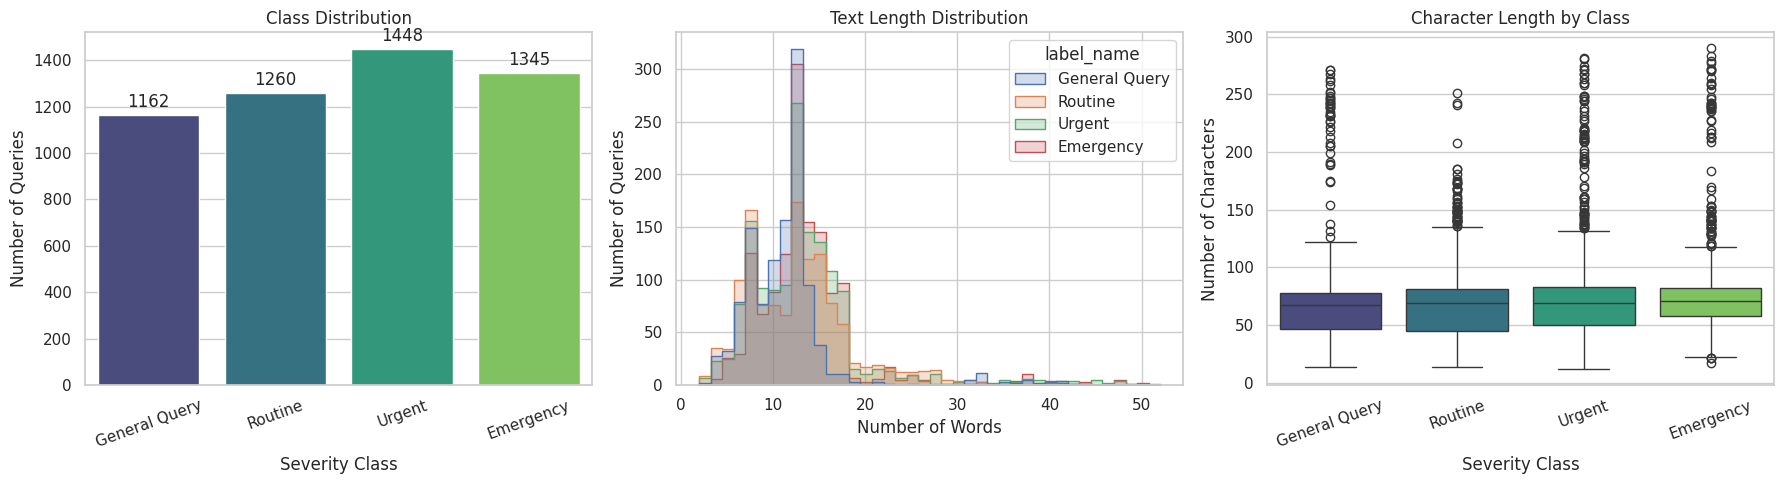

Vocabulary size: 4758


word_length                                            \
                    count   mean   std  min   25%   50%   75%   max   
label_name                                                            
General Query      1162.0  11.41  5.45  3.0   9.0  11.0  13.0  44.0   
Routine            1260.0  12.55  5.68  3.0   8.0  12.0  15.0  44.0   
Urgent             1448.0  13.35  6.78  2.0   9.0  13.0  15.0  52.0   
Emergency          1345.0  13.41  5.90  3.0  10.0  13.0  15.0  50.0   

              char_length         ... latin_chars       latin_ratio       \
                    count   mean  ...         75%   max       count mean   
label_name                        ...                                      
General Query      1162.0  67.67  ...         0.0  19.0      1162.0  0.0   
Routine            1260.0  68.72  ...         0.0  15.0      1260.0  0.0   
Urgent             1448.0  72.66  ...         0.0  20.0      1448.0  0.0   
Emergency          1345.0  74.78  ...         0.0  22.0      1345.0  0.0   

                                               
                std  min  25%  50%  75%   max  
label_name                                     
General Query  0.02  0.0  0.0  0.0  0.0  0.28  
Routine        0.01  0.0  0.0  0.0  0.0  0.25  
Urgent         0.01  0.0  0.0  0.0  0.0  0.18  
Emergency      0.02  0.0  0.0  0.0  0.0  0.21  

[4 rows x 40 columns]

In [ ]:
# Import required library
import re
import matplotlib.pyplot as plt
import seaborn as sns

# Convert the text column to standard Python strings.
# This prevents the PyArrow Unicode-regex error in Google Colab.
text_python = df['text'].astype('object').fillna('').astype(str)

# Calculate text-length features
df['char_length'] = text_python.str.len()
df['word_length'] = text_python.str.split().str.len()

# Count Bangla characters using Python's regular-expression engine
df['bangla_chars'] = text_python.apply(
    lambda text: len(re.findall(r'[\u0980-\u09FF]', text))
)

# Count English/Latin characters
df['latin_chars'] = text_python.apply(
    lambda text: len(re.findall(r'[A-Za-z]', text))
)

# Calculate the proportion of Latin characters
df['latin_ratio'] = (
    df['latin_chars']
    / (
        df['bangla_chars']
        + df['latin_chars']
        + 1
    )
)

# Define the correct severity-class order
class_order = [
    'General Query',
    'Routine',
    'Urgent',
    'Emergency'
]

# Create the EDA figures
fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(18, 5)
)

# Plot 1: Class distribution
sns.countplot(
    data=df,
    x='label_name',
    order=class_order,
    ax=axes[0],
    palette='viridis'
)

axes[0].set_title('Class Distribution')
axes[0].set_xlabel('Severity Class')
axes[0].set_ylabel('Number of Queries')
axes[0].tick_params(
    axis='x',
    rotation=20
)

# Add counts above the bars
for container in axes[0].containers:
    axes[0].bar_label(
        container,
        fmt='%d',
        padding=3
    )

# Plot 2: Text-length distribution
sns.histplot(
    data=df,
    x='word_length',
    hue='label_name',
    hue_order=class_order,
    bins=40,
    element='step',
    stat='count',
    common_norm=False,
    ax=axes[1]
)

axes[1].set_title('Text Length Distribution')
axes[1].set_xlabel('Number of Words')
axes[1].set_ylabel('Number of Queries')

# Plot 3: Character length by severity class
sns.boxplot(
    data=df,
    x='label_name',
    y='char_length',
    order=class_order,
    ax=axes[2],
    palette='viridis'
)

axes[2].set_title('Character Length by Class')
axes[2].set_xlabel('Severity Class')
axes[2].set_ylabel('Number of Characters')
axes[2].tick_params(
    axis='x',
    rotation=20
)

# Improve the figure layout
plt.tight_layout()

# Create the figures folder if it does not already exist
(PROJECT_DIR / 'figures').mkdir(
    parents=True,
    exist_ok=True
)

# Save the EDA figure
plt.savefig(
    PROJECT_DIR / 'figures/basic_eda.png',
    dpi=200,
    bbox_inches='tight'
)

plt.show()

# Calculate vocabulary size
vocabulary = {
    token
    for text in text_python
    for token in text.split()
}

print('Vocabulary size:', len(vocabulary))

# Show descriptive statistics by severity class
eda_statistics = (
    df.groupby('label_name')[
        [
            'word_length',
            'char_length',
            'bangla_chars',
            'latin_chars',
            'latin_ratio'
        ]
    ]
    .describe()
    .round(2)
)

# Arrange the table in severity order
eda_statistics = eda_statistics.reindex(class_order)

display(eda_statistics)

## 10. Word frequency, n-grams, word clouds and co-occurrence — CPU

,token,count
0,আর,1369
1,না,997
2,এবং,953
3,হচ্ছে,900
4,হয়ে,876
5,কি,859
6,গেছে,732
7,বা,718
8,হঠাৎ,710
9,কোনো,625


Top 1-grams


,ngram,count
0,র,12925
1,ক,8538
2,ন,7951
3,ব,7098
4,ত,5431
5,ল,4620
6,য,4423
7,প,4415
8,ছ,4294
9,চ,3582


Top 2-grams


,ngram,count
0,ক ন,1345
1,ন ত,1001
2,ব র,978
3,র ক,949
4,হচ ছ,901
5,ব যথ,867
6,গ ছ,771
7,ব ক,752
8,য চ,749
9,ত র,739


Top 3-grams


,ngram,count
0,ত ব র,533
1,য চ ছ,428
2,হয় গ ছ,408
3,চ ন ত,361
4,প রচণ ড,325
5,প রছ ন,303
6,ক ন ত,284
7,র ভ তর,282
8,ব চ চ,271
9,প য় র,268


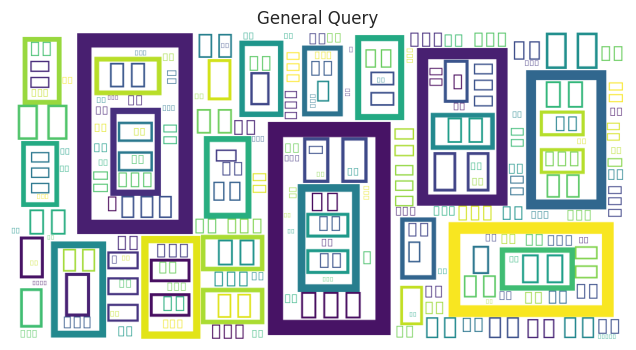

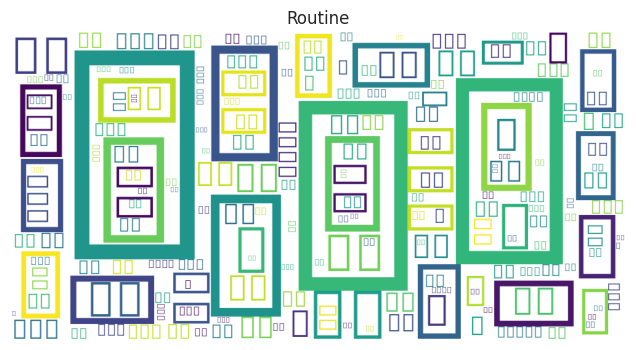

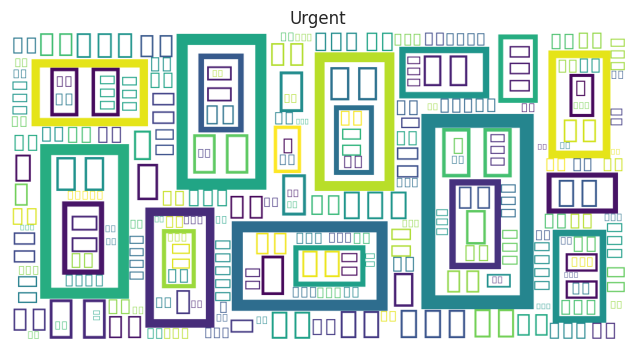

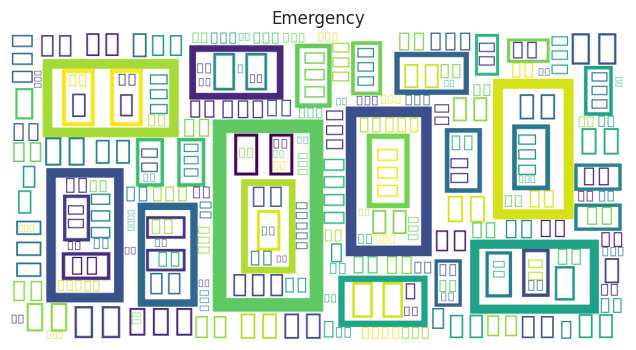

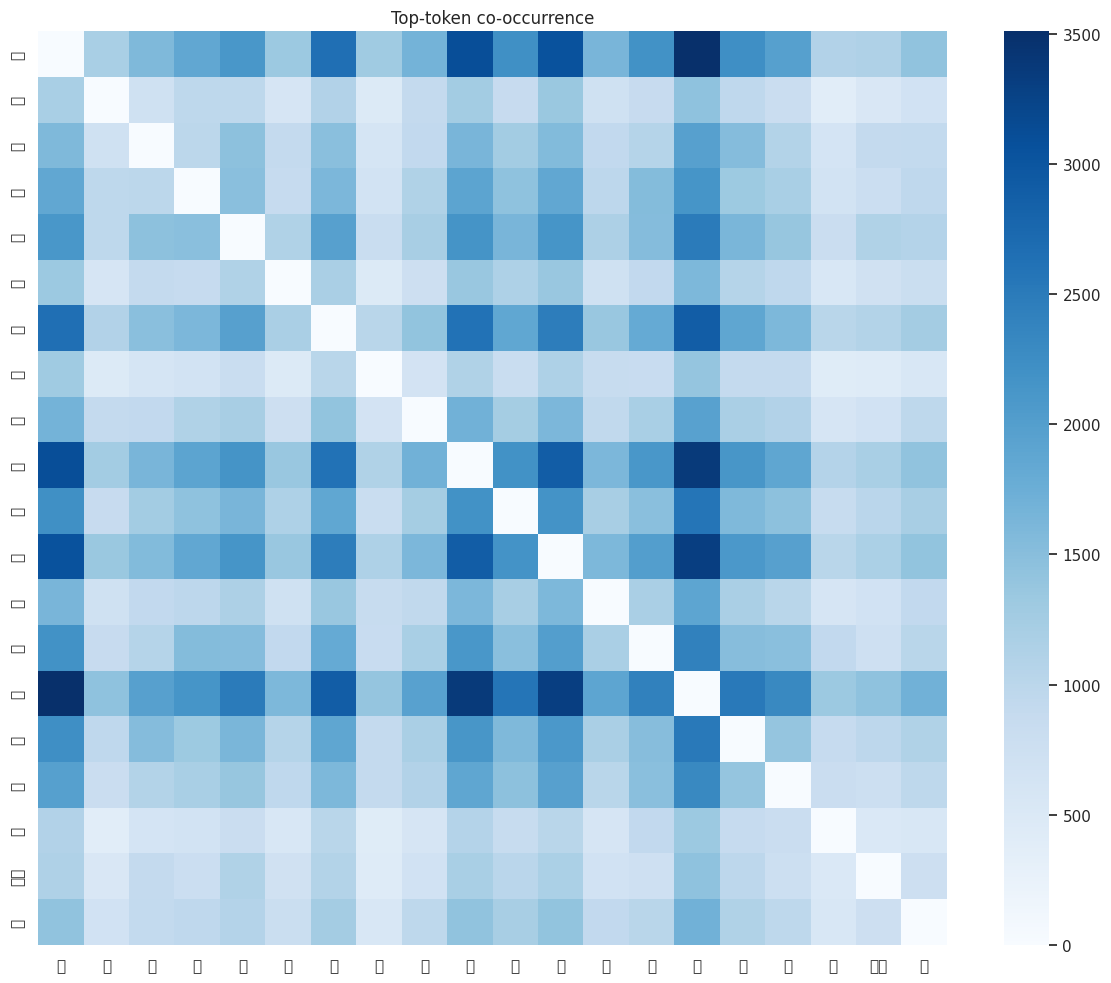

In [ ]:
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer
from wordcloud import WordCloud

tokens = [tok for text in df.text for tok in re.findall(r'[\u0980-\u09FFA-Za-z]+', text.lower()) if len(tok)>1]
display(pd.DataFrame(Counter(tokens).most_common(30), columns=['token','count']))

def top_ngrams(texts, n=2, top_k=20):
    vec = CountVectorizer(token_pattern=r'(?u)\b\w+\b', ngram_range=(n,n), min_df=2)
    matrix = vec.fit_transform(texts)
    counts = np.asarray(matrix.sum(axis=0)).ravel()
    names = np.asarray(vec.get_feature_names_out())
    idx = counts.argsort()[::-1][:top_k]
    return pd.DataFrame({'ngram':names[idx], 'count':counts[idx]})

for n in [1,2,3]:
    print(f'Top {n}-grams')
    display(top_ngrams(df.text, n))

# WordCloud may not shape Bangla perfectly, but it fulfills the visual EDA requirement.
for label_name in LABEL2ID:
    text_blob = ' '.join(df.loc[df.label_name==label_name, 'text'])
    wc = WordCloud(width=1000, height=500, background_color='white', collocations=False).generate(text_blob)
    plt.figure(figsize=(10,4)); plt.imshow(wc); plt.axis('off'); plt.title(label_name); plt.show()

# Co-occurrence heatmap for 20 frequent tokens.
vec = CountVectorizer(token_pattern=r'(?u)\b\w+\b', max_features=20, binary=True)
Xc = vec.fit_transform(df.text)
co = (Xc.T @ Xc).toarray(); np.fill_diagonal(co, 0)
plt.figure(figsize=(12,10))
sns.heatmap(co, xticklabels=vec.get_feature_names_out(), yticklabels=vec.get_feature_names_out(), cmap='Blues')
plt.title('Top-token co-occurrence'); plt.tight_layout(); plt.show()

## 11. Leakage-safe stratified split — CPU

The untouched test set is created before any augmentation or vector fitting.

In [ ]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(df, test_size=0.30, stratify=df.label, random_state=SEED)
val_df, test_df = train_test_split(temp_df, test_size=0.50, stratify=temp_df.label, random_state=SEED)

for name, split in [('train',train_df),('validation',val_df),('test',test_df)]:
    split = split.reset_index(drop=True)
    split[['text','label','label_name']].to_csv(PROJECT_DIR/f'data/splits/{name}.csv', index=False)
    print(name, len(split), split.label_name.value_counts(normalize=True).round(3).to_dict())

assert not set(train_df.text_normalized) & set(test_df.text_normalized)

train 3650 {'Urgent': 0.278, 'Emergency': 0.258, 'Routine': 0.242, 'General Query': 0.223}
validation 782 {'Urgent': 0.277, 'Emergency': 0.258, 'Routine': 0.242, 'General Query': 0.223}
test 783 {'Urgent': 0.277, 'Emergency': 0.258, 'Routine': 0.241, 'General Query': 0.223}


## 12. Classical preprocessing and feature engineering — CPU

In [ ]:
def clean_classical(text):
    text = unicodedata.normalize('NFKC', str(text))
    text = re.sub(r'https?://\S+|www\.\S+', ' URL ', text)
    text = re.sub(r'@[A-Za-z0-9_]+', ' USER ', text)
    text = re.sub(r'\s+', ' ', text).strip().lower()
    return text

X_train_text = train_df.text.map(clean_classical)
X_val_text = val_df.text.map(clean_classical)
X_test_text = test_df.text.map(clean_classical)
y_train, y_val, y_test = train_df.label.values, val_df.label.values, test_df.label.values

## 13. Train 5 classical models — CPU

Families: probabilistic, linear, margin-based, tree and boosted ensemble.

In [ ]:
from sklearn.pipeline import FeatureUnion
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_auc_score
import joblib, time

word_tfidf = TfidfVectorizer(ngram_range=(1,2), min_df=2, max_df=.98, sublinear_tf=True, max_features=40000)
char_tfidf = TfidfVectorizer(analyzer='char_wb', ngram_range=(3,5), min_df=2, max_features=40000)
features = FeatureUnion([('word',word_tfidf),('char',char_tfidf)])
Xtr = features.fit_transform(X_train_text)
Xva = features.transform(X_val_text)
Xte = features.transform(X_test_text)

classical_models = {
    'MultinomialNB': MultinomialNB(alpha=0.5),
    'LogisticRegression': LogisticRegression(max_iter=2000, class_weight='balanced'),
    'LinearSVM': CalibratedClassifierCV(LinearSVC(C=1.0, class_weight='balanced'), cv=3),
    'RandomForest': RandomForestClassifier(n_estimators=300, class_weight='balanced', n_jobs=-1, random_state=SEED),
    'XGBoost': XGBClassifier(n_estimators=300, max_depth=6, learning_rate=.05, subsample=.8,
                             colsample_bytree=.8, objective='multi:softprob', eval_metric='mlogloss',
                             random_state=SEED, n_jobs=-1)
}

results = []
trained_models = {}
for name, model in classical_models.items():
    start = time.time(); model.fit(Xtr, y_train)
    pred = model.predict(Xte)
    prob = model.predict_proba(Xte)
    p,r,f,_ = precision_recall_fscore_support(y_test,pred,average='macro',zero_division=0)
    results.append({'model':name,'accuracy':accuracy_score(y_test,pred),'macro_precision':p,
                    'macro_recall':r,'macro_f1':f,'roc_auc_ovr':roc_auc_score(y_test,prob,multi_class='ovr'),
                    'seconds':time.time()-start})
    trained_models[name]=model
display(pd.DataFrame(results).sort_values('macro_f1',ascending=False))
joblib.dump(features, PROJECT_DIR/'models/tfidf_features.joblib')
joblib.dump(trained_models['LinearSVM'], PROJECT_DIR/'models/linear_svm.joblib')

,model,accuracy,macro_precision,macro_recall,macro_f1,roc_auc_ovr,seconds
2,LinearSVM,0.915709,0.918404,0.918993,0.918581,0.984094,1.731474
1,LogisticRegression,0.901660,0.904062,0.906255,0.904866,0.984641,6.078528
4,XGBoost,0.899106,0.901585,0.903309,0.902336,0.979868,303.460077
3,RandomForest,0.896552,0.900029,0.900727,0.900262,0.980962,16.928769
0,MultinomialNB,0.883780,0.886017,0.888528,0.886979,0.980759,0.038521


['/content/score_bn/models/linear_svm.joblib']

## 14. Required evaluation plots — CPU

Best classical: LinearSVM
               precision    recall  f1-score   support

General Query       0.97      0.97      0.97       175
      Routine       0.90      0.94      0.92       189
       Urgent       0.87      0.86      0.86       217
    Emergency       0.93      0.91      0.92       202

     accuracy                           0.92       783
    macro avg       0.92      0.92      0.92       783
 weighted avg       0.92      0.92      0.92       783



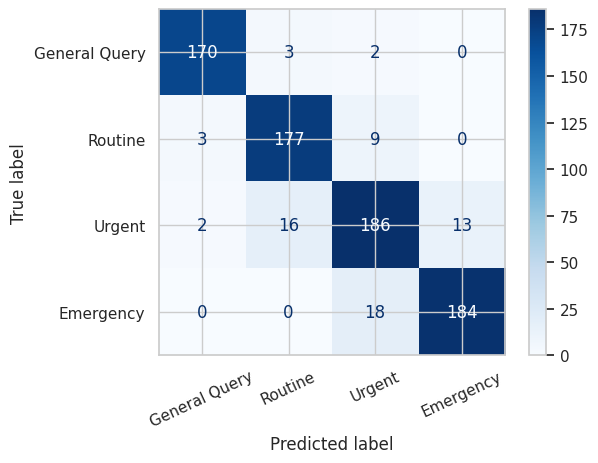

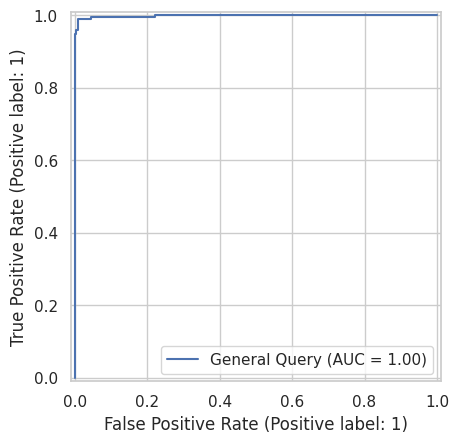

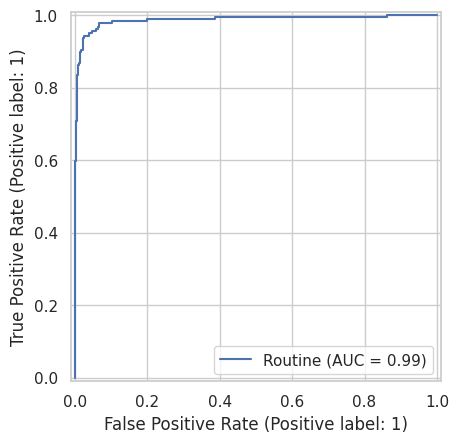

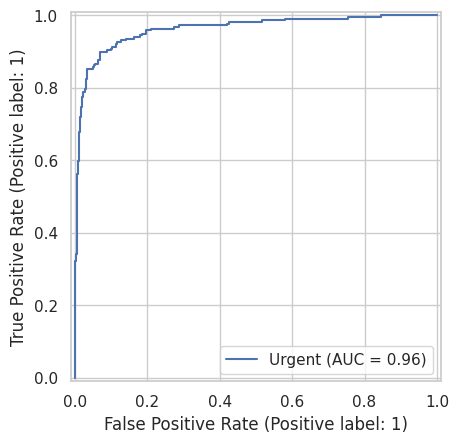

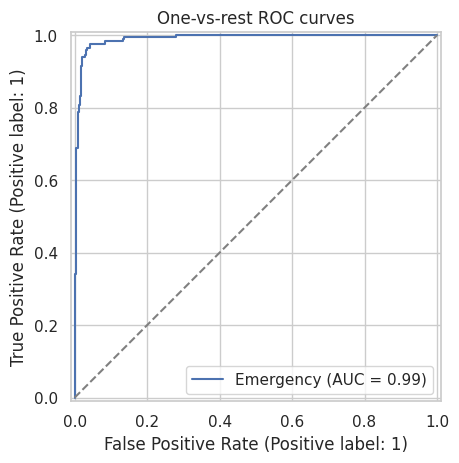

In [ ]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.preprocessing import label_binarize

best_classical_name = max(trained_models, key=lambda n: precision_recall_fscore_support(
    y_test, trained_models[n].predict(Xte), average='macro', zero_division=0)[2])
best_classical = trained_models[best_classical_name]
pred = best_classical.predict(Xte); prob = best_classical.predict_proba(Xte)
print('Best classical:', best_classical_name)
print(classification_report(y_test,pred,target_names=[ID2LABEL[i] for i in range(4)],zero_division=0))
ConfusionMatrixDisplay.from_predictions(y_test,pred,display_labels=[ID2LABEL[i] for i in range(4)],cmap='Blues')
plt.xticks(rotation=25); plt.tight_layout(); plt.show()

y_bin = label_binarize(y_test, classes=[0,1,2,3])
for i in range(4):
    RocCurveDisplay.from_predictions(y_bin[:,i], prob[:,i], name=ID2LABEL[i])
plt.plot([0,1],[0,1],'--',color='gray'); plt.title('One-vs-rest ROC curves'); plt.show()

In [ ]:
import joblib
from google.colab import drive
from pathlib import Path

drive.mount('/content/drive')

BACKUP_DIR = Path('/content/drive/MyDrive/SCORE_BN_Checkpoints')
BACKUP_DIR.mkdir(parents=True, exist_ok=True)

# Save TF-IDF feature extractor
joblib.dump(
    features,
    BACKUP_DIR / 'tfidf_features.joblib'
)

# Save transformed datasets
joblib.dump(
    {
        'Xtr': Xtr,
        'Xva': Xva,
        'Xte': Xte,
        'y_train': y_train,
        'y_val': y_val,
        'y_test': y_test
    },
    BACKUP_DIR / 'transformed_data.joblib'
)

# Save already trained classical models
joblib.dump(
    trained_models,
    BACKUP_DIR / 'classical_models.joblib'
)

# Save dataset splits
train_df.to_csv(BACKUP_DIR / 'train.csv', index=False)
val_df.to_csv(BACKUP_DIR / 'validation.csv', index=False)
test_df.to_csv(BACKUP_DIR / 'test.csv', index=False)

print("Checkpoint saved successfully to Google Drive.")

Mounted at /content/drive
Checkpoint saved successfully to Google Drive.


## 15. Tune three models — CPU for SVM/XGBoost; T4 for transformer later

In [ ]:
import time
import numpy as np
import pandas as pd

from sklearn.model_selection import RandomizedSearchCV
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support
)
from xgboost import XGBClassifier
import joblib

# ============================================================
# 1. FAST LINEAR SVM TUNING
# ============================================================

print("Starting Linear SVM tuning...")
svm_start_time = time.time()

svm_search = RandomizedSearchCV(
    estimator=LinearSVC(
        class_weight='balanced',
        random_state=SEED
    ),
    param_distributions={
        'C': [
            0.05,
            0.1,
            0.25,
            0.5,
            1.0,
            2.0,
            5.0
        ]
    },
    n_iter=5,
    scoring='f1_macro',
    cv=2,
    random_state=SEED,
    n_jobs=-1,
    verbose=2,
    refit=True
)

svm_search.fit(Xtr, y_train)

svm_minutes = (time.time() - svm_start_time) / 60

print("\nBest SVM parameters:")
print(svm_search.best_params_)

print("Best SVM cross-validation macro-F1:")
print(round(svm_search.best_score_, 4))

print("SVM tuning time:")
print(round(svm_minutes, 2), "minutes")


# ============================================================
# 2. CHECK XGBOOST VERSION AND GPU
# ============================================================

import xgboost as xgb
import torch

print("\nXGBoost version:", xgb.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


# ============================================================
# 3. FAST GPU XGBOOST TUNING
# ============================================================

print("\nStarting XGBoost GPU tuning...")
xgb_start_time = time.time()

xgb_base = XGBClassifier(
    objective='multi:softprob',
    num_class=4,
    eval_metric='mlogloss',

    # Use histogram-based training
    tree_method='hist',

    # Explicitly use the connected T4 GPU
    device='cuda',

    random_state=SEED,

    # Keep this at 1 because several simultaneous CV jobs
    # competing for one GPU can cause memory problems.
    n_jobs=1
)

xgb_parameter_space = {
    'n_estimators': [
        100,
        150,
        200
    ],
    'max_depth': [
        3,
        5,
        7
    ],
    'learning_rate': [
        0.03,
        0.05,
        0.1
    ],
    'subsample': [
        0.8,
        1.0
    ],
    'colsample_bytree': [
        0.8,
        1.0
    ],
    'min_child_weight': [
        1,
        3
    ]
}

xgb_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=xgb_parameter_space,

    # Five candidates × two folds = ten fits
    n_iter=5,
    cv=2,

    scoring='f1_macro',
    random_state=SEED,
    n_jobs=1,
    verbose=2,
    refit=True,
    error_score='raise'
)

xgb_search.fit(Xtr, y_train)

xgb_minutes = (time.time() - xgb_start_time) / 60

print("\nBest XGBoost parameters:")
print(xgb_search.best_params_)

print("Best XGBoost cross-validation macro-F1:")
print(round(xgb_search.best_score_, 4))

print("XGBoost tuning time:")
print(round(xgb_minutes, 2), "minutes")


# ============================================================
# 4. EVALUATE TUNED MODELS ON UNTOUCHED TEST SET
# ============================================================

tuned_models = {
    'Tuned Linear SVM': svm_search.best_estimator_,
    'Tuned XGBoost': xgb_search.best_estimator_
}

tuned_results = []

for model_name, model in tuned_models.items():

    predictions = model.predict(Xte)

    precision, recall, f1, _ = (
        precision_recall_fscore_support(
            y_test,
            predictions,
            average='macro',
            zero_division=0
        )
    )

    tuned_results.append({
        'model': model_name,
        'accuracy': accuracy_score(
            y_test,
            predictions
        ),
        'macro_precision': precision,
        'macro_recall': recall,
        'macro_f1': f1
    })

tuned_results_df = pd.DataFrame(tuned_results)

display(
    tuned_results_df.sort_values(
        by='macro_f1',
        ascending=False
    )
)


# ============================================================
# 5. SAVE TUNED MODELS DIRECTLY TO GOOGLE DRIVE
# ============================================================

joblib.dump(
    svm_search.best_estimator_,
    BACKUP_DIR / 'tuned_linear_svm.joblib'
)

joblib.dump(
    xgb_search.best_estimator_,
    BACKUP_DIR / 'tuned_xgboost.joblib'
)

tuned_results_df.to_csv(
    BACKUP_DIR / 'tuned_model_results.csv',
    index=False
)

print("\nTuned models and results saved to:")
print(BACKUP_DIR)

Starting Linear SVM tuning...
Fitting 2 folds for each of 5 candidates, totalling 10 fits

Best SVM parameters:
{'C': 1.0}
Best SVM cross-validation macro-F1:
0.9006
SVM tuning time:
0.18 minutes

XGBoost version: 3.4.0
CUDA available: True
GPU: Tesla T4

Starting XGBoost GPU tuning...
Fitting 2 folds for each of 5 candidates, totalling 10 fits
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=5, min_child_weight=3, n_estimators=150, subsample=1.0; total time=   5.5s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=5, min_child_weight=3, n_estimators=150, subsample=1.0; total time=   4.1s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=7, min_child_weight=3, n_estimators=150, subsample=1.0; total time=   6.1s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=7, min_child_weight=3, n_estimators=150, subsample=1.0; total time=   6.3s
[CV] END colsample_bytree=1.0, learning_rate=0.03, max_depth=7, min_child_weight=3, n_estimators=100, subsample=0

,model,accuracy,macro_precision,macro_recall,macro_f1
0,Tuned Linear SVM,0.916986,0.919211,0.920251,0.919701
1,Tuned XGBoost,0.890166,0.892524,0.894902,0.893506



Tuned models and results saved to:
/content/drive/MyDrive/SCORE_BN_Checkpoints


## 16. Text-CNN, BiLSTM and BiGRU — T4 recommended

These are three deep-learning families required for the course comparison.

In [ ]:
import gc
import time
import joblib
import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow.keras import layers, Model
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    roc_auc_score
)

# Reproducibility
tf.keras.utils.set_random_seed(SEED)

print("Available GPUs:", tf.config.list_physical_devices('GPU'))

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

MAX_TOKENS = 30000
MAX_LEN = 128
EMBED_DIM = 128
BATCH_SIZE = 64
MAX_EPOCHS = 10

# ------------------------------------------------------------
# Text vectorization
# ------------------------------------------------------------

vectorizer = layers.TextVectorization(
    max_tokens=MAX_TOKENS,
    standardize=None,
    output_mode='int',
    output_sequence_length=MAX_LEN
)

# Convert all text to normal NumPy string arrays
train_text_array = X_train_text.astype(str).to_numpy()
validation_text_array = X_val_text.astype(str).to_numpy()
test_text_array = X_test_text.astype(str).to_numpy()

# Learn vocabulary using training data only
vectorizer.adapt(train_text_array)

# Convert text into integer sequences
Xtr_seq = vectorizer(train_text_array)
Xva_seq = vectorizer(validation_text_array)
Xte_seq = vectorizer(test_text_array)

print("Training shape:", Xtr_seq.shape)
print("Validation shape:", Xva_seq.shape)
print("Test shape:", Xte_seq.shape)
print("Vocabulary size:", len(vectorizer.get_vocabulary()))

# Save the learned vocabulary
vocabulary = vectorizer.get_vocabulary()

with open(
    BACKUP_DIR / 'text_vectorizer_vocabulary.txt',
    'w',
    encoding='utf-8'
) as file:
    for token in vocabulary:
        file.write(str(token) + '\n')

# ------------------------------------------------------------
# Deep-learning model builder
# ------------------------------------------------------------

def make_deep_model(kind):

    inputs = layers.Input(
        shape=(MAX_LEN,),
        dtype='int64',
        name='token_ids'
    )

    # CNN does not support the embedding mask in this architecture.
    use_mask = kind != 'CNN'

    x = layers.Embedding(
        input_dim=len(vectorizer.get_vocabulary()),
        output_dim=EMBED_DIM,
        mask_zero=use_mask,
        name='embedding'
    )(inputs)

    if kind == 'CNN':

        x = layers.Conv1D(
            filters=128,
            kernel_size=3,
            activation='relu',
            name='convolution'
        )(x)

        x = layers.GlobalMaxPooling1D(
            name='global_max_pooling'
        )(x)

    elif kind == 'BiLSTM':

        x = layers.Bidirectional(
            layers.LSTM(
                units=64,
                dropout=0.20
            ),
            name='bidirectional_lstm'
        )(x)

    elif kind == 'BiGRU':

        x = layers.Bidirectional(
            layers.GRU(
                units=64,
                dropout=0.20
            ),
            name='bidirectional_gru'
        )(x)

    else:
        raise ValueError(
            "Model kind must be CNN, BiLSTM, or BiGRU."
        )

    x = layers.Dropout(
        rate=0.35,
        name='dropout'
    )(x)

    outputs = layers.Dense(
        units=4,
        activation='softmax',
        name='severity_output'
    )(x)

    model = Model(
        inputs=inputs,
        outputs=outputs,
        name=kind
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=0.001
        ),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


# ------------------------------------------------------------
# Train CNN, BiLSTM and BiGRU
# ------------------------------------------------------------

deep_results = []
deep_models = {}
training_histories = {}

model_names = [
    'CNN',
    'BiLSTM',
    'BiGRU'
]

for kind in model_names:

    print("\n" + "=" * 60)
    print("Training model:", kind)
    print("=" * 60)

    # Release memory from the previous model
    tf.keras.backend.clear_session()
    gc.collect()

    model = make_deep_model(kind)

    model.summary()

    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=2,
            restore_best_weights=True,
            verbose=1
        ),

        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=1,
            min_lr=1e-6,
            verbose=1
        ),

        tf.keras.callbacks.ModelCheckpoint(
            filepath=str(
                BACKUP_DIR / f'best_{kind}.keras'
            ),
            monitor='val_loss',
            save_best_only=True,
            verbose=1
        )
    ]

    start_time = time.time()

    history = model.fit(
        Xtr_seq,
        y_train,
        validation_data=(
            Xva_seq,
            y_val
        ),
        epochs=MAX_EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=callbacks,
        verbose=1
    )

    training_minutes = (
        time.time() - start_time
    ) / 60

    # Generate test probabilities and predictions
    probabilities = model.predict(
        Xte_seq,
        batch_size=BATCH_SIZE,
        verbose=0
    )

    predictions = probabilities.argmax(axis=1)

    precision, recall, f1, _ = (
        precision_recall_fscore_support(
            y_test,
            predictions,
            average='macro',
            zero_division=0
        )
    )

    result = {
        'model': kind,
        'accuracy': accuracy_score(
            y_test,
            predictions
        ),
        'macro_precision': precision,
        'macro_recall': recall,
        'macro_f1': f1,
        'roc_auc_ovr': roc_auc_score(
            y_test,
            probabilities,
            multi_class='ovr'
        ),
        'training_minutes': training_minutes,
        'epochs_completed': len(
            history.history['loss']
        )
    }

    deep_results.append(result)

    # Keep the current model in memory
    deep_models[kind] = model

    # Keep training history
    training_histories[kind] = history.history

    # Save final model
    model.save(
        BACKUP_DIR / f'{kind}_final.keras'
    )

    # Save predictions for later evaluation
    np.save(
        BACKUP_DIR / f'{kind}_probabilities.npy',
        probabilities
    )

    np.save(
        BACKUP_DIR / f'{kind}_predictions.npy',
        predictions
    )

    # Save history
    pd.DataFrame(
        history.history
    ).to_csv(
        BACKUP_DIR / f'{kind}_training_history.csv',
        index=False
    )

    # Save updated results after every model
    pd.DataFrame(
        deep_results
    ).to_csv(
        BACKUP_DIR / 'deep_model_results.csv',
        index=False
    )

    print("\nCompleted:", kind)
    print("Macro-F1:", round(f1, 4))
    print(
        "Training time:",
        round(training_minutes, 2),
        "minutes"
    )
    print("Saved to Google Drive.")


# ------------------------------------------------------------
# Final results
# ------------------------------------------------------------

deep_results_df = pd.DataFrame(
    deep_results
).sort_values(
    by='macro_f1',
    ascending=False
)

display(deep_results_df)

Available GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Training shape: (3650, 128)
Validation shape: (782, 128)
Test shape: (783, 128)
Vocabulary size: 4032

Training model: CNN


Model: "CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ token_ids (InputLayer)          │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 128, 128)       │       516,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ convolution (Conv1D)            │ (None, 126, 128)       │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling              │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ severity_output (Dense)         │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 565,892 (2.16 MB)

 Trainable params: 565,892 (2.16 MB)

...

 Total params: 591,108 (2.25 MB)

 Trainable params: 591,108 (2.25 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
55/58 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4619 - loss: 1.3062
Epoch 1: val_loss improved from None to 0.50179, saving model to /content/drive/MyDrive/SCORE_BN_Checkpoints/best_BiGRU.keras

Epoch 1: finished saving model to /content/drive/MyDrive/SCORE_BN_Checkpoints/best_BiGRU.keras
58/58 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.5803 - loss: 1.1172 - val_accuracy: 0.8223 - val_loss: 0.5018 - learning_rate: 0.0010
Epoch 2/10
53/58 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8485 - loss: 0.4231
Epoch 2: val_loss improved from 0.50179 to 0.27513, saving model to /content/drive/MyDrive/SCORE_BN_Checkpoints/best_BiGRU.keras

Epoch 2: finished saving model to /content/drive/MyDrive/SCORE_BN_Checkpoints/best_BiGRU.keras
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8830 - loss: 0.3322 - val_accuracy: 0.9054 - val_loss: 0.2751 - learning_rate: 0.0010
Epoch 3/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9448 - loss: 0.1793
Epoch 3: ReduceLRO

,model,accuracy,macro_precision,macro_recall,macro_f1,roc_auc_ovr,training_minutes,epochs_completed
0,CNN,0.915709,0.918553,0.918778,0.918570,0.987006,0.191969,7
2,BiGRU,0.902937,0.905314,0.906979,0.905985,0.983440,0.094948,4
1,BiLSTM,0.901660,0.903911,0.907043,0.904518,0.977857,0.149751,4


## 17. Transformer baseline — T4 GPU required

Default: `csebuetnlp/banglabert`. If loading fails, use `xlm-roberta-base`.

In [ ]:
import gc
import tensorflow as tf
import torch

tf.keras.backend.clear_session()

# Remove large TensorFlow sequence tensors if they exist
for variable_name in [
    'Xtr_seq',
    'Xva_seq',
    'Xte_seq',
    'model',
    'deep_models'
]:
    if variable_name in globals():
        del globals()[variable_name]

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "Not available")

GPU: Tesla T4


In [ ]:
import json
import numpy as np
import pandas as pd
import torch

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    EarlyStoppingCallback
)

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    roc_auc_score
)

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

MODEL_NAME = 'csebuetnlp/banglabert'

BERT_SAVE_DIR = (
    BACKUP_DIR / 'banglabert_baseline'
)

BERT_SAVE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print(
    "Device:",
    torch.cuda.get_device_name(0)
    if torch.cuda.is_available()
    else "CPU"
)

# ------------------------------------------------------------
# Tokenizer
# ------------------------------------------------------------

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

# ------------------------------------------------------------
# Convert pandas DataFrames to Hugging Face datasets
# ------------------------------------------------------------

def make_hf_dataset(frame):

    required_columns = [
        'text',
        'label'
    ]

    missing_columns = [
        column
        for column in required_columns
        if column not in frame.columns
    ]

    if missing_columns:
        raise ValueError(
            f"Missing columns: {missing_columns}"
        )

    temporary_frame = (
        frame[['text', 'label']]
        .copy()
        .reset_index(drop=True)
    )

    temporary_frame['text'] = (
        temporary_frame['text']
        .fillna('')
        .astype(str)
    )

    temporary_frame['label'] = (
        temporary_frame['label']
        .astype(int)
    )

    dataset = Dataset.from_pandas(
        temporary_frame,
        preserve_index=False
    )

    dataset = dataset.map(
        lambda batch: tokenizer(
            batch['text'],
            truncation=True,
            max_length=160
        ),
        batched=True,
        desc='Tokenizing'
    )

    return dataset


train_ds = make_hf_dataset(train_df)
val_ds = make_hf_dataset(val_df)
test_ds = make_hf_dataset(test_df)

print("Training samples:", len(train_ds))
print("Validation samples:", len(val_ds))
print("Test samples:", len(test_ds))

# Dynamic padding saves GPU memory
data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer
)

# ------------------------------------------------------------
# Evaluation metrics
# ------------------------------------------------------------

def compute_metrics_transformer(eval_prediction):

    logits, labels = eval_prediction

    predictions = np.argmax(
        logits,
        axis=-1
    )

    probabilities = torch.softmax(
        torch.tensor(logits),
        dim=-1
    ).numpy()

    precision, recall, f1, _ = (
        precision_recall_fscore_support(
            labels,
            predictions,
            average='macro',
            zero_division=0
        )
    )

    try:
        auc = roc_auc_score(
            labels,
            probabilities,
            multi_class='ovr',
            average='macro'
        )
    except ValueError:
        auc = float('nan')

    return {
        'accuracy': accuracy_score(
            labels,
            predictions
        ),
        'macro_precision': precision,
        'macro_recall': recall,
        'macro_f1': f1,
        'roc_auc_ovr': auc
    }

# ------------------------------------------------------------
# Load BanglaBERT
# ------------------------------------------------------------

baseline_model = (
    AutoModelForSequenceClassification
    .from_pretrained(
        MODEL_NAME,
        num_labels=4,
        id2label=ID2LABEL,
        label2id=LABEL2ID
    )
)

# The warning about newly initialized classifier weights is normal.
# The classification layer will be learned from this dataset.

# ------------------------------------------------------------
# Training settings
# ------------------------------------------------------------

training_args = TrainingArguments(
    output_dir=str(
        BERT_SAVE_DIR / 'checkpoints'
    ),

    learning_rate=2e-5,

    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,

    num_train_epochs=5,

    weight_decay=0.01,
    warmup_ratio=0.1,

    eval_strategy='epoch',
    save_strategy='epoch',
    logging_strategy='steps',
    logging_steps=25,

    load_best_model_at_end=True,
    metric_for_best_model='macro_f1',
    greater_is_better=True,

    # Use T4 mixed-precision training
    fp16=torch.cuda.is_available(),

    report_to='none',
    seed=SEED,

    save_total_limit=1
)

# ------------------------------------------------------------
# Trainer
# ------------------------------------------------------------

trainer = Trainer(
    model=baseline_model,
    args=training_args,

    train_dataset=train_ds,
    eval_dataset=val_ds,

    processing_class=tokenizer,
    data_collator=data_collator,

    compute_metrics=compute_metrics_transformer,

    callbacks=[
        EarlyStoppingCallback(
            early_stopping_patience=2
        )
    ]
)

# ------------------------------------------------------------
# Train
# ------------------------------------------------------------

train_output = trainer.train()

print("\nTraining completed.")

# ------------------------------------------------------------
# Evaluate on untouched test set
# ------------------------------------------------------------

test_metrics = trainer.evaluate(
    eval_dataset=test_ds
)

print("\nBanglaBERT test results:")

display(
    pd.DataFrame(
        [test_metrics]
    )
)

# ------------------------------------------------------------
# Save model, tokenizer and results to Google Drive
# ------------------------------------------------------------

FINAL_MODEL_DIR = (
    BERT_SAVE_DIR / 'final_model'
)

trainer.save_model(
    str(FINAL_MODEL_DIR)
)

tokenizer.save_pretrained(
    str(FINAL_MODEL_DIR)
)

with open(
    BERT_SAVE_DIR / 'test_metrics.json',
    'w'
) as file:
    json.dump(
        {
            key: float(value)
            if isinstance(
                value,
                (float, int, np.floating, np.integer)
            )
            else value
            for key, value in test_metrics.items()
        },
        file,
        indent=2
    )

trainer.save_state()

print("\nModel saved to:")
print(FINAL_MODEL_DIR)

Device: Tesla T4


config.json:   0%|          | 0.00/586 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/119 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/528k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

...

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  443MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] ElectraForSequenceClassification LOAD REPORT from: csebuetnlp/banglabert
Key                                               | Status     | 
--------------------------------------------------+------------+-
discriminator_predictions.dense.bias              | UNEXPECTED | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
discriminator_predictions.dense.weight            | UNEXPECTED | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
classifier.out_proj.bias                          | MISSING    | 
classifier.dense.bias                             | MISSING    | 
classifier.dense.weight                           | MISSING    | 
classifier.out_proj.weight                        | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


TypeError: TrainingArguments.__init__() got an unexpected keyword argument 'warmup_ratio'

In [ ]:
import inspect
import json
import numpy as np
import pandas as pd
import torch

from transformers import (
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)

# ------------------------------------------------------------
# Build arguments compatible with the installed Transformers
# version
# ------------------------------------------------------------

supported_parameters = inspect.signature(
    TrainingArguments.__init__
).parameters

training_settings = {
    'output_dir': str(
        BERT_SAVE_DIR / 'checkpoints'
    ),

    'learning_rate': 2e-5,

    'per_device_train_batch_size': 16,
    'per_device_eval_batch_size': 32,

    'num_train_epochs': 5,

    'weight_decay': 0.01,

    'save_strategy': 'epoch',
    'logging_strategy': 'steps',
    'logging_steps': 25,

    'load_best_model_at_end': True,
    'metric_for_best_model': 'macro_f1',
    'greater_is_better': True,

    'fp16': torch.cuda.is_available(),

    'report_to': 'none',
    'seed': SEED,

    'save_total_limit': 1
}

# Different Transformers versions use different names.
if 'eval_strategy' in supported_parameters:

    training_settings[
        'eval_strategy'
    ] = 'epoch'

elif 'evaluation_strategy' in supported_parameters:

    training_settings[
        'evaluation_strategy'
    ] = 'epoch'

else:

    raise RuntimeError(
        "This Transformers version does not provide an "
        "evaluation-strategy argument."
    )

# Add warm-up only when the installed version supports it.
if 'warmup_ratio' in supported_parameters:

    training_settings[
        'warmup_ratio'
    ] = 0.1

elif 'warmup_steps' in supported_parameters:

    # Approximately 10% warm-up is not essential here.
    # A fixed value keeps this version compatible.
    training_settings[
        'warmup_steps'
    ] = 20

# Keep only settings supported by the installed version
training_settings = {
    name: value
    for name, value in training_settings.items()
    if name in supported_parameters
}

print("Training arguments being used:")

for name, value in training_settings.items():
    print(f"{name}: {value}")

training_args = TrainingArguments(
    **training_settings
)

# ------------------------------------------------------------
# Create Trainer
# ------------------------------------------------------------

trainer_parameters = inspect.signature(
    Trainer.__init__
).parameters

trainer_settings = {
    'model': baseline_model,
    'args': training_args,

    'train_dataset': train_ds,
    'eval_dataset': val_ds,

    'data_collator': data_collator,

    'compute_metrics': compute_metrics_transformer,

    'callbacks': [
        EarlyStoppingCallback(
            early_stopping_patience=2
        )
    ]
}

# Compatibility between Transformers versions
if 'processing_class' in trainer_parameters:

    trainer_settings[
        'processing_class'
    ] = tokenizer

elif 'tokenizer' in trainer_parameters:

    trainer_settings[
        'tokenizer'
    ] = tokenizer

trainer = Trainer(
    **trainer_settings
)

# ------------------------------------------------------------
# Train BanglaBERT
# ------------------------------------------------------------

print("\nStarting BanglaBERT training...")

train_output = trainer.train()

print("\nBanglaBERT training completed.")

# ------------------------------------------------------------
# Evaluate using the untouched test dataset
# ------------------------------------------------------------

test_metrics = trainer.evaluate(
    eval_dataset=test_ds
)

print("\nBanglaBERT test results:")

display(
    pd.DataFrame(
        [test_metrics]
    )
)

# ------------------------------------------------------------
# Generate and save test predictions
# ------------------------------------------------------------

prediction_output = trainer.predict(
    test_ds
)

test_logits = prediction_output.predictions

test_probabilities = torch.softmax(
    torch.tensor(test_logits),
    dim=-1
).numpy()

test_predictions = np.argmax(
    test_probabilities,
    axis=1
)

np.save(
    BERT_SAVE_DIR / 'test_probabilities.npy',
    test_probabilities
)

np.save(
    BERT_SAVE_DIR / 'test_predictions.npy',
    test_predictions
)

# ------------------------------------------------------------
# Save model and tokenizer
# ------------------------------------------------------------

FINAL_MODEL_DIR = (
    BERT_SAVE_DIR / 'final_model'
)

FINAL_MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

trainer.save_model(
    str(FINAL_MODEL_DIR)
)

tokenizer.save_pretrained(
    str(FINAL_MODEL_DIR)
)

# Convert NumPy values before saving JSON
serializable_metrics = {}

for key, value in test_metrics.items():

    if isinstance(
        value,
        (
            np.floating,
            np.integer
        )
    ):
        serializable_metrics[key] = value.item()

    elif isinstance(
        value,
        (
            float,
            int,
            str,
            bool
        )
    ):
        serializable_metrics[key] = value

with open(
    BERT_SAVE_DIR / 'test_metrics.json',
    'w',
    encoding='utf-8'
) as file:

    json.dump(
        serializable_metrics,
        file,
        indent=2
    )

trainer.save_state()

print("\nBanglaBERT model saved successfully to:")
print(FINAL_MODEL_DIR)

Training arguments being used:
output_dir: /content/drive/MyDrive/SCORE_BN_Checkpoints/banglabert_baseline/checkpoints
learning_rate: 2e-05
per_device_train_batch_size: 16
per_device_eval_batch_size: 32
num_train_epochs: 5
weight_decay: 0.01
save_strategy: epoch
logging_strategy: steps
logging_steps: 25
load_best_model_at_end: True
metric_for_best_model: macro_f1
greater_is_better: True
fp16: True
report_to: none
seed: 42
save_total_limit: 1
eval_strategy: epoch
warmup_steps: 20

Starting BanglaBERT training...


OutOfMemoryError: CUDA out of memory. Tried to allocate 94.00 MiB. GPU 0 has a total capacity of 14.56 GiB of which 37.81 MiB is free. Including non-PyTorch memory, this process has 14.52 GiB memory in use. Of the allocated memory 789.31 MiB is allocated by PyTorch, and 184.69 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://docs.pytorch.org/docs/stable/notes/cuda.html#optimizing-memory-usage-with-pytorch-cuda-alloc-conf)

In [ ]:
from pathlib import Path

CHECKPOINT_DIR = Path(
    '/content/drive/MyDrive/SCORE_BN_Checkpoints'
)

print("Files saved in Google Drive:")

for file_path in sorted(CHECKPOINT_DIR.rglob('*')):
    if file_path.is_file():
        print(file_path.relative_to(CHECKPOINT_DIR))

Files saved in Google Drive:
BiGRU_final.keras
BiGRU_predictions.npy
BiGRU_probabilities.npy
BiGRU_training_history.csv
BiLSTM_final.keras
BiLSTM_predictions.npy
BiLSTM_probabilities.npy
BiLSTM_training_history.csv
CNN_final.keras
CNN_predictions.npy
CNN_probabilities.npy
CNN_training_history.csv
best_BiGRU.keras
best_BiLSTM.keras
best_CNN.keras
classical_models.joblib
deep_model_results.csv
test.csv
text_vectorizer_vocabulary.txt
tfidf_features.joblib
train.csv
transformed_data.joblib
tuned_linear_svm.joblib
tuned_model_results.csv
tuned_xgboost.joblib
validation.csv


In [ ]:
!pip -q install -U transformers datasets accelerate evaluate sentencepiece

import gc
import json
import inspect
import random
from pathlib import Path

import numpy as np
import pandas as pd
import torch

from google.colab import drive

from datasets import Dataset

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    EarlyStoppingCallback
)

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    roc_auc_score
)

# Mount Google Drive
drive.mount('/content/drive')

# Reproducibility
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.cuda.empty_cache()

print(
    "Device:",
    torch.cuda.get_device_name(0)
    if torch.cuda.is_available()
    else "CPU"
)

# Google Drive folders
BACKUP_DIR = Path(
    '/content/drive/MyDrive/SCORE_BN_Checkpoints'
)

BERT_SAVE_DIR = (
    BACKUP_DIR / 'banglabert_baseline'
)

BERT_SAVE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

# Reload saved dataset splits
train_df = pd.read_csv(
    BACKUP_DIR / 'train.csv'
)

val_df = pd.read_csv(
    BACKUP_DIR / 'validation.csv'
)

test_df = pd.read_csv(
    BACKUP_DIR / 'test.csv'
)

# Make sure labels are integers
for frame in [
    train_df,
    val_df,
    test_df
]:
    frame['text'] = (
        frame['text']
        .fillna('')
        .astype(str)
    )

    frame['label'] = (
        frame['label']
        .astype(int)
    )

LABEL2ID = {
    'General Query': 0,
    'Routine': 1,
    'Urgent': 2,
    'Emergency': 3
}

ID2LABEL = {
    0: 'General Query',
    1: 'Routine',
    2: 'Urgent',
    3: 'Emergency'
}

print("Training:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

print("\nFree GPU memory before BanglaBERT:")

free_memory, total_memory = torch.cuda.mem_get_info()

print(
    "Free:",
    round(free_memory / 1024**3, 2),
    "GB"
)

print(
    "Total:",
    round(total_memory / 1024**3, 2),
    "GB"
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: Tesla T4
Training: (3650, 10)
Validation: (782, 10)
Test: (783, 10)

Free GPU memory before BanglaBERT:
Free: 14.46 GB
Total: 14.56 GB


In [ ]:
MODEL_NAME = 'csebuetnlp/banglabert'
MAX_LENGTH = 128

# ------------------------------------------------------------
# Load tokenizer
# ------------------------------------------------------------

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

# ------------------------------------------------------------
# Prepare Hugging Face datasets
# ------------------------------------------------------------

def make_hf_dataset(frame):

    temporary_frame = (
        frame[['text', 'label']]
        .copy()
        .reset_index(drop=True)
    )

    dataset = Dataset.from_pandas(
        temporary_frame,
        preserve_index=False
    )

    dataset = dataset.map(
        lambda batch: tokenizer(
            batch['text'],
            truncation=True,
            max_length=MAX_LENGTH
        ),
        batched=True,
        desc='Tokenizing'
    )

    return dataset


train_ds = make_hf_dataset(train_df)
val_ds = make_hf_dataset(val_df)
test_ds = make_hf_dataset(test_df)

data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer
)

print("Training samples:", len(train_ds))
print("Validation samples:", len(val_ds))
print("Test samples:", len(test_ds))

# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------

def compute_metrics_transformer(eval_prediction):

    logits, labels = eval_prediction

    predictions = np.argmax(
        logits,
        axis=-1
    )

    probabilities = torch.softmax(
        torch.tensor(logits),
        dim=-1
    ).numpy()

    precision, recall, f1, _ = (
        precision_recall_fscore_support(
            labels,
            predictions,
            average='macro',
            zero_division=0
        )
    )

    try:
        auc = roc_auc_score(
            labels,
            probabilities,
            multi_class='ovr',
            average='macro'
        )
    except ValueError:
        auc = float('nan')

    return {
        'accuracy': accuracy_score(
            labels,
            predictions
        ),
        'macro_precision': precision,
        'macro_recall': recall,
        'macro_f1': f1,
        'roc_auc_ovr': auc
    }

# ------------------------------------------------------------
# Load BanglaBERT
# ------------------------------------------------------------

baseline_model = (
    AutoModelForSequenceClassification
    .from_pretrained(
        MODEL_NAME,
        num_labels=4,
        id2label=ID2LABEL,
        label2id=LABEL2ID
    )
)

# Saves additional memory during training
baseline_model.gradient_checkpointing_enable()

# ------------------------------------------------------------
# Version-compatible training arguments
# ------------------------------------------------------------

supported_parameters = inspect.signature(
    TrainingArguments.__init__
).parameters

training_settings = {
    'output_dir': str(
        BERT_SAVE_DIR / 'checkpoints'
    ),

    'learning_rate': 2e-5,

    # Memory-safe T4 settings
    'per_device_train_batch_size': 4,
    'per_device_eval_batch_size': 8,

    # Effective training batch size = 4 × 4 = 16
    'gradient_accumulation_steps': 4,

    'num_train_epochs': 5,
    'weight_decay': 0.01,

    'save_strategy': 'epoch',
    'logging_strategy': 'steps',
    'logging_steps': 25,

    'load_best_model_at_end': True,
    'metric_for_best_model': 'macro_f1',
    'greater_is_better': True,

    'fp16': True,

    'report_to': 'none',
    'seed': SEED,
    'save_total_limit': 1
}

if 'eval_strategy' in supported_parameters:

    training_settings[
        'eval_strategy'
    ] = 'epoch'

else:

    training_settings[
        'evaluation_strategy'
    ] = 'epoch'

if 'warmup_steps' in supported_parameters:

    training_settings[
        'warmup_steps'
    ] = 20

training_settings = {
    key: value
    for key, value in training_settings.items()
    if key in supported_parameters
}

training_args = TrainingArguments(
    **training_settings
)

# ------------------------------------------------------------
# Version-compatible Trainer
# ------------------------------------------------------------

trainer_settings = {
    'model': baseline_model,
    'args': training_args,

    'train_dataset': train_ds,
    'eval_dataset': val_ds,

    'data_collator': data_collator,

    'compute_metrics': compute_metrics_transformer,

    'callbacks': [
        EarlyStoppingCallback(
            early_stopping_patience=2
        )
    ]
}

trainer_parameters = inspect.signature(
    Trainer.__init__
).parameters

if 'processing_class' in trainer_parameters:

    trainer_settings[
        'processing_class'
    ] = tokenizer

elif 'tokenizer' in trainer_parameters:

    trainer_settings[
        'tokenizer'
    ] = tokenizer

trainer = Trainer(
    **trainer_settings
)

# ------------------------------------------------------------
# Train
# ------------------------------------------------------------

print("Starting memory-safe BanglaBERT training...")

trainer.train()

print("Training completed.")

# ------------------------------------------------------------
# Test evaluation
# ------------------------------------------------------------

test_metrics = trainer.evaluate(
    test_ds
)

display(
    pd.DataFrame(
        [test_metrics]
    )
)

# ------------------------------------------------------------
# Save to Google Drive
# ------------------------------------------------------------

FINAL_MODEL_DIR = (
    BERT_SAVE_DIR / 'final_model'
)

trainer.save_model(
    str(FINAL_MODEL_DIR)
)

tokenizer.save_pretrained(
    str(FINAL_MODEL_DIR)
)

serializable_metrics = {
    key: (
        value.item()
        if isinstance(
            value,
            (
                np.integer,
                np.floating
            )
        )
        else value
    )
    for key, value in test_metrics.items()
}

with open(
    BERT_SAVE_DIR / 'test_metrics.json',
    'w',
    encoding='utf-8'
) as file:

    json.dump(
        serializable_metrics,
        file,
        indent=2
    )

print("BanglaBERT saved to:")
print(FINAL_MODEL_DIR)

Tokenizing:   0%|          | 0/3650 [00:00<?, ? examples/s]

Tokenizing:   0%|          | 0/782 [00:00<?, ? examples/s]

Tokenizing:   0%|          | 0/783 [00:00<?, ? examples/s]

Training samples: 3650
Validation samples: 782
Test samples: 783


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

...

Training completed.


Training Loss,Validation Loss,Epoch,Accuracy,Macro Precision,Macro Recall,Macro F1,Roc Auc Ovr
0.455330,0.357155,5,0.932312,0.934192,0.935333,0.934686,0.988227


,eval_loss,eval_accuracy,eval_macro_precision,eval_macro_recall,eval_macro_f1,eval_roc_auc_ovr
0,0.357155,0.932312,0.934192,0.935333,0.934686,0.988227


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

BanglaBERT saved to:
/content/drive/MyDrive/SCORE_BN_Checkpoints/banglabert_baseline/final_model


## 18. Transformer hyperparameter tuning — T4 GPU

For the course, run three trials. Increase trials later for the conference extension.

In [6]:
import gc
import torch

if 'baseline_model' in globals():
    del baseline_model

if 'trainer' in globals():
    del trainer

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

free_memory, total_memory = torch.cuda.mem_get_info()

print(
    "Free GPU memory:",
    round(free_memory / 1024**3, 2),
    "GB"
)

Free GPU memory: 14.46 GB


In [8]:
import random
import numpy as np
import torch

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("SEED defined:", SEED)

SEED defined: 42


In [10]:
required_variables = [
    'SEED',
    'BACKUP_DIR',
    'MODEL_NAME',
    'ID2LABEL',
    'LABEL2ID',
    'train_ds',
    'val_ds',
    'tokenizer',
    'data_collator',
    'compute_metrics_transformer'
]

for variable in required_variables:
    print(
        variable,
        "available"
        if variable in globals()
        else "MISSING"
    )

SEED available
BACKUP_DIR available
MODEL_NAME MISSING
ID2LABEL MISSING
LABEL2ID MISSING
train_ds MISSING
val_ds MISSING
tokenizer available
data_collator MISSING
compute_metrics_transformer MISSING


In [18]:
import random
import numpy as np
import pandas as pd
import torch

from pathlib import Path
from datasets import Dataset

from transformers import (
    AutoTokenizer,
    DataCollatorWithPadding
)

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    roc_auc_score
)

# ------------------------------------------------------------
# 1. Basic settings
# ------------------------------------------------------------

SEED = 42
MODEL_NAME = 'csebuetnlp/banglabert'
MAX_LENGTH = 128

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ------------------------------------------------------------
# 2. Google Drive paths
# ------------------------------------------------------------

BACKUP_DIR = Path(
    '/content/drive/MyDrive/SCORE_BN_Checkpoints'
)

assert BACKUP_DIR.exists(), (
    f"Checkpoint folder not found: {BACKUP_DIR}"
)

# ------------------------------------------------------------
# 3. Reload saved dataset splits
# ------------------------------------------------------------

train_df = pd.read_csv(
    BACKUP_DIR / 'train.csv'
)

val_df = pd.read_csv(
    BACKUP_DIR / 'validation.csv'
)

test_df = pd.read_csv(
    BACKUP_DIR / 'test.csv'
)

for frame in [
    train_df,
    val_df,
    test_df
]:

    frame['text'] = (
        frame['text']
        .fillna('')
        .astype(str)
    )

    frame['label'] = (
        frame['label']
        .astype(int)
    )

print("Training DataFrame:", train_df.shape)
print("Validation DataFrame:", val_df.shape)
print("Test DataFrame:", test_df.shape)

# ------------------------------------------------------------
# 4. Label mappings
# ------------------------------------------------------------

LABEL2ID = {
    'General Query': 0,
    'Routine': 1,
    'Urgent': 2,
    'Emergency': 3
}

ID2LABEL = {
    0: 'General Query',
    1: 'Routine',
    2: 'Urgent',
    3: 'Emergency'
}

# ------------------------------------------------------------
# 5. Reload tokenizer
# ------------------------------------------------------------

BASELINE_FINAL_DIR = (
    BACKUP_DIR /
    'banglabert_baseline' /
    'final_model'
)

if BASELINE_FINAL_DIR.exists():

    tokenizer = AutoTokenizer.from_pretrained(
        str(BASELINE_FINAL_DIR)
    )

    print(
        "Tokenizer loaded from saved baseline model."
    )

else:

    tokenizer = AutoTokenizer.from_pretrained(
        MODEL_NAME
    )

    print(
        "Tokenizer loaded from Hugging Face."
    )

# ------------------------------------------------------------
# 6. Recreate Hugging Face datasets
# ------------------------------------------------------------

def make_hf_dataset(frame):

    temporary_frame = (
        frame[['text', 'label']]
        .copy()
        .reset_index(drop=True)
    )

    dataset = Dataset.from_pandas(
        temporary_frame,
        preserve_index=False
    )

    dataset = dataset.map(
        lambda batch: tokenizer(
            batch['text'],
            truncation=True,
            max_length=MAX_LENGTH
        ),
        batched=True,
        desc='Tokenizing'
    )

    return dataset


train_ds = make_hf_dataset(train_df)
val_ds = make_hf_dataset(val_df)
test_ds = make_hf_dataset(test_df)

# ------------------------------------------------------------
# 7. Dynamic-padding collator
# ------------------------------------------------------------

data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer
)

# Keep the old notebook variable name available as well
collator = data_collator

# ------------------------------------------------------------
# 8. Transformer evaluation function
# ------------------------------------------------------------

def compute_metrics_transformer(
    eval_prediction
):

    logits, labels = eval_prediction

    predictions = np.argmax(
        logits,
        axis=-1
    )

    probabilities = torch.softmax(
        torch.tensor(logits),
        dim=-1
    ).numpy()

    precision, recall, f1, _ = (
        precision_recall_fscore_support(
            labels,
            predictions,
            average='macro',
            zero_division=0
        )
    )

    try:

        auc = roc_auc_score(
            labels,
            probabilities,
            multi_class='ovr',
            average='macro'
        )

    except ValueError:

        auc = float('nan')

    return {
        'accuracy': accuracy_score(
            labels,
            predictions
        ),
        'macro_precision': precision,
        'macro_recall': recall,
        'macro_f1': f1,
        'roc_auc_ovr': auc
    }

# ------------------------------------------------------------
# 9. Final verification
# ------------------------------------------------------------

print("\nHugging Face datasets recreated:")

print("Training samples:", len(train_ds))
print("Validation samples:", len(val_ds))
print("Test samples:", len(test_ds))

required_variables = [
    'SEED',
    'BACKUP_DIR',
    'MODEL_NAME',
    'ID2LABEL',
    'LABEL2ID',
    'train_ds',
    'val_ds',
    'test_ds',
    'tokenizer',
    'data_collator',
    'compute_metrics_transformer'
]

print("\nRequired-variable check:")

for variable in required_variables:

    print(
        variable,
        "available"
        if variable in globals()
        else "MISSING"
    )

Training DataFrame: (3650, 10)
Validation DataFrame: (782, 10)
Test DataFrame: (783, 10)
Tokenizer loaded from saved baseline model.


Tokenizing:   0%|          | 0/3650 [00:00<?, ? examples/s]

Tokenizing:   0%|          | 0/782 [00:00<?, ? examples/s]

Tokenizing:   0%|          | 0/783 [00:00<?, ? examples/s]


Hugging Face datasets recreated:
Training samples: 3650
Validation samples: 782
Test samples: 783

Required-variable check:
SEED available
BACKUP_DIR available
MODEL_NAME available
ID2LABEL available
LABEL2ID available
train_ds available
val_ds available
test_ds available
tokenizer available
data_collator available
compute_metrics_transformer available


In [20]:
# ============================================================
# SECTION 18: MEMORY-SAFE BANGLABERT HYPERPARAMETER TUNING
# ============================================================

import gc
import json
import inspect
import time
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import torch

from transformers import (
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

# ------------------------------------------------------------
# 1. Check required variables
# ------------------------------------------------------------

required_variables = [
    'SEED',
    'BACKUP_DIR',
    'MODEL_NAME',
    'LABEL2ID',
    'ID2LABEL',
    'train_ds',
    'val_ds',
    'tokenizer',
    'data_collator',
    'compute_metrics_transformer'
]

missing_variables = [
    variable
    for variable in required_variables
    if variable not in globals()
]

if missing_variables:
    raise NameError(
        f"Missing variables: {missing_variables}. "
        "Run the prerequisite/reloading cell first."
    )

print("All prerequisite variables are available.")

# ------------------------------------------------------------
# 2. Clear previously loaded models
# ------------------------------------------------------------

for variable_name in [
    'trainer',
    'baseline_model',
    'tuning_trainer',
    'tune_trainer',
    'score_model',
    'optimizer',
    'scaler'
]:
    if variable_name in globals():
        del globals()[variable_name]

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

device_name = (
    torch.cuda.get_device_name(0)
    if torch.cuda.is_available()
    else 'CPU'
)

print("Device:", device_name)

if torch.cuda.is_available():
    free_memory, total_memory = torch.cuda.mem_get_info()

    print(
        "Free GPU memory:",
        round(free_memory / 1024**3, 2),
        "GB out of",
        round(total_memory / 1024**3, 2),
        "GB"
    )

# ------------------------------------------------------------
# 3. Tuning output folders
# ------------------------------------------------------------

TRANSFORMER_TUNING_DIR = (
    BACKUP_DIR / 'transformer_tuning'
)

TRIAL_OUTPUT_DIR = (
    TRANSFORMER_TUNING_DIR / 'temporary_trials'
)

BEST_MODEL_DIR = (
    TRANSFORMER_TUNING_DIR / 'best_tuned_model'
)

TRANSFORMER_TUNING_DIR.mkdir(
    parents=True,
    exist_ok=True
)

TRIAL_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

# ------------------------------------------------------------
# 4. Three hyperparameter configurations
# ------------------------------------------------------------

# Three controlled trials are sufficient for the course
# hyperparameter-tuning requirement.

trial_configurations = [
    {
        'trial': 1,
        'learning_rate': 1e-5,
        'weight_decay': 0.01
    },
    {
        'trial': 2,
        'learning_rate': 2e-5,
        'weight_decay': 0.05
    },
    {
        'trial': 3,
        'learning_rate': 3e-5,
        'weight_decay': 0.01
    }
]

print("\nTransformer configurations:")

display(pd.DataFrame(trial_configurations))

# ------------------------------------------------------------
# 5. Version-compatible argument helper
# ------------------------------------------------------------

supported_training_parameters = (
    inspect.signature(
        TrainingArguments.__init__
    ).parameters
)

trainer_parameters = (
    inspect.signature(
        Trainer.__init__
    ).parameters
)

def create_training_arguments(
    trial_number,
    learning_rate,
    weight_decay
):

    settings = {
        'output_dir': str(
            TRIAL_OUTPUT_DIR /
            f'trial_{trial_number}'
        ),

        'learning_rate': learning_rate,
        'weight_decay': weight_decay,

        # Memory-safe physical batch sizes
        'per_device_train_batch_size': 4,
        'per_device_eval_batch_size': 8,

        # Effective training batch size = 4 × 4 = 16
        'gradient_accumulation_steps': 4,

        # Two epochs for each tuning trial
        'num_train_epochs': 2,

        # No model checkpoints during trial search
        'save_strategy': 'no',

        'logging_strategy': 'epoch',

        'fp16': torch.cuda.is_available(),

        'report_to': 'none',
        'seed': SEED,

        # Avoid retaining unnecessary prediction columns
        'remove_unused_columns': True
    }

    if (
        'eval_strategy'
        in supported_training_parameters
    ):
        settings['eval_strategy'] = 'epoch'

    elif (
        'evaluation_strategy'
        in supported_training_parameters
    ):
        settings['evaluation_strategy'] = 'epoch'

    if (
        'warmup_steps'
        in supported_training_parameters
    ):
        settings['warmup_steps'] = 20

    settings = {
        key: value
        for key, value in settings.items()
        if key in supported_training_parameters
    }

    return TrainingArguments(**settings)

# ------------------------------------------------------------
# 6. Train the three trials sequentially
# ------------------------------------------------------------

tuning_results = []
best_macro_f1 = -1.0
best_configuration = None

for configuration in trial_configurations:

    trial_number = configuration['trial']
    learning_rate = configuration['learning_rate']
    weight_decay = configuration['weight_decay']

    print("\n" + "=" * 70)
    print(f"STARTING TRANSFORMER TRIAL {trial_number}/3")
    print("Learning rate:", learning_rate)
    print("Weight decay:", weight_decay)
    print("=" * 70)

    # Clear memory before creating each new model
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    # Every trial starts from the same pretrained BanglaBERT
    trial_model = (
        AutoModelForSequenceClassification
        .from_pretrained(
            MODEL_NAME,
            num_labels=4,
            id2label=ID2LABEL,
            label2id=LABEL2ID
        )
    )

    # Reduce activation-memory consumption
    if hasattr(
        trial_model,
        'gradient_checkpointing_enable'
    ):
        trial_model.gradient_checkpointing_enable()

    training_args = create_training_arguments(
        trial_number=trial_number,
        learning_rate=learning_rate,
        weight_decay=weight_decay
    )

    trainer_settings = {
        'model': trial_model,
        'args': training_args,
        'train_dataset': train_ds,
        'eval_dataset': val_ds,
        'data_collator': data_collator,
        'compute_metrics': compute_metrics_transformer
    }

    # Compatibility across Transformers versions
    if 'processing_class' in trainer_parameters:
        trainer_settings[
            'processing_class'
        ] = tokenizer

    elif 'tokenizer' in trainer_parameters:
        trainer_settings[
            'tokenizer'
        ] = tokenizer

    trial_trainer = Trainer(
        **trainer_settings
    )

    start_time = time.time()

    # Train the current trial
    trial_trainer.train()

    training_minutes = (
        time.time() - start_time
    ) / 60

    # Evaluate on validation only during tuning
    validation_metrics = (
        trial_trainer.evaluate(
            eval_dataset=val_ds
        )
    )

    validation_macro_f1 = float(
        validation_metrics[
            'eval_macro_f1'
        ]
    )

    result = {
        'trial': trial_number,
        'learning_rate': learning_rate,
        'weight_decay': weight_decay,
        'epochs': 2,
        'physical_batch_size': 4,
        'gradient_accumulation_steps': 4,
        'effective_batch_size': 16,
        'validation_accuracy': float(
            validation_metrics.get(
                'eval_accuracy',
                np.nan
            )
        ),
        'validation_macro_precision': float(
            validation_metrics.get(
                'eval_macro_precision',
                np.nan
            )
        ),
        'validation_macro_recall': float(
            validation_metrics.get(
                'eval_macro_recall',
                np.nan
            )
        ),
        'validation_macro_f1': (
            validation_macro_f1
        ),
        'validation_roc_auc_ovr': float(
            validation_metrics.get(
                'eval_roc_auc_ovr',
                np.nan
            )
        ),
        'training_minutes': (
            training_minutes
        )
    }

    tuning_results.append(result)

    print(
        f"\nTrial {trial_number} "
        f"validation macro-F1: "
        f"{validation_macro_f1:.4f}"
    )

    # Save results after every trial
    tuning_results_df = pd.DataFrame(
        tuning_results
    )

    tuning_results_df.to_csv(
        TRANSFORMER_TUNING_DIR /
        'all_trial_results.csv',
        index=False
    )

    with open(
        TRANSFORMER_TUNING_DIR /
        f'trial_{trial_number}_metrics.json',
        'w',
        encoding='utf-8'
    ) as file:
        json.dump(
            result,
            file,
            indent=2
        )

    # Preserve the best model found so far
    if validation_macro_f1 > best_macro_f1:

        best_macro_f1 = validation_macro_f1

        best_configuration = {
            'trial': trial_number,
            'learning_rate': learning_rate,
            'weight_decay': weight_decay
        }

        # Overwrite the previous best model
        BEST_MODEL_DIR.mkdir(
            parents=True,
            exist_ok=True
        )

        trial_trainer.save_model(
            str(BEST_MODEL_DIR)
        )

        tokenizer.save_pretrained(
            str(BEST_MODEL_DIR)
        )

        print(
            "This is the best trial so far. "
            "Model saved."
        )

    # Remove the current trial from GPU memory
    del trial_trainer
    del trial_model
    del training_args

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

        free_memory, _ = (
            torch.cuda.mem_get_info()
        )

        print(
            "Free GPU memory after trial:",
            round(
                free_memory / 1024**3,
                2
            ),
            "GB"
        )

# ------------------------------------------------------------
# 7. Save best hyperparameters
# ------------------------------------------------------------

best_hyperparameter_summary = {
    'best_objective_macro_f1': (
        best_macro_f1
    ),
    'best_hyperparameters': {
        'learning_rate': (
            best_configuration[
                'learning_rate'
            ]
        ),
        'weight_decay': (
            best_configuration[
                'weight_decay'
            ]
        )
    },
    'best_trial': (
        best_configuration['trial']
    ),
    'number_of_trials': 3,
    'epochs_per_trial': 2,
    'physical_batch_size': 4,
    'gradient_accumulation_steps': 4,
    'effective_batch_size': 16
}

BEST_PARAMETERS_FILE = (
    TRANSFORMER_TUNING_DIR /
    'best_hyperparameters.json'
)

with open(
    BEST_PARAMETERS_FILE,
    'w',
    encoding='utf-8'
) as file:
    json.dump(
        best_hyperparameter_summary,
        file,
        indent=2
    )

# ------------------------------------------------------------
# 8. Display final tuning results
# ------------------------------------------------------------

tuning_results_df = (
    pd.DataFrame(tuning_results)
    .sort_values(
        'validation_macro_f1',
        ascending=False
    )
    .reset_index(drop=True)
)

print("\n" + "=" * 70)
print("TRANSFORMER TUNING COMPLETED")
print("=" * 70)

display(tuning_results_df)

print("\nBest configuration:")
print(
    json.dumps(
        best_hyperparameter_summary,
        indent=2
    )
)

print("\nTuning file exists:")
print(BEST_PARAMETERS_FILE.exists())

print("\nTuning file saved to:")
print(BEST_PARAMETERS_FILE)

print("\nBest tuned model saved to:")
print(BEST_MODEL_DIR)

All prerequisite variables are available.
Device: Tesla T4
Free GPU memory: 13.96 GB out of 14.56 GB

Transformer configurations:


,trial,learning_rate,weight_decay
0,1,0.00001,0.01
1,2,0.00002,0.05
2,3,0.00003,0.01



STARTING TRANSFORMER TRIAL 1/3
Learning rate: 1e-05
Weight decay: 0.01


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] ElectraForSequenceClassification LOAD REPORT from: csebuetnlp/banglabert
Key                                               | Status     | 
--------------------------------------------------+------------+-
discriminator_predictions.dense.bias              | UNEXPECTED | 
discriminator_predictions.dense.weight            | UNEXPECTED | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
classifier.dense.weight                           | MISSING    | 
classifier.dense.bias                             | MISSING    | 
classifier.out_proj.bias                          | MISSING    | 
classifier.out_proj.weight                        | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...


Trial 3 validation macro-F1: 0.9066


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

This is the best trial so far. Model saved.
Free GPU memory after trial: 13.49 GB

TRANSFORMER TUNING COMPLETED


,trial,learning_rate,weight_decay,epochs,physical_batch_size,gradient_accumulation_steps,effective_batch_size,validation_accuracy,validation_macro_precision,validation_macro_recall,validation_macro_f1,validation_roc_auc_ovr,training_minutes
0,3,0.00003,0.01,2,4,4,16,0.902813,0.909488,0.905613,0.906644,0.983512,2.803754
1,2,0.00002,0.05,2,4,4,16,0.898977,0.907015,0.901388,0.902522,0.981848,2.736212
2,1,0.00001,0.01,2,4,4,16,0.883632,0.889895,0.888159,0.888616,0.974935,2.825983



Best configuration:
{
  "best_objective_macro_f1": 0.9066436911301514,
  "best_hyperparameters": {
    "learning_rate": 3e-05,
    "weight_decay": 0.01
  },
  "best_trial": 3,
  "number_of_trials": 3,
  "epochs_per_trial": 2,
  "physical_batch_size": 4,
  "gradient_accumulation_steps": 4,
  "effective_batch_size": 16
}

Tuning file exists:
True

Tuning file saved to:
/content/drive/MyDrive/SCORE_BN_Checkpoints/transformer_tuning/best_hyperparameters.json

Best tuned model saved to:
/content/drive/MyDrive/SCORE_BN_Checkpoints/transformer_tuning/best_tuned_model


In [21]:
from pathlib import Path
import json

BEST_PARAMETERS_FILE = (
    BACKUP_DIR
    / 'transformer_tuning'
    / 'best_hyperparameters.json'
)

print("Tuning file exists:", BEST_PARAMETERS_FILE.exists())
print("Location:", BEST_PARAMETERS_FILE)

if BEST_PARAMETERS_FILE.exists():
    with open(
        BEST_PARAMETERS_FILE,
        'r',
        encoding='utf-8'
    ) as file:
        tuning_result = json.load(file)

    print("\nSaved tuning result:")
    print(json.dumps(tuning_result, indent=2))

Tuning file exists: True
Location: /content/drive/MyDrive/SCORE_BN_Checkpoints/transformer_tuning/best_hyperparameters.json

Saved tuning result:
{
  "best_objective_macro_f1": 0.9066436911301514,
  "best_hyperparameters": {
    "learning_rate": 3e-05,
    "weight_decay": 0.01
  },
  "best_trial": 3,
  "number_of_trials": 3,
  "epochs_per_trial": 2,
  "physical_batch_size": 4,
  "gradient_accumulation_steps": 4,
  "effective_batch_size": 16
}


## 19. Create cross-script paired views — CPU

These are deterministic meaning-preserving transformations of real training queries. They are augmentation views, not a synthetic replacement dataset. Inspect a sample manually before training.

In [13]:
# Install the transliteration package if necessary
!pip -q install indic-transliteration

import pandas as pd

from pathlib import Path
from indic_transliteration import sanscript
from indic_transliteration.sanscript import transliterate

# ------------------------------------------------------------
# 1. Output directory
# ------------------------------------------------------------

PAIRED_DATA_DIR = (
    BACKUP_DIR /
    'paired_data'
)

PAIRED_DATA_DIR.mkdir(
    parents=True,
    exist_ok=True
)

# ------------------------------------------------------------
# 2. Bangla-to-Romanized transformation
# ------------------------------------------------------------

def romanize_bangla(text):

    text = str(text)

    try:

        romanized_text = transliterate(
            text,
            sanscript.BENGALI,
            sanscript.ITRANS
        )

        return romanized_text

    except Exception:

        # Preserve the original input if transformation fails
        return text

# ------------------------------------------------------------
# 3. Create paired training data
# ------------------------------------------------------------

paired_train = (
    train_df[
        [
            'text',
            'label'
        ]
    ]
    .copy()
    .reset_index(drop=True)
)

paired_train[
    'view_text'
] = paired_train[
    'text'
].map(
    romanize_bangla
)

# ------------------------------------------------------------
# 4. Create paired validation data
# ------------------------------------------------------------

paired_validation = (
    val_df[
        [
            'text',
            'label'
        ]
    ]
    .copy()
    .reset_index(drop=True)
)

paired_validation[
    'view_text'
] = paired_validation[
    'text'
].map(
    romanize_bangla
)

# ------------------------------------------------------------
# 5. Create paired test data
# ------------------------------------------------------------

paired_test = (
    test_df[
        [
            'text',
            'label'
        ]
    ]
    .copy()
    .reset_index(drop=True)
)

paired_test[
    'view_text'
] = paired_test[
    'text'
].map(
    romanize_bangla
)

# ------------------------------------------------------------
# 6. Basic quality checks
# ------------------------------------------------------------

def paired_view_summary(
    paired_frame,
    split_name
):

    unchanged = (
        paired_frame['text']
        ==
        paired_frame['view_text']
    ).sum()

    empty_views = (
        paired_frame['view_text']
        .fillna('')
        .str.strip()
        .eq('')
    ).sum()

    print(
        f"{split_name}: "
        f"{len(paired_frame)} samples, "
        f"{unchanged} unchanged, "
        f"{empty_views} empty views"
    )


paired_view_summary(
    paired_train,
    'Training'
)

paired_view_summary(
    paired_validation,
    'Validation'
)

paired_view_summary(
    paired_test,
    'Test'
)

# ------------------------------------------------------------
# 7. Display examples for manual inspection
# ------------------------------------------------------------

print("\nSample training pairs:")

display(
    paired_train.sample(
        n=min(
            10,
            len(paired_train)
        ),
        random_state=SEED
    )
)

# ------------------------------------------------------------
# 8. Save all paired data to Google Drive
# ------------------------------------------------------------

paired_train.to_csv(
    PAIRED_DATA_DIR /
    'paired_train_views.csv',
    index=False,
    encoding='utf-8-sig'
)

paired_validation.to_csv(
    PAIRED_DATA_DIR /
    'paired_validation_views.csv',
    index=False,
    encoding='utf-8-sig'
)

paired_test.to_csv(
    PAIRED_DATA_DIR /
    'paired_test_views.csv',
    index=False,
    encoding='utf-8-sig'
)

print("\nPaired datasets saved to:")
print(PAIRED_DATA_DIR)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.9/162.9 kB 6.6 MB/s eta 0:00:00
Training: 3650 samples, 0 unchanged, 0 empty views
Validation: 782 samples, 0 unchanged, 0 empty views
Test: 783 samples, 0 unchanged, 0 empty views

Sample training pairs:


,text,label,view_text
1313,অতিরিক্ত মাসকারা বা মেকআপ ব্যবহার করলে কি চোখে...,0,atirikta mAsakArA vA mekaApa vyavahAra karale ...
1674,বেশ কিছুদিন ধরে কোনো কারণ ছাড়াই আমার সারা শরীর...,2,vesha kiChudina dhare kono kAraNa ChA.DAi AmAr...
229,খাবারে ওমেগা-৩ ফ্যাটি এসিডের উৎস কী কী আর এটি ...,0,khAvAre omegA-3 phyATi esiDera utsa kI kI Ara ...
2974,চামড়া উঠে যাওয়ার সাথে সাথে জায়গাটা লাল হয়ে আছে...,1,chAma.DA uThe yAoYAra sAthe sAthe jAYagATA lAl...
2222,ইকোকার্ডিওগ্রাম (ECHO) এবং ইটিটি (ETT) পরীক্ষা...,0,ikokArDiogrAma (ECHO) evaM iTiTi (ETT) parIkSh...
807,"একটা বিষয় নিয়ে চিন্তায় আছি, গত কয়েকদিন ধরে...",0,"ekaTA viShaya় niya়e chintAya় AChi, gata kay..."
761,গত দুইদিন ধরে ডান দিকের তলপেটে অসহ্য মোচড়ানো ব...,2,gata duidina dhare DAna dikera talapeTe asahya...
2655,বোতাম ব্যাটারি গিলে ফেলছে বাচ্চাটা এখন গলা দিয়...,3,votAma vyATAri gile phelaChe vAchchATA ekhana ...
736,কিছুক্ষণ আগে এটা কি বিপজ্জনক এবং স্বাভাবিক লাগ...,0,kiChukShaNa Age eTA ki vipajjanaka evaM svAbhA...
2969,ওজন বাড়ানোর জন্য হেলদি ডায়েট চার্ট কেমন হওয়া উ...,0,ojana vA.DAnora janya heladi DAYeTa chArTa kem...



Paired datasets saved to:
/content/drive/MyDrive/SCORE_BN_Checkpoints/paired_data


## 20. SCORE-BN project-stage implementation — T4 GPU

The model uses:

- ordinary four-class classification;
- ordinal expected-severity penalty;
- Jensen-Shannon consistency between original and Romanized views;
- asymmetric under-prioritisation penalty.

This is the proposed component requiring an ablation study.

In [22]:
import gc
import json
import random
import time

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

from pathlib import Path

from torch.utils.data import (
    Dataset as TorchDataset,
    DataLoader
)

from transformers import AutoModel

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support
)

# ------------------------------------------------------------
# 1. Reproducibility
# ------------------------------------------------------------

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ------------------------------------------------------------
# 2. Release transformer-tuning models from GPU
# ------------------------------------------------------------

for variable_name in [
    'tuning_trainer',
    'tune_trainer',
    'trainer',
    'baseline_model'
]:
    if variable_name in globals():
        del globals()[variable_name]

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

device = torch.device(
    'cuda'
    if torch.cuda.is_available()
    else 'cpu'
)

print(
    "Device:",
    torch.cuda.get_device_name(0)
    if torch.cuda.is_available()
    else "CPU"
)

if torch.cuda.is_available():

    free_memory, total_memory = (
        torch.cuda.mem_get_info()
    )

    print(
        "Free GPU memory:",
        round(
            free_memory / 1024**3,
            2
        ),
        "GB out of",
        round(
            total_memory / 1024**3,
            2
        ),
        "GB"
    )

# ------------------------------------------------------------
# 3. Output directory
# ------------------------------------------------------------

SCORE_BN_DIR = (
    BACKUP_DIR /
    'score_bn'
)

SCORE_BN_DIR.mkdir(
    parents=True,
    exist_ok=True
)

# ------------------------------------------------------------
# 4. Load best transformer hyperparameters
# ------------------------------------------------------------

BEST_PARAMETERS_FILE = (
    BACKUP_DIR /
    'transformer_tuning' /
    'best_hyperparameters.json'
)

learning_rate = 2e-5
weight_decay = 0.01

if BEST_PARAMETERS_FILE.exists():

    with open(
        BEST_PARAMETERS_FILE,
        'r',
        encoding='utf-8'
    ) as file:

        tuning_information = json.load(file)

    best_parameters = (
        tuning_information.get(
            'best_hyperparameters',
            {}
        )
    )

    learning_rate = float(
        best_parameters.get(
            'learning_rate',
            learning_rate
        )
    )

    weight_decay = float(
        best_parameters.get(
            'weight_decay',
            weight_decay
        )
    )

    print(
        "Using tuned learning rate:",
        learning_rate
    )

    print(
        "Using tuned weight decay:",
        weight_decay
    )

else:

    print(
        "Tuning file not found. "
        "Using default hyperparameters."
    )

# ------------------------------------------------------------
# 5. Training configuration
# ------------------------------------------------------------

MAX_LENGTH = 128

# Each sample contains two texts, so keep the physical
# batch size small.
PHYSICAL_BATCH_SIZE = 2

# Effective paired batch size = 2 × 4 = 8
GRADIENT_ACCUMULATION_STEPS = 4

NUMBER_OF_EPOCHS = 3

LAMBDA_ORDINAL = 0.5
LAMBDA_CONSISTENCY = 0.5
LAMBDA_UNDER = 0.3

# ------------------------------------------------------------
# 6. Paired dataset
# ------------------------------------------------------------

class PairedDataset(TorchDataset):

    def __init__(
        self,
        frame,
        tokenizer,
        max_length=128
    ):

        self.frame = (
            frame
            .copy()
            .reset_index(drop=True)
        )

        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):

        return len(self.frame)

    def __getitem__(self, index):

        row = self.frame.iloc[index]

        original_encoding = self.tokenizer(
            str(row['text']),
            truncation=True,
            max_length=self.max_length
        )

        romanized_encoding = self.tokenizer(
            str(row['view_text']),
            truncation=True,
            max_length=self.max_length
        )

        return {
            'original': original_encoding,
            'view': romanized_encoding,
            'label': int(row['label'])
        }


def paired_collate(batch):

    original_batch = tokenizer.pad(
        [
            item['original']
            for item in batch
        ],
        return_tensors='pt'
    )

    view_batch = tokenizer.pad(
        [
            item['view']
            for item in batch
        ],
        return_tensors='pt'
    )

    labels = torch.tensor(
        [
            item['label']
            for item in batch
        ],
        dtype=torch.long
    )

    return {
        'original': original_batch,
        'view': view_batch,
        'labels': labels
    }

# ------------------------------------------------------------
# 7. SCORE-BN model
# ------------------------------------------------------------

class ScoreBN(nn.Module):

    def __init__(
        self,
        model_name,
        number_of_labels=4,
        dropout=0.2
    ):

        super().__init__()

        self.encoder = AutoModel.from_pretrained(
            model_name
        )

        # Reduce GPU-memory use
        if hasattr(
            self.encoder,
            'gradient_checkpointing_enable'
        ):
            self.encoder.gradient_checkpointing_enable()

        self.dropout = nn.Dropout(
            dropout
        )

        self.classifier = nn.Linear(
            self.encoder.config.hidden_size,
            number_of_labels
        )

    def encode_one(self, encoded_batch):

        encoder_output = self.encoder(
            **encoded_batch
        )

        cls_representation = (
            encoder_output
            .last_hidden_state[:, 0, :]
        )

        cls_representation = (
            self.dropout(
                cls_representation
            )
        )

        return self.classifier(
            cls_representation
        )

    def forward(
        self,
        original_batch,
        view_batch=None
    ):

        original_logits = self.encode_one(
            original_batch
        )

        view_logits = None

        if view_batch is not None:

            view_logits = self.encode_one(
                view_batch
            )

        return (
            original_logits,
            view_logits
        )

# ------------------------------------------------------------
# 8. SCORE-BN loss
# ------------------------------------------------------------

def score_bn_loss(
    original_logits,
    view_logits,
    labels,
    lambda_ordinal=0.5,
    lambda_consistency=0.5,
    lambda_under=0.3
):

    # Standard four-class classification loss
    classification_loss = (
        F.cross_entropy(
            original_logits,
            labels
        )
        +
        F.cross_entropy(
            view_logits,
            labels
        )
    ) / 2

    original_probabilities = F.softmax(
        original_logits,
        dim=-1
    )

    view_probabilities = F.softmax(
        view_logits,
        dim=-1
    )

    # --------------------------------------------------------
    # Ordinal cumulative-target loss
    # --------------------------------------------------------

    thresholds = torch.arange(
        3,
        device=labels.device
    ).unsqueeze(0)

    ordinal_targets = (
        labels.unsqueeze(1)
        > thresholds
    ).float()

    original_cumulative = torch.stack(
        [
            original_probabilities[
                :, 1:
            ].sum(dim=-1),

            original_probabilities[
                :, 2:
            ].sum(dim=-1),

            original_probabilities[
                :, 3:
            ].sum(dim=-1)
        ],
        dim=1
    ).clamp(
        1e-6,
        1 - 1e-6
    )

    view_cumulative = torch.stack(
        [
            view_probabilities[
                :, 1:
            ].sum(dim=-1),

            view_probabilities[
                :, 2:
            ].sum(dim=-1),

            view_probabilities[
                :, 3:
            ].sum(dim=-1)
        ],
        dim=1
    ).clamp(
        1e-6,
        1 - 1e-6
    )

    ordinal_loss = (
        F.binary_cross_entropy(
            original_cumulative,
            ordinal_targets
        )
        +
        F.binary_cross_entropy(
            view_cumulative,
            ordinal_targets
        )
    ) / 2

    # --------------------------------------------------------
    # Jensen-Shannon consistency loss
    # --------------------------------------------------------

    midpoint = (
        original_probabilities
        +
        view_probabilities
    ) / 2

    midpoint = midpoint.clamp(
        min=1e-8
    )

    consistency_loss = 0.5 * (
        F.kl_div(
            midpoint.log(),
            original_probabilities,
            reduction='batchmean'
        )
        +
        F.kl_div(
            midpoint.log(),
            view_probabilities,
            reduction='batchmean'
        )
    )

    # --------------------------------------------------------
    # Asymmetric under-prioritisation loss
    # --------------------------------------------------------

    severity_values = torch.arange(
        4,
        device=labels.device,
        dtype=torch.float32
    )

    original_expected_severity = (
        original_probabilities
        *
        severity_values
    ).sum(dim=-1)

    view_expected_severity = (
        view_probabilities
        *
        severity_values
    ).sum(dim=-1)

    under_prioritisation_loss = (
        F.relu(
            labels.float()
            -
            original_expected_severity
        ).pow(2)
        +
        F.relu(
            labels.float()
            -
            view_expected_severity
        ).pow(2)
    ).mean() / 2

    total_loss = (
        classification_loss
        +
        lambda_ordinal
        * ordinal_loss
        +
        lambda_consistency
        * consistency_loss
        +
        lambda_under
        * under_prioritisation_loss
    )

    components = {
        'classification': (
            classification_loss
            .detach()
            .item()
        ),

        'ordinal': (
            ordinal_loss
            .detach()
            .item()
        ),

        'consistency': (
            consistency_loss
            .detach()
            .item()
        ),

        'under': (
            under_prioritisation_loss
            .detach()
            .item()
        )
    }

    return total_loss, components

# ------------------------------------------------------------
# 9. DataLoaders
# ------------------------------------------------------------

train_loader = DataLoader(
    PairedDataset(
        paired_train,
        tokenizer,
        MAX_LENGTH
    ),

    batch_size=PHYSICAL_BATCH_SIZE,
    shuffle=True,
    collate_fn=paired_collate,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

validation_loader = DataLoader(
    PairedDataset(
        paired_validation,
        tokenizer,
        MAX_LENGTH
    ),

    batch_size=4,
    shuffle=False,
    collate_fn=paired_collate,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

# ------------------------------------------------------------
# 10. Initialize model and optimizer
# ------------------------------------------------------------

score_model = ScoreBN(
    MODEL_NAME
).to(device)

optimizer = torch.optim.AdamW(
    score_model.parameters(),
    lr=learning_rate,
    weight_decay=weight_decay
)

# Mixed precision reduces T4 memory usage
scaler = torch.cuda.amp.GradScaler(
    enabled=torch.cuda.is_available()
)

# ------------------------------------------------------------
# 11. Validation function
# ------------------------------------------------------------

def validate_score_bn(
    model,
    validation_loader
):

    model.eval()

    validation_losses = []
    all_labels = []
    all_predictions = []

    with torch.no_grad():

        for batch in validation_loader:

            original = {
                key: value.to(device)
                for key, value
                in batch[
                    'original'
                ].items()
            }

            view = {
                key: value.to(device)
                for key, value
                in batch[
                    'view'
                ].items()
            }

            labels = batch[
                'labels'
            ].to(device)

            with torch.autocast(
                device_type='cuda',
                dtype=torch.float16,
                enabled=torch.cuda.is_available()
            ):

                original_logits, view_logits = (
                    model(
                        original,
                        view
                    )
                )

                loss, _ = score_bn_loss(
                    original_logits,
                    view_logits,
                    labels,
                    LAMBDA_ORDINAL,
                    LAMBDA_CONSISTENCY,
                    LAMBDA_UNDER
                )

            validation_losses.append(
                loss.item()
            )

            predictions = (
                original_logits
                .argmax(dim=-1)
            )

            all_labels.extend(
                labels
                .cpu()
                .numpy()
            )

            all_predictions.extend(
                predictions
                .cpu()
                .numpy()
            )

    precision, recall, macro_f1, _ = (
        precision_recall_fscore_support(
            all_labels,
            all_predictions,
            average='macro',
            zero_division=0
        )
    )

    return {
        'validation_loss': float(
            np.mean(
                validation_losses
            )
        ),

        'validation_accuracy': (
            accuracy_score(
                all_labels,
                all_predictions
            )
        ),

        'validation_precision': precision,
        'validation_recall': recall,
        'validation_macro_f1': macro_f1
    }

# ------------------------------------------------------------
# 12. Train SCORE-BN
# ------------------------------------------------------------

training_history = []

best_validation_f1 = -1.0

BEST_MODEL_PATH = (
    SCORE_BN_DIR /
    'best_score_bn.pt'
)

optimizer.zero_grad(
    set_to_none=True
)

training_start_time = time.time()

for epoch in range(
    NUMBER_OF_EPOCHS
):

    score_model.train()

    running_loss = 0.0
    completed_batches = 0

    for step, batch in enumerate(
        train_loader
    ):

        original = {
            key: value.to(
                device,
                non_blocking=True
            )
            for key, value
            in batch[
                'original'
            ].items()
        }

        view = {
            key: value.to(
                device,
                non_blocking=True
            )
            for key, value
            in batch[
                'view'
            ].items()
        }

        labels = batch[
            'labels'
        ].to(
            device,
            non_blocking=True
        )

        with torch.autocast(
            device_type='cuda',
            dtype=torch.float16,
            enabled=torch.cuda.is_available()
        ):

            original_logits, view_logits = (
                score_model(
                    original,
                    view
                )
            )

            loss, loss_components = (
                score_bn_loss(
                    original_logits,
                    view_logits,
                    labels,
                    LAMBDA_ORDINAL,
                    LAMBDA_CONSISTENCY,
                    LAMBDA_UNDER
                )
            )

            scaled_loss = (
                loss
                /
                GRADIENT_ACCUMULATION_STEPS
            )

        scaler.scale(
            scaled_loss
        ).backward()

        should_update = (
            (
                step + 1
            )
            % GRADIENT_ACCUMULATION_STEPS
            == 0
            or
            (
                step + 1
            )
            == len(train_loader)
        )

        if should_update:

            scaler.unscale_(
                optimizer
            )

            torch.nn.utils.clip_grad_norm_(
                score_model.parameters(),
                max_norm=1.0
            )

            scaler.step(
                optimizer
            )

            scaler.update()

            optimizer.zero_grad(
                set_to_none=True
            )

        running_loss += loss.item()
        completed_batches += 1

        if (
            step + 1
        ) % 200 == 0:

            print(
                f"Epoch {epoch + 1}, "
                f"batch {step + 1}/"
                f"{len(train_loader)}, "
                f"loss "
                f"{running_loss / completed_batches:.4f}"
            )

    validation_metrics = (
        validate_score_bn(
            score_model,
            validation_loader
        )
    )

    epoch_result = {
        'epoch': epoch + 1,
        'training_loss': (
            running_loss
            /
            completed_batches
        ),
        **validation_metrics
    }

    training_history.append(
        epoch_result
    )

    print(
        f"\nEpoch {epoch + 1}: "
        f"training loss="
        f"{epoch_result['training_loss']:.4f}, "
        f"validation loss="
        f"{validation_metrics['validation_loss']:.4f}, "
        f"validation macro-F1="
        f"{validation_metrics['validation_macro_f1']:.4f}"
    )

    # Save the latest model after every epoch
    torch.save(
        {
            'epoch': epoch + 1,
            'model_state_dict': (
                score_model.state_dict()
            ),
            'optimizer_state_dict': (
                optimizer.state_dict()
            ),
            'validation_metrics': (
                validation_metrics
            )
        },
        SCORE_BN_DIR /
        'latest_score_bn_checkpoint.pt'
    )

    # Save the model with the best validation macro-F1
    if (
        validation_metrics[
            'validation_macro_f1'
        ]
        >
        best_validation_f1
    ):

        best_validation_f1 = (
            validation_metrics[
                'validation_macro_f1'
            ]
        )

        torch.save(
            score_model.state_dict(),
            BEST_MODEL_PATH
        )

        print(
            "Best SCORE-BN model updated."
        )

    pd.DataFrame(
        training_history
    ).to_csv(
        SCORE_BN_DIR /
        'training_history.csv',
        index=False
    )

training_minutes = (
    time.time()
    -
    training_start_time
) / 60

# ------------------------------------------------------------
# 13. Save configuration
# ------------------------------------------------------------

configuration = {
    'base_model': MODEL_NAME,
    'max_length': MAX_LENGTH,
    'physical_batch_size': (
        PHYSICAL_BATCH_SIZE
    ),
    'gradient_accumulation_steps': (
        GRADIENT_ACCUMULATION_STEPS
    ),
    'effective_paired_batch_size': (
        PHYSICAL_BATCH_SIZE
        *
        GRADIENT_ACCUMULATION_STEPS
    ),
    'epochs': NUMBER_OF_EPOCHS,
    'learning_rate': learning_rate,
    'weight_decay': weight_decay,
    'lambda_ordinal': LAMBDA_ORDINAL,
    'lambda_consistency': (
        LAMBDA_CONSISTENCY
    ),
    'lambda_under': LAMBDA_UNDER,
    'best_validation_macro_f1': (
        best_validation_f1
    ),
    'training_minutes': (
        training_minutes
    )
}

with open(
    SCORE_BN_DIR /
    'configuration.json',
    'w',
    encoding='utf-8'
) as file:

    json.dump(
        configuration,
        file,
        indent=2
    )

tokenizer.save_pretrained(
    SCORE_BN_DIR /
    'tokenizer'
)

print("\nSCORE-BN training completed.")
print(
    "Best validation macro-F1:",
    round(
        best_validation_f1,
        4
    )
)
print(
    "Training time:",
    round(
        training_minutes,
        2
    ),
    "minutes"
)
print(
    "Best model saved to:",
    BEST_MODEL_PATH
)

Device: Tesla T4
Free GPU memory: 13.49 GB out of 14.56 GB
Using tuned learning rate: 3e-05
Using tuned weight decay: 0.01


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] ElectraModel LOAD REPORT from: csebuetnlp/banglabert
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
discriminator_predictions.dense.bias              | UNEXPECTED |  | 
discriminator_predictions.dense.weight            | UNEXPECTED |  | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED |  | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
/tmp/ipykernel_817/4171184897.py:598: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(


RuntimeError: torch.nn.functional.binary_cross_entropy and torch.nn.BCELoss are unsafe to autocast.
Many models use a sigmoid layer right before the binary cross entropy layer.
In this case, combine the two layers using torch.nn.functional.binary_cross_entropy_with_logits
or torch.nn.BCEWithLogitsLoss.  binary_cross_entropy_with_logits and BCEWithLogits are
safe to autocast.

In [23]:
import torch
import torch.nn.functional as F

def score_bn_loss(
    original_logits,
    view_logits,
    labels,
    lambda_ordinal=0.5,
    lambda_consistency=0.5,
    lambda_under=0.3
):

    # Perform loss calculations in float32.
    original_logits = original_logits.float()
    view_logits = view_logits.float()

    # Standard classification loss
    classification_loss = (
        F.cross_entropy(
            original_logits,
            labels
        )
        +
        F.cross_entropy(
            view_logits,
            labels
        )
    ) / 2.0

    original_probabilities = F.softmax(
        original_logits,
        dim=-1
    )

    view_probabilities = F.softmax(
        view_logits,
        dim=-1
    )

    # --------------------------------------------------------
    # Ordinal loss
    # --------------------------------------------------------

    thresholds = torch.arange(
        3,
        device=labels.device
    ).unsqueeze(0)

    ordinal_targets = (
        labels.unsqueeze(1) > thresholds
    ).float()

    original_cumulative = torch.stack(
        [
            original_probabilities[:, 1:].sum(dim=-1),
            original_probabilities[:, 2:].sum(dim=-1),
            original_probabilities[:, 3:].sum(dim=-1)
        ],
        dim=1
    ).clamp(1e-6, 1.0 - 1e-6)

    view_cumulative = torch.stack(
        [
            view_probabilities[:, 1:].sum(dim=-1),
            view_probabilities[:, 2:].sum(dim=-1),
            view_probabilities[:, 3:].sum(dim=-1)
        ],
        dim=1
    ).clamp(1e-6, 1.0 - 1e-6)

    # Manual BCE avoids the mixed-precision autocast restriction.
    original_ordinal_loss = -(
        ordinal_targets
        * torch.log(original_cumulative)
        +
        (1.0 - ordinal_targets)
        * torch.log(1.0 - original_cumulative)
    ).mean()

    view_ordinal_loss = -(
        ordinal_targets
        * torch.log(view_cumulative)
        +
        (1.0 - ordinal_targets)
        * torch.log(1.0 - view_cumulative)
    ).mean()

    ordinal_loss = (
        original_ordinal_loss
        +
        view_ordinal_loss
    ) / 2.0

    # --------------------------------------------------------
    # Jensen-Shannon consistency loss
    # --------------------------------------------------------

    midpoint = (
        original_probabilities
        +
        view_probabilities
    ) / 2.0

    original_probabilities_safe = (
        original_probabilities.clamp(min=1e-8)
    )

    view_probabilities_safe = (
        view_probabilities.clamp(min=1e-8)
    )

    midpoint_safe = midpoint.clamp(min=1e-8)

    consistency_loss = 0.5 * (
        (
            original_probabilities_safe
            *
            (
                original_probabilities_safe.log()
                -
                midpoint_safe.log()
            )
        ).sum(dim=-1).mean()
        +
        (
            view_probabilities_safe
            *
            (
                view_probabilities_safe.log()
                -
                midpoint_safe.log()
            )
        ).sum(dim=-1).mean()
    )

    # --------------------------------------------------------
    # Under-prioritisation loss
    # --------------------------------------------------------

    severity_values = torch.arange(
        4,
        device=labels.device,
        dtype=torch.float32
    )

    original_expected_severity = (
        original_probabilities
        *
        severity_values
    ).sum(dim=-1)

    view_expected_severity = (
        view_probabilities
        *
        severity_values
    ).sum(dim=-1)

    original_under_loss = F.relu(
        labels.float()
        -
        original_expected_severity
    ).pow(2)

    view_under_loss = F.relu(
        labels.float()
        -
        view_expected_severity
    ).pow(2)

    under_prioritisation_loss = (
        original_under_loss.mean()
        +
        view_under_loss.mean()
    ) / 2.0

    # --------------------------------------------------------
    # Total SCORE-BN loss
    # --------------------------------------------------------

    total_loss = (
        classification_loss
        +
        lambda_ordinal * ordinal_loss
        +
        lambda_consistency * consistency_loss
        +
        lambda_under * under_prioritisation_loss
    )

    components = {
        'classification': (
            classification_loss.detach().item()
        ),
        'ordinal': (
            ordinal_loss.detach().item()
        ),
        'consistency': (
            consistency_loss.detach().item()
        ),
        'under': (
            under_prioritisation_loss.detach().item()
        )
    }

    return total_loss, components

print("Corrected SCORE-BN loss function is active.")
# The tuning stage selected these values:
learning_rate = 3e-5
weight_decay = 0.01

optimizer = torch.optim.AdamW(
    score_model.parameters(),
    lr=learning_rate,
    weight_decay=weight_decay
)

# Current recommended GradScaler syntax
scaler = torch.amp.GradScaler(
    'cuda',
    enabled=torch.cuda.is_available()
)

optimizer.zero_grad(set_to_none=True)

print("Optimizer and scaler reset.")
print("Learning rate:", learning_rate)
print("Weight decay:", weight_decay)

Corrected SCORE-BN loss function is active.
Optimizer and scaler reset.
Learning rate: 3e-05
Weight decay: 0.01


In [24]:
import inspect

loss_source = inspect.getsource(
    score_bn_loss
)

print(
    "Old unsafe BCE still present:",
    "F.binary_cross_entropy(" in loss_source
)

Old unsafe BCE still present: False


In [25]:
# ============================================================
# CONTINUE SCORE-BN TRAINING AFTER FIXING THE LOSS
# ============================================================

import time
import json
import numpy as np
import pandas as pd
import torch

# ------------------------------------------------------------
# Training settings
# ------------------------------------------------------------

NUMBER_OF_EPOCHS = 3
GRADIENT_ACCUMULATION_STEPS = 4

LAMBDA_ORDINAL = 0.5
LAMBDA_CONSISTENCY = 0.5
LAMBDA_UNDER = 0.3

SCORE_BN_DIR = (
    BACKUP_DIR / 'score_bn'
)

SCORE_BN_DIR.mkdir(
    parents=True,
    exist_ok=True
)

BEST_MODEL_PATH = (
    SCORE_BN_DIR /
    'best_score_bn.pt'
)

LATEST_CHECKPOINT_PATH = (
    SCORE_BN_DIR /
    'latest_score_bn_checkpoint.pt'
)

# ------------------------------------------------------------
# Confirm required objects exist
# ------------------------------------------------------------

required_objects = [
    'score_model',
    'optimizer',
    'scaler',
    'train_loader',
    'validation_loader',
    'validate_score_bn',
    'score_bn_loss',
    'device'
]

missing_objects = [
    name
    for name in required_objects
    if name not in globals()
]

if missing_objects:
    raise NameError(
        f"Missing objects: {missing_objects}"
    )

print("Everything is ready.")
print("Starting SCORE-BN training...")

# ------------------------------------------------------------
# Reset training records
# ------------------------------------------------------------

training_history = []
best_validation_f1 = -1.0

optimizer.zero_grad(
    set_to_none=True
)

training_start_time = time.time()

# ------------------------------------------------------------
# Train for three epochs
# ------------------------------------------------------------

for epoch in range(NUMBER_OF_EPOCHS):

    score_model.train()

    running_loss = 0.0
    completed_batches = 0

    print(
        "\n" + "=" * 60
    )

    print(
        f"Starting epoch {epoch + 1}/"
        f"{NUMBER_OF_EPOCHS}"
    )

    print(
        "=" * 60
    )

    for step, batch in enumerate(
        train_loader
    ):

        original = {
            key: value.to(
                device,
                non_blocking=True
            )
            for key, value
            in batch['original'].items()
        }

        view = {
            key: value.to(
                device,
                non_blocking=True
            )
            for key, value
            in batch['view'].items()
        }

        labels = batch['labels'].to(
            device,
            non_blocking=True
        )

        # Mixed-precision forward pass
        with torch.autocast(
            device_type='cuda',
            dtype=torch.float16,
            enabled=torch.cuda.is_available()
        ):

            original_logits, view_logits = (
                score_model(
                    original,
                    view
                )
            )

            loss, loss_components = (
                score_bn_loss(
                    original_logits,
                    view_logits,
                    labels,
                    LAMBDA_ORDINAL,
                    LAMBDA_CONSISTENCY,
                    LAMBDA_UNDER
                )
            )

            accumulated_loss = (
                loss /
                GRADIENT_ACCUMULATION_STEPS
            )

        scaler.scale(
            accumulated_loss
        ).backward()

        should_update = (
            (step + 1)
            % GRADIENT_ACCUMULATION_STEPS
            == 0
            or
            (step + 1)
            == len(train_loader)
        )

        if should_update:

            scaler.unscale_(
                optimizer
            )

            torch.nn.utils.clip_grad_norm_(
                score_model.parameters(),
                max_norm=1.0
            )

            scaler.step(
                optimizer
            )

            scaler.update()

            optimizer.zero_grad(
                set_to_none=True
            )

        running_loss += loss.item()
        completed_batches += 1

        # Show progress every 200 batches
        if (step + 1) % 200 == 0:

            print(
                f"Epoch {epoch + 1}, "
                f"batch {step + 1}/"
                f"{len(train_loader)}, "
                f"average loss: "
                f"{running_loss / completed_batches:.4f}"
            )

    # --------------------------------------------------------
    # Validation after the epoch
    # --------------------------------------------------------

    validation_metrics = (
        validate_score_bn(
            score_model,
            validation_loader
        )
    )

    epoch_result = {
        'epoch': epoch + 1,
        'training_loss': (
            running_loss /
            completed_batches
        ),
        **validation_metrics
    }

    training_history.append(
        epoch_result
    )

    print(
        f"\nEpoch {epoch + 1} completed"
    )

    print(
        "Training loss:",
        round(
            epoch_result[
                'training_loss'
            ],
            4
        )
    )

    print(
        "Validation loss:",
        round(
            validation_metrics[
                'validation_loss'
            ],
            4
        )
    )

    print(
        "Validation macro-F1:",
        round(
            validation_metrics[
                'validation_macro_f1'
            ],
            4
        )
    )

    # --------------------------------------------------------
    # Save the latest checkpoint
    # --------------------------------------------------------

    torch.save(
        {
            'epoch': epoch + 1,
            'model_state_dict': (
                score_model.state_dict()
            ),
            'optimizer_state_dict': (
                optimizer.state_dict()
            ),
            'validation_metrics': (
                validation_metrics
            )
        },
        LATEST_CHECKPOINT_PATH
    )

    # Save the best model
    if (
        validation_metrics[
            'validation_macro_f1'
        ]
        >
        best_validation_f1
    ):

        best_validation_f1 = (
            validation_metrics[
                'validation_macro_f1'
            ]
        )

        torch.save(
            score_model.state_dict(),
            BEST_MODEL_PATH
        )

        print(
            "Best SCORE-BN model saved."
        )

    # Save history after every epoch
    pd.DataFrame(
        training_history
    ).to_csv(
        SCORE_BN_DIR /
        'training_history.csv',
        index=False
    )

# ------------------------------------------------------------
# Save final information
# ------------------------------------------------------------

training_minutes = (
    time.time()
    -
    training_start_time
) / 60

configuration = {
    'base_model': MODEL_NAME,
    'epochs': NUMBER_OF_EPOCHS,
    'learning_rate': 3e-5,
    'weight_decay': 0.01,
    'physical_batch_size': 2,
    'gradient_accumulation_steps': (
        GRADIENT_ACCUMULATION_STEPS
    ),
    'effective_batch_size': 8,
    'lambda_ordinal': (
        LAMBDA_ORDINAL
    ),
    'lambda_consistency': (
        LAMBDA_CONSISTENCY
    ),
    'lambda_under': (
        LAMBDA_UNDER
    ),
    'best_validation_macro_f1': (
        best_validation_f1
    ),
    'training_minutes': (
        training_minutes
    )
}

with open(
    SCORE_BN_DIR /
    'configuration.json',
    'w',
    encoding='utf-8'
) as file:

    json.dump(
        configuration,
        file,
        indent=2
    )

tokenizer.save_pretrained(
    SCORE_BN_DIR /
    'tokenizer'
)

print(
    "\n" + "=" * 60
)

print(
    "SCORE-BN TRAINING COMPLETED"
)

print(
    "=" * 60
)

print(
    "Best validation macro-F1:",
    round(
        best_validation_f1,
        4
    )
)

print(
    "Training time:",
    round(
        training_minutes,
        2
    ),
    "minutes"
)

print(
    "Best model saved to:",
    BEST_MODEL_PATH
)

Everything is ready.
Starting SCORE-BN training...

Starting epoch 1/3
Epoch 1, batch 200/1825, average loss: 1.6921
Epoch 1, batch 400/1825, average loss: 1.3742
Epoch 1, batch 600/1825, average loss: 1.2159
Epoch 1, batch 800/1825, average loss: 1.1290
Epoch 1, batch 1000/1825, average loss: 1.0506
Epoch 1, batch 1200/1825, average loss: 0.9909
Epoch 1, batch 1400/1825, average loss: 0.9501
Epoch 1, batch 1600/1825, average loss: 0.9009
Epoch 1, batch 1800/1825, average loss: 0.8673

Epoch 1 completed
Training loss: 0.8629
Validation loss: 0.5516
Validation macro-F1: 0.8461
Best SCORE-BN model saved.

Starting epoch 2/3
Epoch 2, batch 200/1825, average loss: 0.3863
Epoch 2, batch 400/1825, average loss: 0.4159
Epoch 2, batch 600/1825, average loss: 0.4346
Epoch 2, batch 800/1825, average loss: 0.4396
Epoch 2, batch 1000/1825, average loss: 0.4352
Epoch 2, batch 1200/1825, average loss: 0.4444
Epoch 2, batch 1400/1825, average loss: 0.4322
Epoch 2, batch 1600/1825, average loss: 0.429

In [15]:
from pathlib import Path

tuning_files = list(
    BACKUP_DIR.rglob(
        'best_hyperparameters.json'
    )
)

print(
    "Number of tuning files found:",
    len(tuning_files)
)

for file_path in tuning_files:
    print(file_path)

Number of tuning files found: 0


In [16]:
import gc
import torch

for variable_name in [
    'score_model',
    'optimizer',
    'scaler',
    'train_loader',
    'validation_loader',
    'tuning_trainer'
]:
    if variable_name in globals():
        del globals()[variable_name]

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    free_memory, total_memory = torch.cuda.mem_get_info()

    print(
        "Free GPU memory:",
        round(free_memory / 1024**3, 2),
        "GB out of",
        round(total_memory / 1024**3, 2),
        "GB"
    )

Free GPU memory: 13.96 GB out of 14.56 GB


In [17]:
required_variables = [
    'SEED',
    'BACKUP_DIR',
    'MODEL_NAME',
    'LABEL2ID',
    'ID2LABEL',
    'train_ds',
    'val_ds',
    'tokenizer',
    'data_collator',
    'compute_metrics_transformer'
]

missing_variables = []

for variable_name in required_variables:
    available = variable_name in globals()

    print(
        variable_name,
        "available" if available else "MISSING"
    )

    if not available:
        missing_variables.append(variable_name)

print("\nMissing variables:", missing_variables)

SEED available
BACKUP_DIR available
MODEL_NAME available
LABEL2ID available
ID2LABEL available
train_ds available
val_ds available
tokenizer available
data_collator available
compute_metrics_transformer available

Missing variables: []


## 21. Evaluate SCORE-BN and cross-script agreement — T4 GPU

Best SCORE-BN model loaded:
/content/drive/MyDrive/SCORE_BN_Checkpoints/score_bn/best_score_bn.pt
Test samples: 783
Romanized samples: 783

Predicting original test queries...
Predicting Romanized test queries...
Predictions completed.

SCORE-BN evaluation results:


,value
accuracy,0.918263
macro_precision,0.922591
macro_recall,0.921272
macro_f1,0.921776
roc_auc_ovr,0.987208
ordinal_mae,0.084291
under_prioritisation_rate,0.043423
over_prioritisation_rate,0.038314
severe_error_rate,0.002554
quadratic_weighted_kappa,0.962894



Classification report for original test queries:

               precision    recall  f1-score   support

General Query     0.9774    0.9886    0.9830       175
      Routine     0.9402    0.9153    0.9276       189
       Urgent     0.8489    0.8802    0.8643       217
    Emergency     0.9239    0.9010    0.9123       202

     accuracy                         0.9183       783
    macro avg     0.9226    0.9213    0.9218       783
 weighted avg     0.9190    0.9183    0.9185       783


Classification report for Romanized test queries:

               precision    recall  f1-score   support

General Query     0.9825    0.9600    0.9711       175
      Routine     0.8485    0.8889    0.8682       189
       Urgent     0.7864    0.7465    0.7660       217
    Emergency     0.8510    0.8762    0.8634       202

     accuracy                         0.8621       783
    macro avg     0.8671    0.8679    0.8672       783
 weighted avg     0.8619    0.8621    0.8616       783



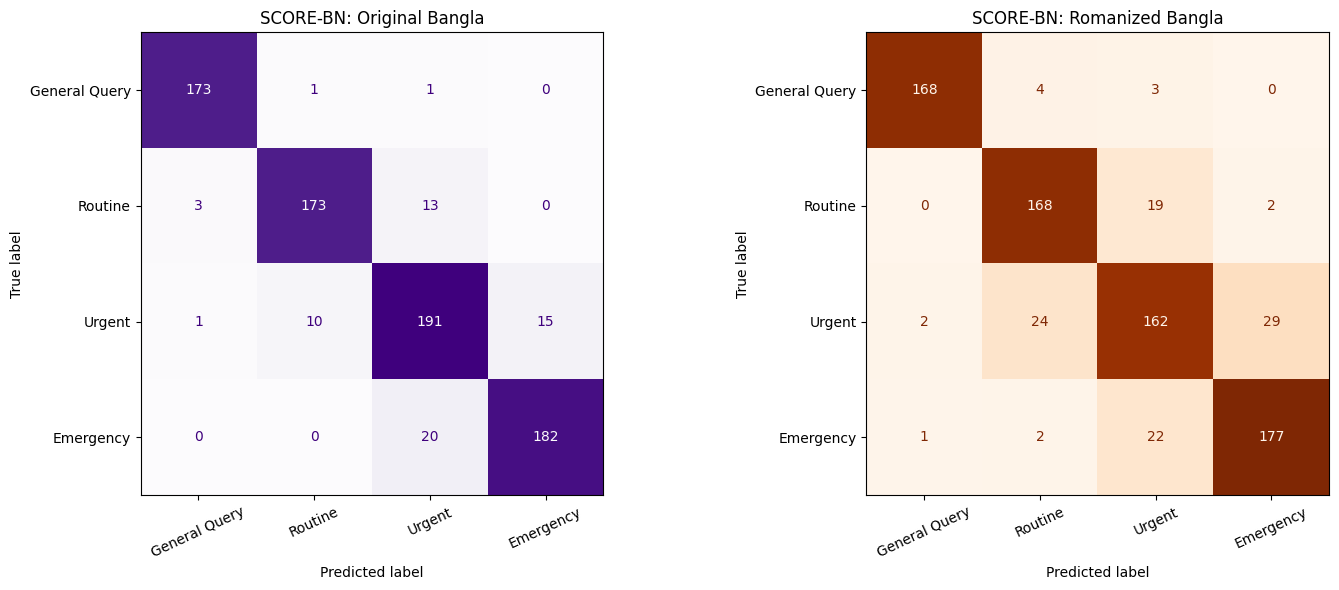


Section 21 completed.
Metrics saved to: /content/drive/MyDrive/SCORE_BN_Checkpoints/score_bn/test_metrics.json
Error-analysis file saved to: /content/drive/MyDrive/SCORE_BN_Checkpoints/score_bn/test_predictions_and_errors.csv


In [26]:
# ============================================================
# SECTION 21: SCORE-BN TEST AND CROSS-SCRIPT EVALUATION
# ============================================================

import json
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    cohen_kappa_score
)

# ------------------------------------------------------------
# 1. Load the best SCORE-BN model
# ------------------------------------------------------------

BEST_MODEL_PATH = (
    BACKUP_DIR /
    'score_bn' /
    'best_score_bn.pt'
)

if not BEST_MODEL_PATH.exists():
    raise FileNotFoundError(
        f"Best model not found: {BEST_MODEL_PATH}"
    )

best_model_weights = torch.load(
    BEST_MODEL_PATH,
    map_location=device
)

score_model.load_state_dict(
    best_model_weights
)

score_model.to(device)
score_model.eval()

print("Best SCORE-BN model loaded:")
print(BEST_MODEL_PATH)

# ------------------------------------------------------------
# 2. Prepare original and Romanized test texts
# ------------------------------------------------------------

original_texts = (
    test_df['text']
    .fillna('')
    .astype(str)
    .tolist()
)

romanized_texts = [
    romanize_bangla(text)
    for text in original_texts
]

y_test = (
    test_df['label']
    .astype(int)
    .to_numpy()
)

print("Test samples:", len(original_texts))
print("Romanized samples:", len(romanized_texts))

# ------------------------------------------------------------
# 3. Memory-safe prediction function
# ------------------------------------------------------------

def score_predict(
    texts,
    batch_size=16
):

    score_model.eval()
    all_probabilities = []

    with torch.no_grad():

        for start in range(
            0,
            len(texts),
            batch_size
        ):

            batch_texts = texts[
                start:
                start + batch_size
            ]

            encoded_batch = tokenizer(
                batch_texts,
                padding=True,
                truncation=True,
                max_length=128,
                return_tensors='pt'
            )

            encoded_batch = {
                key: value.to(device)
                for key, value
                in encoded_batch.items()
            }

            with torch.autocast(
                device_type='cuda',
                dtype=torch.float16,
                enabled=torch.cuda.is_available()
            ):

                logits, _ = score_model(
                    encoded_batch
                )

            probabilities = F.softmax(
                logits.float(),
                dim=-1
            )

            all_probabilities.append(
                probabilities
                .cpu()
                .numpy()
            )

    return np.vstack(
        all_probabilities
    )

# ------------------------------------------------------------
# 4. Generate predictions
# ------------------------------------------------------------

print("\nPredicting original test queries...")

score_probabilities = score_predict(
    original_texts
)

score_predictions = (
    score_probabilities.argmax(
        axis=1
    )
)

print("Predicting Romanized test queries...")

romanized_probabilities = score_predict(
    romanized_texts
)

romanized_predictions = (
    romanized_probabilities.argmax(
        axis=1
    )
)

print("Predictions completed.")

# Keep notebook-compatible variable names
score_prob = score_probabilities
score_pred = score_predictions
roman_prob = romanized_probabilities
roman_pred = romanized_predictions

# ------------------------------------------------------------
# 5. Calculate evaluation metrics
# ------------------------------------------------------------

precision, recall, macro_f1, _ = (
    precision_recall_fscore_support(
        y_test,
        score_predictions,
        average='macro',
        zero_division=0
    )
)

ordinal_mae = np.abs(
    y_test -
    score_predictions
).mean()

under_prioritisation_rate = (
    score_predictions <
    y_test
).mean()

over_prioritisation_rate = (
    score_predictions >
    y_test
).mean()

severe_error_rate = (
    np.abs(
        y_test -
        score_predictions
    )
    >= 2
).mean()

cross_script_agreement = (
    score_predictions
    ==
    romanized_predictions
).mean()

romanized_accuracy = accuracy_score(
    y_test,
    romanized_predictions
)

romanized_precision, romanized_recall, romanized_f1, _ = (
    precision_recall_fscore_support(
        y_test,
        romanized_predictions,
        average='macro',
        zero_division=0
    )
)

try:

    original_roc_auc = roc_auc_score(
        y_test,
        score_probabilities,
        multi_class='ovr',
        average='macro'
    )

except ValueError:

    original_roc_auc = float('nan')

try:

    romanized_roc_auc = roc_auc_score(
        y_test,
        romanized_probabilities,
        multi_class='ovr',
        average='macro'
    )

except ValueError:

    romanized_roc_auc = float('nan')

quadratic_weighted_kappa = (
    cohen_kappa_score(
        y_test,
        score_predictions,
        weights='quadratic'
    )
)

score_metrics = {
    'accuracy': accuracy_score(
        y_test,
        score_predictions
    ),
    'macro_precision': precision,
    'macro_recall': recall,
    'macro_f1': macro_f1,
    'roc_auc_ovr': original_roc_auc,
    'ordinal_mae': ordinal_mae,
    'under_prioritisation_rate': (
        under_prioritisation_rate
    ),
    'over_prioritisation_rate': (
        over_prioritisation_rate
    ),
    'severe_error_rate': (
        severe_error_rate
    ),
    'quadratic_weighted_kappa': (
        quadratic_weighted_kappa
    ),
    'cross_script_agreement': (
        cross_script_agreement
    ),
    'romanized_accuracy': (
        romanized_accuracy
    ),
    'romanized_macro_precision': (
        romanized_precision
    ),
    'romanized_macro_recall': (
        romanized_recall
    ),
    'romanized_macro_f1': (
        romanized_f1
    ),
    'romanized_roc_auc_ovr': (
        romanized_roc_auc
    )
}

# ------------------------------------------------------------
# 6. Display results
# ------------------------------------------------------------

print("\nSCORE-BN evaluation results:")

score_metrics_df = (
    pd.Series(
        score_metrics,
        name='SCORE-BN'
    )
    .to_frame(
        name='value'
    )
)

display(score_metrics_df)

class_names = [
    ID2LABEL[index]
    for index in range(4)
]

print(
    "\nClassification report "
    "for original test queries:\n"
)

print(
    classification_report(
        y_test,
        score_predictions,
        labels=[0, 1, 2, 3],
        target_names=class_names,
        zero_division=0,
        digits=4
    )
)

print(
    "\nClassification report "
    "for Romanized test queries:\n"
)

print(
    classification_report(
        y_test,
        romanized_predictions,
        labels=[0, 1, 2, 3],
        target_names=class_names,
        zero_division=0,
        digits=4
    )
)

# ------------------------------------------------------------
# 7. Confusion matrices
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 6)
)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    score_predictions,
    labels=[0, 1, 2, 3],
    display_labels=class_names,
    cmap='Purples',
    ax=axes[0],
    colorbar=False
)

axes[0].set_title(
    'SCORE-BN: Original Bangla'
)

axes[0].tick_params(
    axis='x',
    rotation=25
)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    romanized_predictions,
    labels=[0, 1, 2, 3],
    display_labels=class_names,
    cmap='Oranges',
    ax=axes[1],
    colorbar=False
)

axes[1].set_title(
    'SCORE-BN: Romanized Bangla'
)

axes[1].tick_params(
    axis='x',
    rotation=25
)

plt.tight_layout()

CONFUSION_FIGURE_PATH = (
    BACKUP_DIR /
    'score_bn' /
    'score_bn_confusion_matrices.png'
)

plt.savefig(
    CONFUSION_FIGURE_PATH,
    dpi=200,
    bbox_inches='tight'
)

plt.show()

# ------------------------------------------------------------
# 8. Save predictions for error analysis
# ------------------------------------------------------------

prediction_results = pd.DataFrame({
    'text': original_texts,
    'romanized_text': romanized_texts,
    'true_label_id': y_test,
    'true_label': [
        ID2LABEL[int(label)]
        for label in y_test
    ],
    'original_prediction_id': (
        score_predictions
    ),
    'original_prediction': [
        ID2LABEL[int(label)]
        for label in score_predictions
    ],
    'romanized_prediction_id': (
        romanized_predictions
    ),
    'romanized_prediction': [
        ID2LABEL[int(label)]
        for label
        in romanized_predictions
    ],
    'cross_script_agreement': (
        score_predictions
        ==
        romanized_predictions
    ),
    'ordinal_error': (
        np.abs(
            y_test -
            score_predictions
        )
    ),
    'under_prioritised': (
        score_predictions <
        y_test
    )
})

for class_index in range(4):

    prediction_results[
        f'probability_{ID2LABEL[class_index]}'
    ] = score_probabilities[
        :,
        class_index
    ]

prediction_results.to_csv(
    BACKUP_DIR /
    'score_bn' /
    'test_predictions_and_errors.csv',
    index=False,
    encoding='utf-8-sig'
)

np.save(
    BACKUP_DIR /
    'score_bn' /
    'original_test_probabilities.npy',
    score_probabilities
)

np.save(
    BACKUP_DIR /
    'score_bn' /
    'romanized_test_probabilities.npy',
    romanized_probabilities
)

# ------------------------------------------------------------
# 9. Save metrics
# ------------------------------------------------------------

serializable_metrics = {
    key: float(value)
    for key, value
    in score_metrics.items()
}

with open(
    BACKUP_DIR /
    'score_bn' /
    'test_metrics.json',
    'w',
    encoding='utf-8'
) as file:

    json.dump(
        serializable_metrics,
        file,
        indent=2
    )

print("\nSection 21 completed.")

print(
    "Metrics saved to:",
    BACKUP_DIR /
    'score_bn' /
    'test_metrics.json'
)

print(
    "Error-analysis file saved to:",
    BACKUP_DIR /
    'score_bn' /
    'test_predictions_and_errors.csv'
)

## 22. Ablation study — T4 GPU

For the final project, rerun SCORE-BN with these settings and record each result:

| Run | `lambda_cons` | `lambda_under` |
|---|---:|---:|
| Standard classifier | 0.0 | 0.0 |
| Consistency only | 0.5 | 0.0 |
| Risk only | 0.0 | 0.3 |
| Full SCORE-BN | 0.5 | 0.3 |

For a defensible conference extension, run at least five random seeds and bootstrap confidence intervals. The training cell can be placed inside a function and called for each configuration.

## 23. LIME explainability — CPU or T4

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 8.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator TfidfTransformer from version 1.9.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator TfidfVectorizer from version 1.9.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator FeatureUnion from version 1.9.0 when using version 1.6.1. This might lead to breaking code or

TF-IDF extractor loaded successfully.
Tuned XGBoost model loaded successfully.
Example index: 0
True class: Urgent
Predicted class: Urgent

Influential words and weights:
করতেছে।: 0.2447
জ্বালাপোড়া: -0.2309
আর: 0.1080
টনটন: 0.0707
করে: -0.0498
কাছটা: 0.0431
কয়েকদিন: 0.0293
ধরে: 0.0245
টক: -0.0235
গলার: 0.0109
বুক: -0.0057
ওঠে,: -0.0051


/tmp/ipykernel_817/940480164.py:258: UserWarning: Glyph 2451 (\N{BENGALI LETTER O}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_817/940480164.py:258: UserWarning: Matplotlib currently does not support Bengali natively.
  plt.tight_layout()
/tmp/ipykernel_817/940480164.py:258: UserWarning: Glyph 2464 (\N{BENGALI LETTER TTHA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_817/940480164.py:258: UserWarning: Glyph 2503 (\N{BENGALI VOWEL SIGN E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_817/940480164.py:258: UserWarning: Glyph 2476 (\N{BENGALI LETTER BA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_817/940480164.py:258: UserWarning: Glyph 2497 (\N{BENGALI VOWEL SIGN U}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_817/940480164.py:258: UserWarning: Glyph 2453 (\N{BENGALI LETTER KA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_817/9404801

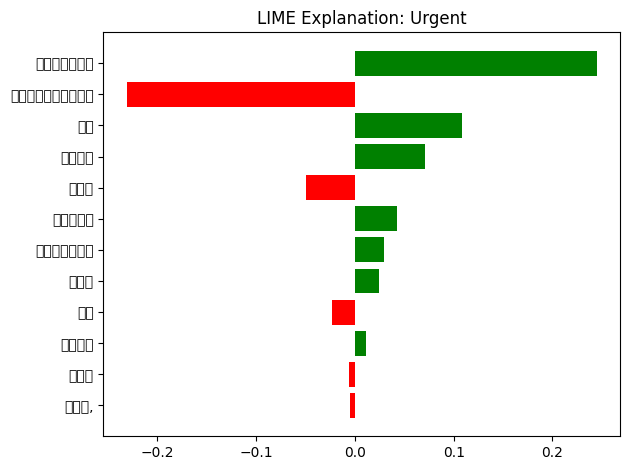


LIME explanation completed.
HTML explanation saved to: /content/drive/MyDrive/SCORE_BN_Checkpoints/explainability/lime_example.html
Figure saved to: /content/drive/MyDrive/SCORE_BN_Checkpoints/explainability/lime_example.png


In [27]:
# ============================================================
# SECTION 23: LIME EXPLAINABILITY
# ============================================================

!pip -q install lime

import re
import unicodedata
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from lime.lime_text import LimeTextExplainer

# ------------------------------------------------------------
# 1. Output directory
# ------------------------------------------------------------

XAI_DIR = (
    BACKUP_DIR /
    'explainability'
)

XAI_DIR.mkdir(
    parents=True,
    exist_ok=True
)

# ------------------------------------------------------------
# 2. Reload TF-IDF features and tuned XGBoost
# ------------------------------------------------------------

TFIDF_PATH = (
    BACKUP_DIR /
    'tfidf_features.joblib'
)

XGBOOST_PATH = (
    BACKUP_DIR /
    'tuned_xgboost.joblib'
)

if not TFIDF_PATH.exists():
    raise FileNotFoundError(
        f"TF-IDF file not found: {TFIDF_PATH}"
    )

if not XGBOOST_PATH.exists():
    raise FileNotFoundError(
        f"XGBoost model not found: {XGBOOST_PATH}"
    )

features = joblib.load(
    TFIDF_PATH
)

lime_model = joblib.load(
    XGBOOST_PATH
)

print(
    "TF-IDF extractor loaded successfully."
)

print(
    "Tuned XGBoost model loaded successfully."
)

# ------------------------------------------------------------
# 3. Define the same classical preprocessing
# ------------------------------------------------------------

def clean_classical(text):

    text = unicodedata.normalize(
        'NFKC',
        str(text)
    )

    text = re.sub(
        r'https?://\S+|www\.\S+',
        ' URL ',
        text
    )

    text = re.sub(
        r'@[A-Za-z0-9_]+',
        ' USER ',
        text
    )

    text = re.sub(
        r'\s+',
        ' ',
        text
    )

    return text.strip().lower()

# ------------------------------------------------------------
# 4. LIME prediction function
# ------------------------------------------------------------

def classical_predict_proba(
    text_list
):

    cleaned_texts = [
        clean_classical(text)
        for text in text_list
    ]

    transformed_texts = (
        features.transform(
            cleaned_texts
        )
    )

    probabilities = (
        lime_model.predict_proba(
            transformed_texts
        )
    )

    return probabilities

# ------------------------------------------------------------
# 5. Class names
# ------------------------------------------------------------

class_names = [
    ID2LABEL[index]
    for index in range(4)
]

explainer = LimeTextExplainer(
    class_names=class_names,
    split_expression=r'\s+',
    random_state=SEED
)

# ------------------------------------------------------------
# 6. Select one correctly classified example
# ------------------------------------------------------------

all_classical_probabilities = (
    classical_predict_proba(
        test_df['text']
        .fillna('')
        .astype(str)
        .tolist()
    )
)

all_classical_predictions = (
    all_classical_probabilities.argmax(
        axis=1
    )
)

true_labels = (
    test_df['label']
    .astype(int)
    .to_numpy()
)

correct_indices = np.where(
    all_classical_predictions
    ==
    true_labels
)[0]

if len(correct_indices) > 0:
    example_index = int(
        correct_indices[0]
    )
else:
    example_index = 0

example_text = str(
    test_df.iloc[
        example_index
    ]['text']
)

true_label_id = int(
    test_df.iloc[
        example_index
    ]['label']
)

predicted_label_id = int(
    all_classical_predictions[
        example_index
    ]
)

print(
    "Example index:",
    example_index
)

print(
    "True class:",
    ID2LABEL[
        true_label_id
    ]
)

print(
    "Predicted class:",
    ID2LABEL[
        predicted_label_id
    ]
)

# ------------------------------------------------------------
# 7. Generate LIME explanation
# ------------------------------------------------------------

explanation = (
    explainer.explain_instance(
        example_text,
        classical_predict_proba,
        labels=[
            predicted_label_id
        ],
        num_features=12,
        num_samples=500
    )
)

print(
    "\nInfluential words and weights:"
)

for word, weight in explanation.as_list(
    label=predicted_label_id
):
    print(
        f"{word}: {weight:.4f}"
    )

# ------------------------------------------------------------
# 8. Plot the explanation
# ------------------------------------------------------------

figure = explanation.as_pyplot_figure(
    label=predicted_label_id
)

plt.title(
    "LIME Explanation: "
    f"{ID2LABEL[predicted_label_id]}"
)

plt.tight_layout()

LIME_FIGURE_PATH = (
    XAI_DIR /
    'lime_example.png'
)

plt.savefig(
    LIME_FIGURE_PATH,
    dpi=200,
    bbox_inches='tight'
)

plt.show()

# ------------------------------------------------------------
# 9. Save interactive HTML explanation
# ------------------------------------------------------------

LIME_HTML_PATH = (
    XAI_DIR /
    'lime_example.html'
)

explanation.save_to_file(
    str(LIME_HTML_PATH)
)

# ------------------------------------------------------------
# 10. Save explanation values as CSV
# ------------------------------------------------------------

lime_values = pd.DataFrame(
    explanation.as_list(
        label=predicted_label_id
    ),
    columns=[
        'word_or_phrase',
        'importance_weight'
    ]
)

lime_values[
    'true_class'
] = ID2LABEL[
    true_label_id
]

lime_values[
    'predicted_class'
] = ID2LABEL[
    predicted_label_id
]

lime_values.to_csv(
    XAI_DIR /
    'lime_feature_weights.csv',
    index=False,
    encoding='utf-8-sig'
)

print("\nLIME explanation completed.")

print(
    "HTML explanation saved to:",
    LIME_HTML_PATH
)

print(
    "Figure saved to:",
    LIME_FIGURE_PATH
)

## 24. SHAP global interpretation — CPU

This explains a linear SVM/logistic-style TF-IDF model. Limit samples to keep Colab memory manageable.

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator MultinomialNB from version 1.9.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from version 1.9.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator LinearSVC from version 1.9.0 when using version 1.6.1. This might lead to breaking code or in

Available classical models: ['MultinomialNB', 'LogisticRegression', 'LinearSVM', 'RandomForest', 'XGBoost']
Training matrix: (3650, 21292)
Test matrix: (783, 21292)
Number of TF-IDF features: 21292
Background samples: 200
Explained test samples: 100

Calculating SHAP values...
SHAP value shape: (100, 21292, 4)


/tmp/ipykernel_817/2379953176.py:242: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:1150: UserWarning: Glyph 2488 (\N{BENGALI LETTER SA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:1150: UserWarning: Matplotlib currently does not support Bengali natively.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:1150: UserWarning: Glyph 2478 (\N{BENGALI LETTER MA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:1150: UserWarning: Glyph 2480 (\N{BENGALI LETTER RA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-package

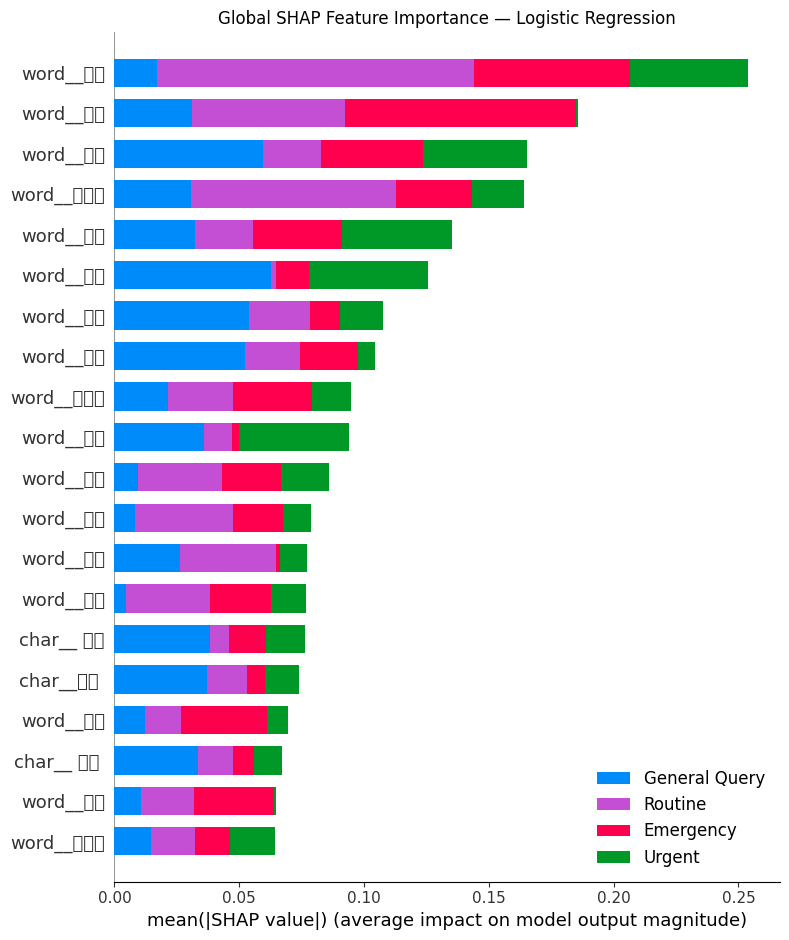

,class_id,class_name,rank,feature,coefficient
0,0,General Query,1,word__জন,2.139544
1,0,General Query,2,char__কি,2.049220
2,0,General Query,3,char__ কি,1.952940
3,0,General Query,4,char__ কি,1.674696
4,0,General Query,5,word__তথ,1.546433
5,0,General Query,6,word__ওয,1.382587
6,0,General Query,7,word__এট,1.338314
7,0,General Query,8,word__উপ,1.226381
8,0,General Query,9,word__রণ,1.209511
9,0,General Query,10,char__ কেন,1.137975



SHAP analysis completed.
SHAP figure saved to: /content/drive/MyDrive/SCORE_BN_Checkpoints/explainability/shap_global_summary.png
Feature table saved to: /content/drive/MyDrive/SCORE_BN_Checkpoints/explainability/logistic_regression_top_features.csv


In [28]:
# ============================================================
# SECTION 24: SHAP GLOBAL EXPLAINABILITY
# ============================================================

!pip -q install shap

import gc
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

# ------------------------------------------------------------
# 1. Output directory
# ------------------------------------------------------------

XAI_DIR = (
    BACKUP_DIR /
    'explainability'
)

XAI_DIR.mkdir(
    parents=True,
    exist_ok=True
)

# ------------------------------------------------------------
# 2. Reload saved classical models
# ------------------------------------------------------------

CLASSICAL_MODELS_PATH = (
    BACKUP_DIR /
    'classical_models.joblib'
)

TRANSFORMED_DATA_PATH = (
    BACKUP_DIR /
    'transformed_data.joblib'
)

TFIDF_PATH = (
    BACKUP_DIR /
    'tfidf_features.joblib'
)

if not CLASSICAL_MODELS_PATH.exists():
    raise FileNotFoundError(
        f"Classical models not found: "
        f"{CLASSICAL_MODELS_PATH}"
    )

if not TRANSFORMED_DATA_PATH.exists():
    raise FileNotFoundError(
        f"Transformed data not found: "
        f"{TRANSFORMED_DATA_PATH}"
    )

if not TFIDF_PATH.exists():
    raise FileNotFoundError(
        f"TF-IDF features not found: "
        f"{TFIDF_PATH}"
    )

trained_models = joblib.load(
    CLASSICAL_MODELS_PATH
)

transformed_data = joblib.load(
    TRANSFORMED_DATA_PATH
)

features = joblib.load(
    TFIDF_PATH
)

print(
    "Available classical models:",
    list(trained_models.keys())
)

# ------------------------------------------------------------
# 3. Retrieve Logistic Regression and TF-IDF matrices
# ------------------------------------------------------------

if (
    'LogisticRegression'
    not in trained_models
):
    raise KeyError(
        "LogisticRegression is missing from "
        "classical_models.joblib."
    )

lr_model = trained_models[
    'LogisticRegression'
]

Xtr = transformed_data[
    'Xtr'
]

Xte = transformed_data[
    'Xte'
]

y_test_shap = np.asarray(
    transformed_data[
        'y_test'
    ]
)

feature_names = (
    features.get_feature_names_out()
)

print("Training matrix:", Xtr.shape)
print("Test matrix:", Xte.shape)
print(
    "Number of TF-IDF features:",
    len(feature_names)
)

# ------------------------------------------------------------
# 4. Select memory-safe SHAP samples
# ------------------------------------------------------------

# Use a small background sample to keep memory usage low.
rng = np.random.default_rng(
    SEED
)

background_size = min(
    200,
    Xtr.shape[0]
)

explanation_size = min(
    100,
    Xte.shape[0]
)

background_indices = rng.choice(
    Xtr.shape[0],
    size=background_size,
    replace=False
)

explanation_indices = np.arange(
    explanation_size
)

background = Xtr[
    background_indices
]

explain_X = Xte[
    explanation_indices
]

print(
    "Background samples:",
    background.shape[0]
)

print(
    "Explained test samples:",
    explain_X.shape[0]
)

# ------------------------------------------------------------
# 5. Calculate SHAP values
# ------------------------------------------------------------

print("\nCalculating SHAP values...")

shap_explainer = shap.LinearExplainer(
    lr_model,
    background
)

shap_explanation = shap_explainer(
    explain_X
)

print(
    "SHAP value shape:",
    shap_explanation.values.shape
)

# ------------------------------------------------------------
# 6. Prepare multiclass SHAP values
# ------------------------------------------------------------

shap_array = (
    shap_explanation.values
)

class_names = [
    ID2LABEL[index]
    for index in range(4)
]

# Different SHAP versions can return multiclass values
# in different formats.
if shap_array.ndim == 3:

    # Expected shape:
    # samples × features × classes
    shap_values_for_plot = [
        shap_array[
            :,
            :,
            class_index
        ]
        for class_index in range(
            shap_array.shape[2]
        )
    ]

elif shap_array.ndim == 2:

    shap_values_for_plot = (
        shap_array
    )

else:

    raise ValueError(
        f"Unexpected SHAP shape: "
        f"{shap_array.shape}"
    )

# ------------------------------------------------------------
# 7. Create global SHAP summary plot
# ------------------------------------------------------------

plt.figure(
    figsize=(12, 8)
)

shap.summary_plot(
    shap_values_for_plot,
    explain_X,
    feature_names=feature_names,
    class_names=class_names,
    max_display=20,
    plot_type='bar',
    show=False
)

plt.title(
    'Global SHAP Feature Importance — '
    'Logistic Regression'
)

plt.tight_layout()

SHAP_SUMMARY_PATH = (
    XAI_DIR /
    'shap_global_summary.png'
)

plt.savefig(
    SHAP_SUMMARY_PATH,
    dpi=200,
    bbox_inches='tight'
)

plt.show()

# ------------------------------------------------------------
# 8. Save coefficient-based feature table
# ------------------------------------------------------------

# Logistic-regression coefficients provide a useful
# tabular companion to the SHAP plot.

coefficient_rows = []

for class_index in range(
    lr_model.coef_.shape[0]
):

    coefficients = (
        lr_model.coef_[
            class_index
        ]
    )

    top_positive_indices = np.argsort(
        coefficients
    )[-20:][::-1]

    for rank, feature_index in enumerate(
        top_positive_indices,
        start=1
    ):

        coefficient_rows.append({
            'class_id': class_index,
            'class_name': (
                ID2LABEL[class_index]
            ),
            'rank': rank,
            'feature': (
                feature_names[
                    feature_index
                ]
            ),
            'coefficient': float(
                coefficients[
                    feature_index
                ]
            )
        })

coefficient_table = pd.DataFrame(
    coefficient_rows
)

coefficient_table.to_csv(
    XAI_DIR /
    'logistic_regression_top_features.csv',
    index=False,
    encoding='utf-8-sig'
)

display(
    coefficient_table.groupby(
        'class_name'
    ).head(10)
)

print("\nSHAP analysis completed.")

print(
    "SHAP figure saved to:",
    SHAP_SUMMARY_PATH
)

print(
    "Feature table saved to:",
    XAI_DIR /
    'logistic_regression_top_features.csv'
)

## 25. Combined comparison table and exports — CPU

In [29]:
# ============================================================
# SECTION 25: COMBINE AND SAVE ALL MODEL RESULTS
# ============================================================

import json
import joblib
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    roc_auc_score
)

# ------------------------------------------------------------
# 1. Output directory
# ------------------------------------------------------------

FINAL_RESULTS_DIR = (
    BACKUP_DIR /
    'final_results'
)

FINAL_RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

# ------------------------------------------------------------
# 2. Reload transformed test data
# ------------------------------------------------------------

transformed_data = joblib.load(
    BACKUP_DIR /
    'transformed_data.joblib'
)

Xte = transformed_data['Xte']
y_test = np.asarray(
    transformed_data['y_test']
)

# ------------------------------------------------------------
# 3. Reload and evaluate original classical models
# ------------------------------------------------------------

trained_models = joblib.load(
    BACKUP_DIR /
    'classical_models.joblib'
)

classical_result_rows = []

for model_name, model in trained_models.items():

    print(
        "Evaluating:",
        model_name
    )

    predictions = model.predict(
        Xte
    )

    precision, recall, f1, _ = (
        precision_recall_fscore_support(
            y_test,
            predictions,
            average='macro',
            zero_division=0
        )
    )

    result = {
        'model': model_name,
        'stage': 'Baseline',
        'accuracy': accuracy_score(
            y_test,
            predictions
        ),
        'macro_precision': precision,
        'macro_recall': recall,
        'macro_f1': f1,
        'roc_auc_ovr': np.nan
    }

    # Probability-based ROC-AUC
    if hasattr(
        model,
        'predict_proba'
    ):

        try:

            probabilities = (
                model.predict_proba(
                    Xte
                )
            )

            result[
                'roc_auc_ovr'
            ] = roc_auc_score(
                y_test,
                probabilities,
                multi_class='ovr',
                average='macro'
            )

        except Exception as error:

            print(
                f"ROC-AUC unavailable for "
                f"{model_name}: {error}"
            )

    classical_result_rows.append(
        result
    )

classical_results_df = pd.DataFrame(
    classical_result_rows
)

# ------------------------------------------------------------
# 4. Reload tuned classical results
# ------------------------------------------------------------

TUNED_RESULTS_PATH = (
    BACKUP_DIR /
    'tuned_model_results.csv'
)

if TUNED_RESULTS_PATH.exists():

    tuned_results_df = pd.read_csv(
        TUNED_RESULTS_PATH
    )

    tuned_results_df[
        'stage'
    ] = 'Tuned'

else:

    print(
        "Warning: tuned_model_results.csv "
        "was not found."
    )

    tuned_results_df = pd.DataFrame()

# ------------------------------------------------------------
# 5. Reload CNN, BiLSTM and BiGRU results
# ------------------------------------------------------------

DEEP_RESULTS_PATH = (
    BACKUP_DIR /
    'deep_model_results.csv'
)

if DEEP_RESULTS_PATH.exists():

    deep_results_df = pd.read_csv(
        DEEP_RESULTS_PATH
    )

    deep_results_df[
        'stage'
    ] = 'Deep Learning'

else:

    print(
        "Warning: deep_model_results.csv "
        "was not found."
    )

    deep_results_df = pd.DataFrame()

# ------------------------------------------------------------
# 6. Reload SCORE-BN test results
# ------------------------------------------------------------

SCORE_METRICS_PATH = (
    BACKUP_DIR /
    'score_bn' /
    'test_metrics.json'
)

if SCORE_METRICS_PATH.exists():

    with open(
        SCORE_METRICS_PATH,
        'r',
        encoding='utf-8'
    ) as file:

        score_metrics = json.load(
            file
        )

    score_results_df = pd.DataFrame([
        {
            'model': 'SCORE-BN',
            'stage': 'Proposed Model',
            **score_metrics
        }
    ])

else:

    print(
        "Warning: SCORE-BN test metrics "
        "were not found."
    )

    score_results_df = pd.DataFrame()

# ------------------------------------------------------------
# 7. Try to reload BanglaBERT baseline metrics
# ------------------------------------------------------------

baseline_metric_files = list(
    BACKUP_DIR.rglob(
        'banglabert_baseline/test_metrics.json'
    )
)

banglabert_results_df = pd.DataFrame()

if baseline_metric_files:

    with open(
        baseline_metric_files[0],
        'r',
        encoding='utf-8'
    ) as file:

        raw_bert_metrics = json.load(
            file
        )

    banglabert_row = {
        'model': 'BanglaBERT',
        'stage': 'Transformer Baseline',
        'accuracy': raw_bert_metrics.get(
            'eval_accuracy',
            raw_bert_metrics.get(
                'accuracy',
                np.nan
            )
        ),
        'macro_precision': (
            raw_bert_metrics.get(
                'eval_macro_precision',
                raw_bert_metrics.get(
                    'macro_precision',
                    np.nan
                )
            )
        ),
        'macro_recall': (
            raw_bert_metrics.get(
                'eval_macro_recall',
                raw_bert_metrics.get(
                    'macro_recall',
                    np.nan
                )
            )
        ),
        'macro_f1': (
            raw_bert_metrics.get(
                'eval_macro_f1',
                raw_bert_metrics.get(
                    'macro_f1',
                    np.nan
                )
            )
        ),
        'roc_auc_ovr': (
            raw_bert_metrics.get(
                'eval_roc_auc_ovr',
                raw_bert_metrics.get(
                    'roc_auc_ovr',
                    np.nan
                )
            )
        )
    }

    banglabert_results_df = (
        pd.DataFrame(
            [banglabert_row]
        )
    )

else:

    print(
        "Note: BanglaBERT baseline metrics "
        "file was not found. Other results "
        "will still be combined."
    )

# ------------------------------------------------------------
# 8. Combine available result tables
# ------------------------------------------------------------

available_tables = [
    table
    for table in [
        classical_results_df,
        tuned_results_df,
        deep_results_df,
        banglabert_results_df,
        score_results_df
    ]
    if not table.empty
]

all_results = pd.concat(
    available_tables,
    ignore_index=True,
    sort=False
)

# Arrange the important columns first
important_columns = [
    'model',
    'stage',
    'accuracy',
    'macro_precision',
    'macro_recall',
    'macro_f1',
    'roc_auc_ovr',
    'ordinal_mae',
    'under_prioritisation_rate',
    'severe_error_rate',
    'cross_script_agreement',
    'romanized_macro_f1'
]

ordered_columns = [
    column
    for column in important_columns
    if column in all_results.columns
]

remaining_columns = [
    column
    for column in all_results.columns
    if column not in ordered_columns
]

all_results = all_results[
    ordered_columns
    +
    remaining_columns
]

all_results = all_results.sort_values(
    by='macro_f1',
    ascending=False,
    na_position='last'
).reset_index(drop=True)

print(
    "\nFinal model comparison:"
)

display(
    all_results.round(4)
)

# ------------------------------------------------------------
# 9. Save final model-comparison table
# ------------------------------------------------------------

MODEL_COMPARISON_PATH = (
    FINAL_RESULTS_DIR /
    'model_comparison.csv'
)

all_results.to_csv(
    MODEL_COMPARISON_PATH,
    index=False,
    encoding='utf-8-sig'
)

# ------------------------------------------------------------
# 10. Save label mapping
# ------------------------------------------------------------

with open(
    FINAL_RESULTS_DIR /
    'label_mapping.json',
    'w',
    encoding='utf-8'
) as file:

    json.dump(
        LABEL2ID,
        file,
        indent=2
    )

# ------------------------------------------------------------
# 11. Reconstruct and save the cleaned dataset
# ------------------------------------------------------------

clean_dataset = pd.concat(
    [
        train_df.assign(
            split='train'
        ),
        val_df.assign(
            split='validation'
        ),
        test_df.assign(
            split='test'
        )
    ],
    ignore_index=True
)

columns_to_save = [
    column
    for column in [
        'text',
        'label',
        'label_name',
        'split'
    ]
    if column in clean_dataset.columns
]

clean_dataset[
    columns_to_save
].to_csv(
    FINAL_RESULTS_DIR /
    'clean_dataset_with_splits.csv',
    index=False,
    encoding='utf-8-sig'
)

# ------------------------------------------------------------
# 12. Save final dataset audit
# ------------------------------------------------------------

dataset_audit = {
    'original_dataset_samples': 5263,
    'clean_samples_used': int(
        len(clean_dataset)
    ),
    'training_samples': int(
        len(train_df)
    ),
    'validation_samples': int(
        len(val_df)
    ),
    'test_samples': int(
        len(test_df)
    ),
    'input_column': 'Text',
    'target_column': 'Categories',
    'excluded_leakage_column': (
        'Action Needed'
    ),
    'number_of_classes': 4,
    'label_mapping': LABEL2ID,
    'split_ratio': '70/15/15',
    'duplicate_safe_split': True
}

with open(
    FINAL_RESULTS_DIR /
    'dataset_audit.json',
    'w',
    encoding='utf-8'
) as file:

    json.dump(
        dataset_audit,
        file,
        indent=2
    )

print(
    "\nSection 25 completed."
)

print(
    "Model comparison saved to:",
    MODEL_COMPARISON_PATH
)

print(
    "Clean dataset saved to:",
    FINAL_RESULTS_DIR /
    'clean_dataset_with_splits.csv'
)

print(
    "Dataset audit saved to:",
    FINAL_RESULTS_DIR /
    'dataset_audit.json'
)

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator MultinomialNB from version 1.9.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from version 1.9.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator LinearSVC from version 1.9.0 when using version 1.6.1. This might lead to breaking code or in

Evaluating: MultinomialNB
Evaluating: LogisticRegression
ROC-AUC unavailable for LogisticRegression: 'LogisticRegression' object has no attribute 'multi_class'
Evaluating: LinearSVM
Evaluating: RandomForest
Evaluating: XGBoost
Note: BanglaBERT baseline metrics file was not found. Other results will still be combined.

Final model comparison:


,model,stage,accuracy,macro_precision,macro_recall,macro_f1,roc_auc_ovr,ordinal_mae,under_prioritisation_rate,severe_error_rate,cross_script_agreement,romanized_macro_f1,training_minutes,epochs_completed,over_prioritisation_rate,quadratic_weighted_kappa,romanized_accuracy,romanized_macro_precision,romanized_macro_recall,romanized_roc_auc_ovr
0,SCORE-BN,Proposed Model,0.9183,0.9226,0.9213,0.9218,0.9872,0.0843,0.0434,0.0026,0.8812,0.8672,NaN,NaN,0.0383,0.9629,0.8621,0.8671,0.8679,0.9728
1,Tuned Linear SVM,Tuned,0.9170,0.9192,0.9203,0.9197,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,LinearSVM,Baseline,0.9157,0.9184,0.9190,0.9186,0.9841,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,CNN,Deep Learning,0.9157,0.9186,0.9188,0.9186,0.9870,NaN,NaN,NaN,NaN,NaN,0.1920,7.0,NaN,NaN,NaN,NaN,NaN,NaN
4,BiGRU,Deep Learning,0.9029,0.9053,0.9070,0.9060,0.9834,NaN,NaN,NaN,NaN,NaN,0.0949,4.0,NaN,NaN,NaN,NaN,NaN,NaN
5,LogisticRegression,Baseline,0.9017,0.9041,0.9063,0.9049,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,BiLSTM,Deep Learning,0.9017,0.9039,0.9070,0.9045,0.9779,NaN,NaN,NaN,NaN,NaN,0.1498,4.0,NaN,NaN,NaN,NaN,NaN,NaN
7,XGBoost,Baseline,0.8991,0.9016,0.9033,0.9023,0.9799,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,RandomForest,Baseline,0.8966,0.9000,0.9007,0.9003,0.9810,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,Tuned XGBoost,Tuned,0.8902,0.8925,0.8949,0.8935,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Section 25 completed.
Model comparison saved to: /content/drive/MyDrive/SCORE_BN_Checkpoints/final_results/model_comparison.csv
Clean dataset saved to: /content/drive/MyDrive/SCORE_BN_Checkpoints/final_results/clean_dataset_with_splits.csv
Dataset audit saved to: /content/drive/MyDrive/SCORE_BN_Checkpoints/final_results/dataset_audit.json


## 26. Streamlit research-demo application — CPU after training

In [35]:
# ============================================================
# SECTION 26A: PREPARE AND TEST APPLICATION ASSETS
# ============================================================

import re
import shutil
import unicodedata
import joblib
import numpy as np
import pandas as pd

from pathlib import Path

# ------------------------------------------------------------
# 1. Define paths
# ------------------------------------------------------------

BACKUP_DIR = Path(
    '/content/drive/MyDrive/SCORE_BN_Checkpoints'
)

APP_DIR = (
    BACKUP_DIR /
    'streamlit_app'
)

APP_DIR.mkdir(
    parents=True,
    exist_ok=True
)

TFIDF_SOURCE = (
    BACKUP_DIR /
    'tfidf_features.joblib'
)

XGBOOST_SOURCE = (
    BACKUP_DIR /
    'tuned_xgboost.joblib'
)

TFIDF_APP_PATH = (
    APP_DIR /
    'tfidf_features.joblib'
)

XGBOOST_APP_PATH = (
    APP_DIR /
    'tuned_xgboost.joblib'
)

# ------------------------------------------------------------
# 2. Check source files
# ------------------------------------------------------------

print(
    "TF-IDF file exists:",
    TFIDF_SOURCE.exists()
)

print(
    "XGBoost file exists:",
    XGBOOST_SOURCE.exists()
)

if not TFIDF_SOURCE.exists():
    raise FileNotFoundError(
        f"Missing file: {TFIDF_SOURCE}"
    )

if not XGBOOST_SOURCE.exists():
    raise FileNotFoundError(
        f"Missing file: {XGBOOST_SOURCE}"
    )

# ------------------------------------------------------------
# 3. Load saved assets
# ------------------------------------------------------------

feature_extractor = joblib.load(
    TFIDF_SOURCE
)

application_model = joblib.load(
    XGBOOST_SOURCE
)

# Force XGBoost to use CPU in the application.
# This makes deployment easier.
try:
    application_model.set_params(
        device='cpu'
    )
except Exception as error:
    print(
        "CPU-setting notice:",
        error
    )

print(
    "Feature extractor loaded:",
    type(feature_extractor)
)

print(
    "Model loaded:",
    type(application_model)
)

# ------------------------------------------------------------
# 4. Define the exact preprocessing function
# ------------------------------------------------------------

def clean_application_text(text):

    text = unicodedata.normalize(
        'NFKC',
        str(text)
    )

    text = re.sub(
        r'https?://\S+|www\.\S+',
        ' URL ',
        text
    )

    text = re.sub(
        r'@[A-Za-z0-9_]+',
        ' USER ',
        text
    )

    text = re.sub(
        r'\s+',
        ' ',
        text
    )

    return text.strip().lower()

# ------------------------------------------------------------
# 5. Test the model before creating Streamlit
# ------------------------------------------------------------

sample_query = str(
    test_df.iloc[0]['text']
)

cleaned_sample = clean_application_text(
    sample_query
)

sample_features = (
    feature_extractor.transform(
        [cleaned_sample]
    )
)

sample_probabilities = (
    application_model.predict_proba(
        sample_features
    )[0]
)

sample_prediction = int(
    sample_probabilities.argmax()
)

LABELS = {
    0: 'General Query',
    1: 'Routine',
    2: 'Urgent',
    3: 'Emergency'
}

print(
    "\nTest prediction:",
    LABELS[sample_prediction]
)

print(
    "Probabilities:",
    sample_probabilities
)

print(
    "Probability sum:",
    sample_probabilities.sum()
)

if len(sample_probabilities) != 4:
    raise ValueError(
        "Expected four class probabilities."
    )

if not np.isclose(
    sample_probabilities.sum(),
    1.0,
    atol=1e-4
):
    raise ValueError(
        "Probabilities do not sum to one."
    )

# ------------------------------------------------------------
# 6. Save CPU-compatible application assets
# ------------------------------------------------------------

joblib.dump(
    feature_extractor,
    TFIDF_APP_PATH
)

joblib.dump(
    application_model,
    XGBOOST_APP_PATH
)

print(
    "\nSECTION 26A COMPLETED"
)

print(
    "Application assets saved to:",
    APP_DIR
)

TF-IDF file exists: True
XGBoost file exists: True


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator TfidfTransformer from version 1.9.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator TfidfVectorizer from version 1.9.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator FeatureUnion from version 1.9.0 when using version 1.6.1. This might lead to breaking code or

Feature extractor loaded: <class 'sklearn.pipeline.FeatureUnion'>
Model loaded: <class 'xgboost.sklearn.XGBClassifier'>

Test prediction: Urgent
Probabilities: [0.00142775 0.24648242 0.7030316  0.04905827]
Probability sum: 1.0000001

SECTION 26A COMPLETED
Application assets saved to: /content/drive/MyDrive/SCORE_BN_Checkpoints/streamlit_app


In [36]:
# ============================================================
# SECTION 26B: CREATE APP.PY
# ============================================================

from pathlib import Path

APP_DIR = (
    BACKUP_DIR /
    'streamlit_app'
)

app_code = r'''
import re
import unicodedata
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import streamlit as st

# ============================================================
# Page configuration
# ============================================================

st.set_page_config(
    page_title=(
        "Bangla Healthcare Query "
        "Severity Classifier"
    ),
    page_icon="📝",
    layout="centered"
)

# ============================================================
# Custom CSS
# ============================================================

st.markdown(
    """
    <style>
    .main-title {
        font-size: 2.1rem;
        font-weight: 700;
        margin-bottom: 0.2rem;
    }

    .subtitle {
        color: #5f6368;
        margin-bottom: 1.2rem;
    }

    .result-box {
        padding: 1rem;
        border-radius: 0.7rem;
        border: 1px solid #d8dce3;
        background-color: #f8f9fb;
        margin-top: 1rem;
        margin-bottom: 1rem;
    }
    </style>
    """,
    unsafe_allow_html=True
)

st.markdown(
    """
    <div class="main-title">
    Bangla Healthcare Query Severity Classification
    </div>
    """,
    unsafe_allow_html=True
)

st.markdown(
    """
    <div class="subtitle">
    NLP research demonstration using real-world Bangla text
    </div>
    """,
    unsafe_allow_html=True
)

st.warning(
    "Research demonstration only. This application is not "
    "a medical diagnosis or clinical decision system. "
    "For actual health concerns, consult a qualified "
    "healthcare professional."
)

# ============================================================
# Paths and assets
# ============================================================

APP_DIRECTORY = Path(
    __file__
).resolve().parent

TFIDF_PATH = (
    APP_DIRECTORY /
    'tfidf_features.joblib'
)

MODEL_PATH = (
    APP_DIRECTORY /
    'tuned_xgboost.joblib'
)

@st.cache_resource
def load_assets():

    if not TFIDF_PATH.exists():
        raise FileNotFoundError(
            "tfidf_features.joblib is missing."
        )

    if not MODEL_PATH.exists():
        raise FileNotFoundError(
            "tuned_xgboost.joblib is missing."
        )

    extractor = joblib.load(
        TFIDF_PATH
    )

    classifier = joblib.load(
        MODEL_PATH
    )

    try:
        classifier.set_params(
            device='cpu'
        )
    except Exception:
        pass

    return extractor, classifier

try:

    feature_extractor, model = (
        load_assets()
    )

except Exception as error:

    st.error(
        "The application could not load "
        "the saved model files."
    )

    st.exception(
        error
    )

    st.stop()

# ============================================================
# Preprocessing
# ============================================================

def clean_text(text):

    text = unicodedata.normalize(
        'NFKC',
        str(text)
    )

    text = re.sub(
        r'https?://\S+|www\.\S+',
        ' URL ',
        text
    )

    text = re.sub(
        r'@[A-Za-z0-9_]+',
        ' USER ',
        text
    )

    text = re.sub(
        r'\s+',
        ' ',
        text
    )

    return text.strip().lower()

# ============================================================
# Labels
# ============================================================

LABELS = {
    0: 'General Query',
    1: 'Routine',
    2: 'Urgent',
    3: 'Emergency'
}

CLASS_ORDER = [
    'General Query',
    'Routine',
    'Urgent',
    'Emergency'
]

# ============================================================
# Example inputs
# ============================================================

example_option = st.selectbox(
    "Optional example:",
    [
        "Write my own query",
        "General health-information example",
        "Routine consultation example"
    ]
)

example_texts = {
    "Write my own query": "",
    "General health-information example":
        "সুস্থ থাকার জন্য প্রতিদিন কত ঘণ্টা ঘুমানো উচিত?",
    "Routine consultation example":
        "কয়েক দিন ধরে হালকা মাথাব্যথা হচ্ছে।"
}

default_text = example_texts[
    example_option
]

# ============================================================
# Input interface
# ============================================================

query = st.text_area(
    "Enter a Bangla healthcare-related query:",
    value=default_text,
    height=160,
    placeholder=(
        "এখানে বাংলা স্বাস্থ্য-সম্পর্কিত "
        "প্রশ্ন লিখুন..."
    )
)

classify_button = st.button(
    "Classify Query",
    type="primary",
    use_container_width=True
)

# ============================================================
# Prediction
# ============================================================

if classify_button:

    if not query.strip():

        st.error(
            "Please enter a query before "
            "clicking Classify Query."
        )

    else:

        cleaned_query = clean_text(
            query
        )

        transformed_query = (
            feature_extractor.transform(
                [cleaned_query]
            )
        )

        probabilities = (
            model.predict_proba(
                transformed_query
            )[0]
        )

        if len(probabilities) != 4:

            st.error(
                "The model returned an unexpected "
                "number of classes."
            )

            st.stop()

        predicted_id = int(
            np.argmax(
                probabilities
            )
        )

        predicted_label = LABELS[
            predicted_id
        ]

        confidence = float(
            probabilities[
                predicted_id
            ]
        )

        st.markdown(
            f"""
            <div class="result-box">
            <b>Predicted research category:</b>
            {predicted_label}<br>
            <b>Model confidence:</b>
            {confidence:.2%}
            </div>
            """,
            unsafe_allow_html=True
        )

        probability_table = pd.DataFrame({
            'Severity category': CLASS_ORDER,
            'Probability': [
                float(
                    probabilities[index]
                )
                for index in range(4)
            ]
        })

        st.subheader(
            "Prediction probabilities"
        )

        st.bar_chart(
            probability_table.set_index(
                'Severity category'
            ),
            y='Probability'
        )

        display_table = (
            probability_table.copy()
        )

        display_table[
            'Probability'
        ] = display_table[
            'Probability'
        ].map(
            lambda value: f"{value:.2%}"
        )

        st.dataframe(
            display_table,
            use_container_width=True,
            hide_index=True
        )

        if confidence < 0.60:

            st.info(
                "This prediction has relatively low "
                "confidence and should be referred "
                "for human review."
            )

        with st.expander(
            "View normalized model input"
        ):

            st.write(
                cleaned_query
            )

# ============================================================
# Project information
# ============================================================

st.divider()

with st.expander(
    "About the project"
):

    st.markdown(
        """
        The project investigates severity classification
        for real-world Bangla healthcare queries.

        The four ordered categories are:

        1. General Query
        2. Routine
        3. Urgent
        4. Emergency

        The complete experimental study compares traditional
        machine-learning models, CNN, BiLSTM, BiGRU,
        BanglaBERT, and the proposed SCORE-BN framework.
        """
    )

with st.expander(
    "Why does the application use XGBoost?"
):

    st.markdown(
        """
        The interactive application uses tuned XGBoost with
        word-level and character-level TF-IDF features because
        it is lightweight and suitable for deployment.

        SCORE-BN remains the proposed research model evaluated
        in the experimental part of the project.
        """
    )

with st.expander(
    "Limitations"
):

    st.markdown(
        """
        Predictions can be incorrect for incomplete queries,
        unusual spelling, Romanized Bangla, code-mixed input,
        or text outside the training distribution.

        This application must not be used as a substitute for
        professional healthcare assessment.
        """
    )
'''

APP_FILE = (
    APP_DIR /
    'app.py'
)

APP_FILE.write_text(
    app_code,
    encoding='utf-8'
)

print(
    "app.py created:"
)

print(APP_FILE)

app.py created:
/content/drive/MyDrive/SCORE_BN_Checkpoints/streamlit_app/app.py


In [43]:
# ============================================================
# SECTION 26C: CREATE DEPLOYMENT FILES
# ============================================================

import importlib.metadata

# Read installed versions to reduce model-compatibility errors.
streamlit_version = (
    importlib.metadata.version(
        'streamlit'
    )
    if importlib.util.find_spec(
        'streamlit'
    )
    else None
)

sklearn_version = (
    importlib.metadata.version(
        'scikit-learn'
    )
)

xgboost_version = (
    importlib.metadata.version(
        'xgboost'
    )
)

joblib_version = (
    importlib.metadata.version(
        'joblib'
    )
)

pandas_version = (
    importlib.metadata.version(
        'pandas'
    )
)

numpy_version = (
    importlib.metadata.version(
        'numpy'
    )
)

scipy_version = (
    importlib.metadata.version(
        'scipy'
    )
)

requirements_lines = [
    (
        f"streamlit=={streamlit_version}"
        if streamlit_version
        else "streamlit"
    ),
    f"scikit-learn=={sklearn_version}",
    f"xgboost=={xgboost_version}",
    f"joblib=={joblib_version}",
    f"pandas=={pandas_version}",
    f"numpy=={numpy_version}",
    f"scipy=={scipy_version}"
]

requirements_text = '\n'.join(
    requirements_lines
)

REQUIREMENTS_FILE = (
    APP_DIR /
    'requirements.txt'
)

REQUIREMENTS_FILE.write_text(
    requirements_text,
    encoding='utf-8'
)

README_FILE = (
    APP_DIR /
    'README.md'
)

In [45]:
# ============================================================
# INSTALL AND CONFIGURE BANGLA FONTS IN GOOGLE COLAB
# ============================================================

!apt-get update -qq
!apt-get install -y -qq fonts-noto-core fonts-noto-extra

import os
import glob
import matplotlib
import matplotlib.pyplot as plt

from matplotlib import font_manager

# Clear Matplotlib's old font cache
cache_directory = matplotlib.get_cachedir()

for cache_file in glob.glob(
    os.path.join(
        cache_directory,
        'fontlist-*.json'
    )
):
    try:
        os.remove(cache_file)
    except OSError:
        pass

# Re-register all available system fonts
for font_path in font_manager.findSystemFonts(
    fontpaths=None,
    fontext='ttf'
):
    try:
        font_manager.fontManager.addfont(
            font_path
        )
    except Exception:
        pass

# Find available Noto Bengali fonts
bangla_font_paths = [
    path
    for path in font_manager.findSystemFonts(
        fontpaths=None,
        fontext='ttf'
    )
    if (
        'Bengali' in path
        or
        'Bangla' in path
    )
]

print(
    "Bangla fonts found:"
)

for path in bangla_font_paths[:20]:
    print(path)

if not bangla_font_paths:
    raise FileNotFoundError(
        "No Bangla font was found."
    )

BANGLA_FONT_PATH = (
    bangla_font_paths[0]
)

BANGLA_FONT_NAME = (
    font_manager.FontProperties(
        fname=BANGLA_FONT_PATH
    ).get_name()
)

BANGLA_FONT = (
    font_manager.FontProperties(
        fname=BANGLA_FONT_PATH
    )
)

# Configure Matplotlib globally
plt.rcParams[
    'font.family'
] = BANGLA_FONT_NAME

plt.rcParams[
    'font.sans-serif'
] = [
    BANGLA_FONT_NAME,
    'Noto Sans Bengali',
    'DejaVu Sans'
]

plt.rcParams[
    'axes.unicode_minus'
] = False

print(
    "\nSelected Bangla font:",
    BANGLA_FONT_NAME
)

print(
    "Font path:",
    BANGLA_FONT_PATH
)

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package fonts-noto-core.
(Reading database ... 122492 files and directories currently installed.)
Preparing to unpack .../fonts-noto-core_20201225-1build1_all.deb ...
Unpacking fonts-noto-core (20201225-1build1) ...
Selecting previously unselected package fonts-noto-extra.
Preparing to unpack .../fonts-noto-extra_20201225-1build1_all.deb ...
Unpacking fonts-noto-extra (20201225-1build1) ...
Setting up fonts-noto-extra (20201225-1build1) ...
Setting up fonts-noto-core (20201225-1build1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
Bangla fonts found:
/usr/share/fonts/truetype/noto/NotoSansBengali-Light.ttf
/usr/share/fonts/truetype/noto/NotoSerifBengali-Black.ttf
/usr/share/fonts/truetype/noto/NotoSerifBengali-ExtraCondensedSemiBold.ttf
/usr/share/font

/tmp/ipykernel_817/3309628991.py:33: UserWarning: Glyph 108 (l) missing from font(s) Noto Sans Bengali.
  plt.tight_layout()
/tmp/ipykernel_817/3309628991.py:33: UserWarning: Glyph 112 (p) missing from font(s) Noto Sans Bengali.
  plt.tight_layout()
/tmp/ipykernel_817/3309628991.py:33: UserWarning: Glyph 8226 (\N{BULLET}) missing from font(s) Noto Sans Bengali.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 108 (l) missing from font(s) Noto Sans Bengali.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 112 (p) missing from font(s) Noto Sans Bengali.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8226 (\N{BULLET}) missing from font(s) Noto Sans Bengali.
  fig.canvas.print_figure(bytes_io, **kw)


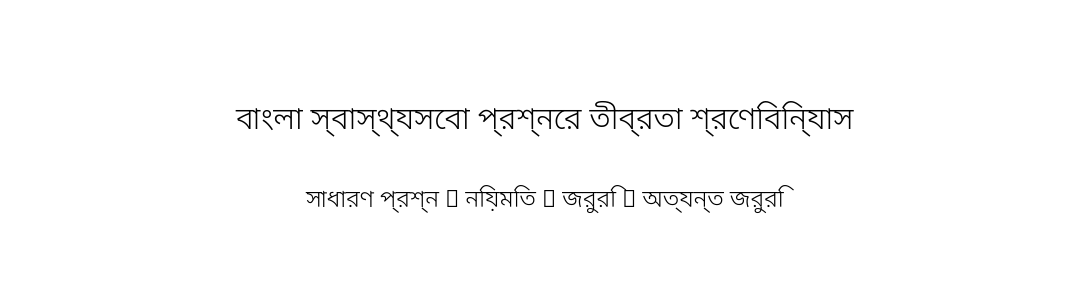

In [46]:
# ============================================================
# TEST BANGLA FONT RENDERING
# ============================================================

import matplotlib.pyplot as plt

fig, ax = plt.subplots(
    figsize=(11, 3)
)

ax.text(
    0.5,
    0.60,
    "বাংলা স্বাস্থ্যসেবা প্রশ্নের তীব্রতা শ্রেণিবিন্যাস",
    fontproperties=BANGLA_FONT,
    fontsize=22,
    horizontalalignment='center',
    verticalalignment='center'
)

ax.text(
    0.5,
    0.30,
    "সাধারণ প্রশ্ন • নিয়মিত • জরুরি • অত্যন্ত জরুরি",
    fontproperties=BANGLA_FONT,
    fontsize=17,
    horizontalalignment='center',
    verticalalignment='center'
)

ax.axis('off')

plt.tight_layout()
plt.show()

/tmp/ipykernel_817/25145919.py:78: UserWarning: Glyph 108 (l) missing from font(s) Noto Sans Bengali.
  plt.tight_layout()
/tmp/ipykernel_817/25145919.py:78: UserWarning: Glyph 112 (p) missing from font(s) Noto Sans Bengali.
  plt.tight_layout()
/tmp/ipykernel_817/25145919.py:78: UserWarning: Glyph 67 (C) missing from font(s) Noto Sans Bengali.
  plt.tight_layout()
/tmp/ipykernel_817/25145919.py:78: UserWarning: Glyph 111 (o) missing from font(s) Noto Sans Bengali.
  plt.tight_layout()
/tmp/ipykernel_817/25145919.py:78: UserWarning: Glyph 110 (n) missing from font(s) Noto Sans Bengali.
  plt.tight_layout()
/tmp/ipykernel_817/25145919.py:78: UserWarning: Glyph 116 (t) missing from font(s) Noto Sans Bengali.
  plt.tight_layout()
/tmp/ipykernel_817/25145919.py:78: UserWarning: Glyph 114 (r) missing from font(s) Noto Sans Bengali.
  plt.tight_layout()
/tmp/ipykernel_817/25145919.py:78: UserWarning: Glyph 105 (i) missing from font(s) Noto Sans Bengali.
  plt.tight_layout()
/tmp/ipykernel_81

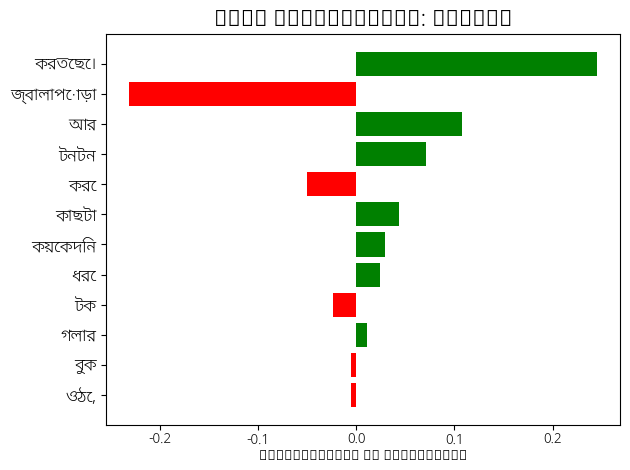

Corrected LIME figure saved to:
/content/drive/MyDrive/SCORE_BN_Checkpoints/explainability/lime_example_bangla_fixed.png


In [47]:
# ============================================================
# REGENERATE LIME FIGURE WITH BANGLA FONT
# ============================================================

import matplotlib.pyplot as plt

# If your variable is named exp instead of explanation
if (
    'explanation' not in globals()
    and
    'exp' in globals()
):
    explanation = exp

if 'explanation' not in globals():
    raise NameError(
        "The LIME explanation object is missing. "
        "Rerun the corrected LIME cell first."
    )

if 'predicted_label_id' not in globals():

    if 'all_classical_predictions' in globals():

        predicted_label_id = int(
            all_classical_predictions[
                example_index
            ]
        )

    else:

        raise NameError(
            "predicted_label_id is missing. "
            "Rerun the corrected LIME cell."
        )

lime_figure = (
    explanation.as_pyplot_figure(
        label=predicted_label_id
    )
)

lime_axis = (
    lime_figure.axes[0]
)

# Apply the Bangla font to all y-axis labels
for label in lime_axis.get_yticklabels():

    label.set_fontproperties(
        BANGLA_FONT
    )

    label.set_fontsize(
        12
    )

# Apply font to x-axis labels if necessary
for label in lime_axis.get_xticklabels():

    label.set_fontproperties(
        BANGLA_FONT
    )

lime_axis.set_title(
    "LIME Explanation: "
    f"{ID2LABEL[predicted_label_id]}",
    fontproperties=BANGLA_FONT,
    fontsize=16
)

lime_axis.set_xlabel(
    "Contribution to Prediction",
    fontproperties=BANGLA_FONT
)

plt.tight_layout()

LIME_FIXED_PATH = (
    BACKUP_DIR /
    'explainability' /
    'lime_example_bangla_fixed.png'
)

plt.savefig(
    LIME_FIXED_PATH,
    dpi=300,
    bbox_inches='tight',
    facecolor='white'
)

plt.show()

print(
    "Corrected LIME figure saved to:"
)

print(LIME_FIXED_PATH)

/tmp/ipykernel_817/1614432879.py:87: UserWarning: Glyph 108 (l) missing from font(s) Noto Sans Bengali.
  plt.tight_layout()
/tmp/ipykernel_817/1614432879.py:87: UserWarning: Glyph 112 (p) missing from font(s) Noto Sans Bengali.
  plt.tight_layout()
/tmp/ipykernel_817/1614432879.py:87: UserWarning: Glyph 67 (C) missing from font(s) Noto Sans Bengali.
  plt.tight_layout()
/tmp/ipykernel_817/1614432879.py:87: UserWarning: Glyph 111 (o) missing from font(s) Noto Sans Bengali.
  plt.tight_layout()
/tmp/ipykernel_817/1614432879.py:87: UserWarning: Glyph 110 (n) missing from font(s) Noto Sans Bengali.
  plt.tight_layout()
/tmp/ipykernel_817/1614432879.py:87: UserWarning: Glyph 116 (t) missing from font(s) Noto Sans Bengali.
  plt.tight_layout()
/tmp/ipykernel_817/1614432879.py:87: UserWarning: Glyph 114 (r) missing from font(s) Noto Sans Bengali.
  plt.tight_layout()
/tmp/ipykernel_817/1614432879.py:87: UserWarning: Glyph 105 (i) missing from font(s) Noto Sans Bengali.
  plt.tight_layout()
/

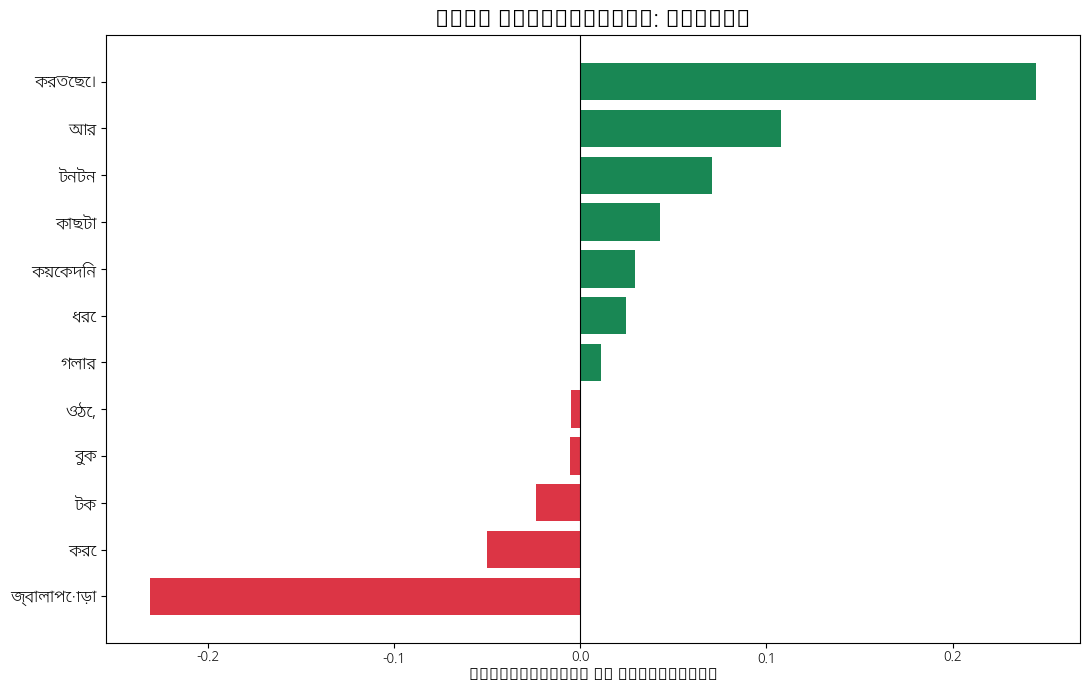

Final LIME figure saved to:
/content/drive/MyDrive/SCORE_BN_Checkpoints/explainability/lime_explanation_final.png


In [48]:
# ============================================================
# MANUAL LIME PLOT WITH BANGLA FONT
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

lime_items = explanation.as_list(
    label=predicted_label_id
)

lime_plot_df = pd.DataFrame(
    lime_items,
    columns=[
        'feature',
        'importance'
    ]
)

# Reverse order for a readable horizontal chart
lime_plot_df = (
    lime_plot_df
    .sort_values(
        'importance',
        ascending=True
    )
)

colors = [
    '#198754'
    if value > 0
    else '#DC3545'
    for value in lime_plot_df[
        'importance'
    ]
]

fig, ax = plt.subplots(
    figsize=(11, 7)
)

ax.barh(
    lime_plot_df[
        'feature'
    ],
    lime_plot_df[
        'importance'
    ],
    color=colors
)

ax.axvline(
    0,
    color='black',
    linewidth=0.8
)

ax.set_title(
    "LIME Explanation: "
    f"{ID2LABEL[predicted_label_id]}",
    fontproperties=BANGLA_FONT,
    fontsize=17
)

ax.set_xlabel(
    "Contribution to Prediction",
    fontproperties=BANGLA_FONT,
    fontsize=12
)

for label in ax.get_yticklabels():

    label.set_fontproperties(
        BANGLA_FONT
    )

    label.set_fontsize(
        12
    )

for label in ax.get_xticklabels():

    label.set_fontproperties(
        BANGLA_FONT
    )

plt.tight_layout()

LIME_MANUAL_PATH = (
    BACKUP_DIR /
    'explainability' /
    'lime_explanation_final.png'
)

plt.savefig(
    LIME_MANUAL_PATH,
    dpi=300,
    bbox_inches='tight',
    facecolor='white'
)

plt.show()

print(
    "Final LIME figure saved to:"
)

print(LIME_MANUAL_PATH)

/tmp/ipykernel_817/3723326402.py:27: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:1150: UserWarning: Glyph 108 (l) missing from font(s) Noto Sans Bengali.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:1150: UserWarning: Glyph 112 (p) missing from font(s) Noto Sans Bengali.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:1150: UserWarning: Glyph 109 (m) missing from font(s) Noto Sans Bengali.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:1150: UserWarning: Glyph 101 (e) missing from font(s) Noto Sans Bengali.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:1150: UserWarning: Gly

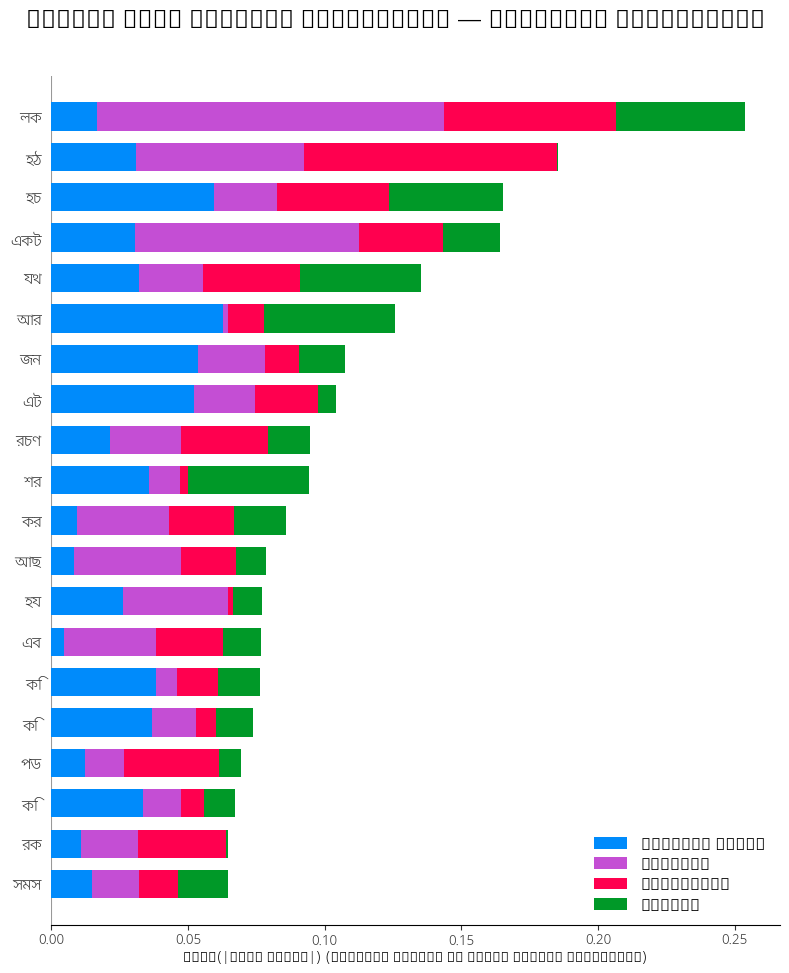

Corrected SHAP figure saved to:
/content/drive/MyDrive/SCORE_BN_Checkpoints/explainability/shap_global_summary_bangla_fixed.png


In [49]:
# ============================================================
# REGENERATE SHAP FIGURE WITH BANGLA FONT
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import shap

# Remove FeatureUnion prefixes for cleaner display
clean_feature_names = np.array([
    str(feature)
    .replace(
        'word__',
        ''
    )
    .replace(
        'char__',
        ''
    )
    for feature in feature_names
])

plt.figure(
    figsize=(13, 9)
)

shap.summary_plot(
    shap_values_for_plot,
    explain_X,
    feature_names=clean_feature_names,
    class_names=class_names,
    max_display=20,
    plot_type='bar',
    show=False
)

current_figure = plt.gcf()

# Apply the font to every axis and every label
for axis in current_figure.axes:

    for label in axis.get_yticklabels():

        label.set_fontproperties(
            BANGLA_FONT
        )

        label.set_fontsize(
            11
        )

    for label in axis.get_xticklabels():

        label.set_fontproperties(
            BANGLA_FONT
        )

    axis.title.set_fontproperties(
        BANGLA_FONT
    )

    axis.xaxis.label.set_fontproperties(
        BANGLA_FONT
    )

    axis.yaxis.label.set_fontproperties(
        BANGLA_FONT
    )

plt.suptitle(
    "Global SHAP Feature Importance — Logistic Regression",
    fontproperties=BANGLA_FONT,
    fontsize=18,
    y=1.02
)

plt.tight_layout()

SHAP_FIXED_PATH = (
    BACKUP_DIR /
    'explainability' /
    'shap_global_summary_bangla_fixed.png'
)

plt.savefig(
    SHAP_FIXED_PATH,
    dpi=300,
    bbox_inches='tight',
    facecolor='white'
)

plt.show()

print(
    "Corrected SHAP figure saved to:"
)

print(SHAP_FIXED_PATH)

In [50]:
for axis in plt.gcf().axes:

    for label in axis.get_xticklabels():
        label.set_fontproperties(
            BANGLA_FONT
        )

    for label in axis.get_yticklabels():
        label.set_fontproperties(
            BANGLA_FONT
        )

<Figure size 640x480 with 0 Axes>

In [51]:
plt.savefig(
    "figure_name.png",
    dpi=300,
    bbox_inches='tight',
    facecolor='white'
)

<Figure size 640x480 with 0 Axes>

In [52]:
# ============================================================
# FINAL PROJECT BACKUP BEFORE CLOSING GOOGLE COLAB
# ============================================================

import os
import json
import shutil
import hashlib
import traceback
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Confirm Google Drive location
# ------------------------------------------------------------

BACKUP_DIR = Path(
    '/content/drive/MyDrive/SCORE_BN_Checkpoints'
)

if not BACKUP_DIR.exists():
    raise FileNotFoundError(
        f"Google Drive checkpoint folder was not found:\n"
        f"{BACKUP_DIR}"
    )

FINAL_EXPORT_DIR = (
    BACKUP_DIR /
    'final_export'
)

FINAL_FIGURE_DIR = (
    FINAL_EXPORT_DIR /
    'figures'
)

FINAL_TABLE_DIR = (
    FINAL_EXPORT_DIR /
    'tables'
)

FINAL_ARRAY_DIR = (
    FINAL_EXPORT_DIR /
    'arrays'
)

FINAL_REPORT_DIR = (
    FINAL_EXPORT_DIR /
    'reports'
)

FINAL_METADATA_DIR = (
    FINAL_EXPORT_DIR /
    'metadata'
)

for directory in [
    FINAL_EXPORT_DIR,
    FINAL_FIGURE_DIR,
    FINAL_TABLE_DIR,
    FINAL_ARRAY_DIR,
    FINAL_REPORT_DIR,
    FINAL_METADATA_DIR
]:
    directory.mkdir(
        parents=True,
        exist_ok=True
    )

print("Main checkpoint folder:")
print(BACKUP_DIR)

print("\nFinal export folder:")
print(FINAL_EXPORT_DIR)

# ------------------------------------------------------------
# 2. Save every currently open Matplotlib figure
# ------------------------------------------------------------

open_figure_numbers = plt.get_fignums()

print(
    "\nOpen Matplotlib figures:",
    len(open_figure_numbers)
)

for figure_number in open_figure_numbers:

    figure = plt.figure(
        figure_number
    )

    figure_path = (
        FINAL_FIGURE_DIR /
        f'open_figure_{figure_number}.png'
    )

    figure.savefig(
        figure_path,
        dpi=300,
        bbox_inches='tight',
        facecolor='white'
    )

    print(
        "Saved open figure:",
        figure_path.name
    )

# ------------------------------------------------------------
# 3. Copy figures/reports from temporary Colab storage
# ------------------------------------------------------------

allowed_extensions = {
    '.png',
    '.jpg',
    '.jpeg',
    '.svg',
    '.pdf',
    '.html'
}

temporary_search_roots = [
    Path('/content/score_bn'),
    Path('/content/results'),
    Path('/content/figures')
]

copied_temporary_files = []

for search_root in temporary_search_roots:

    if not search_root.exists():
        continue

    for source_file in search_root.rglob('*'):

        if (
            source_file.is_file()
            and
            source_file.suffix.lower()
            in allowed_extensions
        ):

            relative_name = (
                str(
                    source_file.relative_to(
                        search_root
                    )
                )
                .replace('/', '__')
            )

            destination_file = (
                FINAL_FIGURE_DIR /
                (
                    search_root.name
                    +
                    '__'
                    +
                    relative_name
                )
            )

            shutil.copy2(
                source_file,
                destination_file
            )

            copied_temporary_files.append(
                str(destination_file)
            )

print(
    "\nTemporary figures/reports copied:",
    len(copied_temporary_files)
)

# ------------------------------------------------------------
# 4. Save important in-memory DataFrames
# ------------------------------------------------------------

dataframe_variables = [
    'df',
    'train_df',
    'val_df',
    'test_df',
    'paired_train',
    'paired_validation',
    'paired_test',
    'near_pairs',
    'classical_results_df',
    'tuned_results_df',
    'deep_results_df',
    'banglabert_results_df',
    'score_results_df',
    'tuning_results_df',
    'all_results',
    'score_metrics_df',
    'prediction_results',
    'lime_values',
    'coefficient_table',
    'training_history'
]

saved_dataframes = []
missing_dataframes = []

for variable_name in dataframe_variables:

    if variable_name not in globals():

        missing_dataframes.append(
            variable_name
        )

        continue

    value = globals()[
        variable_name
    ]

    try:

        if isinstance(
            value,
            pd.DataFrame
        ):

            output_path = (
                FINAL_TABLE_DIR /
                f'{variable_name}.csv'
            )

            value.to_csv(
                output_path,
                index=False,
                encoding='utf-8-sig'
            )

            saved_dataframes.append(
                variable_name
            )

        elif isinstance(
            value,
            pd.Series
        ):

            output_path = (
                FINAL_TABLE_DIR /
                f'{variable_name}.csv'
            )

            value.to_csv(
                output_path,
                encoding='utf-8-sig'
            )

            saved_dataframes.append(
                variable_name
            )

        elif isinstance(
            value,
            list
        ):

            output_path = (
                FINAL_TABLE_DIR /
                f'{variable_name}.csv'
            )

            pd.DataFrame(
                value
            ).to_csv(
                output_path,
                index=False,
                encoding='utf-8-sig'
            )

            saved_dataframes.append(
                variable_name
            )

    except Exception as error:

        print(
            f"Could not save {variable_name}:",
            error
        )

print(
    "\nSaved table variables:",
    saved_dataframes
)

# Missing in-memory variables are not automatically a problem,
# because most results were already saved during training.
print(
    "Unavailable in-memory tables:",
    missing_dataframes
)

# ------------------------------------------------------------
# 5. Save important in-memory arrays
# ------------------------------------------------------------

array_variables = [
    'y_train',
    'y_val',
    'y_test',
    'score_probabilities',
    'score_predictions',
    'romanized_probabilities',
    'romanized_predictions',
    'score_prob',
    'score_pred',
    'roman_prob',
    'roman_pred',
    'test_probabilities',
    'test_predictions'
]

saved_arrays = []

for variable_name in array_variables:

    if variable_name not in globals():
        continue

    try:

        value = np.asarray(
            globals()[
                variable_name
            ]
        )

        output_path = (
            FINAL_ARRAY_DIR /
            f'{variable_name}.npy'
        )

        np.save(
            output_path,
            value
        )

        saved_arrays.append(
            variable_name
        )

    except Exception as error:

        print(
            f"Could not save {variable_name}:",
            error
        )

print(
    "\nSaved array variables:",
    saved_arrays
)

# ------------------------------------------------------------
# 6. Save important dictionaries/metadata
# ------------------------------------------------------------

metadata_to_save = {}

possible_metadata = [
    'LABEL2ID',
    'ID2LABEL',
    'audit',
    'dataset_audit',
    'score_metrics',
    'configuration',
    'best_hyperparameter_summary',
    'best_configuration'
]

for variable_name in possible_metadata:

    if variable_name in globals():

        value = globals()[
            variable_name
        ]

        if isinstance(
            value,
            dict
        ):

            metadata_to_save[
                variable_name
            ] = value

def make_json_serializable(value):

    if isinstance(
        value,
        dict
    ):

        return {
            str(key): make_json_serializable(
                item
            )
            for key, item in value.items()
        }

    if isinstance(
        value,
        (list, tuple)
    ):

        return [
            make_json_serializable(
                item
            )
            for item in value
        ]

    if isinstance(
        value,
        (
            np.integer,
            np.floating
        )
    ):

        return value.item()

    if isinstance(
        value,
        np.ndarray
    ):

        return value.tolist()

    if isinstance(
        value,
        Path
    ):

        return str(value)

    if isinstance(
        value,
        (
            str,
            int,
            float,
            bool
        )
    ) or value is None:

        return value

    return str(value)

metadata_output_path = (
    FINAL_METADATA_DIR /
    'in_memory_metadata.json'
)

with open(
    metadata_output_path,
    'w',
    encoding='utf-8'
) as file:

    json.dump(
        make_json_serializable(
            metadata_to_save
        ),
        file,
        ensure_ascii=False,
        indent=2
    )

print(
    "\nMetadata saved to:",
    metadata_output_path
)

# ------------------------------------------------------------
# 7. Save a final copy of important existing result files
# ------------------------------------------------------------

important_existing_patterns = [
    'deep_model_results.csv',
    'tuned_model_results.csv',
    'all_trial_results.csv',
    'best_hyperparameters.json',
    'test_metrics.json',
    'training_history.csv',
    'configuration.json',
    'test_predictions_and_errors.csv',
    'model_comparison.csv',
    'dataset_audit.json',
    'label_mapping.json',
    'lime_example.html',
    'lime_feature_weights.csv',
    'logistic_regression_top_features.csv'
]

copied_existing_results = []

for filename_pattern in important_existing_patterns:

    matching_files = list(
        BACKUP_DIR.rglob(
            filename_pattern
        )
    )

    for source_file in matching_files:

        if not source_file.is_file():
            continue

        relative_name = (
            str(
                source_file.relative_to(
                    BACKUP_DIR
                )
            )
            .replace('/', '__')
        )

        destination_file = (
            FINAL_REPORT_DIR /
            relative_name
        )

        # Do not copy a file onto itself.
        if (
            source_file.resolve()
            !=
            destination_file.resolve()
        ):

            shutil.copy2(
                source_file,
                destination_file
            )

        copied_existing_results.append(
            str(source_file)
        )

print(
    "\nImportant existing result files copied:",
    len(copied_existing_results)
)

# ------------------------------------------------------------
# 8. Verify essential files
# ------------------------------------------------------------

essential_files = {
    'Train split':
        BACKUP_DIR / 'train.csv',

    'Validation split':
        BACKUP_DIR / 'validation.csv',

    'Test split':
        BACKUP_DIR / 'test.csv',

    'TF-IDF extractor':
        BACKUP_DIR / 'tfidf_features.joblib',

    'Classical models':
        BACKUP_DIR / 'classical_models.joblib',

    'Tuned SVM':
        BACKUP_DIR / 'tuned_linear_svm.joblib',

    'Tuned XGBoost':
        BACKUP_DIR / 'tuned_xgboost.joblib',

    'CNN model':
        BACKUP_DIR / 'CNN_final.keras',

    'BiLSTM model':
        BACKUP_DIR / 'BiLSTM_final.keras',

    'BiGRU model':
        BACKUP_DIR / 'BiGRU_final.keras',

    'BanglaBERT final model':
        (
            BACKUP_DIR /
            'banglabert_baseline' /
            'final_model' /
            'model.safetensors'
        ),

    'Transformer tuning result':
        (
            BACKUP_DIR /
            'transformer_tuning' /
            'best_hyperparameters.json'
        ),

    'Best tuned transformer':
        (
            BACKUP_DIR /
            'transformer_tuning' /
            'best_tuned_model' /
            'model.safetensors'
        ),

    'SCORE-BN model':
        (
            BACKUP_DIR /
            'score_bn' /
            'best_score_bn.pt'
        ),

    'SCORE-BN metrics':
        (
            BACKUP_DIR /
            'score_bn' /
            'test_metrics.json'
        ),

    'SCORE-BN error analysis':
        (
            BACKUP_DIR /
            'score_bn' /
            'test_predictions_and_errors.csv'
        ),

    'Final model comparison':
        (
            BACKUP_DIR /
            'final_results' /
            'model_comparison.csv'
        ),

    'LIME figure':
        (
            BACKUP_DIR /
            'explainability' /
            'lime_explanation_final.png'
        ),

    'SHAP figure':
        (
            BACKUP_DIR /
            'explainability' /
            'shap_global_summary_bangla_fixed.png'
        )
}

verification_rows = []

for description, file_path in essential_files.items():

    exists = file_path.exists()

    size_bytes = (
        file_path.stat().st_size
        if exists
        else 0
    )

    verification_rows.append({
        'item': description,
        'path': str(file_path),
        'exists': exists,
        'size_bytes': size_bytes
    })

verification_df = pd.DataFrame(
    verification_rows
)

display(
    verification_df
)

verification_df.to_csv(
    FINAL_METADATA_DIR /
    'essential_file_verification.csv',
    index=False,
    encoding='utf-8-sig'
)

missing_essential_files = (
    verification_df.loc[
        ~verification_df[
            'exists'
        ],
        'item'
    ]
    .tolist()
)

print(
    "\nMissing essential items:",
    missing_essential_files
)

# ------------------------------------------------------------
# 9. Create complete file inventory
# ------------------------------------------------------------

inventory_rows = []

for file_path in BACKUP_DIR.rglob('*'):

    if not file_path.is_file():
        continue

    # The ZIP is stored elsewhere, so it cannot include itself.
    relative_path = (
        file_path.relative_to(
            BACKUP_DIR
        )
    )

    inventory_rows.append({
        'relative_path': str(
            relative_path
        ),
        'extension': (
            file_path.suffix.lower()
        ),
        'size_bytes': (
            file_path.stat().st_size
        ),
        'size_mb': round(
            file_path.stat().st_size /
            1024**2,
            3
        )
    })

inventory_df = (
    pd.DataFrame(
        inventory_rows
    )
    .sort_values(
        'relative_path'
    )
    .reset_index(drop=True)
)

inventory_path = (
    FINAL_METADATA_DIR /
    'complete_file_inventory.csv'
)

inventory_df.to_csv(
    inventory_path,
    index=False,
    encoding='utf-8-sig'
)

print(
    "\nTotal files in checkpoint folder:",
    len(inventory_df)
)

print(
    "Total saved size:",
    round(
        inventory_df[
            'size_bytes'
        ].sum() /
        1024**3,
        2
    ),
    "GB"
)

print(
    "Inventory saved to:",
    inventory_path
)

# ------------------------------------------------------------
# 10. Create a lightweight submission ZIP
# ------------------------------------------------------------

EXPORTS_DIR = Path(
    '/content/drive/MyDrive/SCORE_BN_Exports'
)

EXPORTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

LIGHT_PACKAGE_DIR = Path(
    '/content/SCORE_BN_Submission_Package'
)

LIGHT_PACKAGE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

# Include final results, figures, reports and Streamlit files.
light_sources = [
    (
        BACKUP_DIR /
        'final_results'
    ),
    (
        BACKUP_DIR /
        'explainability'
    ),
    (
        BACKUP_DIR /
        'score_bn'
    ),
    (
        BACKUP_DIR /
        'transformer_tuning'
    ),
    (
        BACKUP_DIR /
        'streamlit_app'
    ),
    FINAL_EXPORT_DIR
]

for source_directory in light_sources:

    if not source_directory.exists():
        continue

    destination_directory = (
        LIGHT_PACKAGE_DIR /
        source_directory.name
    )

    shutil.copytree(
        source_directory,
        destination_directory,
        dirs_exist_ok=True
    )

# Add dataset splits and result tables.
individual_files = [
    BACKUP_DIR / 'train.csv',
    BACKUP_DIR / 'validation.csv',
    BACKUP_DIR / 'test.csv',
    BACKUP_DIR / 'deep_model_results.csv',
    BACKUP_DIR / 'tuned_model_results.csv'
]

for source_file in individual_files:

    if source_file.exists():

        shutil.copy2(
            source_file,
            LIGHT_PACKAGE_DIR /
            source_file.name
        )

light_zip_base = (
    '/content/SCORE_BN_SUBMISSION_PACKAGE'
)

light_zip_path = shutil.make_archive(
    light_zip_base,
    'zip',
    root_dir=LIGHT_PACKAGE_DIR
)

light_drive_zip = (
    EXPORTS_DIR /
    'SCORE_BN_SUBMISSION_PACKAGE.zip'
)

shutil.copy2(
    light_zip_path,
    light_drive_zip
)

print(
    "\nLightweight submission ZIP created:"
)

print(light_drive_zip)

print(
    "ZIP size:",
    round(
        light_drive_zip.stat().st_size /
        1024**2,
        2
    ),
    "MB"
)

# ------------------------------------------------------------
# 11. Optional complete ZIP containing all saved models
# ------------------------------------------------------------

print(
    "\nCreating the complete model backup ZIP."
)

print(
    "This may take several minutes because it includes "
    "BanglaBERT checkpoints and all trained models."
)

complete_zip_base = (
    '/content/SCORE_BN_COMPLETE_BACKUP'
)

complete_zip_path = shutil.make_archive(
    complete_zip_base,
    'zip',
    root_dir=BACKUP_DIR
)

complete_drive_zip = (
    EXPORTS_DIR /
    'SCORE_BN_COMPLETE_BACKUP.zip'
)

shutil.copy2(
    complete_zip_path,
    complete_drive_zip
)

print(
    "\nComplete backup ZIP created:"
)

print(complete_drive_zip)

print(
    "Complete ZIP size:",
    round(
        complete_drive_zip.stat().st_size /
        1024**3,
        2
    ),
    "GB"
)

# ------------------------------------------------------------
# 12. Final status
# ------------------------------------------------------------

print(
    "\n" + "=" * 70
)

print(
    "FINAL GOOGLE DRIVE BACKUP COMPLETED"
)

print(
    "=" * 70
)

print(
    "\nDownloadable files:"
)

print(
    "1.",
    light_drive_zip
)

print(
    "2.",
    complete_drive_zip
)

print(
    "\nEssential items missing:",
    missing_essential_files
)

print(
    "\nDo not close Colab until both ZIP files "
    "are visible in Google Drive."
)

Main checkpoint folder:
/content/drive/MyDrive/SCORE_BN_Checkpoints

Final export folder:
/content/drive/MyDrive/SCORE_BN_Checkpoints/final_export

Open Matplotlib figures: 0

Temporary figures/reports copied: 0

Saved table variables: ['train_df', 'val_df', 'test_df', 'paired_train', 'paired_validation', 'paired_test', 'classical_results_df', 'tuned_results_df', 'deep_results_df', 'banglabert_results_df', 'score_results_df', 'tuning_results_df', 'all_results', 'score_metrics_df', 'prediction_results', 'lime_values', 'coefficient_table', 'training_history']
Unavailable in-memory tables: ['df', 'near_pairs']

Saved array variables: ['y_test', 'score_probabilities', 'score_predictions', 'romanized_probabilities', 'romanized_predictions', 'score_prob', 'score_pred', 'roman_prob', 'roman_pred']

Metadata saved to: /content/drive/MyDrive/SCORE_BN_Checkpoints/final_export/metadata/in_memory_metadata.json

Important existing result files copied: 17


,item,path,exists,size_bytes
0,Train split,/content/drive/MyDrive/SCORE_BN_Checkpoints/tr...,True,1532144
1,Validation split,/content/drive/MyDrive/SCORE_BN_Checkpoints/va...,True,327199
2,Test split,/content/drive/MyDrive/SCORE_BN_Checkpoints/te...,True,336646
3,TF-IDF extractor,/content/drive/MyDrive/SCORE_BN_Checkpoints/tf...,True,892344
4,Classical models,/content/drive/MyDrive/SCORE_BN_Checkpoints/cl...,True,41836192
5,Tuned SVM,/content/drive/MyDrive/SCORE_BN_Checkpoints/tu...,True,682131
6,Tuned XGBoost,/content/drive/MyDrive/SCORE_BN_Checkpoints/tu...,True,1106725
7,CNN model,/content/drive/MyDrive/SCORE_BN_Checkpoints/CN...,True,6822743
8,BiLSTM model,/content/drive/MyDrive/SCORE_BN_Checkpoints/Bi...,True,7429207
9,BiGRU model,/content/drive/MyDrive/SCORE_BN_Checkpoints/Bi...,True,7137349



Missing essential items: []

Total files in checkpoint folder: 215
Total saved size: 7.62 GB
Inventory saved to: /content/drive/MyDrive/SCORE_BN_Checkpoints/final_export/metadata/complete_file_inventory.csv

Lightweight submission ZIP created:
/content/drive/MyDrive/SCORE_BN_Exports/SCORE_BN_SUBMISSION_PACKAGE.zip
ZIP size: 1792.38 MB

Creating the complete model backup ZIP.
This may take several minutes because it includes BanglaBERT checkpoints and all trained models.

Complete backup ZIP created:
/content/drive/MyDrive/SCORE_BN_Exports/SCORE_BN_COMPLETE_BACKUP.zip
Complete ZIP size: 6.2 GB

FINAL GOOGLE DRIVE BACKUP COMPLETED

Downloadable files:
1. /content/drive/MyDrive/SCORE_BN_Exports/SCORE_BN_SUBMISSION_PACKAGE.zip
2. /content/drive/MyDrive/SCORE_BN_Exports/SCORE_BN_COMPLETE_BACKUP.zip

Essential items missing: []

Do not close Colab until both ZIP files are visible in Google Drive.


In [53]:
# ============================================================
# REPORT ASSET SETUP AND BANGLA FONT
# ============================================================

!pip -q install wordcloud openpyxl
!apt-get update -qq
!apt-get install -y -qq fonts-noto-core fonts-noto-extra

import os
import re
import glob
import json
import shutil
import warnings
import unicodedata
from collections import Counter
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib import font_manager
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    auc,
    roc_curve
)
from sklearn.preprocessing import label_binarize

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

# ------------------------------------------------------------
# Directories
# ------------------------------------------------------------

BACKUP_DIR = Path(
    '/content/drive/MyDrive/SCORE_BN_Checkpoints'
)

REPORT_ASSET_DIR = (
    BACKUP_DIR /
    'report_assets'
)

FIGURE_DIR = (
    REPORT_ASSET_DIR /
    'figures'
)

TABLE_DIR = (
    REPORT_ASSET_DIR /
    'tables'
)

for directory in [
    REPORT_ASSET_DIR,
    FIGURE_DIR,
    TABLE_DIR
]:
    directory.mkdir(
        parents=True,
        exist_ok=True
    )

assert BACKUP_DIR.exists(), (
    f"Checkpoint folder not found: {BACKUP_DIR}"
)

# ------------------------------------------------------------
# Install/register Bangla font
# ------------------------------------------------------------

for font_path in font_manager.findSystemFonts(
    fontext='ttf'
):
    try:
        font_manager.fontManager.addfont(
            font_path
        )
    except Exception:
        pass

bangla_font_paths = [
    path
    for path in font_manager.findSystemFonts(
        fontext='ttf'
    )
    if (
        'Bengali' in path
        or
        'Bangla' in path
    )
]

if not bangla_font_paths:
    raise FileNotFoundError(
        "No Bangla font was found."
    )

# Prefer Noto Sans Bengali when available
preferred_fonts = [
    path
    for path in bangla_font_paths
    if 'NotoSansBengali' in path.replace(
        ' ',
        ''
    )
]

BANGLA_FONT_PATH = (
    preferred_fonts[0]
    if preferred_fonts
    else bangla_font_paths[0]
)

BANGLA_FONT = (
    font_manager.FontProperties(
        fname=BANGLA_FONT_PATH
    )
)

BANGLA_FONT_NAME = (
    BANGLA_FONT.get_name()
)

plt.rcParams.update({
    'font.family': BANGLA_FONT_NAME,
    'font.sans-serif': [
        BANGLA_FONT_NAME,
        'Noto Sans Bengali',
        'DejaVu Sans'
    ],
    'axes.unicode_minus': False,
    'figure.dpi': 120,
    'savefig.dpi': 300
})

print("Bangla font:", BANGLA_FONT_NAME)
print("Font path:", BANGLA_FONT_PATH)
print("Figure directory:", FIGURE_DIR)
print("Table directory:", TABLE_DIR)

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Bangla font: Noto Sans Bengali
Font path: /usr/share/fonts/truetype/noto/NotoSansBengali-Light.ttf
Figure directory: /content/drive/MyDrive/SCORE_BN_Checkpoints/report_assets/figures
Table directory: /content/drive/MyDrive/SCORE_BN_Checkpoints/report_assets/tables


In [54]:
# ============================================================
# RELOAD DATA AND PREPARE REPORT FEATURES
# ============================================================

LABEL2ID = {
    'General Query': 0,
    'Routine': 1,
    'Urgent': 2,
    'Emergency': 3
}

ID2LABEL = {
    value: key
    for key, value in LABEL2ID.items()
}

CLASS_ORDER = [
    'General Query',
    'Routine',
    'Urgent',
    'Emergency'
]

# ------------------------------------------------------------
# Load dataset splits
# ------------------------------------------------------------

train_df = pd.read_csv(
    BACKUP_DIR /
    'train.csv'
)

val_df = pd.read_csv(
    BACKUP_DIR /
    'validation.csv'
)

test_df = pd.read_csv(
    BACKUP_DIR /
    'test.csv'
)

train_df['split'] = 'Train'
val_df['split'] = 'Validation'
test_df['split'] = 'Test'

df_report = pd.concat(
    [
        train_df,
        val_df,
        test_df
    ],
    ignore_index=True
)

df_report['text'] = (
    df_report['text']
    .fillna('')
    .astype(str)
)

df_report['label'] = (
    df_report['label']
    .astype(int)
)

if 'label_name' not in df_report.columns:
    df_report['label_name'] = (
        df_report['label']
        .map(ID2LABEL)
    )

# ------------------------------------------------------------
# Text features
# ------------------------------------------------------------

def normalize_text(text):

    text = unicodedata.normalize(
        'NFKC',
        str(text)
    )

    text = re.sub(
        r'https?://\S+|www\.\S+',
        ' URL ',
        text
    )

    text = re.sub(
        r'@[A-Za-z0-9_]+',
        ' USER ',
        text
    )

    text = re.sub(
        r'\s+',
        ' ',
        text
    )

    return text.strip().lower()


def tokenize_text(text):

    return re.findall(
        r'[\u0980-\u09FFA-Za-z]+',
        str(text).lower()
    )


df_report['normalized_text'] = (
    df_report['text']
    .map(normalize_text)
)

df_report['char_length'] = (
    df_report['text']
    .str.len()
)

df_report['word_length'] = (
    df_report['text']
    .str.split()
    .str.len()
)

df_report['bangla_chars'] = (
    df_report['text']
    .apply(
        lambda text: len(
            re.findall(
                r'[\u0980-\u09FF]',
                text
            )
        )
    )
)

df_report['latin_chars'] = (
    df_report['text']
    .apply(
        lambda text: len(
            re.findall(
                r'[A-Za-z]',
                text
            )
        )
    )
)

df_report['latin_ratio'] = (
    df_report['latin_chars']
    /
    (
        df_report['bangla_chars']
        +
        df_report['latin_chars']
        +
        1
    )
)

df_report['digit_count'] = (
    df_report['text']
    .str.count(
        r'[0-9০-৯]'
    )
)

df_report['question_mark_count'] = (
    df_report['text']
    .str.count(
        r'[?？]'
    )
)

df_report['token_list'] = (
    df_report['text']
    .map(tokenize_text)
)

vocabulary = {
    token
    for tokens in df_report[
        'token_list'
    ]
    for token in tokens
}

print("Total clean samples:", len(df_report))
print("Vocabulary size:", len(vocabulary))
print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Total clean samples: 5215
Vocabulary size: 4176
Train: 3650
Validation: 782
Test: 783


In [55]:
# ============================================================
# REPORT-SAVING HELPER FUNCTIONS
# ============================================================

generated_assets = []

def save_figure(
    figure,
    filename
):

    output_path = (
        FIGURE_DIR /
        filename
    )

    figure.savefig(
        output_path,
        dpi=300,
        bbox_inches='tight',
        facecolor='white'
    )

    generated_assets.append(
        str(output_path)
    )

    print(
        "Saved figure:",
        output_path.name
    )

    return output_path


def save_table_csv(
    dataframe,
    filename
):

    output_path = (
        TABLE_DIR /
        filename
    )

    dataframe.to_csv(
        output_path,
        index=False,
        encoding='utf-8-sig'
    )

    generated_assets.append(
        str(output_path)
    )

    print(
        "Saved table:",
        output_path.name
    )

    return output_path


def save_table_image(
    dataframe,
    filename,
    title,
    max_rows=30,
    font_size=9
):

    table_df = (
        dataframe
        .head(max_rows)
        .copy()
    )

    for column in table_df.columns:

        if pd.api.types.is_float_dtype(
            table_df[column]
        ):

            table_df[column] = (
                table_df[column]
                .round(4)
            )

    figure_height = max(
        2.5,
        0.42 * len(table_df) + 1.8
    )

    figure_width = max(
        9,
        1.7 * len(table_df.columns)
    )

    figure, axis = plt.subplots(
        figsize=(
            figure_width,
            figure_height
        )
    )

    axis.axis('off')

    axis.set_title(
        title,
        fontsize=14,
        fontweight='bold',
        pad=14,
        fontproperties=BANGLA_FONT
    )

    table = axis.table(
        cellText=table_df.values,
        colLabels=table_df.columns,
        cellLoc='center',
        colLoc='center',
        loc='center'
    )

    table.auto_set_font_size(
        False
    )

    table.set_fontsize(
        font_size
    )

    table.scale(
        1,
        1.35
    )

    for (
        row_index,
        column_index
    ), cell in table.get_celld().items():

        cell.get_text().set_fontproperties(
            BANGLA_FONT
        )

        if row_index == 0:

            cell.set_facecolor(
                '#4C72B0'
            )

            cell.get_text().set_color(
                'white'
            )

            cell.get_text().set_weight(
                'bold'
            )

        elif row_index % 2 == 0:

            cell.set_facecolor(
                '#EEF3F8'
            )

    save_figure(
        figure,
        filename
    )

    plt.show()

    return figure

Saved table: table_01_dataset_summary.csv
Saved figure: table_01_dataset_summary.png


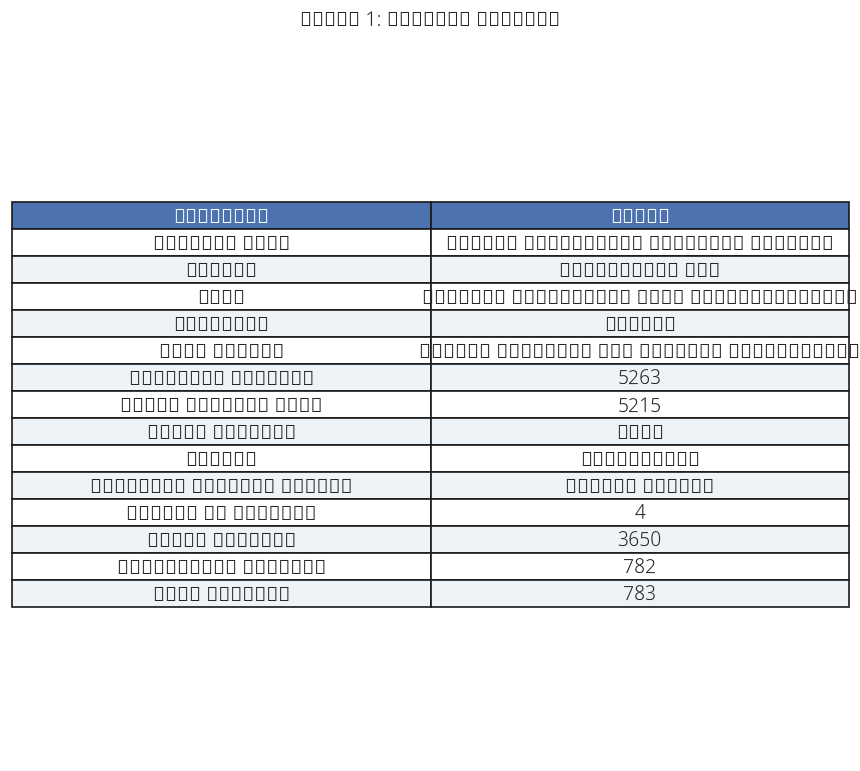

Saved table: table_02_class_distribution.csv
Saved figure: table_02_class_distribution.png


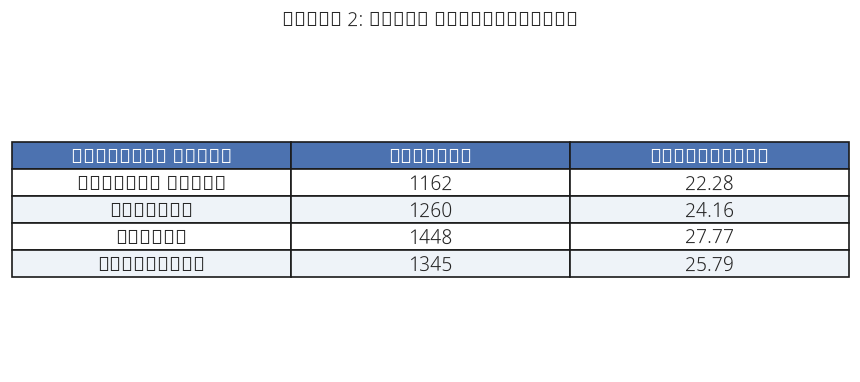

Saved table: table_03_split_distribution.csv
Saved figure: table_03_split_distribution.png


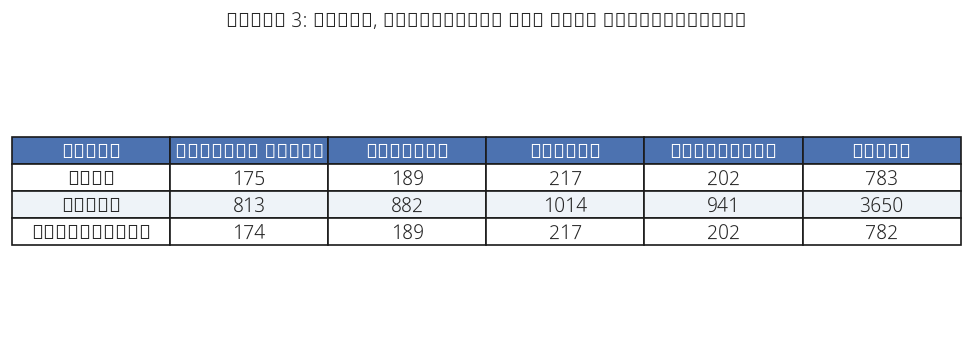

Saved table: table_04_preprocessing_summary.csv
Saved figure: table_04_preprocessing_summary.png


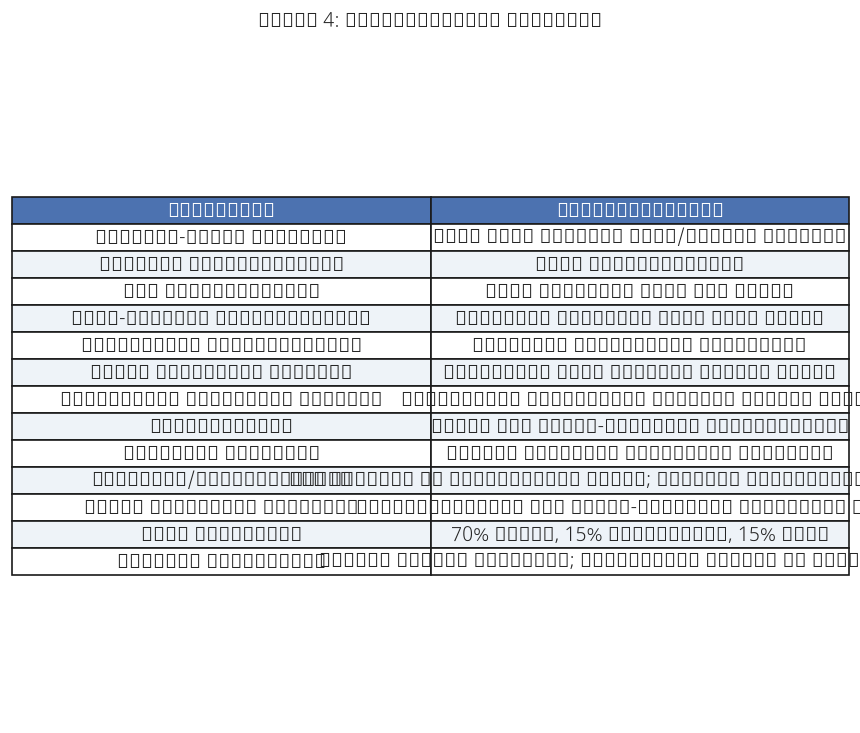

Saved table: table_05_feature_engineering.csv
Saved figure: table_05_feature_engineering.png


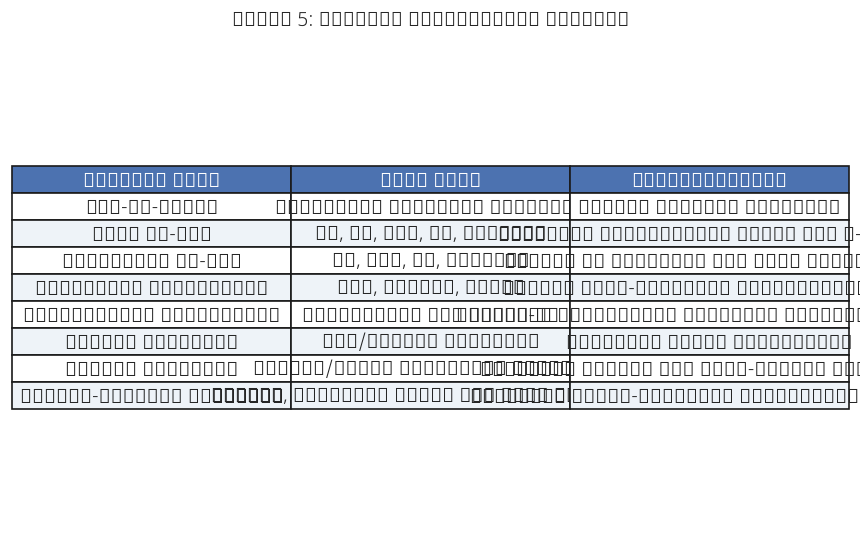

Saved table: table_06_model_families.csv
Saved figure: table_06_model_families.png


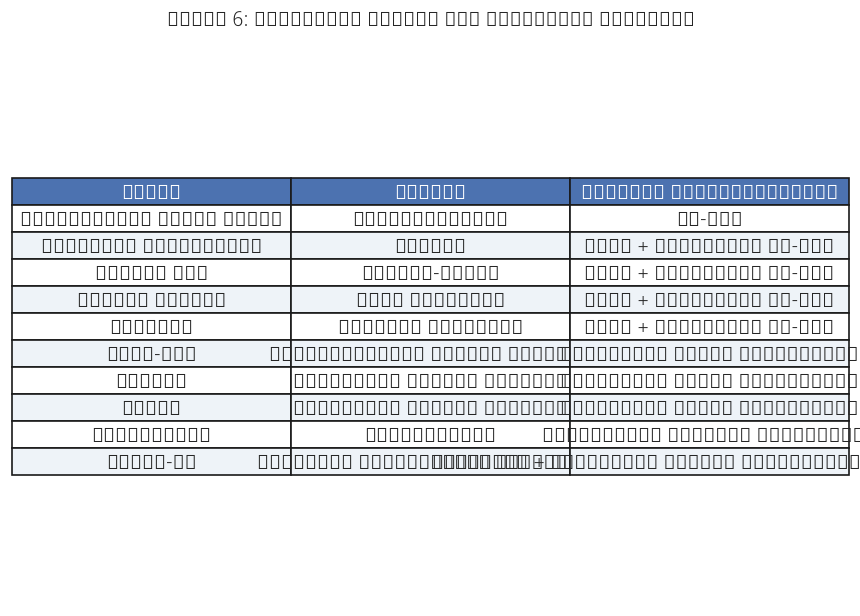

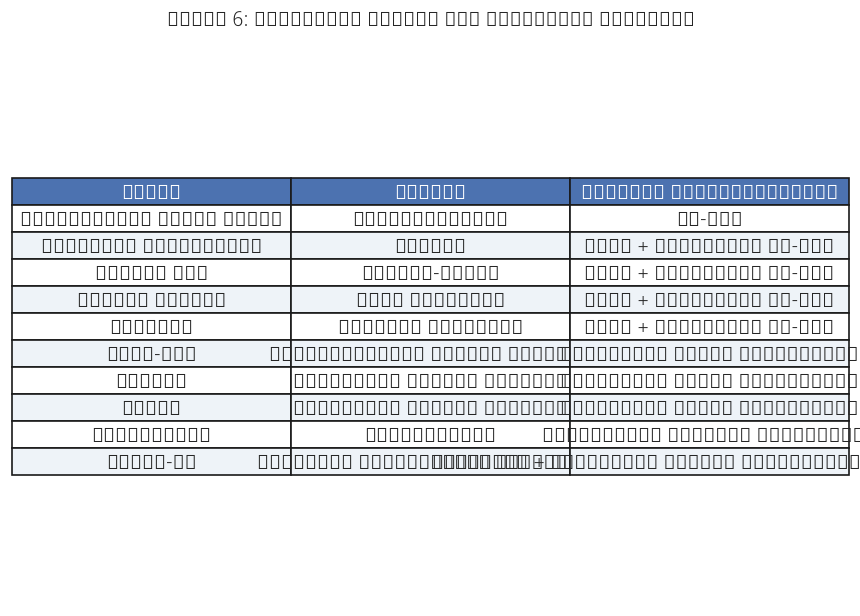

In [56]:
# ============================================================
# DATASET AND PREPROCESSING TABLES
# ============================================================

# ------------------------------------------------------------
# Table 1: Dataset summary
# ------------------------------------------------------------

dataset_summary = pd.DataFrame({
    'Property': [
        'Dataset name',
        'Domain',
        'Task',
        'Language',
        'Data source',
        'Original samples',
        'Clean samples used',
        'Input feature',
        'Target',
        'Excluded leakage column',
        'Number of classes',
        'Train samples',
        'Validation samples',
        'Test samples'
    ],
    'Value': [
        'Bangla Healthcare Severity Dataset',
        'Healthcare NLP',
        'Ordinal multiclass text classification',
        'Bangla',
        'Public Facebook and YouTube discussions',
        5263,
        len(df_report),
        'Text',
        'Categories',
        'Action Needed',
        4,
        len(train_df),
        len(val_df),
        len(test_df)
    ]
})

save_table_csv(
    dataset_summary,
    'table_01_dataset_summary.csv'
)

save_table_image(
    dataset_summary,
    'table_01_dataset_summary.png',
    'Table 1: Dataset Summary',
    max_rows=20,
    font_size=9
)

# ------------------------------------------------------------
# Table 2: Class distribution
# ------------------------------------------------------------

class_distribution = (
    df_report[
        'label_name'
    ]
    .value_counts()
    .reindex(
        CLASS_ORDER
    )
    .rename_axis(
        'Severity Class'
    )
    .reset_index(
        name='Samples'
    )
)

class_distribution[
    'Percentage'
] = (
    class_distribution[
        'Samples'
    ]
    /
    len(df_report)
    *
    100
).round(2)

save_table_csv(
    class_distribution,
    'table_02_class_distribution.csv'
)

save_table_image(
    class_distribution,
    'table_02_class_distribution.png',
    'Table 2: Class Distribution'
)

# ------------------------------------------------------------
# Table 3: Split distribution
# ------------------------------------------------------------

split_distribution = (
    pd.crosstab(
        df_report[
            'split'
        ],
        df_report[
            'label_name'
        ]
    )
    .reindex(
        columns=CLASS_ORDER
    )
    .reset_index()
)

split_distribution[
    'Total'
] = split_distribution[
    CLASS_ORDER
].sum(axis=1)

save_table_csv(
    split_distribution,
    'table_03_split_distribution.csv'
)

save_table_image(
    split_distribution,
    'table_03_split_distribution.png',
    'Table 3: Train, Validation and Test Distribution'
)

# ------------------------------------------------------------
# Table 4: Preprocessing summary
# ------------------------------------------------------------

preprocessing_summary = pd.DataFrame({
    'Operation': [
        'Missing-value handling',
        'Unicode normalization',
        'URL normalization',
        'User-mention normalization',
        'Whitespace normalization',
        'Exact duplicate removal',
        'Normalized duplicate removal',
        'Tokenization',
        'Stopword analysis',
        'Stemming/Lemmatization',
        'Class imbalance handling',
        'Data splitting',
        'Leakage prevention'
    ],
    'Implementation': [
        'Rows with missing text/labels removed',
        'NFKC normalization',
        'URLs replaced with URL token',
        'Mentions replaced with USER token',
        'Repeated whitespace collapsed',
        'Duplicate text removed before split',
        'Normalized duplicates removed before split',
        'Regex and model-specific tokenization',
        'Bangla stopword frequency analysed',
        'Not applied to transformer input; subword tokenization retained',
        'Stratification and class-weighted classical models',
        '70% train, 15% validation, 15% test',
        'Action Needed excluded; transforms fitted on training data'
    ]
})

save_table_csv(
    preprocessing_summary,
    'table_04_preprocessing_summary.csv'
)

save_table_image(
    preprocessing_summary,
    'table_04_preprocessing_summary.png',
    'Table 4: Preprocessing Pipeline',
    max_rows=20,
    font_size=8
)

# ------------------------------------------------------------
# Table 5: Feature engineering
# ------------------------------------------------------------

feature_engineering_table = pd.DataFrame({
    'Feature Type': [
        'Bag-of-Words',
        'Word TF-IDF',
        'Character TF-IDF',
        'Trainable embeddings',
        'Transformer embeddings',
        'Length features',
        'Script features',
        'Domain-related patterns'
    ],
    'Used With': [
        'Classical baseline analysis',
        'NB, LR, SVM, RF, XGBoost',
        'LR, SVM, RF, XGBoost',
        'CNN, BiLSTM, BiGRU',
        'BanglaBERT and SCORE-BN',
        'EDA/domain analysis',
        'Bangla/Latin character analysis',
        'Digits, question marks and text patterns'
    ],
    'Justification': [
        'Simple lexical baseline',
        'Captures informative words and n-grams',
        'Robust to spelling and word variation',
        'Learns task-specific representations',
        'Provides contextual language representations',
        'Measures query complexity',
        'Measures script and code-mixing variation',
        'Captures query-specific structural signals'
    ]
})

save_table_csv(
    feature_engineering_table,
    'table_05_feature_engineering.csv'
)

save_table_image(
    feature_engineering_table,
    'table_05_feature_engineering.png',
    'Table 5: Feature Engineering Methods',
    font_size=8
)

# ------------------------------------------------------------
# Table 6: Model families
# ------------------------------------------------------------

model_family_table = pd.DataFrame({
    'Model': [
        'Multinomial Naive Bayes',
        'Logistic Regression',
        'Linear SVM',
        'Random Forest',
        'XGBoost',
        'Text-CNN',
        'BiLSTM',
        'BiGRU',
        'BanglaBERT',
        'SCORE-BN'
    ],
    'Family': [
        'Probabilistic',
        'Linear',
        'Margin-based',
        'Tree ensemble',
        'Boosted ensemble',
        'Convolutional neural network',
        'Recurrent neural network',
        'Recurrent neural network',
        'Transformer',
        'Proposed transformer framework'
    ],
    'Feature Representation': [
        'TF-IDF',
        'Word + character TF-IDF',
        'Word + character TF-IDF',
        'Word + character TF-IDF',
        'Word + character TF-IDF',
        'Trainable token embeddings',
        'Trainable token embeddings',
        'Trainable token embeddings',
        'Contextual subword embeddings',
        'Original + Romanized paired contextual embeddings'
    ]
})

save_table_csv(
    model_family_table,
    'table_06_model_families.csv'
)

save_table_image(
    model_family_table,
    'table_06_model_families.png',
    'Table 6: Evaluated Models and Algorithm Families',
    font_size=8
)

Saved figure: figure_01_class_distribution.png


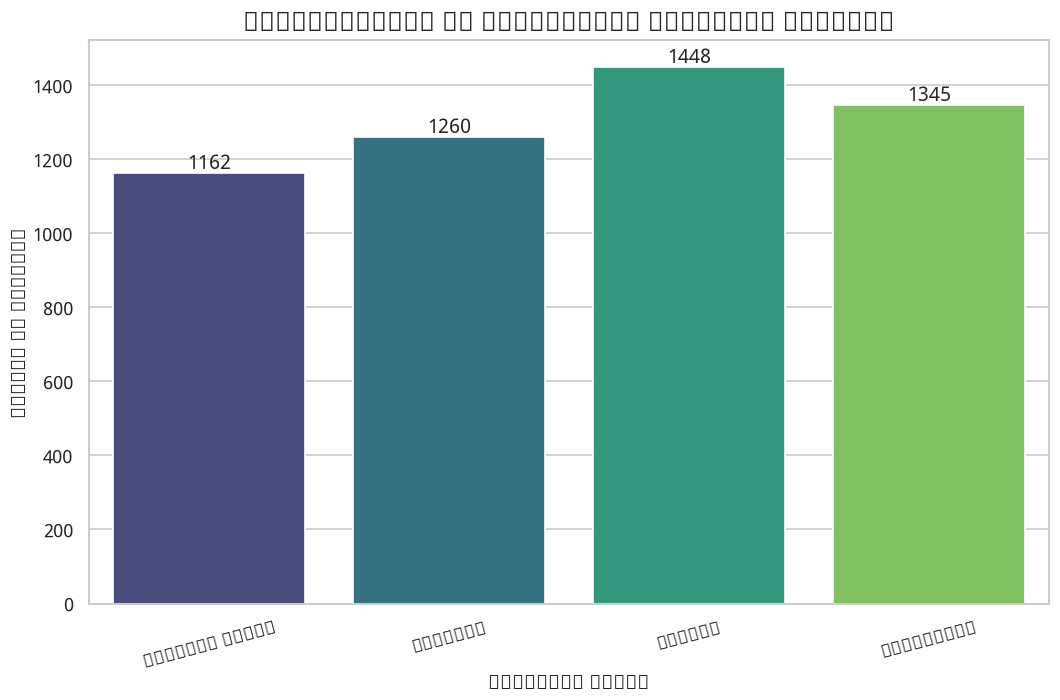

Saved figure: figure_02_word_length_distribution.png


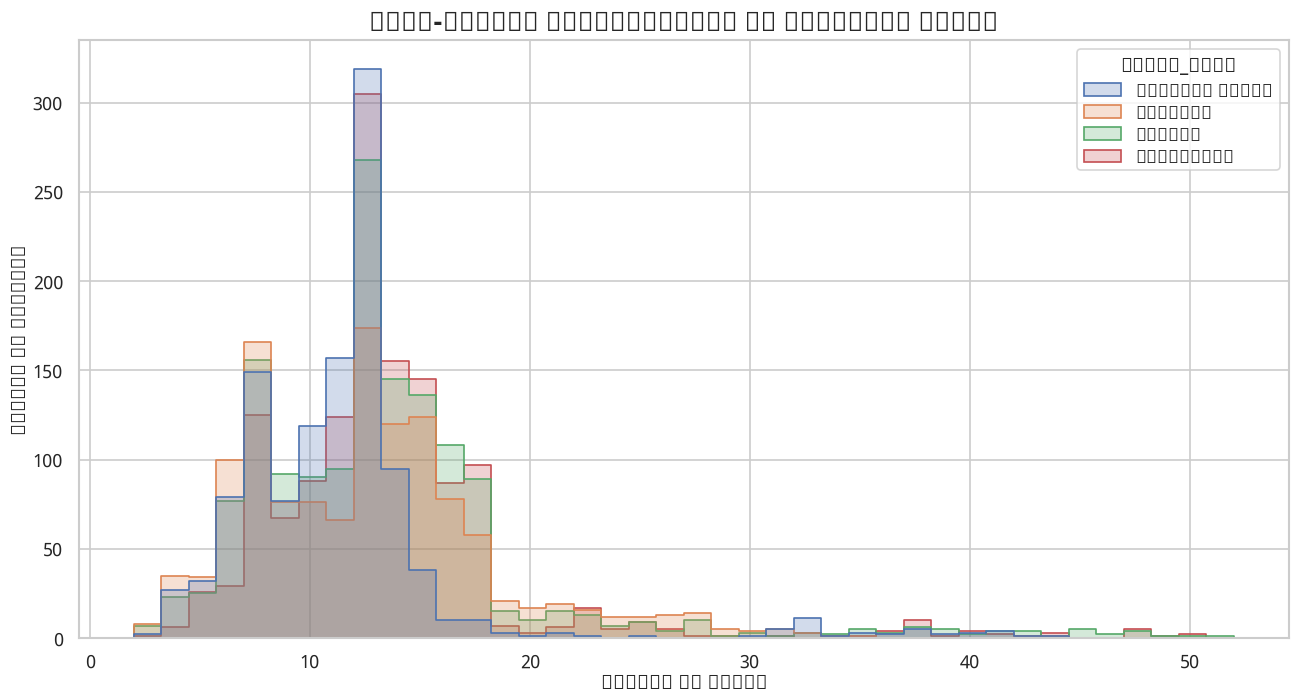

Saved figure: figure_03_character_length_boxplot.png


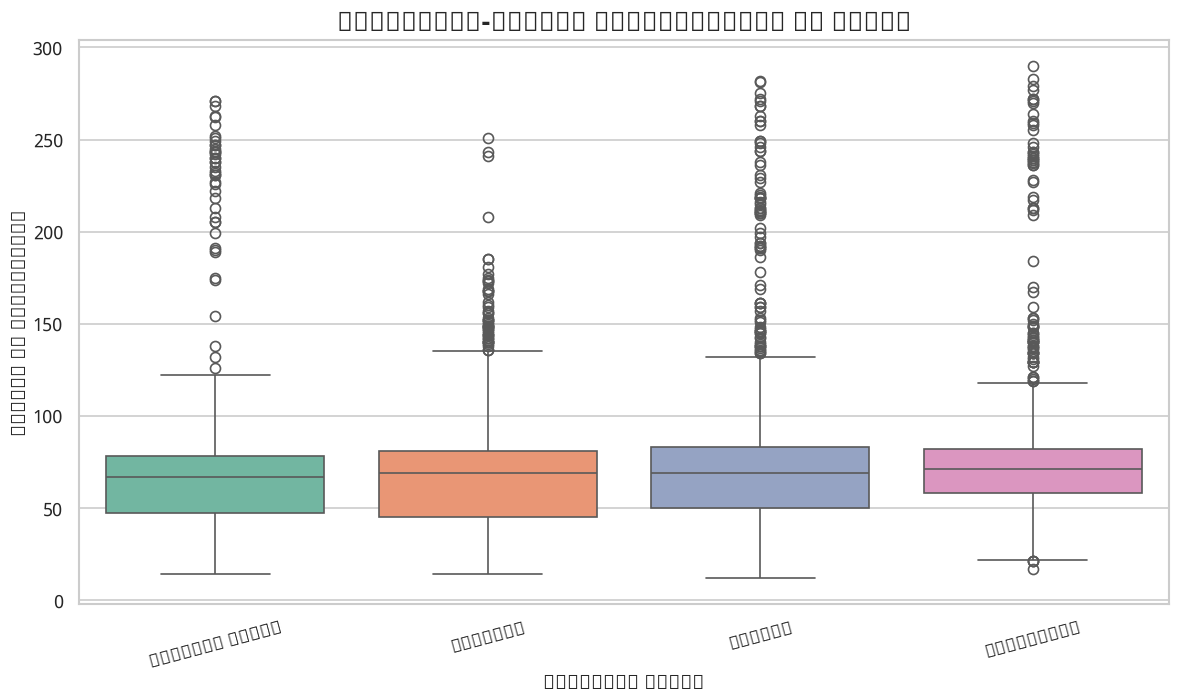

Saved figure: figure_04_script_composition.png


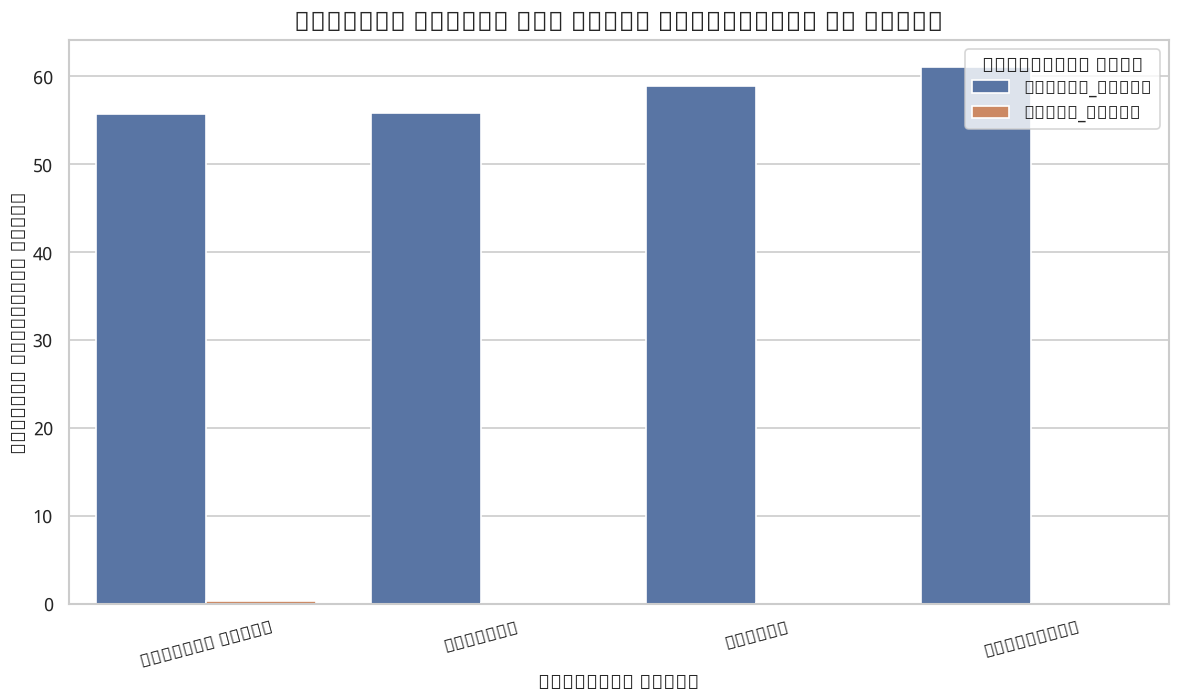

Saved figure: figure_05_dataset_split_sizes.png


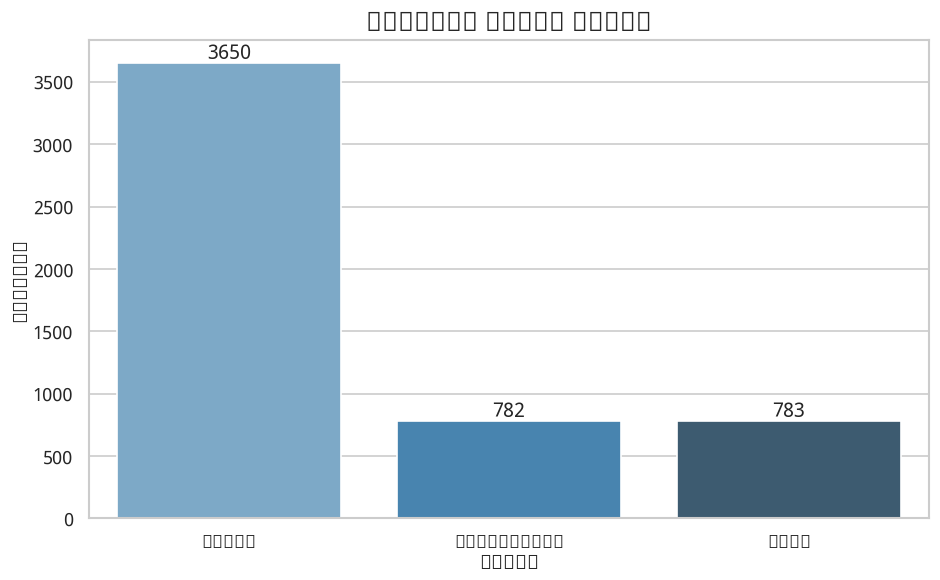

In [57]:
# ============================================================
# REQUIRED EXPLORATORY-DATA-ANALYSIS FIGURES
# ============================================================

# ------------------------------------------------------------
# Figure 1: Class distribution
# ------------------------------------------------------------

figure, axis = plt.subplots(
    figsize=(9, 6)
)

sns.barplot(
    data=class_distribution,
    x='Severity Class',
    y='Samples',
    order=CLASS_ORDER,
    palette='viridis',
    ax=axis
)

axis.set_title(
    'Distribution of Healthcare Severity Classes',
    fontsize=16,
    fontweight='bold'
)

axis.set_xlabel(
    'Severity Class'
)

axis.set_ylabel(
    'Number of Queries'
)

axis.tick_params(
    axis='x',
    rotation=15
)

for container in axis.containers:
    axis.bar_label(
        container,
        padding=3
    )

plt.tight_layout()

save_figure(
    figure,
    'figure_01_class_distribution.png'
)

plt.show()

# ------------------------------------------------------------
# Figure 2: Word-length distribution
# ------------------------------------------------------------

figure, axis = plt.subplots(
    figsize=(11, 6)
)

sns.histplot(
    data=df_report,
    x='word_length',
    hue='label_name',
    hue_order=CLASS_ORDER,
    bins=40,
    element='step',
    common_norm=False,
    ax=axis
)

axis.set_title(
    'Text-Length Distribution by Severity Class',
    fontsize=16,
    fontweight='bold'
)

axis.set_xlabel(
    'Number of Words'
)

axis.set_ylabel(
    'Number of Queries'
)

plt.tight_layout()

save_figure(
    figure,
    'figure_02_word_length_distribution.png'
)

plt.show()

# ------------------------------------------------------------
# Figure 3: Character-length box plot
# ------------------------------------------------------------

figure, axis = plt.subplots(
    figsize=(10, 6)
)

sns.boxplot(
    data=df_report,
    x='label_name',
    y='char_length',
    order=CLASS_ORDER,
    palette='Set2',
    ax=axis
)

axis.set_title(
    'Character-Length Distribution by Class',
    fontsize=16,
    fontweight='bold'
)

axis.set_xlabel(
    'Severity Class'
)

axis.set_ylabel(
    'Number of Characters'
)

axis.tick_params(
    axis='x',
    rotation=15
)

plt.tight_layout()

save_figure(
    figure,
    'figure_03_character_length_boxplot.png'
)

plt.show()

# ------------------------------------------------------------
# Figure 4: Script composition
# ------------------------------------------------------------

script_summary = (
    df_report
    .groupby(
        'label_name'
    )[
        [
            'bangla_chars',
            'latin_chars'
        ]
    ]
    .mean()
    .reindex(
        CLASS_ORDER
    )
    .reset_index()
)

script_long = script_summary.melt(
    id_vars='label_name',
    var_name='Character Type',
    value_name='Average Count'
)

figure, axis = plt.subplots(
    figsize=(10, 6)
)

sns.barplot(
    data=script_long,
    x='label_name',
    y='Average Count',
    hue='Character Type',
    ax=axis
)

axis.set_title(
    'Average Bangla and Latin Characters by Class',
    fontsize=16,
    fontweight='bold'
)

axis.set_xlabel(
    'Severity Class'
)

axis.set_ylabel(
    'Average Character Count'
)

axis.tick_params(
    axis='x',
    rotation=15
)

plt.tight_layout()

save_figure(
    figure,
    'figure_04_script_composition.png'
)

plt.show()

# ------------------------------------------------------------
# Figure 5: Data split sizes
# ------------------------------------------------------------

split_size_table = (
    df_report[
        'split'
    ]
    .value_counts()
    .reindex(
        [
            'Train',
            'Validation',
            'Test'
        ]
    )
    .rename_axis(
        'Split'
    )
    .reset_index(
        name='Samples'
    )
)

figure, axis = plt.subplots(
    figsize=(8, 5)
)

sns.barplot(
    data=split_size_table,
    x='Split',
    y='Samples',
    palette='Blues_d',
    ax=axis
)

axis.set_title(
    'Dataset Split Sizes',
    fontsize=16,
    fontweight='bold'
)

for container in axis.containers:
    axis.bar_label(
        container,
        padding=3
    )

plt.tight_layout()

save_figure(
    figure,
    'figure_05_dataset_split_sizes.png'
)

plt.show()

NameError: name 'BANGLA_STOPWORDS' is not defined

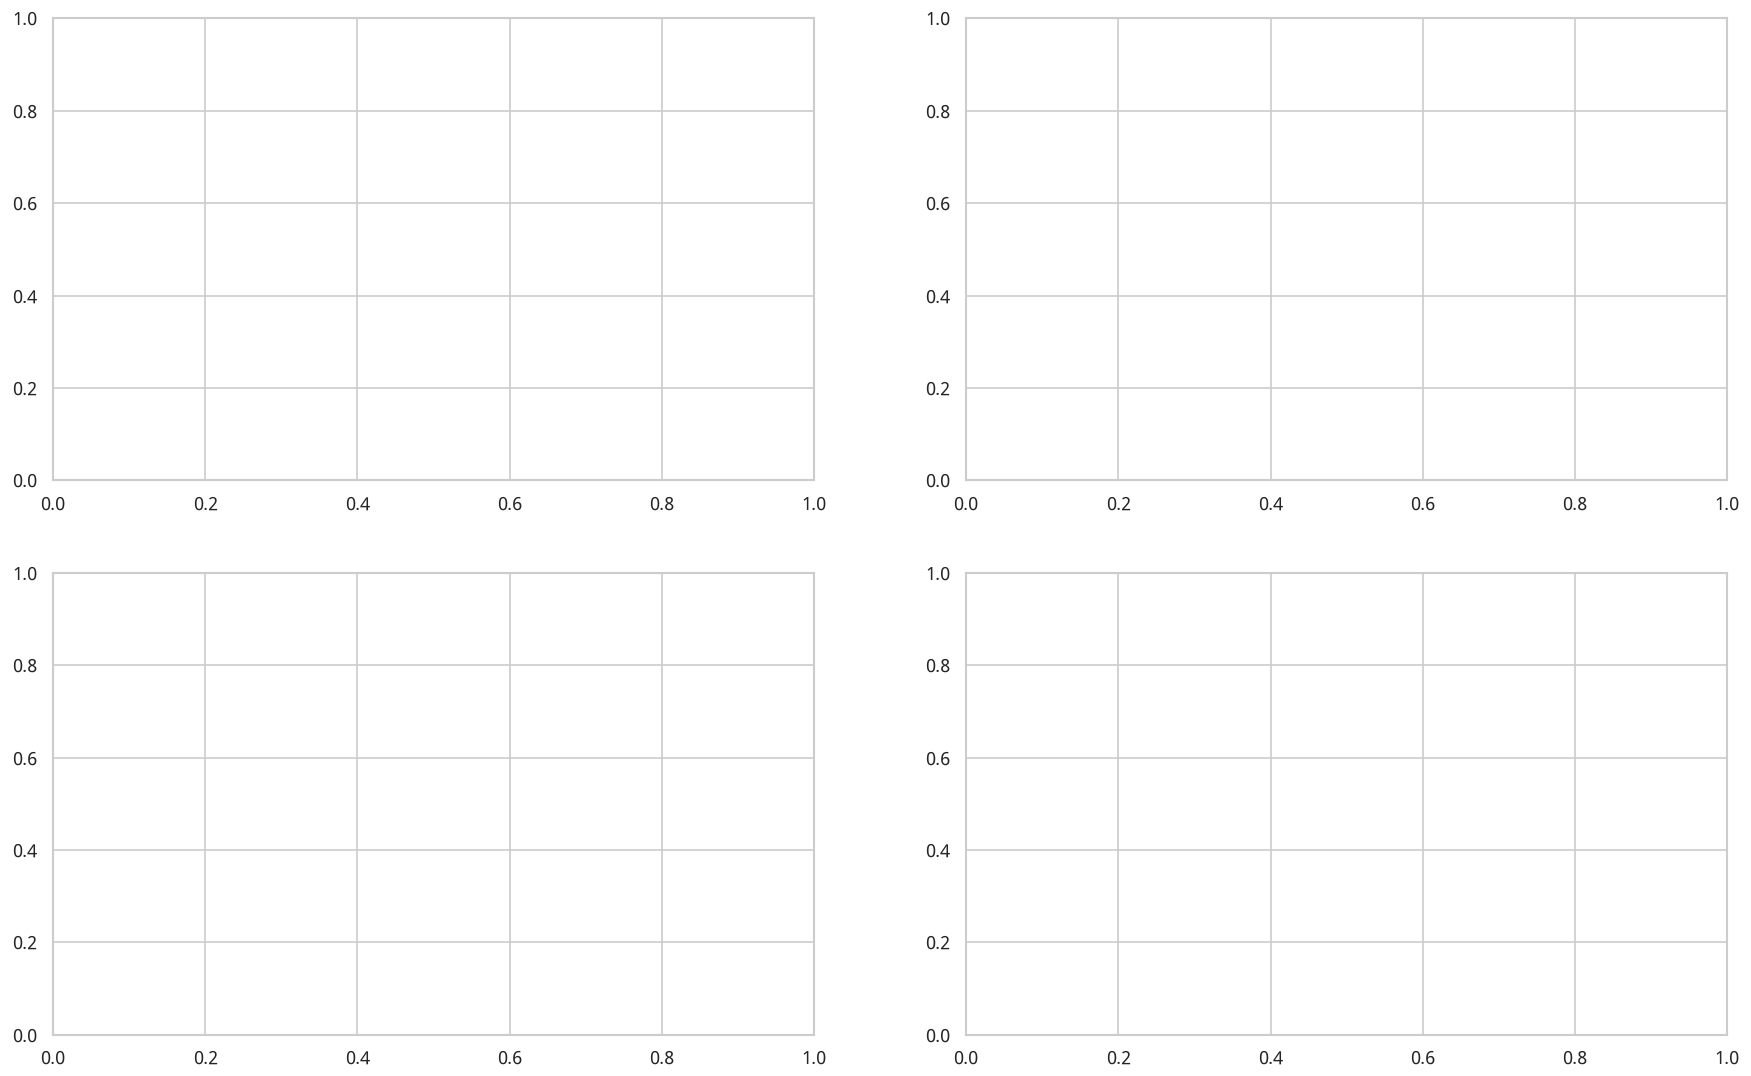

In [58]:
# ============================================================
# WORD CLOUDS AND CO-OCCURRENCE PLOT
# ============================================================

# ------------------------------------------------------------
# Figure 8: One word cloud per class
# ------------------------------------------------------------

figure, axes = plt.subplots(
    2,
    2,
    figsize=(18, 11)
)

for axis, class_name in zip(
    axes.flatten(),
    CLASS_ORDER
):

    class_tokens = [
        token
        for tokens in df_report.loc[
            df_report[
                'label_name'
            ]
            ==
            class_name,
            'token_list'
        ]
        for token in tokens
        if (
            len(token) > 1
            and
            token not in BANGLA_STOPWORDS
        )
    ]

    class_text = ' '.join(
        class_tokens
    )

    word_cloud = WordCloud(
        width=1000,
        height=550,
        background_color='white',
        font_path=BANGLA_FONT_PATH,
        collocations=False,
        max_words=150,
        colormap='viridis'
    ).generate(
        class_text
    )

    axis.imshow(
        word_cloud,
        interpolation='bilinear'
    )

    axis.axis('off')

    axis.set_title(
        class_name,
        fontsize=16,
        fontweight='bold'
    )

plt.suptitle(
    'Word Clouds by Healthcare Severity Class',
    fontsize=20,
    fontweight='bold'
)

plt.tight_layout()

save_figure(
    figure,
    'figure_08_wordclouds_by_class.png'
)

plt.show()

# ------------------------------------------------------------
# Figure 9: Token co-occurrence heatmap
# ------------------------------------------------------------

top_cooccurrence_words = [
    word
    for word, count
    in content_counts.most_common(
        15
    )
]

binary_vectorizer = CountVectorizer(
    vocabulary=top_cooccurrence_words,
    token_pattern=r'(?u)\b\w+\b',
    binary=True
)

cooccurrence_matrix_source = (
    binary_vectorizer.fit_transform(
        df_report[
            'normalized_text'
        ]
    )
)

cooccurrence_matrix = (
    cooccurrence_matrix_source.T
    @
    cooccurrence_matrix_source
).toarray()

np.fill_diagonal(
    cooccurrence_matrix,
    0
)

cooccurrence_table = pd.DataFrame(
    cooccurrence_matrix,
    index=top_cooccurrence_words,
    columns=top_cooccurrence_words
)

cooccurrence_table.to_csv(
    TABLE_DIR /
    'table_10_cooccurrence_matrix.csv',
    encoding='utf-8-sig'
)

figure, axis = plt.subplots(
    figsize=(13, 11)
)

sns.heatmap(
    cooccurrence_table,
    cmap='YlGnBu',
    annot=True,
    fmt='d',
    linewidths=0.3,
    ax=axis
)

axis.set_title(
    'Frequent-Word Co-occurrence Matrix',
    fontsize=16,
    fontweight='bold'
)

for label in (
    axis.get_xticklabels()
    +
    axis.get_yticklabels()
):
    label.set_fontproperties(
        BANGLA_FONT
    )

axis.tick_params(
    axis='x',
    rotation=45
)

axis.tick_params(
    axis='y',
    rotation=0
)

plt.tight_layout()

save_figure(
    figure,
    'figure_09_word_cooccurrence_heatmap.png'
)

plt.show()

In [ ]:
# ============================================================
# TEXT STATISTICS AND VOCABULARY TABLES
# ============================================================

text_statistics = (
    df_report
    .groupby(
        'label_name'
    )[
        [
            'word_length',
            'char_length',
            'bangla_chars',
            'latin_chars',
            'latin_ratio'
        ]
    ]
    .agg(
        [
            'mean',
            'median',
            'std',
            'min',
            'max'
        ]
    )
    .round(2)
    .reindex(
        CLASS_ORDER
    )
)

# Flatten multi-level column names
text_statistics.columns = [
    f'{feature}_{statistic}'
    for feature, statistic
    in text_statistics.columns
]

text_statistics = (
    text_statistics
    .reset_index()
    .rename(
        columns={
            'label_name':
            'Severity Class'
        }
    )
)

save_table_csv(
    text_statistics,
    'table_11_text_statistics_by_class.csv'
)

# A smaller version for a readable report image
compact_text_statistics = (
    df_report
    .groupby(
        'label_name'
    )
    .agg(
        Samples=(
            'text',
            'size'
        ),
        Mean_Words=(
            'word_length',
            'mean'
        ),
        Median_Words=(
            'word_length',
            'median'
        ),
        Mean_Characters=(
            'char_length',
            'mean'
        ),
        Vocabulary=(
            'text',
            lambda series: len({
                token
                for text in series
                for token in tokenize_text(
                    text
                )
            })
        ),
        Mean_Latin_Ratio=(
            'latin_ratio',
            'mean'
        )
    )
    .reindex(
        CLASS_ORDER
    )
    .round(3)
    .reset_index()
    .rename(
        columns={
            'label_name':
            'Severity Class'
        }
    )
)

save_table_csv(
    compact_text_statistics,
    'table_12_compact_text_statistics.csv'
)

save_table_image(
    compact_text_statistics,
    'table_12_compact_text_statistics.png',
    'Table 12: Text Statistics by Severity Class',
    font_size=8
)

vocabulary_summary = pd.DataFrame({
    'Measure': [
        'Total clean samples',
        'Vocabulary size',
        'Total tokens',
        'Unique content words',
        'Average words per query',
        'Median words per query',
        'Maximum words in a query'
    ],
    'Value': [
        len(df_report),
        len(vocabulary),
        len(all_tokens),
        len(content_counts),
        round(
            df_report[
                'word_length'
            ].mean(),
            2
        ),
        round(
            df_report[
                'word_length'
            ].median(),
            2
        ),
        int(
            df_report[
                'word_length'
            ].max()
        )
    ]
})

save_table_csv(
    vocabulary_summary,
    'table_13_vocabulary_summary.csv'
)

save_table_image(
    vocabulary_summary,
    'table_13_vocabulary_summary.png',
    'Table 13: Vocabulary and Token Summary'
)

In [ ]:
# ============================================================
# MODEL COMPARISON AND TUNING FIGURES
# ============================================================

MODEL_COMPARISON_PATH = (
    BACKUP_DIR /
    'final_results' /
    'model_comparison.csv'
)

if not MODEL_COMPARISON_PATH.exists():
    raise FileNotFoundError(
        "Run corrected Section 25 first. "
        "model_comparison.csv is missing."
    )

model_comparison = pd.read_csv(
    MODEL_COMPARISON_PATH
)

save_table_csv(
    model_comparison,
    'table_14_complete_model_comparison.csv'
)

display_columns = [
    column
    for column in [
        'model',
        'stage',
        'accuracy',
        'macro_precision',
        'macro_recall',
        'macro_f1',
        'roc_auc_ovr'
    ]
    if column in model_comparison.columns
]

save_table_image(
    model_comparison[
        display_columns
    ],
    'table_14_complete_model_comparison.png',
    'Table 14: Complete Model Comparison',
    max_rows=20,
    font_size=7
)

# ------------------------------------------------------------
# Figure 10: Macro-F1 comparison
# ------------------------------------------------------------

plot_model_results = (
    model_comparison
    .dropna(
        subset=[
            'macro_f1'
        ]
    )
    .sort_values(
        'macro_f1',
        ascending=True
    )
)

figure, axis = plt.subplots(
    figsize=(12, 8)
)

sns.barplot(
    data=plot_model_results,
    x='macro_f1',
    y='model',
    hue='stage',
    dodge=False,
    palette='Set2',
    ax=axis
)

axis.set_title(
    'Macro-F1 Comparison Across NLP Models',
    fontsize=16,
    fontweight='bold'
)

axis.set_xlabel(
    'Macro-F1'
)

axis.set_ylabel(
    'Model'
)

axis.set_xlim(
    0,
    1
)

for container in axis.containers:
    axis.bar_label(
        container,
        fmt='%.3f',
        padding=3
    )

plt.tight_layout()

save_figure(
    figure,
    'figure_10_model_macro_f1_comparison.png'
)

plt.show()

# ------------------------------------------------------------
# Figure 11: Accuracy, precision, recall and F1
# ------------------------------------------------------------

metric_columns = [
    column
    for column in [
        'accuracy',
        'macro_precision',
        'macro_recall',
        'macro_f1'
    ]
    if column in model_comparison.columns
]

multi_metric_table = (
    model_comparison[
        [
            'model'
        ]
        +
        metric_columns
    ]
    .dropna(
        subset=[
            'macro_f1'
        ]
    )
    .set_index(
        'model'
    )
)

figure, axis = plt.subplots(
    figsize=(15, 8)
)

multi_metric_table.plot(
    kind='bar',
    ax=axis,
    width=0.82,
    colormap='viridis'
)

axis.set_title(
    'Accuracy, Precision, Recall and F1 Comparison',
    fontsize=16,
    fontweight='bold'
)

axis.set_xlabel(
    'Model'
)

axis.set_ylabel(
    'Score'
)

axis.set_ylim(
    0,
    1
)

axis.tick_params(
    axis='x',
    rotation=45
)

axis.legend(
    title='Metric',
    bbox_to_anchor=(
        1.02,
        1
    ),
    loc='upper left'
)

plt.tight_layout()

save_figure(
    figure,
    'figure_11_multi_metric_model_comparison.png'
)

plt.show()

# ------------------------------------------------------------
# Transformer tuning trials
# ------------------------------------------------------------

TRANSFORMER_TRIAL_PATH = (
    BACKUP_DIR /
    'transformer_tuning' /
    'all_trial_results.csv'
)

if TRANSFORMER_TRIAL_PATH.exists():

    transformer_trials = pd.read_csv(
        TRANSFORMER_TRIAL_PATH
    )

    save_table_csv(
        transformer_trials,
        'table_15_transformer_tuning_trials.csv'
    )

    save_table_image(
        transformer_trials,
        'table_15_transformer_tuning_trials.png',
        'Table 15: BanglaBERT Hyperparameter-Tuning Results',
        font_size=7
    )

    figure, axis = plt.subplots(
        figsize=(9, 6)
    )

    sns.barplot(
        data=transformer_trials,
        x='trial',
        y='validation_macro_f1',
        palette='flare',
        ax=axis
    )

    axis.set_title(
        'BanglaBERT Tuning Trial Comparison',
        fontsize=16,
        fontweight='bold'
    )

    axis.set_xlabel(
        'Trial'
    )

    axis.set_ylabel(
        'Validation Macro-F1'
    )

    for container in axis.containers:
        axis.bar_label(
            container,
            fmt='%.4f',
            padding=3
        )

    plt.tight_layout()

    save_figure(
        figure,
        'figure_12_transformer_tuning_comparison.png'
    )

    plt.show()

# ------------------------------------------------------------
# Classical tuning table
# ------------------------------------------------------------

CLASSICAL_TUNING_PATH = (
    BACKUP_DIR /
    'tuned_model_results.csv'
)

if CLASSICAL_TUNING_PATH.exists():

    classical_tuning = pd.read_csv(
        CLASSICAL_TUNING_PATH
    )

    save_table_csv(
        classical_tuning,
        'table_16_classical_tuning_results.csv'
    )

    save_table_image(
        classical_tuning,
        'table_16_classical_tuning_results.png',
        'Table 16: Tuned SVM and XGBoost Results',
        font_size=8
    )

In [ ]:
# ============================================================
# SCORE-BN EVALUATION FIGURES AND TABLES
# ============================================================

SCORE_METRICS_PATH = (
    BACKUP_DIR /
    'score_bn' /
    'test_metrics.json'
)

SCORE_ERROR_PATH = (
    BACKUP_DIR /
    'score_bn' /
    'test_predictions_and_errors.csv'
)

ORIGINAL_PROBABILITY_PATH = (
    BACKUP_DIR /
    'score_bn' /
    'original_test_probabilities.npy'
)

ROMANIZED_PROBABILITY_PATH = (
    BACKUP_DIR /
    'score_bn' /
    'romanized_test_probabilities.npy'
)

if not SCORE_ERROR_PATH.exists():
    raise FileNotFoundError(
        "SCORE-BN prediction file is missing. "
        "Run corrected Section 21 first."
    )

score_errors = pd.read_csv(
    SCORE_ERROR_PATH
)

if SCORE_METRICS_PATH.exists():

    with open(
        SCORE_METRICS_PATH,
        'r',
        encoding='utf-8'
    ) as file:

        score_metrics = json.load(
            file
        )

    score_metric_table = pd.DataFrame({
        'Metric': list(
            score_metrics.keys()
        ),
        'Value': list(
            score_metrics.values()
        )
    })

    save_table_csv(
        score_metric_table,
        'table_17_score_bn_metrics.csv'
    )

    save_table_image(
        score_metric_table,
        'table_17_score_bn_metrics.png',
        'Table 17: SCORE-BN Evaluation Metrics',
        max_rows=30,
        font_size=8
    )

# ------------------------------------------------------------
# Confusion matrices
# ------------------------------------------------------------

true_labels = (
    score_errors[
        'true_label_id'
    ]
    .astype(int)
    .to_numpy()
)

original_predictions = (
    score_errors[
        'original_prediction_id'
    ]
    .astype(int)
    .to_numpy()
)

romanized_predictions = (
    score_errors[
        'romanized_prediction_id'
    ]
    .astype(int)
    .to_numpy()
)

figure, axes = plt.subplots(
    1,
    2,
    figsize=(16, 6)
)

ConfusionMatrixDisplay.from_predictions(
    true_labels,
    original_predictions,
    labels=[
        0,
        1,
        2,
        3
    ],
    display_labels=CLASS_ORDER,
    cmap='Purples',
    colorbar=False,
    ax=axes[0]
)

axes[0].set_title(
    'SCORE-BN: Original Bangla'
)

axes[0].tick_params(
    axis='x',
    rotation=25
)

ConfusionMatrixDisplay.from_predictions(
    true_labels,
    romanized_predictions,
    labels=[
        0,
        1,
        2,
        3
    ],
    display_labels=CLASS_ORDER,
    cmap='Oranges',
    colorbar=False,
    ax=axes[1]
)

axes[1].set_title(
    'SCORE-BN: Romanized Bangla'
)

axes[1].tick_params(
    axis='x',
    rotation=25
)

plt.tight_layout()

save_figure(
    figure,
    'figure_13_score_bn_confusion_matrices.png'
)

plt.show()

# ------------------------------------------------------------
# ROC curves
# ------------------------------------------------------------

if ORIGINAL_PROBABILITY_PATH.exists():

    original_probabilities = np.load(
        ORIGINAL_PROBABILITY_PATH
    )

    binary_labels = label_binarize(
        true_labels,
        classes=[
            0,
            1,
            2,
            3
        ]
    )

    figure, axis = plt.subplots(
        figsize=(9, 7)
    )

    for class_index in range(4):

        false_positive_rate, true_positive_rate, _ = (
            roc_curve(
                binary_labels[
                    :,
                    class_index
                ],
                original_probabilities[
                    :,
                    class_index
                ]
            )
        )

        class_auc = auc(
            false_positive_rate,
            true_positive_rate
        )

        axis.plot(
            false_positive_rate,
            true_positive_rate,
            linewidth=2,
            label=(
                f'{ID2LABEL[class_index]} '
                f'(AUC={class_auc:.3f})'
            )
        )

    axis.plot(
        [
            0,
            1
        ],
        [
            0,
            1
        ],
        linestyle='--',
        color='gray'
    )

    axis.set_title(
        'SCORE-BN One-vs-Rest ROC Curves',
        fontsize=16,
        fontweight='bold'
    )

    axis.set_xlabel(
        'False Positive Rate'
    )

    axis.set_ylabel(
        'True Positive Rate'
    )

    axis.legend(
        loc='lower right'
    )

    plt.tight_layout()

    save_figure(
        figure,
        'figure_14_score_bn_roc_curves.png'
    )

    plt.show()

# ------------------------------------------------------------
# Original vs Romanized comparison
# ------------------------------------------------------------

if SCORE_METRICS_PATH.exists():

    robustness_table = pd.DataFrame({
        'Condition': [
            'Original Bangla',
            'Romanized Bangla'
        ],
        'Accuracy': [
            score_metrics.get(
                'accuracy',
                np.nan
            ),
            score_metrics.get(
                'romanized_accuracy',
                np.nan
            )
        ],
        'Macro Precision': [
            score_metrics.get(
                'macro_precision',
                np.nan
            ),
            score_metrics.get(
                'romanized_macro_precision',
                np.nan
            )
        ],
        'Macro Recall': [
            score_metrics.get(
                'macro_recall',
                np.nan
            ),
            score_metrics.get(
                'romanized_macro_recall',
                np.nan
            )
        ],
        'Macro F1': [
            score_metrics.get(
                'macro_f1',
                np.nan
            ),
            score_metrics.get(
                'romanized_macro_f1',
                np.nan
            )
        ],
        'ROC-AUC': [
            score_metrics.get(
                'roc_auc_ovr',
                np.nan
            ),
            score_metrics.get(
                'romanized_roc_auc_ovr',
                np.nan
            )
        ]
    })

    save_table_csv(
        robustness_table,
        'table_18_original_romanized_comparison.csv'
    )

    save_table_image(
        robustness_table,
        'table_18_original_romanized_comparison.png',
        'Table 18: Original and Romanized Test Performance',
        font_size=8
    )

    robustness_plot = (
        robustness_table
        .set_index(
            'Condition'
        )[
            [
                'Accuracy',
                'Macro Precision',
                'Macro Recall',
                'Macro F1',
                'ROC-AUC'
            ]
        ]
    )

    figure, axis = plt.subplots(
        figsize=(11, 6)
    )

    robustness_plot.plot(
        kind='bar',
        ax=axis,
        width=0.75,
        colormap='Set2'
    )

    axis.set_title(
        'Original vs Romanized Bangla Performance',
        fontsize=16,
        fontweight='bold'
    )

    axis.set_xlabel(
        'Input Condition'
    )

    axis.set_ylabel(
        'Score'
    )

    axis.set_ylim(
        0,
        1
    )

    axis.tick_params(
        axis='x',
        rotation=0
    )

    axis.legend(
        bbox_to_anchor=(
            1.02,
            1
        ),
        loc='upper left'
    )

    plt.tight_layout()

    save_figure(
        figure,
        'figure_15_cross_script_robustness.png'
    )

    plt.show()

In [ ]:
# ============================================================
# TRAINING HISTORY AND ERROR ANALYSIS
# ============================================================

# ------------------------------------------------------------
# SCORE-BN training history
# ------------------------------------------------------------

SCORE_HISTORY_PATH = (
    BACKUP_DIR /
    'score_bn' /
    'training_history.csv'
)

if SCORE_HISTORY_PATH.exists():

    score_history = pd.read_csv(
        SCORE_HISTORY_PATH
    )

    save_table_csv(
        score_history,
        'table_19_score_bn_training_history.csv'
    )

    figure, axes = plt.subplots(
        1,
        2,
        figsize=(14, 5)
    )

    axes[0].plot(
        score_history[
            'epoch'
        ],
        score_history[
            'training_loss'
        ],
        marker='o',
        label='Training Loss'
    )

    axes[0].plot(
        score_history[
            'epoch'
        ],
        score_history[
            'validation_loss'
        ],
        marker='o',
        label='Validation Loss'
    )

    axes[0].set_title(
        'SCORE-BN Training and Validation Loss'
    )

    axes[0].set_xlabel(
        'Epoch'
    )

    axes[0].set_ylabel(
        'Loss'
    )

    axes[0].legend()

    axes[1].plot(
        score_history[
            'epoch'
        ],
        score_history[
            'validation_macro_f1'
        ],
        marker='o',
        color='#2A9D8F'
    )

    axes[1].set_title(
        'SCORE-BN Validation Macro-F1'
    )

    axes[1].set_xlabel(
        'Epoch'
    )

    axes[1].set_ylabel(
        'Macro-F1'
    )

    axes[1].set_ylim(
        0,
        1
    )

    plt.tight_layout()

    save_figure(
        figure,
        'figure_16_score_bn_training_history.png'
    )

    plt.show()

# ------------------------------------------------------------
# CNN, BiLSTM and BiGRU training curves
# ------------------------------------------------------------

deep_history_files = {
    'CNN':
        BACKUP_DIR /
        'CNN_training_history.csv',

    'BiLSTM':
        BACKUP_DIR /
        'BiLSTM_training_history.csv',

    'BiGRU':
        BACKUP_DIR /
        'BiGRU_training_history.csv'
}

figure, axes = plt.subplots(
    1,
    2,
    figsize=(15, 6)
)

any_deep_history = False

for model_name, history_path in deep_history_files.items():

    if not history_path.exists():
        continue

    any_deep_history = True

    history = pd.read_csv(
        history_path
    )

    epochs = np.arange(
        1,
        len(history) + 1
    )

    if 'loss' in history.columns:

        axes[0].plot(
            epochs,
            history[
                'loss'
            ],
            marker='o',
            label=(
                f'{model_name} train'
            )
        )

    if 'val_loss' in history.columns:

        axes[0].plot(
            epochs,
            history[
                'val_loss'
            ],
            linestyle='--',
            label=(
                f'{model_name} validation'
            )
        )

    if 'accuracy' in history.columns:

        axes[1].plot(
            epochs,
            history[
                'accuracy'
            ],
            marker='o',
            label=(
                f'{model_name} train'
            )
        )

    if 'val_accuracy' in history.columns:

        axes[1].plot(
            epochs,
            history[
                'val_accuracy'
            ],
            linestyle='--',
            label=(
                f'{model_name} validation'
            )
        )

if any_deep_history:

    axes[0].set_title(
        'Deep-Model Loss Curves'
    )

    axes[0].set_xlabel(
        'Epoch'
    )

    axes[0].set_ylabel(
        'Loss'
    )

    axes[0].legend(
        fontsize=8
    )

    axes[1].set_title(
        'Deep-Model Accuracy Curves'
    )

    axes[1].set_xlabel(
        'Epoch'
    )

    axes[1].set_ylabel(
        'Accuracy'
    )

    axes[1].legend(
        fontsize=8
    )

    plt.tight_layout()

    save_figure(
        figure,
        'figure_17_deep_model_training_curves.png'
    )

    plt.show()

else:

    plt.close(
        figure
    )

# ------------------------------------------------------------
# Error analysis
# ------------------------------------------------------------

error_summary = pd.DataFrame({
    'Error Type': [
        'Correct predictions',
        'Under-prioritised',
        'Over-prioritised',
        'Severe ordinal errors',
        'Cross-script disagreements'
    ],
    'Samples': [
        int(
            (
                original_predictions
                ==
                true_labels
            ).sum()
        ),
        int(
            (
                original_predictions
                <
                true_labels
            ).sum()
        ),
        int(
            (
                original_predictions
                >
                true_labels
            ).sum()
        ),
        int(
            (
                np.abs(
                    original_predictions
                    -
                    true_labels
                )
                >= 2
            ).sum()
        ),
        int(
            (
                original_predictions
                !=
                romanized_predictions
            ).sum()
        )
    ]
})

save_table_csv(
    error_summary,
    'table_20_score_bn_error_summary.csv'
)

save_table_image(
    error_summary,
    'table_20_score_bn_error_summary.png',
    'Table 20: SCORE-BN Error Analysis'
)

figure, axis = plt.subplots(
    figsize=(10, 6)
)

sns.barplot(
    data=error_summary,
    x='Samples',
    y='Error Type',
    palette='rocket',
    ax=axis
)

axis.set_title(
    'SCORE-BN Prediction and Error Summary',
    fontsize=16,
    fontweight='bold'
)

for container in axis.containers:
    axis.bar_label(
        container,
        padding=3
    )

plt.tight_layout()

save_figure(
    figure,
    'figure_18_score_bn_error_summary.png'
)

plt.show()

In [ ]:
# ============================================================
# COLLECT XAI FIGURES AND CREATE FINAL ASSET CHECKLIST
# ============================================================

EXPLAINABILITY_DIR = (
    BACKUP_DIR /
    'explainability'
)

# Copy corrected LIME/SHAP figures into the report directory
xai_candidates = [
    'lime_explanation_final.png',
    'lime_example_bangla_fixed.png',
    'lime_example.png',
    'shap_global_summary_bangla_fixed.png',
    'shap_global_summary.png'
]

for filename in xai_candidates:

    source_path = (
        EXPLAINABILITY_DIR /
        filename
    )

    if source_path.exists():

        destination_path = (
            FIGURE_DIR /
            filename
        )

        shutil.copy2(
            source_path,
            destination_path
        )

        generated_assets.append(
            str(destination_path)
        )

        print(
            "Copied XAI figure:",
            filename
        )

# Copy XAI tables/HTML
xai_report_candidates = [
    'lime_example.html',
    'lime_feature_weights.csv',
    'logistic_regression_top_features.csv'
]

for filename in xai_report_candidates:

    source_path = (
        EXPLAINABILITY_DIR /
        filename
    )

    if source_path.exists():

        destination_path = (
            TABLE_DIR /
            filename
        )

        shutil.copy2(
            source_path,
            destination_path
        )

        generated_assets.append(
            str(destination_path)
        )

        print(
            "Copied XAI asset:",
            filename
        )

# ------------------------------------------------------------
# Required-report asset checklist
# ------------------------------------------------------------

required_report_assets = [
    {
        'PDF Requirement':
        'Dataset description',

        'Recommended Asset':
        'table_01_dataset_summary.png'
    },
    {
        'PDF Requirement':
        'Target/class analysis',

        'Recommended Asset':
        'figure_01_class_distribution.png'
    },
    {
        'PDF Requirement':
        'Text-length distribution',

        'Recommended Asset':
        'figure_02_word_length_distribution.png'
    },
    {
        'PDF Requirement':
        'Vocabulary size',

        'Recommended Asset':
        'table_13_vocabulary_summary.png'
    },
    {
        'PDF Requirement':
        'Word frequency',

        'Recommended Asset':
        'figure_06_top_content_words.png'
    },
    {
        'PDF Requirement':
        'Stopword analysis',

        'Recommended Asset':
        'figure_07_stopword_frequency.png'
    },
    {
        'PDF Requirement':
        'N-gram analysis',

        'Recommended Asset':
        'figure_bigram_frequency.png'
    },
    {
        'PDF Requirement':
        'Word cloud',

        'Recommended Asset':
        'figure_08_wordclouds_by_class.png'
    },
    {
        'PDF Requirement':
        'Co-occurrence plot',

        'Recommended Asset':
        'figure_09_word_cooccurrence_heatmap.png'
    },
    {
        'PDF Requirement':
        'Preprocessing',

        'Recommended Asset':
        'table_04_preprocessing_summary.png'
    },
    {
        'PDF Requirement':
        'Feature engineering',

        'Recommended Asset':
        'table_05_feature_engineering.png'
    },
    {
        'PDF Requirement':
        'Eight models/five families',

        'Recommended Asset':
        'table_06_model_families.png'
    },
    {
        'PDF Requirement':
        'Hyperparameter tuning',

        'Recommended Asset':
        'figure_12_transformer_tuning_comparison.png'
    },
    {
        'PDF Requirement':
        'Model comparison',

        'Recommended Asset':
        'figure_11_multi_metric_model_comparison.png'
    },
    {
        'PDF Requirement':
        'Confusion matrix',

        'Recommended Asset':
        'figure_13_score_bn_confusion_matrices.png'
    },
    {
        'PDF Requirement':
        'ROC-AUC',

        'Recommended Asset':
        'figure_14_score_bn_roc_curves.png'
    },
    {
        'PDF Requirement':
        'Explainable AI—LIME',

        'Recommended Asset':
        'lime_explanation_final.png'
    },
    {
        'PDF Requirement':
        'Explainable AI—SHAP',

        'Recommended Asset':
        'shap_global_summary_bangla_fixed.png'
    },
    {
        'PDF Requirement':
        'Proposed-model robustness',

        'Recommended Asset':
        'figure_15_cross_script_robustness.png'
    }
]

asset_checklist = pd.DataFrame(
    required_report_assets
)

asset_checklist[
    'Exists'
] = asset_checklist[
    'Recommended Asset'
].apply(
    lambda filename: (
        FIGURE_DIR /
        filename
    ).exists()
    or
    (
        TABLE_DIR /
        filename
    ).exists()
)

save_table_csv(
    asset_checklist,
    'report_requirement_asset_checklist.csv'
)

display(
    asset_checklist
)

# ------------------------------------------------------------
# Complete inventory
# ------------------------------------------------------------

inventory_rows = []

for folder_name, folder_path in [
    (
        'Figure',
        FIGURE_DIR
    ),
    (
        'Table',
        TABLE_DIR
    )
]:

    for file_path in folder_path.rglob(
        '*'
    ):

        if file_path.is_file():

            inventory_rows.append({
                'Type': folder_name,
                'Filename': file_path.name,
                'Path': str(
                    file_path
                ),
                'Size KB': round(
                    file_path.stat().st_size
                    /
                    1024,
                    2
                )
            })

report_asset_inventory = (
    pd.DataFrame(
        inventory_rows
    )
    .sort_values(
        [
            'Type',
            'Filename'
        ]
    )
    .reset_index(
        drop=True
    )
)

save_table_csv(
    report_asset_inventory,
    'complete_report_asset_inventory.csv'
)

print(
    "\nTotal report figures:",
    len(
        list(
            FIGURE_DIR.glob(
                '*'
            )
        )
    )
)

print(
    "Total report tables/assets:",
    len(
        list(
            TABLE_DIR.glob(
                '*'
            )
        )
    )
)

print(
    "\nReport assets saved in:"
)

print(REPORT_ASSET_DIR)

In [59]:
# ============================================================
# CREATE DOWNLOADABLE REPORT-ASSETS ZIP
# ============================================================

import shutil
from pathlib import Path

EXPORTS_DIR = Path(
    '/content/drive/MyDrive/SCORE_BN_Exports'
)

EXPORTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

temporary_zip_base = (
    '/content/SCORE_BN_REPORT_ASSETS'
)

temporary_zip_path = shutil.make_archive(
    temporary_zip_base,
    'zip',
    root_dir=REPORT_ASSET_DIR
)

drive_zip_path = (
    EXPORTS_DIR /
    'SCORE_BN_REPORT_ASSETS.zip'
)

shutil.copy2(
    temporary_zip_path,
    drive_zip_path
)

print(
    "Report-assets ZIP created:"
)

print(drive_zip_path)

print(
    "ZIP size:",
    round(
        drive_zip_path.stat().st_size
        /
        1024**2,
        2
    ),
    "MB"
)

print(
    "\nYou may now run the final complete-backup "
    "cell and then turn off Colab."
)

Report-assets ZIP created:
/content/drive/MyDrive/SCORE_BN_Exports/SCORE_BN_REPORT_ASSETS.zip
ZIP size: 0.49 MB

You may now run the final complete-backup cell and then turn off Colab.


In [60]:
# ============================================================
# DEFINITIVE BANGLA FONT REPAIR
# ============================================================

!apt-get update -qq
!apt-get install -y -qq fonts-noto-core fonts-noto-extra fontconfig
!fc-cache -f -v > /dev/null

import os
import glob
import re
import unicodedata
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib import font_manager

# ------------------------------------------------------------
# 1. Use the exact regular Bengali font
# ------------------------------------------------------------

possible_font_paths = [
    Path(
        '/usr/share/fonts/truetype/noto/'
        'NotoSansBengali-Regular.ttf'
    ),
    Path(
        '/usr/share/fonts/truetype/noto/'
        'NotoSerifBengali-Regular.ttf'
    )
]

BANGLA_FONT_PATH = next(
    (
        path
        for path in possible_font_paths
        if path.exists()
    ),
    None
)

if BANGLA_FONT_PATH is None:

    discovered_fonts = [
        Path(path)
        for path
        in font_manager.findSystemFonts(
            fontext='ttf'
        )
        if (
            'NotoSansBengali-Regular'
            in Path(path).name
        )
    ]

    if not discovered_fonts:
        raise FileNotFoundError(
            "Noto Sans Bengali Regular was not found."
        )

    BANGLA_FONT_PATH = discovered_fonts[0]

# ------------------------------------------------------------
# 2. Clear the old Matplotlib font cache
# ------------------------------------------------------------

for cache_file in glob.glob(
    os.path.join(
        matplotlib.get_cachedir(),
        'fontlist-*.json'
    )
):
    try:
        os.remove(cache_file)
    except OSError:
        pass

# Explicitly register this exact file
font_manager.fontManager.addfont(
    str(BANGLA_FONT_PATH)
)

BANGLA_FONT = font_manager.FontProperties(
    fname=str(BANGLA_FONT_PATH)
)

BANGLA_FONT_NAME = BANGLA_FONT.get_name()

# Reapply Seaborn first, then override its font settings
sns.set_theme(
    style='whitegrid',
    font=BANGLA_FONT_NAME
)

plt.rcParams.update({
    'font.family': BANGLA_FONT_NAME,
    'font.sans-serif': [
        BANGLA_FONT_NAME,
        'Noto Sans Bengali',
        'DejaVu Sans'
    ],
    'axes.unicode_minus': False,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'svg.fonttype': 'none'
})

print("Selected font:", BANGLA_FONT_NAME)
print("Exact file:", BANGLA_FONT_PATH)

assert (
    BANGLA_FONT_PATH.name
    ==
    'NotoSansBengali-Regular.ttf'
), "The regular Bengali font was not selected."

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selected font: Noto Sans Bengali
Exact file: /usr/share/fonts/truetype/noto/NotoSansBengali-Regular.ttf


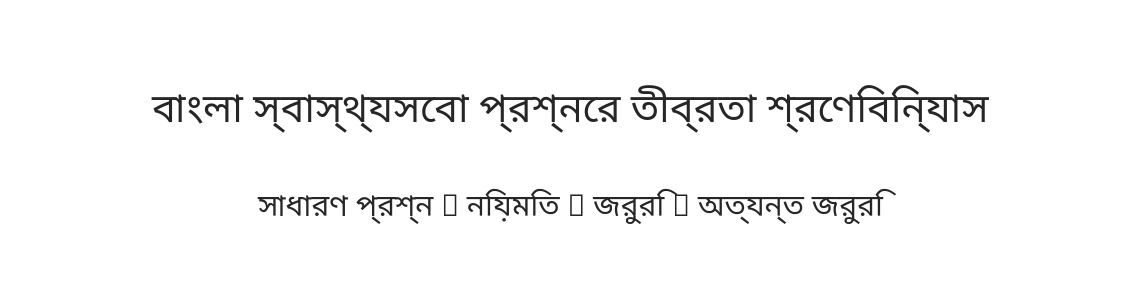

Font-test image saved to:
/content/drive/MyDrive/SCORE_BN_Checkpoints/font_test/bangla_font_test.png


In [61]:
# ============================================================
# VERIFY BANGLA RENDERING BEFORE REGENERATING EVERYTHING
# ============================================================

BACKUP_DIR = Path(
    '/content/drive/MyDrive/SCORE_BN_Checkpoints'
)

FONT_TEST_DIR = (
    BACKUP_DIR /
    'font_test'
)

FONT_TEST_DIR.mkdir(
    parents=True,
    exist_ok=True
)

bangla_test_text = (
    "বাংলা স্বাস্থ্যসেবা প্রশ্নের "
    "তীব্রতা শ্রেণিবিন্যাস"
)

figure, axis = plt.subplots(
    figsize=(12, 3)
)

axis.text(
    0.5,
    0.65,
    bangla_test_text,
    fontproperties=BANGLA_FONT,
    fontsize=24,
    ha='center',
    va='center'
)

axis.text(
    0.5,
    0.30,
    "সাধারণ প্রশ্ন • নিয়মিত • জরুরি • অত্যন্ত জরুরি",
    fontproperties=BANGLA_FONT,
    fontsize=18,
    ha='center',
    va='center'
)

axis.axis('off')

font_test_path = (
    FONT_TEST_DIR /
    'bangla_font_test.png'
)

figure.savefig(
    font_test_path,
    dpi=300,
    bbox_inches='tight',
    facecolor='white'
)

plt.show()

print("Font-test image saved to:")
print(font_test_path)

In [62]:
!pip -q install -U plotly kaleido

import json
import numpy as np
import pandas as pd
import plotly.graph_objects as go

from pathlib import Path

BACKUP_DIR = Path(
    '/content/drive/MyDrive/SCORE_BN_Checkpoints'
)

XAI_DIR = (
    BACKUP_DIR /
    'explainability'
)

REPORT_FIGURE_DIR = (
    BACKUP_DIR /
    'report_assets' /
    'figures'
)

XAI_DIR.mkdir(
    parents=True,
    exist_ok=True
)

REPORT_FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

BANGLA_PLOT_FONT = (
    'Noto Sans Bengali, Nirmala UI, '
    'Vrinda, sans-serif'
)

print("Output directory:", XAI_DIR)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 67.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 kB 4.6 MB/s eta 0:00:00
Output directory: /content/drive/MyDrive/SCORE_BN_Checkpoints/explainability


In [63]:
# ============================================================
# REBUILD LIME USING BROWSER-BASED BANGLA TEXT RENDERING
# ============================================================

LIME_CSV_PATH = (
    XAI_DIR /
    'lime_feature_weights.csv'
)

if not LIME_CSV_PATH.exists():
    raise FileNotFoundError(
        f"LIME values were not found: {LIME_CSV_PATH}"
    )

lime_df = pd.read_csv(
    LIME_CSV_PATH
)

print("LIME columns:", lime_df.columns.tolist())

# Detect columns safely
feature_column = next(
    column
    for column in lime_df.columns
    if column.lower() in [
        'word_or_phrase',
        'feature',
        'word',
        'token'
    ]
)

weight_column = next(
    column
    for column in lime_df.columns
    if column.lower() in [
        'importance_weight',
        'importance',
        'weight',
        'value'
    ]
)

lime_plot_df = (
    lime_df[
        [
            feature_column,
            weight_column
        ]
    ]
    .dropna()
    .sort_values(
        weight_column,
        ascending=True
    )
    .tail(15)
)

predicted_class = (
    lime_df[
        'predicted_class'
    ].iloc[0]
    if 'predicted_class' in lime_df.columns
    else 'Prediction'
)

bar_colors = [
    '#198754'
    if value >= 0
    else '#DC3545'
    for value in lime_plot_df[
        weight_column
    ]
]

lime_figure = go.Figure()

lime_figure.add_trace(
    go.Bar(
        x=lime_plot_df[
            weight_column
        ],
        y=lime_plot_df[
            feature_column
        ],
        orientation='h',
        marker_color=bar_colors,
        text=[
            f'{value:.4f}'
            for value in lime_plot_df[
                weight_column
            ]
        ],
        textposition='outside',
        hovertemplate=(
            '<b>%{y}</b><br>'
            'Contribution: %{x:.4f}'
            '<extra></extra>'
        )
    )
)

lime_figure.add_vline(
    x=0,
    line_width=1,
    line_color='black'
)

lime_figure.update_layout(
    title=(
        f'LIME Explanation: '
        f'{predicted_class}'
    ),
    xaxis_title='Contribution to Prediction',
    yaxis_title='Word or Phrase',
    template='plotly_white',
    width=1200,
    height=750,
    margin=dict(
        l=250,
        r=100,
        t=90,
        b=80
    ),
    font=dict(
        family=BANGLA_PLOT_FONT,
        size=17,
        color='black'
    ),
    title_font=dict(
        family=BANGLA_PLOT_FONT,
        size=24
    )
)

lime_figure.show()

# HTML always preserves browser-based Bengali shaping
LIME_HTML_PATH = (
    XAI_DIR /
    'lime_explanation_bangla_correct.html'
)

lime_figure.write_html(
    LIME_HTML_PATH,
    include_plotlyjs='cdn'
)

# Static PNG for the report
LIME_PNG_PATH = (
    XAI_DIR /
    'lime_explanation_bangla_correct.png'
)

try:
    lime_figure.write_image(
        LIME_PNG_PATH,
        width=1200,
        height=750,
        scale=2
    )

    shutil.copy2(
        LIME_PNG_PATH,
        REPORT_FIGURE_DIR /
        LIME_PNG_PATH.name
    )

    print("LIME PNG saved:", LIME_PNG_PATH)

except Exception as error:
    print("PNG export failed:", error)
    print("HTML was still saved correctly:", LIME_HTML_PATH)

LIME columns: ['word_or_phrase', 'importance_weight', 'true_class', 'predicted_class']


PNG export failed: 

Kaleido requires Google Chrome to be installed.

Either download and install Chrome yourself following Google's instructions for your operating system,
or install it from your terminal by running:

    $ plotly_get_chrome


HTML was still saved correctly: /content/drive/MyDrive/SCORE_BN_Checkpoints/explainability/lime_explanation_bangla_correct.html


In [64]:
# ============================================================
# REBUILD GLOBAL SHAP FIGURE WITH CORRECT BANGLA SHAPING
# ============================================================

required_shap_variables = [
    'shap_values_for_plot',
    'feature_names',
    'class_names'
]

missing_shap_variables = [
    variable
    for variable in required_shap_variables
    if variable not in globals()
]

if missing_shap_variables:
    raise NameError(
        f"Missing SHAP variables: {missing_shap_variables}. "
        "Rerun the corrected SHAP calculation cell first."
    )

# Remove FeatureUnion prefixes
clean_feature_names = np.array([
    str(feature)
    .replace('word__', '')
    .replace('char__', '')
    for feature in feature_names
])

# Convert SHAP output to samples × features × classes
if isinstance(
    shap_values_for_plot,
    list
):

    shap_by_class = [
        np.asarray(values)
        for values in shap_values_for_plot
    ]

elif (
    isinstance(
        shap_values_for_plot,
        np.ndarray
    )
    and
    shap_values_for_plot.ndim == 3
):

    shap_by_class = [
        shap_values_for_plot[
            :,
            :,
            class_index
        ]
        for class_index in range(
            shap_values_for_plot.shape[2]
        )
    ]

elif (
    hasattr(
        shap_values_for_plot,
        'values'
    )
):

    shap_array = np.asarray(
        shap_values_for_plot.values
    )

    if shap_array.ndim == 3:

        shap_by_class = [
            shap_array[
                :,
                :,
                class_index
            ]
            for class_index in range(
                shap_array.shape[2]
            )
        ]

    else:
        raise ValueError(
            f"Unexpected SHAP shape: {shap_array.shape}"
        )

else:
    raise ValueError(
        "Unsupported SHAP output format."
    )

# Mean absolute SHAP contribution by feature and class
mean_absolute_shap = np.column_stack([
    np.abs(
        class_values
    ).mean(axis=0)
    for class_values in shap_by_class
])

global_importance = (
    mean_absolute_shap.sum(axis=1)
)

top_feature_indices = np.argsort(
    global_importance
)[-20:]

top_features = clean_feature_names[
    top_feature_indices
]

class_colors = [
    '#1685E5',
    '#B94BD3',
    '#FF0051',
    '#00A02B'
]

shap_figure = go.Figure()

for class_index, class_name in enumerate(
    class_names
):

    shap_figure.add_trace(
        go.Bar(
            name=class_name,
            x=mean_absolute_shap[
                top_feature_indices,
                class_index
            ],
            y=top_features,
            orientation='h',
            marker_color=class_colors[
                class_index
                %
                len(class_colors)
            ],
            hovertemplate=(
                '<b>%{y}</b><br>'
                +
                f'Class: {class_name}<br>'
                +
                'Mean |SHAP|: %{x:.5f}'
                +
                '<extra></extra>'
            )
        )
    )

shap_figure.update_layout(
    title=(
        'Global SHAP Feature Importance — '
        'Logistic Regression'
    ),
    xaxis_title='Mean Absolute SHAP Value',
    yaxis_title='Feature',
    barmode='stack',
    template='plotly_white',
    width=1400,
    height=950,
    margin=dict(
        l=300,
        r=100,
        t=100,
        b=80
    ),
    legend_title='Severity Class',
    font=dict(
        family=BANGLA_PLOT_FONT,
        size=16,
        color='black'
    ),
    title_font=dict(
        family=BANGLA_PLOT_FONT,
        size=24
    )
)

shap_figure.show()

SHAP_HTML_PATH = (
    XAI_DIR /
    'shap_global_bangla_correct.html'
)

shap_figure.write_html(
    SHAP_HTML_PATH,
    include_plotlyjs='cdn'
)

SHAP_PNG_PATH = (
    XAI_DIR /
    'shap_global_bangla_correct.png'
)

try:
    shap_figure.write_image(
        SHAP_PNG_PATH,
        width=1400,
        height=950,
        scale=2
    )

    shutil.copy2(
        SHAP_PNG_PATH,
        REPORT_FIGURE_DIR /
        SHAP_PNG_PATH.name
    )

    print("SHAP PNG saved:", SHAP_PNG_PATH)

except Exception as error:
    print("PNG export failed:", error)
    print("HTML was still saved correctly:", SHAP_HTML_PATH)

PNG export failed: 

Kaleido requires Google Chrome to be installed.

Either download and install Chrome yourself following Google's instructions for your operating system,
or install it from your terminal by running:

    $ plotly_get_chrome


HTML was still saved correctly: /content/drive/MyDrive/SCORE_BN_Checkpoints/explainability/shap_global_bangla_correct.html


In [66]:
# ============================================================
# BANGLA-SAFE REPORT ASSET SETUP
# ============================================================

!pip -q install -U plotly kaleido

import re
import json
import shutil
import unicodedata
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.express as px

# ------------------------------------------------------------
# Directories
# ------------------------------------------------------------

BACKUP_DIR = Path(
    '/content/drive/MyDrive/SCORE_BN_Checkpoints'
)

FIXED_REPORT_DIR = (
    BACKUP_DIR /
    'report_assets_bangla_fixed'
)

FIXED_FIGURE_DIR = (
    FIXED_REPORT_DIR /
    'figures'
)

FIXED_TABLE_PNG_DIR = (
    FIXED_REPORT_DIR /
    'tables_png'
)

FIXED_TABLE_CSV_DIR = (
    FIXED_REPORT_DIR /
    'tables_csv'
)

FIXED_HTML_DIR = (
    FIXED_REPORT_DIR /
    'html'
)

for directory in [
    FIXED_REPORT_DIR,
    FIXED_FIGURE_DIR,
    FIXED_TABLE_PNG_DIR,
    FIXED_TABLE_CSV_DIR,
    FIXED_HTML_DIR
]:
    directory.mkdir(
        parents=True,
        exist_ok=True
    )

# Browser fallback font list
BANGLA_FONT_FAMILY = (
    'Noto Sans Bengali, Nirmala UI, '
    'Vrinda, Arial Unicode MS, sans-serif'
)

LABEL2ID = {
    'General Query': 0,
    'Routine': 1,
    'Urgent': 2,
    'Emergency': 3
}

ID2LABEL = {
    value: key
    for key, value in LABEL2ID.items()
}

CLASS_ORDER = [
    'General Query',
    'Routine',
    'Urgent',
    'Emergency'
]

# ------------------------------------------------------------
# Load saved dataset splits
# ------------------------------------------------------------

train_df = pd.read_csv(
    BACKUP_DIR /
    'train.csv'
)

val_df = pd.read_csv(
    BACKUP_DIR /
    'validation.csv'
)

test_df = pd.read_csv(
    BACKUP_DIR /
    'test.csv'
)

train_df['split'] = 'Train'
val_df['split'] = 'Validation'
test_df['split'] = 'Test'

df_report = pd.concat(
    [
        train_df,
        val_df,
        test_df
    ],
    ignore_index=True
)

df_report['text'] = (
    df_report['text']
    .fillna('')
    .astype(str)
)

df_report['label'] = (
    df_report['label']
    .astype(int)
)

if 'label_name' not in df_report.columns:

    df_report['label_name'] = (
        df_report['label']
        .map(ID2LABEL)
    )

def normalize_text(text):

    text = unicodedata.normalize(
        'NFKC',
        str(text)
    )

    text = re.sub(
        r'https?://\S+|www\.\S+',
        ' URL ',
        text
    )

    text = re.sub(
        r'@[A-Za-z0-9_]+',
        ' USER ',
        text
    )

    text = re.sub(
        r'\s+',
        ' ',
        text
    )

    return text.strip().lower()


def tokenize_bangla(text):

    return re.findall(
        r'[\u0980-\u09FFA-Za-z]+',
        str(text).lower()
    )


df_report['normalized_text'] = (
    df_report['text']
    .map(normalize_text)
)

df_report['tokens'] = (
    df_report['text']
    .map(tokenize_bangla)
)

df_report['word_length'] = (
    df_report['text']
    .str.split()
    .str.len()
)

df_report['char_length'] = (
    df_report['text']
    .str.len()
)

BANGLA_STOPWORDS = {
    'আমি', 'আমার', 'আমাকে', 'আমাদের',
    'আপনি', 'আপনার', 'সে', 'তার',
    'এই', 'ওই', 'এটা', 'সেটা',
    'কি', 'কী', 'কেন', 'কিভাবে',
    'কোন', 'কখন', 'কোথায়',
    'এবং', 'ও', 'আর', 'কিন্তু',
    'যে', 'যদি', 'তবে', 'তাহলে',
    'হয়', 'হয়', 'হচ্ছে', 'হবে',
    'হয়েছে', 'হয়েছে', 'ছিল',
    'আছে', 'নেই', 'না', 'নয়',
    'জন্য', 'থেকে', 'সাথে',
    'দিকে', 'মধ্যে', 'উপর',
    'একটি', 'একটা', 'কিছু',
    'খুব', 'অনেক', 'বা',
    'তো', 'এর', 'কে', 'তে',
    'র', 'টি'
}

all_tokens = [
    token
    for tokens in df_report['tokens']
    for token in tokens
    if len(token) > 1
]

content_tokens = [
    token
    for token in all_tokens
    if token not in BANGLA_STOPWORDS
]

token_counts = Counter(all_tokens)
content_counts = Counter(content_tokens)

print("Clean samples:", len(df_report))
print("Directories created:", FIXED_REPORT_DIR)

Clean samples: 5215
Directories created: /content/drive/MyDrive/SCORE_BN_Checkpoints/report_assets_bangla_fixed


In [67]:
# ============================================================
# BANGLA-SAFE PLOTLY SAVE FUNCTIONS
# ============================================================

saved_assets = []
failed_assets = []

def apply_bangla_layout(
    figure,
    title,
    width=1200,
    height=750
):

    figure.update_layout(
        title=title,
        template='plotly_white',
        width=width,
        height=height,
        font=dict(
            family=BANGLA_FONT_FAMILY,
            size=16,
            color='black'
        ),
        title_font=dict(
            family=BANGLA_FONT_FAMILY,
            size=24,
            color='black'
        ),
        margin=dict(
            l=180,
            r=80,
            t=100,
            b=90
        )
    )

    return figure


def save_plotly_figure(
    figure,
    filename,
    width=1200,
    height=750
):

    html_path = (
        FIXED_HTML_DIR /
        filename.replace(
            '.png',
            '.html'
        )
    )

    png_path = (
        FIXED_FIGURE_DIR /
        filename
    )

    # Browser-readable HTML
    figure.write_html(
        html_path,
        include_plotlyjs=True,
        full_html=True
    )

    try:

        figure.write_image(
            png_path,
            width=width,
            height=height,
            scale=2
        )

        saved_assets.append(
            str(png_path)
        )

        print(
            "PNG saved:",
            png_path.name
        )

    except Exception as error:

        failed_assets.append({
            'file': filename,
            'error': str(error)
        })

        print(
            "PNG export failed:",
            filename
        )

        print(
            "HTML was saved:",
            html_path
        )

    saved_assets.append(
        str(html_path)
    )

    return png_path


def create_plotly_table(
    dataframe,
    title,
    filename,
    max_rows=30
):

    table_df = (
        dataframe
        .head(max_rows)
        .copy()
    )

    for column in table_df.columns:

        if pd.api.types.is_float_dtype(
            table_df[column]
        ):

            table_df[column] = (
                table_df[column]
                .round(4)
            )

    row_colors = [
        '#FFFFFF'
        if index % 2 == 0
        else '#EEF3F8'
        for index in range(
            len(table_df)
        )
    ]

    figure = go.Figure(
        data=[
            go.Table(
                columnwidth=[
                    1.3
                    for _ in table_df.columns
                ],
                header=dict(
                    values=[
                        f'<b>{column}</b>'
                        for column in table_df.columns
                    ],
                    fill_color='#3E6E9E',
                    font=dict(
                        family=BANGLA_FONT_FAMILY,
                        size=15,
                        color='white'
                    ),
                    align='center',
                    height=38
                ),
                cells=dict(
                    values=[
                        table_df[
                            column
                        ].astype(str)
                        for column in table_df.columns
                    ],
                    fill_color=[
                        row_colors
                        for _ in table_df.columns
                    ],
                    font=dict(
                        family=BANGLA_FONT_FAMILY,
                        size=14,
                        color='black'
                    ),
                    align='center',
                    height=34
                )
            )
        ]
    )

    height = max(
        400,
        95 + 36 * len(table_df)
    )

    figure.update_layout(
        title=title,
        width=max(
            1000,
            190 * len(table_df.columns)
        ),
        height=height,
        margin=dict(
            l=20,
            r=20,
            t=80,
            b=20
        ),
        font=dict(
            family=BANGLA_FONT_FAMILY
        )
    )

    csv_path = (
        FIXED_TABLE_CSV_DIR /
        filename.replace(
            '.png',
            '.csv'
        )
    )

    table_df.to_csv(
        csv_path,
        index=False,
        encoding='utf-8-sig'
    )

    html_path = (
        FIXED_HTML_DIR /
        filename.replace(
            '.png',
            '.html'
        )
    )

    png_path = (
        FIXED_TABLE_PNG_DIR /
        filename
    )

    figure.write_html(
        html_path,
        include_plotlyjs=True,
        full_html=True
    )

    try:

        figure.write_image(
            png_path,
            width=figure.layout.width,
            height=height,
            scale=2
        )

        saved_assets.append(
            str(png_path)
        )

        print(
            "Table PNG saved:",
            png_path.name
        )

    except Exception as error:

        failed_assets.append({
            'file': filename,
            'error': str(error)
        })

        print(
            "Table PNG export failed:",
            filename
        )

    saved_assets.extend([
        str(csv_path),
        str(html_path)
    ])

    return figure

In [68]:
# ============================================================
# REBUILD ALL SAVED TABLES WITH CORRECT BANGLA RENDERING
# ============================================================

old_table_directories = [
    BACKUP_DIR /
    'report_assets' /
    'tables',

    BACKUP_DIR /
    'final_results',

    BACKUP_DIR /
    'explainability'
]

table_csv_files = []

for directory in old_table_directories:

    if directory.exists():

        table_csv_files.extend(
            directory.glob(
                '*.csv'
            )
        )

# Remove duplicate paths
table_csv_files = list(
    dict.fromkeys(
        table_csv_files
    )
)

print(
    "CSV tables found:",
    len(table_csv_files)
)

for csv_path in table_csv_files:

    try:

        table_df = pd.read_csv(
            csv_path
        )

        if table_df.empty:
            continue

        output_name = (
            'fixed_'
            +
            csv_path.stem
            +
            '.png'
        )

        create_plotly_table(
            table_df,
            title=csv_path.stem.replace(
                '_',
                ' '
            ).title(),
            filename=output_name,
            max_rows=30
        )

    except Exception as error:

        failed_assets.append({
            'file': str(csv_path),
            'error': str(error)
        })

        print(
            "Could not rebuild:",
            csv_path.name,
            error
        )

print(
    "\nFinished rebuilding saved tables."
)

CSV tables found: 10
Table PNG export failed: fixed_table_01_dataset_summary.png
Table PNG export failed: fixed_table_02_class_distribution.png
Table PNG export failed: fixed_table_03_split_distribution.png
Table PNG export failed: fixed_table_04_preprocessing_summary.png
Table PNG export failed: fixed_table_05_feature_engineering.png
Table PNG export failed: fixed_table_06_model_families.png
Table PNG export failed: fixed_model_comparison.png
Table PNG export failed: fixed_clean_dataset_with_splits.png
Table PNG export failed: fixed_lime_feature_weights.png
Table PNG export failed: fixed_logistic_regression_top_features.png

Finished rebuilding saved tables.


In [69]:
# ============================================================
# GENERATE ESSENTIAL PROJECT TABLES
# ============================================================

dataset_summary = pd.DataFrame({
    'Property': [
        'Dataset',
        'Domain',
        'Problem Type',
        'Language',
        'Original Samples',
        'Clean Samples',
        'Training Samples',
        'Validation Samples',
        'Test Samples',
        'Input',
        'Target',
        'Excluded Leakage Column'
    ],
    'Value': [
        'Bangla Healthcare Severity Dataset',
        'Healthcare NLP',
        'Ordinal Multiclass Classification',
        'Bangla',
        5263,
        len(df_report),
        len(train_df),
        len(val_df),
        len(test_df),
        'Text',
        'Categories',
        'Action Needed'
    ]
})

create_plotly_table(
    dataset_summary,
    'Dataset Summary',
    'table_01_dataset_summary_fixed.png'
)

class_distribution = (
    df_report['label_name']
    .value_counts()
    .reindex(CLASS_ORDER)
    .rename_axis(
        'Severity Class'
    )
    .reset_index(
        name='Samples'
    )
)

class_distribution[
    'Percentage'
] = (
    class_distribution[
        'Samples'
    ]
    /
    len(df_report)
    *
    100
).round(2)

create_plotly_table(
    class_distribution,
    'Class Distribution',
    'table_02_class_distribution_fixed.png'
)

split_distribution = (
    pd.crosstab(
        df_report['split'],
        df_report['label_name']
    )
    .reindex(
        columns=CLASS_ORDER
    )
    .reset_index()
)

split_distribution['Total'] = (
    split_distribution[
        CLASS_ORDER
    ].sum(axis=1)
)

create_plotly_table(
    split_distribution,
    'Dataset Split Distribution',
    'table_03_split_distribution_fixed.png'
)

preprocessing_table = pd.DataFrame({
    'Operation': [
        'Missing Values',
        'Duplicate Removal',
        'Unicode Normalization',
        'URL Normalization',
        'Mention Normalization',
        'Tokenization',
        'Stopword Analysis',
        'TF-IDF Encoding',
        'Transformer Tokenization',
        'Data Splitting',
        'Leakage Prevention'
    ],
    'Implementation': [
        'Missing text and target rows removed',
        'Exact and normalized duplicates removed',
        'NFKC normalization',
        'URLs replaced with URL token',
        'Mentions replaced with USER token',
        'Regex and model-specific tokenization',
        'Bangla stopword frequency analysed',
        'Word and character TF-IDF',
        'BanglaBERT subword tokenizer',
        '70% train, 15% validation, 15% test',
        'Action Needed excluded from input'
    ]
})

create_plotly_table(
    preprocessing_table,
    'Preprocessing Pipeline',
    'table_04_preprocessing_pipeline_fixed.png'
)

model_family_table = pd.DataFrame({
    'Model': [
        'Multinomial Naive Bayes',
        'Logistic Regression',
        'Linear SVM',
        'Random Forest',
        'XGBoost',
        'Text-CNN',
        'BiLSTM',
        'BiGRU',
        'BanglaBERT',
        'SCORE-BN'
    ],
    'Family': [
        'Probabilistic',
        'Linear',
        'Margin-based',
        'Tree Ensemble',
        'Boosted Ensemble',
        'Convolutional Neural Network',
        'Recurrent Neural Network',
        'Recurrent Neural Network',
        'Transformer',
        'Proposed Transformer Framework'
    ]
})

create_plotly_table(
    model_family_table,
    'Models and Algorithm Families',
    'table_05_model_families_fixed.png'
)

Table PNG export failed: table_01_dataset_summary_fixed.png
Table PNG export failed: table_02_class_distribution_fixed.png
Table PNG export failed: table_03_split_distribution_fixed.png
Table PNG export failed: table_04_preprocessing_pipeline_fixed.png
Table PNG export failed: table_05_model_families_fixed.png


In [70]:
# ============================================================
# BANGLA WORD, STOPWORD AND N-GRAM FIGURES
# ============================================================

top_words = pd.DataFrame(
    content_counts.most_common(20),
    columns=[
        'Word',
        'Frequency'
    ]
).sort_values(
    'Frequency'
)

word_figure = go.Figure(
    go.Bar(
        x=top_words['Frequency'],
        y=top_words['Word'],
        orientation='h',
        marker_color='#2A9D8F',
        text=top_words['Frequency'],
        textposition='outside'
    )
)

apply_bangla_layout(
    word_figure,
    'Most Frequent Content Words',
    width=1200,
    height=850
)

word_figure.update_xaxes(
    title='Frequency'
)

word_figure.update_yaxes(
    title='Word'
)

word_figure.show()

save_plotly_figure(
    word_figure,
    'figure_01_top_content_words_fixed.png',
    width=1200,
    height=850
)

# ------------------------------------------------------------
# Stopword figure
# ------------------------------------------------------------

stopword_counts = Counter(
    token
    for token in all_tokens
    if token in BANGLA_STOPWORDS
)

top_stopwords = pd.DataFrame(
    stopword_counts.most_common(20),
    columns=[
        'Stopword',
        'Frequency'
    ]
).sort_values(
    'Frequency'
)

if not top_stopwords.empty:

    stopword_figure = go.Figure(
        go.Bar(
            x=top_stopwords[
                'Frequency'
            ],
            y=top_stopwords[
                'Stopword'
            ],
            orientation='h',
            marker_color='#457B9D',
            text=top_stopwords[
                'Frequency'
            ],
            textposition='outside'
        )
    )

    apply_bangla_layout(
        stopword_figure,
        'Most Frequent Bangla Stopwords',
        width=1200,
        height=850
    )

    stopword_figure.update_xaxes(
        title='Frequency'
    )

    stopword_figure.update_yaxes(
        title='Stopword'
    )

    stopword_figure.show()

    save_plotly_figure(
        stopword_figure,
        'figure_02_stopword_frequency_fixed.png',
        width=1200,
        height=850
    )

PNG export failed: figure_01_top_content_words_fixed.png
HTML was saved: /content/drive/MyDrive/SCORE_BN_Checkpoints/report_assets_bangla_fixed/html/figure_01_top_content_words_fixed.html


PNG export failed: figure_02_stopword_frequency_fixed.png
HTML was saved: /content/drive/MyDrive/SCORE_BN_Checkpoints/report_assets_bangla_fixed/html/figure_02_stopword_frequency_fixed.html


In [71]:
# ============================================================
# N-GRAM ANALYSIS WITH BANGLA-SAFE RENDERING
# ============================================================

from sklearn.feature_extraction.text import CountVectorizer

def calculate_top_ngrams(
    texts,
    n,
    top_k=20
):

    vectorizer = CountVectorizer(
        token_pattern=r'(?u)\b\w+\b',
        ngram_range=(n, n),
        min_df=2
    )

    matrix = vectorizer.fit_transform(
        texts
    )

    frequencies = np.asarray(
        matrix.sum(axis=0)
    ).ravel()

    names = np.asarray(
        vectorizer.get_feature_names_out()
    )

    indices = frequencies.argsort()[
        ::-1
    ][
        :top_k
    ]

    return pd.DataFrame({
        'N-gram': names[indices],
        'Frequency': frequencies[indices]
    })


for n, name in [
    (1, 'Unigram'),
    (2, 'Bigram'),
    (3, 'Trigram')
]:

    ngram_df = calculate_top_ngrams(
        df_report[
            'normalized_text'
        ],
        n,
        top_k=20
    )

    ngram_df.to_csv(
        FIXED_TABLE_CSV_DIR /
        f'{name.lower()}_frequency.csv',
        index=False,
        encoding='utf-8-sig'
    )

    plot_df = ngram_df.sort_values(
        'Frequency'
    )

    figure = go.Figure(
        go.Bar(
            x=plot_df[
                'Frequency'
            ],
            y=plot_df[
                'N-gram'
            ],
            orientation='h',
            marker_color='#6A4C93',
            text=plot_df[
                'Frequency'
            ],
            textposition='outside'
        )
    )

    apply_bangla_layout(
        figure,
        f'Top {name} Frequencies',
        width=1300,
        height=900
    )

    figure.update_xaxes(
        title='Frequency'
    )

    figure.update_yaxes(
        title=name
    )

    figure.show()

    save_plotly_figure(
        figure,
        f'figure_{name.lower()}_frequency_fixed.png',
        width=1300,
        height=900
    )

PNG export failed: figure_unigram_frequency_fixed.png
HTML was saved: /content/drive/MyDrive/SCORE_BN_Checkpoints/report_assets_bangla_fixed/html/figure_unigram_frequency_fixed.html


PNG export failed: figure_bigram_frequency_fixed.png
HTML was saved: /content/drive/MyDrive/SCORE_BN_Checkpoints/report_assets_bangla_fixed/html/figure_bigram_frequency_fixed.html


PNG export failed: figure_trigram_frequency_fixed.png
HTML was saved: /content/drive/MyDrive/SCORE_BN_Checkpoints/report_assets_bangla_fixed/html/figure_trigram_frequency_fixed.html


In [72]:
# ============================================================
# BANGLA-SAFE CO-OCCURRENCE HEATMAP
# ============================================================

top_cooccurrence_words = [
    word
    for word, count
    in content_counts.most_common(
        15
    )
]

co_vectorizer = CountVectorizer(
    vocabulary=top_cooccurrence_words,
    token_pattern=r'(?u)\b\w+\b',
    binary=True
)

co_source = co_vectorizer.fit_transform(
    df_report[
        'normalized_text'
    ]
)

co_matrix = (
    co_source.T
    @
    co_source
).toarray()

np.fill_diagonal(
    co_matrix,
    0
)

cooccurrence_df = pd.DataFrame(
    co_matrix,
    index=top_cooccurrence_words,
    columns=top_cooccurrence_words
)

cooccurrence_df.to_csv(
    FIXED_TABLE_CSV_DIR /
    'cooccurrence_matrix.csv',
    encoding='utf-8-sig'
)

heatmap_figure = go.Figure(
    data=go.Heatmap(
        z=co_matrix,
        x=top_cooccurrence_words,
        y=top_cooccurrence_words,
        colorscale='Blues',
        text=co_matrix,
        texttemplate='%{text}',
        hovertemplate=(
            '%{y} | %{x}<br>'
            'Co-occurrence: %{z}'
            '<extra></extra>'
        )
    )
)

apply_bangla_layout(
    heatmap_figure,
    'Frequent-Word Co-occurrence Matrix',
    width=1200,
    height=1050
)

heatmap_figure.update_xaxes(
    tickangle=-45
)

heatmap_figure.show()

save_plotly_figure(
    heatmap_figure,
    'figure_cooccurrence_heatmap_fixed.png',
    width=1200,
    height=1050
)

PNG export failed: figure_cooccurrence_heatmap_fixed.png
HTML was saved: /content/drive/MyDrive/SCORE_BN_Checkpoints/report_assets_bangla_fixed/html/figure_cooccurrence_heatmap_fixed.html


PosixPath('/content/drive/MyDrive/SCORE_BN_Checkpoints/report_assets_bangla_fixed/figures/figure_cooccurrence_heatmap_fixed.png')

In [73]:
# ============================================================
# BANGLA-SAFE FREQUENCY CLOUD
# ============================================================

cloud_words = pd.DataFrame(
    content_counts.most_common(80),
    columns=[
        'Word',
        'Frequency'
    ]
)

minimum_frequency = (
    cloud_words[
        'Frequency'
    ].min()
)

maximum_frequency = (
    cloud_words[
        'Frequency'
    ].max()
)

def cloud_font_size(frequency):

    if maximum_frequency == minimum_frequency:
        return 28

    return int(
        18
        +
        48
        *
        (
            frequency
            -
            minimum_frequency
        )
        /
        (
            maximum_frequency
            -
            minimum_frequency
        )
    )


colors = [
    '#264653',
    '#2A9D8F',
    '#E9C46A',
    '#F4A261',
    '#E76F51',
    '#6A4C93',
    '#1982C4'
]

word_spans = []

for index, row in cloud_words.iterrows():

    size = cloud_font_size(
        row['Frequency']
    )

    color = colors[
        index % len(colors)
    ]

    word_spans.append(
        f'''
        <span
            title="Frequency: {row["Frequency"]}"
            style="
                font-size:{size}px;
                color:{color};
                margin:10px 14px;
                display:inline-block;
                line-height:1.2;
                font-family:{BANGLA_FONT_FAMILY};
            "
        >
            {row["Word"]}
        </span>
        '''
    )

cloud_html = f'''
<!DOCTYPE html>
<html lang="bn">
<head>
<meta charset="UTF-8">
<style>
body {{
    margin: 0;
    background: white;
    font-family: {BANGLA_FONT_FAMILY};
}}
h1 {{
    text-align: center;
    font-size: 34px;
    margin: 28px 0;
}}
.cloud {{
    width: 1200px;
    min-height: 720px;
    padding: 35px;
    box-sizing: border-box;
    text-align: center;
    display: flex;
    justify-content: center;
    align-items: center;
    align-content: center;
    flex-wrap: wrap;
}}
</style>
</head>
<body>
<h1>Bangla Healthcare Query Frequency Cloud</h1>
<div class="cloud">
{''.join(word_spans)}
</div>
</body>
</html>
'''

CLOUD_HTML_PATH = (
    FIXED_HTML_DIR /
    'figure_frequency_cloud_fixed.html'
)

CLOUD_HTML_PATH.write_text(
    cloud_html,
    encoding='utf-8'
)

print(
    "Bangla-safe frequency cloud HTML saved:"
)

print(CLOUD_HTML_PATH)

Bangla-safe frequency cloud HTML saved:
/content/drive/MyDrive/SCORE_BN_Checkpoints/report_assets_bangla_fixed/html/figure_frequency_cloud_fixed.html


In [74]:
# ============================================================
# BANGLA-SAFE LIME FIGURE
# ============================================================

LIME_CSV_PATH = (
    BACKUP_DIR /
    'explainability' /
    'lime_feature_weights.csv'
)

if LIME_CSV_PATH.exists():

    lime_df = pd.read_csv(
        LIME_CSV_PATH
    )

    feature_column = next(
        column
        for column in lime_df.columns
        if column.lower() in [
            'word_or_phrase',
            'feature',
            'word',
            'token'
        ]
    )

    weight_column = next(
        column
        for column in lime_df.columns
        if column.lower() in [
            'importance_weight',
            'importance',
            'weight',
            'value'
        ]
    )

    predicted_class = (
        lime_df[
            'predicted_class'
        ].iloc[0]
        if 'predicted_class'
        in lime_df.columns
        else 'Prediction'
    )

    lime_plot_df = (
        lime_df[
            [
                feature_column,
                weight_column
            ]
        ]
        .dropna()
        .sort_values(
            weight_column
        )
        .tail(15)
    )

    lime_colors = [
        '#198754'
        if value >= 0
        else '#DC3545'
        for value in lime_plot_df[
            weight_column
        ]
    ]

    lime_figure = go.Figure(
        go.Bar(
            x=lime_plot_df[
                weight_column
            ],
            y=lime_plot_df[
                feature_column
            ],
            orientation='h',
            marker_color=lime_colors,
            text=[
                f'{value:.4f}'
                for value
                in lime_plot_df[
                    weight_column
                ]
            ],
            textposition='outside'
        )
    )

    lime_figure.add_vline(
        x=0,
        line_color='black',
        line_width=1
    )

    apply_bangla_layout(
        lime_figure,
        f'LIME Explanation: {predicted_class}',
        width=1200,
        height=800
    )

    lime_figure.update_xaxes(
        title='Contribution to Prediction'
    )

    lime_figure.update_yaxes(
        title='Word or Phrase'
    )

    lime_figure.show()

    save_plotly_figure(
        lime_figure,
        'figure_lime_bangla_fixed.png',
        width=1200,
        height=800
    )

else:

    print(
        "LIME CSV not found:",
        LIME_CSV_PATH
    )

PNG export failed: figure_lime_bangla_fixed.png
HTML was saved: /content/drive/MyDrive/SCORE_BN_Checkpoints/report_assets_bangla_fixed/html/figure_lime_bangla_fixed.html


In [75]:
# ============================================================
# BANGLA-SAFE SHAP FIGURE
# ============================================================

if all(
    variable in globals()
    for variable in [
        'shap_values_for_plot',
        'feature_names',
        'class_names'
    ]
):

    clean_feature_names = np.array([
        str(feature)
        .replace('word__', '')
        .replace('char__', '')
        for feature in feature_names
    ])

    if isinstance(
        shap_values_for_plot,
        list
    ):

        shap_by_class = [
            np.asarray(values)
            for values
            in shap_values_for_plot
        ]

    elif isinstance(
        shap_values_for_plot,
        np.ndarray
    ) and shap_values_for_plot.ndim == 3:

        shap_by_class = [
            shap_values_for_plot[
                :,
                :,
                class_index
            ]
            for class_index in range(
                shap_values_for_plot.shape[2]
            )
        ]

    else:

        shap_array = np.asarray(
            shap_values_for_plot.values
        )

        shap_by_class = [
            shap_array[
                :,
                :,
                class_index
            ]
            for class_index in range(
                shap_array.shape[2]
            )
        ]

    mean_absolute_shap = (
        np.column_stack([
            np.abs(values).mean(
                axis=0
            )
            for values in shap_by_class
        ])
    )

    total_importance = (
        mean_absolute_shap.sum(
            axis=1
        )
    )

    top_indices = np.argsort(
        total_importance
    )[-20:]

    top_features = (
        clean_feature_names[
            top_indices
        ]
    )

    shap_colors = [
        '#1685E5',
        '#B94BD3',
        '#FF0051',
        '#00A02B'
    ]

    shap_figure = go.Figure()

    for class_index, class_name in enumerate(
        class_names
    ):

        shap_figure.add_trace(
            go.Bar(
                name=class_name,
                x=mean_absolute_shap[
                    top_indices,
                    class_index
                ],
                y=top_features,
                orientation='h',
                marker_color=shap_colors[
                    class_index
                ]
            )
        )

    apply_bangla_layout(
        shap_figure,
        'Global SHAP Feature Importance — Logistic Regression',
        width=1400,
        height=950
    )

    shap_figure.update_layout(
        barmode='stack',
        legend_title='Severity Class'
    )

    shap_figure.update_xaxes(
        title='Mean Absolute SHAP Value'
    )

    shap_figure.update_yaxes(
        title='Feature'
    )

    shap_figure.show()

    save_plotly_figure(
        shap_figure,
        'figure_shap_bangla_fixed.png',
        width=1400,
        height=950
    )

else:

    print(
        "SHAP values are not currently in memory."
    )

    print(
        "Rerun the corrected SHAP calculation cell, "
        "then rerun this cell."
    )

PNG export failed: figure_shap_bangla_fixed.png
HTML was saved: /content/drive/MyDrive/SCORE_BN_Checkpoints/report_assets_bangla_fixed/html/figure_shap_bangla_fixed.html


In [76]:
# ============================================================
# COLLECT SAFE FIGURES, VERIFY AND CREATE FINAL ZIP
# ============================================================

old_figure_dir = (
    BACKUP_DIR /
    'report_assets' /
    'figures'
)

# These figures use English/numeric labels and do not need
# Bengali shaping. Copy them if they already exist.
english_safe_patterns = [
    'figure_01_class_distribution.png',
    'figure_02_word_length_distribution.png',
    'figure_03_character_length_boxplot.png',
    'figure_04_script_composition.png',
    'figure_05_dataset_split_sizes.png',
    'figure_10_model_macro_f1_comparison.png',
    'figure_11_multi_metric_model_comparison.png',
    'figure_12_transformer_tuning_comparison.png',
    'figure_13_score_bn_confusion_matrices.png',
    'figure_14_score_bn_roc_curves.png',
    'figure_15_cross_script_robustness.png',
    'figure_16_score_bn_training_history.png',
    'figure_17_deep_model_training_curves.png',
    'figure_18_score_bn_error_summary.png'
]

for filename in english_safe_patterns:

    source = (
        old_figure_dir /
        filename
    )

    destination = (
        FIXED_FIGURE_DIR /
        filename
    )

    if source.exists():

        shutil.copy2(
            source,
            destination
        )

        print(
            "Copied English-safe figure:",
            filename
        )

# ------------------------------------------------------------
# Inventory
# ------------------------------------------------------------

inventory_rows = []

for asset_type, directory in [
    ('Figure PNG', FIXED_FIGURE_DIR),
    ('Table PNG', FIXED_TABLE_PNG_DIR),
    ('Table CSV', FIXED_TABLE_CSV_DIR),
    ('Interactive HTML', FIXED_HTML_DIR)
]:

    for file_path in directory.glob('*'):

        if file_path.is_file():

            inventory_rows.append({
                'Type': asset_type,
                'Filename': file_path.name,
                'Size KB': round(
                    file_path.stat().st_size
                    /
                    1024,
                    2
                ),
                'Path': str(file_path)
            })

inventory_df = pd.DataFrame(
    inventory_rows
).sort_values(
    [
        'Type',
        'Filename'
    ]
)

inventory_df.to_csv(
    FIXED_REPORT_DIR /
    'fixed_asset_inventory.csv',
    index=False,
    encoding='utf-8-sig'
)

display(inventory_df)

# ------------------------------------------------------------
# Save failures
# ------------------------------------------------------------

failure_df = pd.DataFrame(
    failed_assets
)

failure_df.to_csv(
    FIXED_REPORT_DIR /
    'asset_generation_failures.csv',
    index=False,
    encoding='utf-8-sig'
)

print(
    "\nGenerated PNG figures:",
    len(
        list(
            FIXED_FIGURE_DIR.glob(
                '*.png'
            )
        )
    )
)

print(
    "Generated PNG tables:",
    len(
        list(
            FIXED_TABLE_PNG_DIR.glob(
                '*.png'
            )
        )
    )
)

print(
    "Generated HTML files:",
    len(
        list(
            FIXED_HTML_DIR.glob(
                '*.html'
            )
        )
    )
)

print(
    "Failures:",
    len(failed_assets)
)

# ------------------------------------------------------------
# Create final ZIP
# ------------------------------------------------------------

EXPORT_DIR = Path(
    '/content/drive/MyDrive/SCORE_BN_Exports'
)

EXPORT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

temporary_zip = shutil.make_archive(
    '/content/SCORE_BN_BANGLA_FIXED_REPORT_ASSETS',
    'zip',
    root_dir=FIXED_REPORT_DIR
)

final_zip = (
    EXPORT_DIR /
    'SCORE_BN_BANGLA_FIXED_REPORT_ASSETS.zip'
)

shutil.copy2(
    temporary_zip,
    final_zip
)

print(
    "\nFinal fixed ZIP:"
)

print(final_zip)

print(
    "ZIP size:",
    round(
        final_zip.stat().st_size
        /
        1024**2,
        2
    ),
    "MB"
)

Copied English-safe figure: figure_01_class_distribution.png
Copied English-safe figure: figure_02_word_length_distribution.png
Copied English-safe figure: figure_03_character_length_boxplot.png
Copied English-safe figure: figure_04_script_composition.png
Copied English-safe figure: figure_05_dataset_split_sizes.png


,Type,Filename,Size KB,Path
0,Figure PNG,figure_01_class_distribution.png,108.47,/content/drive/MyDrive/SCORE_BN_Checkpoints/re...
1,Figure PNG,figure_02_word_length_distribution.png,70.01,/content/drive/MyDrive/SCORE_BN_Checkpoints/re...
2,Figure PNG,figure_03_character_length_boxplot.png,178.74,/content/drive/MyDrive/SCORE_BN_Checkpoints/re...
3,Figure PNG,figure_04_script_composition.png,93.51,/content/drive/MyDrive/SCORE_BN_Checkpoints/re...
4,Figure PNG,figure_05_dataset_split_sizes.png,53.96,/content/drive/MyDrive/SCORE_BN_Checkpoints/re...
39,Interactive HTML,figure_01_top_content_words_fixed.html,4745.89,/content/drive/MyDrive/SCORE_BN_Checkpoints/re...
40,Interactive HTML,figure_02_stopword_frequency_fixed.html,4745.86,/content/drive/MyDrive/SCORE_BN_Checkpoints/re...
42,Interactive HTML,figure_bigram_frequency_fixed.html,4745.80,/content/drive/MyDrive/SCORE_BN_Checkpoints/re...
44,Interactive HTML,figure_cooccurrence_heatmap_fixed.html,4746.66,/content/drive/MyDrive/SCORE_BN_Checkpoints/re...
45,Interactive HTML,figure_frequency_cloud_fixed.html,32.58,/content/drive/MyDrive/SCORE_BN_Checkpoints/re...



Generated PNG figures: 5
Generated PNG tables: 0
Generated HTML files: 24
Failures: 23

Final fixed ZIP:
/content/drive/MyDrive/SCORE_BN_Exports/SCORE_BN_BANGLA_FIXED_REPORT_ASSETS.zip
ZIP size: 32.59 MB


In [77]:
# ============================================================
# CORRECTED FINAL ASSETS — CELL 1
# Installation, imports and folders
# CPU is sufficient
# ============================================================

!pip -q install -U regex plotly kaleido playwright shap lime
!playwright install chromium

import os
import re
import gc
import json
import shutil
import random
import warnings
import subprocess
import unicodedata

from pathlib import Path
from collections import Counter
from itertools import combinations

import regex
import joblib
import shap
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.io as pio

from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    roc_auc_score
)

from google.colab import drive

warnings.filterwarnings("ignore")

# Mount Google Drive if it is not already mounted
if not Path("/content/drive/MyDrive").exists():
    drive.mount("/content/drive")

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

# ------------------------------------------------------------
# Existing project directory
# ------------------------------------------------------------

BACKUP_DIR = Path(
    "/content/drive/MyDrive/SCORE_BN_Checkpoints"
)

assert BACKUP_DIR.exists(), (
    f"Project folder not found: {BACKUP_DIR}"
)

# ------------------------------------------------------------
# New clean corrected-results directory
# ------------------------------------------------------------

FINAL_DIR = (
    BACKUP_DIR /
    "final_corrected_assets"
)

FIGURE_HTML_DIR = FINAL_DIR / "figures_html"
FIGURE_PNG_DIR = FINAL_DIR / "figures_png"
FIGURE_SVG_DIR = FINAL_DIR / "figures_svg"
TABLE_DIR = FINAL_DIR / "tables"
INVALID_ARCHIVE_DIR = FINAL_DIR / "invalid_old_assets_archive"
METADATA_DIR = FINAL_DIR / "metadata"

for directory in [
    FINAL_DIR,
    FIGURE_HTML_DIR,
    FIGURE_PNG_DIR,
    FIGURE_SVG_DIR,
    TABLE_DIR,
    INVALID_ARCHIVE_DIR,
    METADATA_DIR
]:
    directory.mkdir(
        parents=True,
        exist_ok=True
    )

# ------------------------------------------------------------
# Load saved dataset splits
# ------------------------------------------------------------

train_df = pd.read_csv(
    BACKUP_DIR / "train.csv"
)

val_df = pd.read_csv(
    BACKUP_DIR / "validation.csv"
)

test_df = pd.read_csv(
    BACKUP_DIR / "test.csv"
)

for frame in [
    train_df,
    val_df,
    test_df
]:
    frame["text"] = (
        frame["text"]
        .fillna("")
        .astype(str)
    )

    frame["label"] = (
        frame["label"]
        .astype(int)
    )

# Combine only for descriptive EDA
df_corrected = pd.concat(
    [
        train_df.assign(split="Training"),
        val_df.assign(split="Validation"),
        test_df.assign(split="Test")
    ],
    ignore_index=True
)

LABEL2ID = {
    "General Query": 0,
    "Routine": 1,
    "Urgent": 2,
    "Emergency": 3
}

ID2LABEL = {
    value: key
    for key, value in LABEL2ID.items()
}

CLASS_NAMES = [
    ID2LABEL[index]
    for index in range(4)
]

print("Everything loaded successfully.")
print("Training rows:", len(train_df))
print("Validation rows:", len(val_df))
print("Test rows:", len(test_df))
print("Total clean rows:", len(df_corrected))
print("Corrected output folder:", FINAL_DIR)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.5/40.5 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 801.8/801.8 kB 26.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.7/47.7 MB 17.0 MB/s eta 0:00:00
184.3 MiB [] 0% 0.0s184.3 MiB [] 0% 40.7s184.3 MiB [] 0% 23.1s184.3 MiB [] 0% 18.3s184.3 MiB [] 0% 15.6s184.3 MiB [] 0% 9.4s184.3 MiB [] 1% 6.2s184.3 MiB [] 2% 4.9s184.3 MiB [] 2% 4.3s184.3 MiB [] 3% 3.9s184.3 MiB [] 4% 3.7s184.3 MiB [] 4% 3.6s184.3 MiB [] 5% 3.4s184.3 MiB [] 6% 3.2s184.3 MiB [] 6% 3.7s184.3 MiB [] 6% 3.9s184.3 MiB [] 6% 4.3s184.3 MiB [] 7% 4.5s184.3 MiB [] 7% 4.4s184.3 MiB [] 8% 4.1s184.3 MiB [] 9% 3.9s184.3 MiB [] 10% 3.6s184.3 MiB [] 11% 3.3s184.3 MiB [] 12% 3.2s184.3 MiB [] 13% 3.0s184.3 MiB [] 14% 2.9s184.3 MiB [] 15% 2.7s184.3 MiB [] 16% 2.6s184.3 MiB [] 17% 2.6s184.3 MiB [] 18% 2.5s184.3 MiB [] 18% 2.6s184.3 MiB [] 19% 2.6s184.3 MiB [] 21% 2.5s184.3 MiB [] 22% 2.4s184.3 MiB [] 23% 2.4s184.3 MiB [] 24% 2.3s184.3 MiB [] 24% 2.4s

In [78]:
# ============================================================
# CORRECTED FINAL ASSETS — CELL 2
# Bangla-safe normalization and tokenization
# ============================================================

# A basic stopword collection for descriptive word analysis.
# These words are not removed from transformer inputs.
BANGLA_STOPWORDS = {
    "আমি", "আমার", "আমাকে", "আমরা", "আমাদের",
    "তুমি", "তোমার", "আপনি", "আপনার",
    "সে", "তার", "তারা", "তাদের",
    "এই", "ঐ", "ওই", "এটা", "ওটা", "সেটা",
    "এটি", "ওটি", "সেটি",
    "একটি", "একটা", "কোনো", "কোন",
    "কি", "কী", "কেন", "কিভাবে",
    "এবং", "আর", "বা", "কিন্তু",
    "যে", "যদি", "তাহলে", "তবে",
    "এর", "ও", "তে", "কে", "থেকে",
    "জন্য", "সাথে", "মধ্যে", "উপর",
    "নিচে", "দিকে", "পরে", "আগে",
    "হয়", "হয়", "হচ্ছে", "হয়ে", "হয়ে",
    "হবে", "ছিল", "আছে", "ছিলো",
    "না", "নেই", "খুব", "একটু",
    "করে", "করতে", "করলে", "করার",
    "লাগে", "লাগছে", "গেছে",
    "ধরে", "মতো", "হঠাৎ"
}

# Bengali letters and their dependent signs remain together.
BANGLA_WORD_PATTERN = regex.compile(
    r"[\p{Script=Bengali}\p{M}]+"
)

LATIN_WORD_PATTERN = regex.compile(
    r"[A-Za-z]+(?:'[A-Za-z]+)?"
)


def normalize_bangla_text(text):
    """
    Unicode-normalize text without deleting meaningful Bangla
    characters or vowel signs.
    """

    text = unicodedata.normalize(
        "NFKC",
        str(text)
    )

    text = re.sub(
        r"https?://\S+|www\.\S+",
        " URL ",
        text
    )

    text = re.sub(
        r"@[A-Za-z0-9_]+",
        " USER ",
        text
    )

    text = re.sub(
        r"\s+",
        " ",
        text
    ).strip()

    return text


def bangla_safe_tokenize(
    text,
    remove_stopwords=False,
    minimum_length=1
):
    """
    Extract complete Bengali-script words while retaining
    Bengali combining marks.
    """

    text = normalize_bangla_text(
        text
    )

    bangla_tokens = (
        BANGLA_WORD_PATTERN.findall(
            text
        )
    )

    latin_tokens = (
        LATIN_WORD_PATTERN.findall(
            text
        )
    )

    tokens = (
        bangla_tokens
        +
        latin_tokens
    )

    cleaned_tokens = []

    for token in tokens:

        token = token.strip()

        # Require at least one real alphabetic character
        has_letter = any(
            unicodedata.category(character).startswith("L")
            for character in token
        )

        if not has_letter:
            continue

        if len(token) < minimum_length:
            continue

        if (
            remove_stopwords
            and token in BANGLA_STOPWORDS
        ):
            continue

        cleaned_tokens.append(
            token
        )

    return cleaned_tokens


# ------------------------------------------------------------
# Tokenize the complete clean dataset
# ------------------------------------------------------------

df_corrected["normalized_text"] = (
    df_corrected["text"]
    .map(normalize_bangla_text)
)

df_corrected["safe_tokens"] = (
    df_corrected["normalized_text"]
    .map(
        lambda text: bangla_safe_tokenize(
            text,
            remove_stopwords=False
        )
    )
)

df_corrected["content_tokens"] = (
    df_corrected["normalized_text"]
    .map(
        lambda text: bangla_safe_tokenize(
            text,
            remove_stopwords=True
        )
    )
)

# ------------------------------------------------------------
# Validate the tokenizer
# ------------------------------------------------------------

sample_texts = df_corrected["text"].sample(
    n=min(10, len(df_corrected)),
    random_state=SEED
)

tokenizer_check = pd.DataFrame({
    "Original Text": sample_texts.values,
    "Bangla-safe Tokens": [
        " | ".join(
            bangla_safe_tokenize(text)
        )
        for text in sample_texts
    ]
})

display(tokenizer_check)

tokenizer_check.to_csv(
    TABLE_DIR /
    "table_tokenizer_quality_check.csv",
    index=False,
    encoding="utf-8-sig"
)

# Detect suspicious one-character fragments
all_safe_tokens = [
    token
    for token_list in df_corrected["safe_tokens"]
    for token in token_list
]

single_character_tokens = [
    token
    for token in all_safe_tokens
    if len(token) == 1
]

print("Total tokens:", len(all_safe_tokens))
print("Vocabulary size:", len(set(all_safe_tokens)))
print(
    "Single-character token percentage:",
    round(
        100 * len(single_character_tokens)
        / max(len(all_safe_tokens), 1),
        3
    ),
    "%"
)

print("\nExample corrected tokens:")
print(all_safe_tokens[:50])

,Original Text,Bangla-safe Tokens
0,শরীরের বিভিন্ন জায়গায় মাঝে মাঝে ছোট ছোট সাদা ছ...,শরীরের | বিভিন্ন | জায়গায় | মাঝে | মাঝে | ছো...
1,"স্যার, হালকা জ্বর আসে",স্যার | হালকা | জ্বর | আসে
2,রাত থেকে শরীর ভেঙে যাচ্ছে এবং,রাত | থেকে | শরীর | ভেঙে | যাচ্ছে | এবং
3,"একটু সাহায্য দরকার, রাত থেকে বারবার বমি হচ্ছে,...",একটু | সাহায্য | দরকার | রাত | থেকে | বারবার |...
4,"আজকে এটা নিয়ে চিন্তা করা উচিত কি, এটা কি বিপজ...",আজকে | এটা | নিয়ে | চিন্তা | করা | উচিত | কি ...
5,আক্কেল দাঁতের ব্যথায় গাল ও গলা ফুলে শক্ত হয়ে গ...,আক্কেল | দাঁতের | ব্যথায় | গাল | ও | গলা | ফু...
6,গুরুতর কোষ্ঠকাঠিন্য এবং পেটে তীব্র ব্যথার সমস্...,গুরুতর | কোষ্ঠকাঠিন্য | এবং | পেটে | তীব্র | ব...
7,পায়ের পুরনো ডায়াবেটিক ক্ষত ফুলে লাল হয়ে গেছে এ...,পায়ের | পুরনো | ডায়াবেটিক | ক্ষত | ফুলে | লা...
8,মাথার পেছনের ব্যথার সাথে শরীরের ভারসাম্য হারিয়...,মাথার | পেছনের | ব্যথার | সাথে | শরীরের | ভারস...
9,সকাল থেকে হালকা কাশি আছে,সকাল | থেকে | হালকা | কাশি | আছে


Total tokens: 66503
Vocabulary size: 4070
Single-character token percentage: 0.37 %

Example corrected tokens:
['মেরুদণ্ডের', 'নিচের', 'দিকে', 'তীব্র', 'ব্যথার', 'কারণে', 'সোজা', 'হয়ে', 'বসা', 'বা', 'শোয়া', 'যাচ্ছে', 'না', 'রোগী', 'হঠাৎ', 'করে', 'হার্ট', 'অ্যাটাক', 'করে', 'মেঝেতে', 'লুটিয়ে', 'পড়েছে', 'এবং', 'কোনো', 'সাড়া', 'দিচ্ছে', 'না', 'চুলের', 'গোড়ায়', 'পুঁজসহ', 'ইনফেকশন', 'দেখা', 'দিছে', 'আর', 'দুর্গন্ধ', 'বের', 'হচ্ছে', 'পায়ের', 'নখ', 'কাটার', 'পর', 'সেই', 'জায়গাটা', 'কালো', 'হয়ে', 'গেছে', 'আর', 'হাত', 'দিলে', 'একদম']


In [79]:
# ============================================================
# CORRECTED FINAL ASSETS — CELL 3
# Correct word, n-gram and co-occurrence calculations
# ============================================================

def count_ngrams(
    tokenized_documents,
    n,
    top_k=25
):
    """
    Calculate n-grams directly from already-tokenized Bengali
    words. This avoids sklearn's incorrect default Bangla
    token boundary behaviour.
    """

    counter = Counter()

    for tokens in tokenized_documents:

        if len(tokens) < n:
            continue

        document_ngrams = zip(
            *[
                tokens[position:]
                for position in range(n)
            ]
        )

        counter.update(
            " ".join(ngram)
            for ngram in document_ngrams
        )

    result = pd.DataFrame(
        counter.most_common(top_k),
        columns=[
            "N-gram",
            "Frequency"
        ]
    )

    return result


# ------------------------------------------------------------
# Word frequencies
# ------------------------------------------------------------

content_word_counter = Counter(
    token
    for token_list in df_corrected["content_tokens"]
    for token in token_list
)

stopword_counter = Counter(
    token
    for token_list in df_corrected["safe_tokens"]
    for token in token_list
    if token in BANGLA_STOPWORDS
)

top_content_words = pd.DataFrame(
    content_word_counter.most_common(25),
    columns=[
        "Word",
        "Frequency"
    ]
)

top_stopwords = pd.DataFrame(
    stopword_counter.most_common(25),
    columns=[
        "Stopword",
        "Frequency"
    ]
)

# ------------------------------------------------------------
# Bangla-safe n-grams
# Use non-stopword tokens for more meaningful descriptive EDA
# ------------------------------------------------------------

unigram_df = count_ngrams(
    df_corrected["content_tokens"],
    n=1,
    top_k=25
)

bigram_df = count_ngrams(
    df_corrected["content_tokens"],
    n=2,
    top_k=25
)

trigram_df = count_ngrams(
    df_corrected["content_tokens"],
    n=3,
    top_k=25
)

# ------------------------------------------------------------
# Document-level co-occurrence
# ------------------------------------------------------------

TOP_COOCCURRENCE_WORDS = [
    word
    for word, frequency
    in content_word_counter.most_common(15)
]

cooccurrence_counter = Counter()

for token_list in df_corrected["content_tokens"]:

    # Count a word once per document for document-level
    # co-occurrence
    document_words = set(
        token
        for token in token_list
        if token in TOP_COOCCURRENCE_WORDS
    )

    for first_word, second_word in combinations(
        sorted(document_words),
        2
    ):
        cooccurrence_counter[
            (
                first_word,
                second_word
            )
        ] += 1

cooccurrence_matrix = pd.DataFrame(
    0,
    index=TOP_COOCCURRENCE_WORDS,
    columns=TOP_COOCCURRENCE_WORDS,
    dtype=int
)

for (
    first_word,
    second_word
), frequency in cooccurrence_counter.items():

    cooccurrence_matrix.loc[
        first_word,
        second_word
    ] = frequency

    cooccurrence_matrix.loc[
        second_word,
        first_word
    ] = frequency

np.fill_diagonal(
    cooccurrence_matrix.values,
    0
)

# Ensure that the matrix is not incorrectly all zero
assert cooccurrence_matrix.values.sum() > 0, (
    "Co-occurrence matrix is unexpectedly all zero."
)

# ------------------------------------------------------------
# Save numerical tables
# ------------------------------------------------------------

tables_to_save = {
    "table_top_content_words.csv":
        top_content_words,

    "table_top_stopwords.csv":
        top_stopwords,

    "table_safe_unigrams.csv":
        unigram_df,

    "table_safe_bigrams.csv":
        bigram_df,

    "table_safe_trigrams.csv":
        trigram_df,

    "table_safe_cooccurrence_matrix.csv":
        cooccurrence_matrix.reset_index(
            names="Word"
        )
}

for filename, table in tables_to_save.items():

    table.to_csv(
        TABLE_DIR / filename,
        index=False,
        encoding="utf-8-sig"
    )

    print(
        "Saved:",
        TABLE_DIR / filename
    )

print(
    "\nCo-occurrence matrix sum:",
    int(cooccurrence_matrix.values.sum())
)

display(top_content_words)
display(bigram_df)
display(trigram_df)
display(cooccurrence_matrix)

Saved: /content/drive/MyDrive/SCORE_BN_Checkpoints/final_corrected_assets/tables/table_top_content_words.csv
Saved: /content/drive/MyDrive/SCORE_BN_Checkpoints/final_corrected_assets/tables/table_top_stopwords.csv
Saved: /content/drive/MyDrive/SCORE_BN_Checkpoints/final_corrected_assets/tables/table_safe_unigrams.csv
Saved: /content/drive/MyDrive/SCORE_BN_Checkpoints/final_corrected_assets/tables/table_safe_bigrams.csv
Saved: /content/drive/MyDrive/SCORE_BN_Checkpoints/final_corrected_assets/tables/table_safe_trigrams.csv
Saved: /content/drive/MyDrive/SCORE_BN_Checkpoints/final_corrected_assets/tables/table_safe_cooccurrence_matrix.csv

Co-occurrence matrix sum: 5142


,Word,Frequency
0,ব্যথা,607
1,তীব্র,438
2,হয়া,426
3,যাচ্ছে,416
4,মাঝে,412
5,দরকার,346
6,শরীর,344
7,প্রচণ্ড,325
8,পর,314
9,দিন,296


,N-gram,Frequency
0,সাহায্য দরকার,254
1,চিন্তায় আছি,216
2,মাঝে মাঝে,204
3,হাত পা,120
4,করা উচিত,119
5,শ্বাস নিতে,117
6,দুই দিন,106
7,নিয়ে চিন্তা,103
8,কেমন জানি,103
9,তথ্য চাই,93


,N-gram,Frequency
0,গতকাল লক্ষ্য করছি,82
1,করবো বুঝতে পারছি,72
2,আজকে বুঝতে পারলাম,70
3,বিষয় নিয়ে চিন্তায়,69
4,নিয়ে চিন্তায় আছি,69
5,অনেক চিন্তায় আছি,66
6,শ্বাস নিতে কষ্ট,56
7,ব্যথা শুরু হয়েছে,49
8,সাধারণ তথ্য চাই,38
9,হাত পা অবশ,36


,ব্যথা,তীব্র,হয়া,যাচ্ছে,মাঝে,দরকার,শরীর,প্রচণ্ড,পর,দিন,যা,হাত,হয়েছে,পায়ের,রক্ত
ব্যথা,0,117,29,36,49,24,7,81,21,36,90,30,76,31,35
তীব্র,117,0,89,41,7,6,17,16,26,26,32,47,56,31,23
হয়া,29,89,0,7,21,5,49,26,41,36,7,48,3,34,29
যাচ্ছে,36,41,7,0,1,6,44,50,24,13,36,41,11,32,43
মাঝে,49,7,21,1,0,7,1,2,14,12,43,3,2,17,6
দরকার,24,6,5,6,7,0,31,3,2,29,0,11,26,1,2
শরীর,7,17,49,44,1,31,0,22,21,28,1,14,11,13,10
প্রচণ্ড,81,16,26,50,2,3,22,0,28,15,20,24,22,28,24
পর,21,26,41,24,14,2,21,28,0,3,11,27,14,13,38
দিন,36,26,36,13,12,29,28,15,3,0,21,15,16,12,8


In [80]:
# ============================================================
# CORRECTED FINAL ASSETS — CELL 4
# Build browser-renderable Plotly figures
# ============================================================

BANGLA_FONT_FAMILY = (
    "Noto Sans Bengali, "
    "Nirmala UI, "
    "Vrinda, "
    "Arial Unicode MS, "
    "sans-serif"
)

CLASS_COLORS = {
    "General Query": "#1685E5",
    "Routine": "#B94BD3",
    "Urgent": "#FF0051",
    "Emergency": "#00A02B"
}


def apply_browser_layout(
    figure,
    title,
    width=1200,
    height=850
):
    """
    Apply a browser-compatible font stack. The browser performs
    Bengali shaping instead of Matplotlib.
    """

    figure.update_layout(
        title={
            "text": title,
            "x": 0.5,
            "xanchor": "center"
        },
        width=width,
        height=height,
        template="plotly_white",
        font={
            "family": BANGLA_FONT_FAMILY,
            "size": 17,
            "color": "#202124"
        },
        margin={
            "l": 230,
            "r": 80,
            "t": 100,
            "b": 100
        }
    )

    figure.update_xaxes(
        tickfont={
            "family": BANGLA_FONT_FAMILY,
            "size": 15
        },
        title_font={
            "family": BANGLA_FONT_FAMILY,
            "size": 17
        }
    )

    figure.update_yaxes(
        tickfont={
            "family": BANGLA_FONT_FAMILY,
            "size": 16
        },
        title_font={
            "family": BANGLA_FONT_FAMILY,
            "size": 17
        }
    )

    return figure


def save_plot_html(
    figure,
    filename
):
    """
    Save self-contained browser-renderable HTML.
    """

    output_path = (
        FIGURE_HTML_DIR /
        f"{filename}.html"
    )

    figure.write_html(
        output_path,
        include_plotlyjs=True,
        full_html=True,
        config={
            "displayModeBar": False,
            "responsive": False
        }
    )

    print(
        "HTML created:",
        output_path.name
    )

    return output_path


def create_frequency_figure(
    table,
    label_column,
    title,
    color,
    filename
):

    plot_table = table.sort_values(
        "Frequency",
        ascending=True
    )

    figure = go.Figure(
        go.Bar(
            x=plot_table["Frequency"],
            y=plot_table[label_column],
            orientation="h",
            marker_color=color,
            text=plot_table["Frequency"],
            textposition="outside",
            hovertemplate=(
                "<b>%{y}</b><br>"
                "Frequency: %{x}"
                "<extra></extra>"
            )
        )
    )

    apply_browser_layout(
        figure,
        title,
        width=1250,
        height=900
    )

    figure.update_xaxes(
        title="Frequency"
    )

    figure.update_yaxes(
        title=label_column
    )

    save_plot_html(
        figure,
        filename
    )


# ------------------------------------------------------------
# Word and stopword figures
# ------------------------------------------------------------

create_frequency_figure(
    top_content_words,
    "Word",
    "Most Frequent Bangla Content Words",
    "#2A9D8F",
    "figure_01_bangla_content_words"
)

create_frequency_figure(
    top_stopwords,
    "Stopword",
    "Most Frequent Bangla Stopwords",
    "#457B9D",
    "figure_02_bangla_stopwords"
)

# ------------------------------------------------------------
# N-gram figures
# ------------------------------------------------------------

create_frequency_figure(
    unigram_df,
    "N-gram",
    "Top Bangla-safe Unigrams",
    "#6A4C93",
    "figure_03_bangla_safe_unigrams"
)

create_frequency_figure(
    bigram_df,
    "N-gram",
    "Top Bangla-safe Bigrams",
    "#E76F51",
    "figure_04_bangla_safe_bigrams"
)

create_frequency_figure(
    trigram_df,
    "N-gram",
    "Top Bangla-safe Trigrams",
    "#F4A261",
    "figure_05_bangla_safe_trigrams"
)

# ------------------------------------------------------------
# Correct co-occurrence heatmap
# ------------------------------------------------------------

heatmap_figure = go.Figure(
    go.Heatmap(
        z=cooccurrence_matrix.values,
        x=cooccurrence_matrix.columns.tolist(),
        y=cooccurrence_matrix.index.tolist(),
        colorscale="Blues",
        text=cooccurrence_matrix.values,
        texttemplate="%{text}",
        hovertemplate=(
            "%{y} + %{x}<br>"
            "Co-occurring documents: %{z}"
            "<extra></extra>"
        ),
        colorbar={
            "title": "Documents"
        }
    )
)

apply_browser_layout(
    heatmap_figure,
    "Bangla Word Co-occurrence Matrix",
    width=1250,
    height=1100
)

heatmap_figure.update_xaxes(
    tickangle=-45
)

save_plot_html(
    heatmap_figure,
    "figure_06_bangla_cooccurrence"
)

print(
    "\nAll corrected EDA HTML figures created."
)

HTML created: figure_01_bangla_content_words.html
HTML created: figure_02_bangla_stopwords.html
HTML created: figure_03_bangla_safe_unigrams.html
HTML created: figure_04_bangla_safe_bigrams.html
HTML created: figure_05_bangla_safe_trigrams.html
HTML created: figure_06_bangla_cooccurrence.html

All corrected EDA HTML figures created.


In [81]:
# ============================================================
# CORRECTED FINAL ASSETS — CELL 5
# Browser-rendered LIME
# ============================================================

possible_lime_files = [
    BACKUP_DIR /
    "explainability" /
    "lime_feature_weights.csv",

    BACKUP_DIR /
    "final_export" /
    "tables" /
    "lime_values.csv"
]

LIME_CSV_PATH = next(
    (
        path
        for path in possible_lime_files
        if path.exists()
    ),
    None
)

assert LIME_CSV_PATH is not None, (
    "Saved LIME feature-weight CSV was not found."
)

lime_df = pd.read_csv(
    LIME_CSV_PATH
)

print("LIME source:", LIME_CSV_PATH)
print("LIME columns:", lime_df.columns.tolist())

feature_candidates = [
    "word_or_phrase",
    "feature",
    "word",
    "token"
]

weight_candidates = [
    "importance_weight",
    "weight",
    "importance",
    "contribution"
]

feature_column = next(
    (
        column
        for column in lime_df.columns
        if column.lower() in feature_candidates
    ),
    None
)

weight_column = next(
    (
        column
        for column in lime_df.columns
        if column.lower() in weight_candidates
    ),
    None
)

assert feature_column is not None, (
    "Could not identify the LIME feature column."
)

assert weight_column is not None, (
    "Could not identify the LIME weight column."
)

lime_plot_df = (
    lime_df[
        [
            feature_column,
            weight_column
        ]
    ]
    .dropna()
    .copy()
)

lime_plot_df[feature_column] = (
    lime_plot_df[feature_column]
    .astype(str)
)

lime_plot_df[weight_column] = pd.to_numeric(
    lime_plot_df[weight_column],
    errors="coerce"
)

lime_plot_df = (
    lime_plot_df
    .dropna()
    .sort_values(
        weight_column,
        ascending=True
    )
    .tail(15)
)

lime_colors = [
    "#198754"
    if value >= 0
    else "#DC3545"
    for value in lime_plot_df[weight_column]
]

lime_figure = go.Figure(
    go.Bar(
        x=lime_plot_df[weight_column],
        y=lime_plot_df[feature_column],
        orientation="h",
        marker_color=lime_colors,
        text=[
            f"{value:.4f}"
            for value in lime_plot_df[
                weight_column
            ]
        ],
        textposition="outside",
        hovertemplate=(
            "<b>%{y}</b><br>"
            "LIME contribution: %{x:.4f}"
            "<extra></extra>"
        )
    )
)

apply_browser_layout(
    lime_figure,
    "LIME Explanation for a Bangla Healthcare Query",
    width=1300,
    height=850
)

lime_figure.update_xaxes(
    title="Contribution to Predicted Class",
    zeroline=True,
    zerolinewidth=2,
    zerolinecolor="black"
)

lime_figure.update_yaxes(
    title="Word or Phrase"
)

save_plot_html(
    lime_figure,
    "figure_07_lime_browser_rendered"
)

lime_plot_df.to_csv(
    TABLE_DIR /
    "table_lime_explanation.csv",
    index=False,
    encoding="utf-8-sig"
)

display(lime_plot_df)

LIME source: /content/drive/MyDrive/SCORE_BN_Checkpoints/explainability/lime_feature_weights.csv
LIME columns: ['word_or_phrase', 'importance_weight', 'true_class', 'predicted_class']
HTML created: figure_07_lime_browser_rendered.html


,word_or_phrase,importance_weight
1,জ্বালাপোড়া,-0.230911
4,করে,-0.049819
8,টক,-0.023494
10,বুক,-0.005661
11,"ওঠে,",-0.005074
9,গলার,0.010937
7,ধরে,0.024514
6,কয়েকদিন,0.029298
5,কাছটা,0.043112
3,টনটন,0.070677


In [82]:
# ============================================================
# CORRECTED FINAL ASSETS — CELL 6
# Bangla-safe word-level Logistic Regression and SHAP
# CPU is sufficient
# ============================================================

def identity_tokenizer(text):
    return bangla_safe_tokenize(
        text,
        remove_stopwords=False
    )


# Fit on training only
safe_word_vectorizer = TfidfVectorizer(
    tokenizer=identity_tokenizer,
    token_pattern=None,
    preprocessor=None,
    lowercase=False,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.98,
    sublinear_tf=True,
    max_features=40000
)

X_train_safe = safe_word_vectorizer.fit_transform(
    train_df["text"]
)

X_test_safe = safe_word_vectorizer.transform(
    test_df["text"]
)

safe_lr_model = LogisticRegression(
    max_iter=2500,
    class_weight="balanced",
    random_state=SEED
)

safe_lr_model.fit(
    X_train_safe,
    train_df["label"].values
)

safe_lr_probabilities = safe_lr_model.predict_proba(
    X_test_safe
)

safe_lr_predictions = safe_lr_probabilities.argmax(
    axis=1
)

safe_lr_precision, safe_lr_recall, safe_lr_f1, _ = (
    precision_recall_fscore_support(
        test_df["label"].values,
        safe_lr_predictions,
        average="macro",
        zero_division=0
    )
)

safe_lr_metrics = {
    "model":
        "Bangla-safe Word Logistic Regression (XAI)",

    "accuracy":
        accuracy_score(
            test_df["label"].values,
            safe_lr_predictions
        ),

    "macro_precision":
        safe_lr_precision,

    "macro_recall":
        safe_lr_recall,

    "macro_f1":
        safe_lr_f1,

    "roc_auc_ovr":
        roc_auc_score(
            test_df["label"].values,
            safe_lr_probabilities,
            multi_class="ovr",
            average="macro"
        )
}

print("Bangla-safe LR metrics:")
display(
    pd.DataFrame(
        [safe_lr_metrics]
    )
)

# Save the explainability model
joblib.dump(
    {
        "vectorizer": safe_word_vectorizer,
        "model": safe_lr_model
    },
    FINAL_DIR /
    "bangla_safe_xai_logistic_regression.joblib"
)

# ------------------------------------------------------------
# SHAP calculation
# ------------------------------------------------------------

BACKGROUND_SIZE = min(
    200,
    X_train_safe.shape[0]
)

EXPLANATION_SIZE = min(
    100,
    X_test_safe.shape[0]
)

background_indices = np.random.RandomState(
    SEED
).choice(
    X_train_safe.shape[0],
    size=BACKGROUND_SIZE,
    replace=False
)

explanation_indices = np.arange(
    EXPLANATION_SIZE
)

X_background = X_train_safe[
    background_indices
]

X_explain = X_test_safe[
    explanation_indices
]

shap_explainer = shap.LinearExplainer(
    safe_lr_model,
    X_background
)

shap_values = shap_explainer.shap_values(
    X_explain
)

feature_names = np.asarray(
    safe_word_vectorizer.get_feature_names_out()
)

# Convert SHAP results into one matrix per class
if isinstance(shap_values, list):

    shap_by_class = [
        np.asarray(values)
        for values in shap_values
    ]

else:

    shap_array = np.asarray(
        shap_values
    )

    if shap_array.ndim == 3:

        shap_by_class = [
            shap_array[
                :,
                :,
                class_index
            ]
            for class_index in range(
                shap_array.shape[2]
            )
        ]

    elif shap_array.ndim == 2:

        # Fallback for binary-like return formats
        shap_by_class = [
            shap_array
        ]

    else:
        raise ValueError(
            f"Unexpected SHAP shape: {shap_array.shape}"
        )

mean_absolute_shap = np.column_stack([
    np.abs(class_values).mean(
        axis=0
    )
    for class_values in shap_by_class
])

total_feature_importance = (
    mean_absolute_shap.sum(
        axis=1
    )
)

TOP_SHAP_FEATURES = 20

top_shap_indices = np.argsort(
    total_feature_importance
)[
    -TOP_SHAP_FEATURES:
]

top_shap_features = feature_names[
    top_shap_indices
]

# ------------------------------------------------------------
# Save SHAP numerical table
# ------------------------------------------------------------

shap_table = pd.DataFrame({
    "Feature": top_shap_features,
    "Total Mean Absolute SHAP":
        total_feature_importance[
            top_shap_indices
        ]
})

for class_index in range(
    mean_absolute_shap.shape[1]
):

    class_name = (
        CLASS_NAMES[class_index]
        if class_index < len(CLASS_NAMES)
        else f"Class {class_index}"
    )

    shap_table[
        f"{class_name} Mean Absolute SHAP"
    ] = mean_absolute_shap[
        top_shap_indices,
        class_index
    ]

shap_table = shap_table.sort_values(
    "Total Mean Absolute SHAP",
    ascending=False
)

shap_table.to_csv(
    TABLE_DIR /
    "table_shap_bangla_safe_features.csv",
    index=False,
    encoding="utf-8-sig"
)

# ------------------------------------------------------------
# Browser-renderable SHAP figure
# ------------------------------------------------------------

shap_figure = go.Figure()

shap_colors = [
    "#1685E5",
    "#B94BD3",
    "#FF0051",
    "#00A02B"
]

for class_index in range(
    mean_absolute_shap.shape[1]
):

    class_name = (
        CLASS_NAMES[class_index]
        if class_index < len(CLASS_NAMES)
        else f"Class {class_index}"
    )

    shap_figure.add_trace(
        go.Bar(
            name=class_name,
            x=mean_absolute_shap[
                top_shap_indices,
                class_index
            ],
            y=top_shap_features,
            orientation="h",
            marker_color=shap_colors[
                class_index %
                len(shap_colors)
            ],
            hovertemplate=(
                "<b>%{y}</b><br>"
                f"Class: {class_name}<br>"
                "Mean |SHAP|: %{x:.6f}"
                "<extra></extra>"
            )
        )
    )

apply_browser_layout(
    shap_figure,
    "Global SHAP Importance — Bangla-safe Logistic Regression",
    width=1400,
    height=1000
)

shap_figure.update_layout(
    barmode="stack",
    legend_title="Severity Class"
)

shap_figure.update_xaxes(
    title="Mean Absolute SHAP Value"
)

shap_figure.update_yaxes(
    title="Bangla Word or Phrase"
)

save_plot_html(
    shap_figure,
    "figure_08_shap_browser_rendered"
)

display(shap_table.head(20))

# Free unnecessary memory
del X_background
del X_explain
gc.collect()

Bangla-safe LR metrics:


,model,accuracy,macro_precision,macro_recall,macro_f1,roc_auc_ovr
0,Bangla-safe Word Logistic Regression (XAI),0.916986,0.918775,0.920614,0.919429,0.985412


HTML created: figure_08_shap_browser_rendered.html


,Feature,Total Mean Absolute SHAP,General Query Mean Absolute SHAP,Routine Mean Absolute SHAP,Urgent Mean Absolute SHAP,Emergency Mean Absolute SHAP
19,কি,0.529069,0.264535,0.095679,0.091329,0.077527
18,হালকা,0.298817,0.047979,0.149409,0.053270,0.048160
17,হঠাৎ,0.252996,0.047826,0.063143,0.015530,0.126498
16,লাগে,0.204963,0.038810,0.102481,0.024398,0.039274
15,হচ্ছে,0.203728,0.068029,0.033835,0.056460,0.045404
14,আর,0.176095,0.087084,0.000964,0.072970,0.015078
13,না,0.165845,0.054850,0.028073,0.065947,0.016976
12,ব্যথা,0.159170,0.044374,0.050106,0.029479,0.035211
11,গেছে,0.136326,0.043666,0.024497,0.010531,0.057632
10,একটু,0.127892,0.014864,0.063946,0.027929,0.021153


13279

In [83]:
# ============================================================
# CORRECTED FINAL ASSETS — CELL 7
# Browser-render every Plotly HTML into PNG and SVG
# ============================================================

renderer_code = r'''
import sys
import base64
import urllib.parse

from pathlib import Path
from playwright.sync_api import sync_playwright


html_directory = Path(sys.argv[1])
png_directory = Path(sys.argv[2])
svg_directory = Path(sys.argv[3])

png_directory.mkdir(
    parents=True,
    exist_ok=True
)

svg_directory.mkdir(
    parents=True,
    exist_ok=True
)

html_files = sorted(
    html_directory.glob("*.html")
)

print(
    f"Found {len(html_files)} HTML figures."
)

failures = []

with sync_playwright() as playwright:

    browser = playwright.chromium.launch(
        headless=True,
        args=[
            "--no-sandbox",
            "--disable-dev-shm-usage",
            "--font-render-hinting=none"
        ]
    )

    page = browser.new_page(
        viewport={
            "width": 1800,
            "height": 1400
        },
        device_scale_factor=2
    )

    for html_path in html_files:

        try:

            page.goto(
                html_path.resolve().as_uri(),
                wait_until="networkidle",
                timeout=120000
            )

            page.wait_for_selector(
                ".plotly-graph-div",
                timeout=120000
            )

            page.wait_for_timeout(
                1500
            )

            graph = page.locator(
                ".plotly-graph-div"
            ).first

            png_path = (
                png_directory /
                f"{html_path.stem}.png"
            )

            graph.screenshot(
                path=str(png_path),
                type="png"
            )

            svg_data_url = page.evaluate(
                """
                async () => {
                    const graph = document.querySelector(
                        '.plotly-graph-div'
                    );

                    return await Plotly.toImage(
                        graph,
                        {
                            format: 'svg'
                        }
                    );
                }
                """
            )

            header, encoded_data = (
                svg_data_url.split(
                    ",",
                    1
                )
            )

            if ";base64" in header:

                svg_bytes = base64.b64decode(
                    encoded_data
                )

                svg_text = svg_bytes.decode(
                    "utf-8"
                )

            else:

                svg_text = urllib.parse.unquote(
                    encoded_data
                )

            svg_path = (
                svg_directory /
                f"{html_path.stem}.svg"
            )

            svg_path.write_text(
                svg_text,
                encoding="utf-8"
            )

            print(
                "Rendered:",
                html_path.stem
            )

        except Exception as error:

            failures.append(
                {
                    "file": html_path.name,
                    "error": str(error)
                }
            )

            print(
                "FAILED:",
                html_path.name,
                error
            )

    browser.close()

failure_path = (
    html_directory.parent /
    "metadata" /
    "browser_rendering_failures.json"
)

failure_path.write_text(
    __import__("json").dumps(
        failures,
        indent=2
    ),
    encoding="utf-8"
)

print(
    f"Rendering finished with "
    f"{len(failures)} failure(s)."
)
'''

renderer_path = Path(
    "/content/render_plotly_browser.py"
)

renderer_path.write_text(
    renderer_code,
    encoding="utf-8"
)

render_process = subprocess.run(
    [
        "python",
        str(renderer_path),
        str(FIGURE_HTML_DIR),
        str(FIGURE_PNG_DIR),
        str(FIGURE_SVG_DIR)
    ],
    capture_output=True,
    text=True,
    timeout=1200
)

print(render_process.stdout)

if render_process.stderr:
    print(
        "Renderer messages:\n",
        render_process.stderr[-4000:]
    )

if render_process.returncode != 0:
    raise RuntimeError(
        "Browser rendering failed. "
        "Check the messages printed above."
    )

png_files = sorted(
    FIGURE_PNG_DIR.glob("*.png")
)

svg_files = sorted(
    FIGURE_SVG_DIR.glob("*.svg")
)

print("\nPNG files created:", len(png_files))
print("SVG files created:", len(svg_files))

assert len(png_files) > 0, (
    "No PNG figures were created."
)

assert len(svg_files) > 0, (
    "No SVG figures were created."
)

print("\nBrowser-rendered files:")
for path in png_files:
    print(path.name)

Found 8 HTML figures.

Renderer messages:
 ckSync,BoundaryEventDispatchTracksNodeRemoval,DestroyProfileOnBrowserClose,DialMediaRouteProvider,GlobalMediaControls,HttpsUpgrades,LensOverlay,MediaRouter,PaintHolding,ThirdPartyStoragePartitioning,BlockOriginHeaderModificationOnRedirect,Translate,AutoDeElevate,OptimizationHints,msForceBrowserSignIn,msEdgeUpdateLaunchServicesPreferredVersion --enable-features=CDPScreenshotNewSurface --allow-pre-commit-input --disable-hang-monitor --disable-ipc-flooding-protection --disable-popup-blocking --disable-prompt-on-repost --disable-renderer-backgrounding --disable-updater-scheduler --force-color-profile=srgb --metrics-recording-only --no-first-run --password-store=basic --use-mock-keychain --no-service-autorun --export-tagged-pdf --disable-search-engine-choice-screen --unsafely-disable-devtools-self-xss-warnings --edge-skip-compat-layer-relaunch --disable-infobars --disable-search-engine-choice-screen --disable-sync --enable-unsafe-swiftshader --head

RuntimeError: Browser rendering failed. Check the messages printed above.

In [84]:
# ============================================================
# CORRECTED FINAL ASSETS — CELL 8
# Rebuild complete model comparison
# ============================================================

comparison_rows = []


def add_result(
    model,
    stage,
    accuracy=np.nan,
    macro_precision=np.nan,
    macro_recall=np.nan,
    macro_f1=np.nan,
    roc_auc_ovr=np.nan,
    notes=""
):

    comparison_rows.append({
        "model": model,
        "stage": stage,
        "accuracy": accuracy,
        "macro_precision": macro_precision,
        "macro_recall": macro_recall,
        "macro_f1": macro_f1,
        "roc_auc_ovr": roc_auc_ovr,
        "notes": notes
    })


def clean_classical(text):

    text = unicodedata.normalize(
        "NFKC",
        str(text)
    )

    text = re.sub(
        r"https?://\S+|www\.\S+",
        " URL ",
        text
    )

    text = re.sub(
        r"@[A-Za-z0-9_]+",
        " USER ",
        text
    )

    text = re.sub(
        r"\s+",
        " ",
        text
    ).strip().lower()

    return text


def evaluate_probabilities(
    model_name,
    stage,
    true_labels,
    probabilities,
    notes=""
):

    probabilities = np.asarray(
        probabilities
    )

    predictions = probabilities.argmax(
        axis=1
    )

    precision, recall, f1, _ = (
        precision_recall_fscore_support(
            true_labels,
            predictions,
            average="macro",
            zero_division=0
        )
    )

    try:

        auc = roc_auc_score(
            true_labels,
            probabilities,
            multi_class="ovr",
            average="macro"
        )

    except Exception:

        auc = np.nan

    add_result(
        model=model_name,
        stage=stage,
        accuracy=accuracy_score(
            true_labels,
            predictions
        ),
        macro_precision=precision,
        macro_recall=recall,
        macro_f1=f1,
        roc_auc_ovr=auc,
        notes=notes
    )


y_test = test_df["label"].values

# ------------------------------------------------------------
# 1. Classical baseline models
# ------------------------------------------------------------

FEATURE_PATH = (
    BACKUP_DIR /
    "tfidf_features.joblib"
)

CLASSICAL_PATH = (
    BACKUP_DIR /
    "classical_models.joblib"
)

if (
    FEATURE_PATH.exists()
    and CLASSICAL_PATH.exists()
):

    try:

        classical_features = joblib.load(
            FEATURE_PATH
        )

        classical_models = joblib.load(
            CLASSICAL_PATH
        )

        X_test_classical = (
            classical_features.transform(
                test_df["text"].map(
                    clean_classical
                )
            )
        )

        for model_name, model in classical_models.items():

            try:

                probabilities = (
                    model.predict_proba(
                        X_test_classical
                    )
                )

                evaluate_probabilities(
                    model_name=model_name,
                    stage="Classical baseline",
                    true_labels=y_test,
                    probabilities=probabilities
                )

                print(
                    "Evaluated:",
                    model_name
                )

            except Exception as error:

                print(
                    "Could not evaluate",
                    model_name,
                    error
                )

    except Exception as error:

        print(
            "Classical model loading failed:",
            error
        )

# ------------------------------------------------------------
# 2. Tuned Linear SVM
# ------------------------------------------------------------

TUNED_SVM_PATH = (
    BACKUP_DIR /
    "tuned_linear_svm.joblib"
)

if (
    TUNED_SVM_PATH.exists()
    and "X_test_classical" in globals()
):

    try:

        tuned_svm = joblib.load(
            TUNED_SVM_PATH
        )

        tuned_svm_probabilities = (
            tuned_svm.predict_proba(
                X_test_classical
            )
        )

        evaluate_probabilities(
            "Tuned Linear SVM",
            "Tuned",
            y_test,
            tuned_svm_probabilities
        )

    except Exception as error:

        print(
            "Tuned SVM evaluation failed:",
            error
        )

# ------------------------------------------------------------
# 3. Tuned XGBoost
# ------------------------------------------------------------

TUNED_XGB_PATH = (
    BACKUP_DIR /
    "tuned_xgboost.joblib"
)

if (
    TUNED_XGB_PATH.exists()
    and "X_test_classical" in globals()
):

    try:

        tuned_xgb = joblib.load(
            TUNED_XGB_PATH
        )

        tuned_xgb_probabilities = (
            tuned_xgb.predict_proba(
                X_test_classical
            )
        )

        evaluate_probabilities(
            "Tuned XGBoost",
            "Tuned",
            y_test,
            tuned_xgb_probabilities
        )

    except Exception as error:

        print(
            "Tuned XGBoost evaluation failed:",
            error
        )

# ------------------------------------------------------------
# 4. CNN, BiLSTM and BiGRU
# ------------------------------------------------------------

deep_model_names = [
    "CNN",
    "BiLSTM",
    "BiGRU"
]

for model_name in deep_model_names:

    probability_candidates = [
        BACKUP_DIR /
        f"{model_name}_probabilities.npy",

        BACKUP_DIR /
        "final_export" /
        "arrays" /
        f"{model_name}_probabilities.npy"
    ]

    probability_path = next(
        (
            path
            for path in probability_candidates
            if path.exists()
        ),
        None
    )

    if probability_path is not None:

        probabilities = np.load(
            probability_path
        )

        evaluate_probabilities(
            model_name,
            "Deep learning",
            y_test,
            probabilities
        )

# ------------------------------------------------------------
# 5. BanglaBERT
# ------------------------------------------------------------

BERT_METRICS_PATH = (
    BACKUP_DIR /
    "banglabert_baseline" /
    "test_metrics.json"
)

if BERT_METRICS_PATH.exists():

    with open(
        BERT_METRICS_PATH,
        "r",
        encoding="utf-8"
    ) as file:

        bert_metrics = json.load(
            file
        )

    def metric_value(
        dictionary,
        *possible_keys
    ):

        for key in possible_keys:

            if key in dictionary:
                return dictionary[key]

        return np.nan

    add_result(
        model="BanglaBERT",
        stage="Transformer baseline",

        accuracy=metric_value(
            bert_metrics,
            "eval_accuracy",
            "accuracy"
        ),

        macro_precision=metric_value(
            bert_metrics,
            "eval_macro_precision",
            "macro_precision"
        ),

        macro_recall=metric_value(
            bert_metrics,
            "eval_macro_recall",
            "macro_recall"
        ),

        macro_f1=metric_value(
            bert_metrics,
            "eval_macro_f1",
            "macro_f1"
        ),

        roc_auc_ovr=metric_value(
            bert_metrics,
            "eval_roc_auc_ovr",
            "roc_auc_ovr"
        ),

        notes=(
            "Memory-safe BanglaBERT baseline; "
            "previously omitted from final comparison."
        )
    )

    print(
        "BanglaBERT metrics added."
    )

else:

    print(
        "WARNING: BanglaBERT metrics JSON not found:",
        BERT_METRICS_PATH
    )

# ------------------------------------------------------------
# 6. SCORE-BN
# ------------------------------------------------------------

SCORE_METRICS_PATH = (
    BACKUP_DIR /
    "score_bn" /
    "test_metrics.json"
)

if SCORE_METRICS_PATH.exists():

    with open(
        SCORE_METRICS_PATH,
        "r",
        encoding="utf-8"
    ) as file:

        score_metrics = json.load(
            file
        )

    add_result(
        model="SCORE-BN",
        stage="Proposed model",

        accuracy=score_metrics.get(
            "accuracy",
            np.nan
        ),

        macro_precision=score_metrics.get(
            "macro_precision",
            np.nan
        ),

        macro_recall=score_metrics.get(
            "macro_recall",
            np.nan
        ),

        macro_f1=score_metrics.get(
            "macro_f1",
            np.nan
        ),

        roc_auc_ovr=score_metrics.get(
            "roc_auc_ovr",
            np.nan
        ),

        notes=(
            "Ordinal and cross-script-consistent "
            "proposed model."
        )
    )

# ------------------------------------------------------------
# 7. Bangla-safe XAI Logistic Regression
# ------------------------------------------------------------

add_result(
    model=safe_lr_metrics["model"],
    stage="Explainability model",
    accuracy=safe_lr_metrics["accuracy"],
    macro_precision=safe_lr_metrics[
        "macro_precision"
    ],
    macro_recall=safe_lr_metrics[
        "macro_recall"
    ],
    macro_f1=safe_lr_metrics[
        "macro_f1"
    ],
    roc_auc_ovr=safe_lr_metrics[
        "roc_auc_ovr"
    ],
    notes=(
        "Word-level Bangla-safe model trained only "
        "for interpretable SHAP analysis."
    )
)

# ------------------------------------------------------------
# Final table
# ------------------------------------------------------------

final_comparison = pd.DataFrame(
    comparison_rows
)

# Remove repeated model-stage rows if any
final_comparison = (
    final_comparison
    .drop_duplicates(
        subset=[
            "model",
            "stage"
        ],
        keep="last"
    )
    .sort_values(
        "macro_f1",
        ascending=False,
        na_position="last"
    )
    .reset_index(drop=True)
)

numeric_columns = [
    "accuracy",
    "macro_precision",
    "macro_recall",
    "macro_f1",
    "roc_auc_ovr"
]

final_comparison[
    numeric_columns
] = final_comparison[
    numeric_columns
].apply(
    pd.to_numeric,
    errors="coerce"
)

display(
    final_comparison.style.format({
        column: "{:.4f}"
        for column in numeric_columns
    })
)

FINAL_COMPARISON_PATH = (
    TABLE_DIR /
    "table_final_model_comparison_corrected.csv"
)

final_comparison.to_csv(
    FINAL_COMPARISON_PATH,
    index=False,
    encoding="utf-8-sig"
)

print(
    "\nCorrected comparison saved to:",
    FINAL_COMPARISON_PATH
)

if (
    final_comparison[
        "model"
    ].eq("BanglaBERT").any()
):

    print(
        "VERIFIED: BanglaBERT is included."
    )

else:

    print(
        "WARNING: BanglaBERT is still missing."
    )

Evaluated: MultinomialNB
Could not evaluate LogisticRegression 'LogisticRegression' object has no attribute 'multi_class'
Evaluated: LinearSVM
Evaluated: RandomForest
Evaluated: XGBoost
Tuned SVM evaluation failed: 'LinearSVC' object has no attribute 'predict_proba'


,model,stage,accuracy,macro_precision,macro_recall,macro_f1,roc_auc_ovr,notes
0,SCORE-BN,Proposed model,0.9183,0.9226,0.9213,0.9218,0.9872,Ordinal and cross-script-consistent proposed model.
1,Bangla-safe Word Logistic Regression (XAI),Explainability model,0.9170,0.9188,0.9206,0.9194,0.9854,Word-level Bangla-safe model trained only for interpretable SHAP analysis.
2,LinearSVM,Classical baseline,0.9157,0.9184,0.9190,0.9186,0.9841,
3,CNN,Deep learning,0.9157,0.9186,0.9188,0.9186,0.9870,
4,BiGRU,Deep learning,0.9029,0.9053,0.9070,0.9060,0.9834,
5,BiLSTM,Deep learning,0.9017,0.9039,0.9070,0.9045,0.9779,
6,XGBoost,Classical baseline,0.8991,0.9016,0.9033,0.9023,0.9799,
7,RandomForest,Classical baseline,0.8966,0.9000,0.9007,0.9003,0.9810,
8,Tuned XGBoost,Tuned,0.8902,0.8925,0.8949,0.8935,0.9786,
9,MultinomialNB,Classical baseline,0.8838,0.8860,0.8885,0.8870,0.9808,



Corrected comparison saved to: /content/drive/MyDrive/SCORE_BN_Checkpoints/final_corrected_assets/tables/table_final_model_comparison_corrected.csv


In [85]:
# ============================================================
# CORRECTED FINAL ASSETS — CELL 9
# Correct model-comparison figure
# ============================================================

comparison_plot_df = (
    final_comparison
    .dropna(
        subset=[
            "macro_f1"
        ]
    )
    .sort_values(
        "macro_f1",
        ascending=True
    )
)

comparison_colors = [
    "#D62828"
    if model == "BanglaBERT"
    else "#6A4C93"
    if model == "SCORE-BN"
    else "#457B9D"
    for model in comparison_plot_df[
        "model"
    ]
]

comparison_figure = go.Figure(
    go.Bar(
        x=comparison_plot_df[
            "macro_f1"
        ],
        y=comparison_plot_df[
            "model"
        ],
        orientation="h",
        marker_color=comparison_colors,
        text=[
            f"{value:.4f}"
            for value in comparison_plot_df[
                "macro_f1"
            ]
        ],
        textposition="outside",
        hovertemplate=(
            "<b>%{y}</b><br>"
            "Macro-F1: %{x:.4f}"
            "<extra></extra>"
        )
    )
)

apply_browser_layout(
    comparison_figure,
    "Final Test-set Macro-F1 Comparison",
    width=1300,
    height=max(
        750,
        55 * len(comparison_plot_df)
    )
)

comparison_figure.update_xaxes(
    title="Macro-F1",
    range=[
        max(
            0,
            comparison_plot_df[
                "macro_f1"
            ].min() - 0.03
        ),
        min(
            1,
            comparison_plot_df[
                "macro_f1"
            ].max() + 0.03
        )
    ]
)

comparison_figure.update_yaxes(
    title="Model"
)

save_plot_html(
    comparison_figure,
    "figure_09_final_model_comparison"
)

print(
    "Comparison HTML created. "
    "Rerun Cell 7 once to render its PNG and SVG."
)

HTML created: figure_09_final_model_comparison.html
Comparison HTML created. Rerun Cell 7 once to render its PNG and SVG.


In [86]:
# ============================================================
# CORRECTED FINAL ASSETS — CELL 10
# Identify and archive invalid/broken old assets
# ============================================================

invalid_file_candidates = [
    # Original broken or misleading Bangla figures
    BACKUP_DIR /
    "explainability" /
    "lime_explanation_final.png",

    BACKUP_DIR /
    "explainability" /
    "lime_example_bangla_fixed.png",

    BACKUP_DIR /
    "explainability" /
    "shap_global_summary.png",

    BACKUP_DIR /
    "report_assets" /
    "figures" /
    "figure_06_top_words.png",

    BACKUP_DIR /
    "report_assets" /
    "figures" /
    "figure_07_ngram_analysis.png",

    BACKUP_DIR /
    "report_assets" /
    "figures" /
    "figure_08_wordcloud.png",

    BACKUP_DIR /
    "report_assets" /
    "figures" /
    "figure_09_cooccurrence_heatmap.png"
]

invalid_records = []

for source_path in invalid_file_candidates:

    if not source_path.exists():
        continue

    destination_path = (
        INVALID_ARCHIVE_DIR /
        source_path.name
    )

    shutil.copy2(
        source_path,
        destination_path
    )

    filename_lower = (
        source_path.name.lower()
    )

    if "cooccurrence" in filename_lower:

        reason = (
            "Invalid: previous matrix was all zero because "
            "of incompatible Bangla tokenization."
        )

    elif (
        "ngram" in filename_lower
        or "word" in filename_lower
    ):

        reason = (
            "Invalid: previous sklearn token pattern split "
            "Bangla words around combining marks."
        )

    elif (
        "lime" in filename_lower
        or "shap" in filename_lower
    ):

        reason = (
            "Invalid for final report: Matplotlib did not "
            "perform Bengali text shaping correctly."
        )

    else:

        reason = (
            "Superseded by browser-rendered corrected asset."
        )

    invalid_records.append({
        "Original File": str(source_path),
        "Archived Copy": str(destination_path),
        "Status": "DO NOT USE",
        "Reason": reason
    })

invalid_manifest = pd.DataFrame(
    invalid_records
)

INVALID_MANIFEST_PATH = (
    INVALID_ARCHIVE_DIR /
    "INVALID_OLD_ASSETS_DO_NOT_USE.csv"
)

invalid_manifest.to_csv(
    INVALID_MANIFEST_PATH,
    index=False,
    encoding="utf-8-sig"
)

readme_text = """
INVALID / SUPERSEDED ASSETS — DO NOT USE IN THE REPORT

The files in this directory were copied here only for audit and
traceability.

Reasons include:
1. Incorrect Bangla token boundaries.
2. All-zero co-occurrence matrix.
3. Broken Bengali glyph shaping in Matplotlib.
4. Replacement by browser-rendered corrected versions.

Use only the files inside:
- figures_png
- figures_svg
- figures_html
- tables
"""

(
    INVALID_ARCHIVE_DIR /
    "README_DO_NOT_USE.txt"
).write_text(
    readme_text.strip(),
    encoding="utf-8"
)

display(invalid_manifest)

print(
    "\nInvalid-assets manifest:",
    INVALID_MANIFEST_PATH
)

print(
    "No original files were deleted."
)

,Original File,Archived Copy,Status,Reason
0,/content/drive/MyDrive/SCORE_BN_Checkpoints/ex...,/content/drive/MyDrive/SCORE_BN_Checkpoints/fi...,DO NOT USE,Invalid for final report: Matplotlib did not p...
1,/content/drive/MyDrive/SCORE_BN_Checkpoints/ex...,/content/drive/MyDrive/SCORE_BN_Checkpoints/fi...,DO NOT USE,Invalid for final report: Matplotlib did not p...
2,/content/drive/MyDrive/SCORE_BN_Checkpoints/ex...,/content/drive/MyDrive/SCORE_BN_Checkpoints/fi...,DO NOT USE,Invalid for final report: Matplotlib did not p...



Invalid-assets manifest: /content/drive/MyDrive/SCORE_BN_Checkpoints/final_corrected_assets/invalid_old_assets_archive/INVALID_OLD_ASSETS_DO_NOT_USE.csv
No original files were deleted.


In [87]:
# ============================================================
# CORRECTED FINAL ASSETS — CELL 11
# Verify and export everything
# ============================================================

# Rerun browser renderer so any recently generated comparison
# HTML is also converted to PNG and SVG.
render_process = subprocess.run(
    [
        "python",
        str(renderer_path),
        str(FIGURE_HTML_DIR),
        str(FIGURE_PNG_DIR),
        str(FIGURE_SVG_DIR)
    ],
    capture_output=True,
    text=True,
    timeout=1200
)

print(render_process.stdout)

if render_process.returncode != 0:
    print(render_process.stderr)
    raise RuntimeError(
        "Final browser rendering failed."
    )

# ------------------------------------------------------------
# Build inventory
# ------------------------------------------------------------

inventory_rows = []

for asset_type, directory, pattern in [
    (
        "Browser-rendered PNG",
        FIGURE_PNG_DIR,
        "*.png"
    ),
    (
        "Browser-rendered SVG",
        FIGURE_SVG_DIR,
        "*.svg"
    ),
    (
        "Interactive HTML",
        FIGURE_HTML_DIR,
        "*.html"
    ),
    (
        "Numerical Table",
        TABLE_DIR,
        "*.csv"
    )
]:

    for path in sorted(
        directory.glob(pattern)
    ):

        inventory_rows.append({
            "Asset Type": asset_type,
            "Filename": path.name,
            "Size KB": round(
                path.stat().st_size /
                1024,
                2
            ),
            "Path": str(path)
        })

inventory_df = pd.DataFrame(
    inventory_rows
)

inventory_df.to_csv(
    METADATA_DIR /
    "corrected_asset_inventory.csv",
    index=False,
    encoding="utf-8-sig"
)

display(inventory_df)

# ------------------------------------------------------------
# Automated checks
# ------------------------------------------------------------

required_png_stems = [
    "figure_01_bangla_content_words",
    "figure_02_bangla_stopwords",
    "figure_03_bangla_safe_unigrams",
    "figure_04_bangla_safe_bigrams",
    "figure_05_bangla_safe_trigrams",
    "figure_06_bangla_cooccurrence",
    "figure_07_lime_browser_rendered",
    "figure_08_shap_browser_rendered",
    "figure_09_final_model_comparison"
]

verification_rows = []

for stem in required_png_stems:

    png_path = (
        FIGURE_PNG_DIR /
        f        f"{stem}.png"
    )

    svg_path = (
        FIGURE_SVG_DIR /
        f"{stem}.svg"
    )

    verification_rows.append({
        "Asset": stem,
        "PNG Exists": png_path.exists(),
        "PNG Size KB": (
            round(
                png_path.stat().st_size /
                1024,
                2
            )
            if png_path.exists()
            else 0
        ),
        "SVG Exists": svg_path.exists(),
        "SVG Size KB": (
            round(
                svg_path.stat().st_size /
                1024,
                2
            )
            if svg_path.exists()
            else 0
        )
    })

verification_df = pd.DataFrame(
    verification_rows
)

display(verification_df)

verification_df.to_csv(
    METADATA_DIR /
    "final_asset_verification.csv",
    index=False,
    encoding="utf-8-sig"
)

# Ensure every required file exists
assert verification_df[
    "PNG Exists"
].all(), (
    "At least one required PNG is missing."
)

assert verification_df[
    "SVG Exists"
].all(), (
    "At least one required SVG is missing."
)

assert final_comparison[
    "model"
].eq("BanglaBERT").any(), (
    "BanglaBERT is missing from the final comparison."
)

assert cooccurrence_matrix.values.sum() > 0, (
    "Co-occurrence matrix is invalid."
)

# ------------------------------------------------------------
# Save summary
# ------------------------------------------------------------

summary = {
    "clean_rows":
        int(len(df_corrected)),

    "training_rows":
        int(len(train_df)),

    "validation_rows":
        int(len(val_df)),

    "test_rows":
        int(len(test_df)),

    "bangla_safe_vocabulary_size":
        int(len(set(all_safe_tokens))),

    "cooccurrence_matrix_sum":
        int(cooccurrence_matrix.values.sum()),

    "png_figures":
        int(
            len(
                list(
                    FIGURE_PNG_DIR.glob(
                        "*.png"
                    )
                )
            )
        ),

    "svg_figures":
        int(
            len(
                list(
                    FIGURE_SVG_DIR.glob(
                        "*.svg"
                    )
                )
            )
        ),

    "html_figures":
        int(
            len(
                list(
                    FIGURE_HTML_DIR.glob(
                        "*.html"
                    )
                )
            )
        ),

    "csv_tables":
        int(
            len(
                list(
                    TABLE_DIR.glob(
                        "*.csv"
                    )
                )
            )
        ),

    "banglabert_in_comparison":
        bool(
            final_comparison[
                "model"
            ].eq(
                "BanglaBERT"
            ).any()
        )
}

with open(
    METADATA_DIR /
    "final_correction_summary.json",
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        summary,
        file,
        indent=2,
        ensure_ascii=False
    )

# ------------------------------------------------------------
# Create ZIP in Google Drive
# ------------------------------------------------------------

EXPORT_DIR = Path(
    "/content/drive/MyDrive/SCORE_BN_Exports"
)

EXPORT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

temporary_zip = shutil.make_archive(
    "/content/SCORE_BN_FINAL_CORRECTED_ASSETS",
    "zip",
    root_dir=FINAL_DIR
)

FINAL_ZIP_PATH = (
    EXPORT_DIR /
    "SCORE_BN_FINAL_CORRECTED_ASSETS.zip"
)

shutil.copy2(
    temporary_zip,
    FINAL_ZIP_PATH
)

print("\n" + "=" * 70)
print("CORRECTION AND EXPORT COMPLETED")
print("=" * 70)

print(
    "Corrected assets folder:",
    FINAL_DIR
)

print(
    "Final ZIP:",
    FINAL_ZIP_PATH
)

print(
    "ZIP size:",
    round(
        FINAL_ZIP_PATH.stat().st_size /
        1024**2,
        2
    ),
    "MB"
)

print("\nSummary:")
print(
    json.dumps(
        summary,
        indent=2,
        ensure_ascii=False
    )
)

print(
    "\nOnly use assets from final_corrected_assets "
    "in your report."
)

SyntaxError: invalid syntax. Perhaps you forgot a comma? (2019055986.py, line 107)